### Basic neural activity analysis with single camera tracking
#### analyze the firing rate PC1,2,3
#### making the demo videos
#### analyze the spike triggered pull and gaze
#### analyze the bhv triggered firing rate and firing rate PC1,2,3
#### newly added!! use bhv glm to predict the pull action, and relate that to the neural activity
#### newly added!! use neural PC1,2,3 to decode the neural state, and relate that to the bhv
#### newly added!! use the bhv variables - social gaze and self pull prob to decode internal state and relate that to the bhv and neural activity
#### try cebra to align bhv and neural population

In [1]:
import pandas as pd
import numpy as np
from numpy import genfromtxt
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn
import scipy
import scipy.stats as st
import scipy.io
from sklearn.neighbors import KernelDensity
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
# from dPCA import dPCA
import string
import warnings
import pickle
import json

from scipy.ndimage import gaussian_filter1d

import os
import glob
import random
from time import time


from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.multitest import multipletests


### function - get body part location for each pair of cameras

In [2]:
from ana_functions.body_part_locs_eachpair import body_part_locs_eachpair
from ana_functions.body_part_locs_singlecam import body_part_locs_singlecam

### function - align the two cameras

In [3]:
from ana_functions.camera_align import camera_align       

### function - merge the two pairs of cameras

In [4]:
from ana_functions.camera_merge import camera_merge

### function - find social gaze time point

In [5]:
from ana_functions.find_socialgaze_timepoint import find_socialgaze_timepoint
from ana_functions.find_socialgaze_timepoint_singlecam import find_socialgaze_timepoint_singlecam
from ana_functions.find_socialgaze_timepoint_singlecam_wholebody import find_socialgaze_timepoint_singlecam_wholebody

### function - define time point of behavioral events

In [6]:
from ana_functions.bhv_events_timepoint import bhv_events_timepoint
from ana_functions.bhv_events_timepoint_singlecam import bhv_events_timepoint_singlecam

### function - plot behavioral events

In [7]:
from ana_functions.plot_bhv_events import plot_bhv_events
from ana_functions.plot_bhv_events_levertube import plot_bhv_events_levertube
from ana_functions.draw_self_loop import draw_self_loop
import matplotlib.patches as mpatches 
from matplotlib.collections import PatchCollection

### function - plot inter-pull interval

In [8]:
from ana_functions.plot_interpull_interval import plot_interpull_interval

### function - get the continuous behavioral variables

In [9]:
from ana_functions.plot_continuous_bhv_var_singlecam_PullStartToPull_variedSection import plot_continuous_bhv_var_singlecam_PullStartToPull_variedSection
from ana_functions.plot_continuous_bhv_var_singlecam_PullStartToPull_variedSection_highbhvDimension_to_lowPCspace import plot_continuous_bhv_var_singlecam_PullStartToPull_variedSection_highbhvDimension_to_lowPCspace
from ana_functions.singlecam_conBhv_from_highDimension_to_PCspace import get_data_for_singlecam_conBhv_from_highDimension_to_PCspace

### function - make demo videos with skeleton and inportant vectors

In [10]:
from ana_functions.tracking_video_singlecam_demo import tracking_video_singlecam_demo
from ana_functions.tracking_video_singlecam_wholebody_demo import tracking_video_singlecam_wholebody_demo
from ana_functions.tracking_video_singlecam_wholebody_withNeuron_demo import tracking_video_singlecam_wholebody_withNeuron_demo
from ana_functions.tracking_video_singlecam_wholebody_withNeuron_sepbhv_demo import tracking_video_singlecam_wholebody_withNeuron_sepbhv_demo
from ana_functions.tracking_frame_singlecam_wholebody_withNeuron_sepbhv_demo import tracking_frame_singlecam_wholebody_withNeuron_sepbhv_demo

### function - interval between all behavioral events

In [11]:
from ana_functions.bhv_events_interval import bhv_events_interval

### function - spike analysis

In [12]:
from ana_functions.spike_analysis_FR_calculation import spike_analysis_FR_calculation
from ana_functions.plot_spike_triggered_singlecam_bhvevent import plot_spike_triggered_singlecam_bhvevent
from ana_functions.plot_bhv_events_aligned_FR import plot_bhv_events_aligned_FR
from ana_functions.plot_strategy_aligned_FR import plot_strategy_aligned_FR

### function - PCA projection

In [13]:
from ana_functions.PCA_around_bhv_events import PCA_around_bhv_events
from ana_functions.PCA_around_bhv_events_video import PCA_around_bhv_events_video
from ana_functions.confidence_ellipse import confidence_ellipse

### function - other useful functions; related to bhv glm

In [14]:
from functions.continuous_variable_glm import continuous_variable_glm
from functions.continuous_variable_glm_shortlist_prediction import continuous_variable_glm_shortlist_prediction
from functions.continuous_variable_create_data_forGLM import continuous_variable_create_data_forGLM
from functions.continuous_variable_create_data_forGLM import fit_glm_and_predict
from functions.continuous_variable_create_data_forGLM import plot_glm_temporal_filters
from functions.continuous_variable_create_data_forGLM import plot_pull_likelihood

### function - other useful functions; related to neural states

In [15]:
from ana_functions.neuralPCs_internalstate import neuralPCs_internalstate
from ana_functions.bhvdefined_internalstate import bhvdefined_internalstate

## Analyze each session

### prepare the basic behavioral data (especially the time stamps for each bhv events)

In [16]:
# instead of using gaze angle threshold, use the target rectagon to deside gaze info
# ...need to update
sqr_thres_tubelever = 75 # draw the square around tube and lever
sqr_thres_face = 1.15 # a ratio for defining face boundary
sqr_thres_body = 4 # how many times to enlongate the face box boundry to the body


# get the fps of the analyzed video
fps = 30

# get the fs for neural recording
fs_spikes = 20000
fs_lfp = 1000

# frame number of the demo video
nframes = 0.5*30 # second*30fps
# nframes = 45*30 # second*30fps

# re-analyze the video or not
reanalyze_video = 0
redo_anystep = 0

# do OFC sessions or DLPFC sessions
do_OFC = 0
do_DLPFC  = 1
if do_OFC:
    savefile_sufix = '_OFCs'
elif do_DLPFC:
    savefile_sufix = '_DLPFCs'
else:
    savefile_sufix = ''
    
# all the videos (no misaligned ones)
# aligned with the audio
# get the session start time from "videosound_bhv_sync.py/.ipynb"
# currently the session_start_time will be manually typed in. It can be updated after a better method is used


# dodson ginger for dlpfc (dmpfc)
# dodson selene for ofc
if 1:
    if do_DLPFC:
        neural_record_conditions = [
                        '20240531_Dodson_MC', '20240603_Dodson_MC_and_SR', '20240603_Dodson_MC_and_SR',
                        '20240604_Dodson_MC', '20240605_Dodson_MC_and_SR', '20240605_Dodson_MC_and_SR',

                        '20240606_Dodson_MC_and_SR', '20240606_Dodson_MC_and_SR', '20240607_Dodson_SR',
                        '20240610_Dodson_MC', '20240611_Dodson_SR', '20240612_Dodson_MC',

                        '20240613_Dodson_SR', '20240620_Dodson_SR', '20240719_Dodson_MC',
                        '20250129_Dodson_MC', '20250130_Dodson_SR', '20250131_Dodson_MC',

                        '20250210_Dodson_SR_withKoala', '20250211_Dodson_MC_withKoala',
                        '20250212_Dodson_SR_withKoala', '20250214_Dodson_MC_withKoala',
                        '20250217_Dodson_SR_withKoala', '20250218_Dodson_MC_withKoala',

                        '20250219_Dodson_SR_withKoala', '20250220_Dodson_MC_withKoala',
                        '20250224_Dodson_KoalaAL_withKoala', '20250226_Dodson_MC_withKoala',
                        '20250227_Dodson_KoalaAL_withKoala', '20250228_Dodson_DodsonAL_withKoala',

                        '20250304_Dodson_DodsonAL_withKoala', '20250305_Dodson_MC_withKoala',
                        '20250306_Dodson_KoalaAL_withKoala', '20250307_Dodson_DodsonAL_withKoala',
                        '20250310_Dodson_MC_withKoala', '20250312_Dodson_NV_withKoala',

                        '20250313_Dodson_NV_withKoala', '20250314_Dodson_NV_withKoala',
                        '20250401_Dodson_MC_withKanga', '20250402_Dodson_MC_withKanga',
                        '20250403_Dodson_MC_withKanga', '20250404_Dodson_SR_withKanga',

                        '20250407_Dodson_SR_withKanga', '20250408_Dodson_SR_withKanga',
                        '20250409_Dodson_MC_withKanga', '20250415_Dodson_MC_withKanga',
                        # '20250416_Dodson_SR_withKanga',
                        '20250417_Dodson_MC_withKanga',

                        '20250418_Dodson_SR_withKanga', '20250421_Dodson_SR_withKanga',
                        '20250422_Dodson_MC_withKanga', '20250422_Dodson_SR_withKanga',
                        '20250423_Dodson_MC_withKanga', '20250423_Dodson_SR_withKanga',

                        '20250424_Dodson_NV_withKanga', '20250424_Dodson_MC_withKanga',
                        '20250424_Dodson_SR_withKanga', '20250425_Dodson_NV_withKanga',
                        '20250425_Dodson_SR_withKanga', '20250428_Dodson_NV_withKanga',

                        '20250428_Dodson_MC_withKanga', '20250428_Dodson_SR_withKanga',
                        '20250429_Dodson_NV_withKanga', '20250429_Dodson_MC_withKanga',
                        '20250429_Dodson_SR_withKanga', '20250430_Dodson_NV_withKanga',

                        '20250430_Dodson_MC_withKanga', '20250430_Dodson_SR_withKanga',
                    ]
        task_conditions = [
                        'MC', 'MC', 'SR', 'MC', 'MC', 'SR',
                        'MC', 'SR', 'SR', 'MC', 'SR', 'MC',
                        'SR', 'SR', 'MC', 'MC_withGingerNew', 'SR_withGingerNew', 'MC_withGingerNew',

                        'SR_withKoala', 'MC_withKoala', 'SR_withKoala',
                        'MC_withKoala', 'SR_withKoala', 'MC_withKoala',

                        'SR_withKoala', 'MC_withKoala', 'MC_KoalaAuto_withKoala',
                        'MC_withKoala', 'MC_KoalaAuto_withKoala', 'MC_DodsonAuto_withKoala',

                        'MC_DodsonAuto_withKoala', 'MC_withKoala', 'MC_KoalaAuto_withKoala',
                        'MC_DodsonAuto_withKoala', 'MC_withKoala', 'NV_withKoala',

                        'NV_withKoala', 'NV_withKoala', 'MC_withKanga',
                        'MC_withKanga', 'MC_withKanga', 'SR_withKanga',

                        'SR_withKanga', 'SR_withKanga', 'MC_withKanga',
                        'MC_withKanga',
                        # 'SR_withKanga',
                        'MC_withKanga', 'SR_withKanga', 'SR_withKanga', 'MC_withKanga', 'SR_withKanga',

                        'MC_withKanga', 'SR_withKanga', 'NV_withKanga',
                        'MC_withKanga', 'SR_withKanga', 'NV_withKanga',

                        'SR_withKanga', 'NV_withKanga', 'MC_withKanga',
                        'SR_withKanga', 'NV_withKanga', 'MC_withKanga',

                        'SR_withKanga', 'NV_withKanga', 'MC_withKanga', 'SR_withKanga',
                    ]
        dates_list = [
                        '20240531', '20240603_MC', '20240603_SR', '20240604', '20240605_MC', '20240605_SR',
                        '20240606_MC', '20240606_SR', '20240607', '20240610_MC', '20240611', '20240612',

                        '20240613', '20240620', '20240719',
                        '20250129', '20250130', '20250131',

                        '20250210', '20250211', '20250212', '20250214', '20250217', '20250218',
                        '20250219', '20250220', '20250224', '20250226', '20250227', '20250228',

                        '20250304', '20250305', '20250306', '20250307', '20250310', '20250312',
                        '20250313', '20250314',

                        '20250401', '20250402', '20250403', '20250404', '20250407', '20250408',
                        '20250409',

                        '20250415',
                        # '20250416',
                        '20250417', '20250418', '20250421', '20250422', '20250422_SR',

                        '20250423', '20250423_SR', '20250424', '20250424_MC', '20250424_SR',
                        '20250425', '20250425_SR',

                        '20250428_NV', '20250428_MC', '20250428_SR',
                        '20250429_NV', '20250429_MC', '20250429_SR',

                        '20250430_NV', '20250430_MC', '20250430_SR',
                    ]
        videodates_list = [
                        '20240531', '20240603', '20240603', '20240604', '20240605', '20240605',
                        '20240606', '20240606', '20240607', '20240610_MC', '20240611', '20240612',

                        '20240613', '20240620', '20240719',
                        '20250129', '20250130', '20250131',

                        '20250210', '20250211', '20250212', '20250214', '20250217', '20250218',
                        '20250219', '20250220', '20250224', '20250226', '20250227', '20250228',

                        '20250304', '20250305', '20250306', '20250307', '20250310', '20250312',
                        '20250313', '20250314',

                        '20250401', '20250402', '20250403', '20250404', '20250407', '20250408',
                        '20250409',

                        '20250415',
                        # '20250416',
                        '20250417', '20250418', '20250421', '20250422', '20250422_SR',

                        '20250423', '20250423_SR', '20250424', '20250424_MC', '20250424_SR',
                        '20250425', '20250425_SR',

                        '20250428_NV', '20250428_MC', '20250428_SR',
                        '20250429_NV', '20250429_MC', '20250429_SR',

                        '20250430_NV', '20250430_MC', '20250430_SR',
                    ] # to deal with the sessions that MC and SR were in the same session
        session_start_times = [
                        0.00, 340, 340, 72.0, 60.1, 60.1,
                        82.2, 82.2, 35.8, 0.00, 29.2, 35.8,

                        62.5, 71.5, 54.4,
                        0.00, 0.00, 0.00,

                        0.00, 0.00, 0.00, 0.00, 0.00, 0.00,
                        0.00, 0.00, 0.00, 0.00, 0.00, 0.00,

                        0.00, 0.00, 0.00, 0.00, 0.00, 0.00,
                        0.00, 0.00,

                        0.00, 0.00, 73.5, 0.00, 76.1, 81.5,
                        0.00,

                        363,
                        # 0.00,
                        79.0, 162.6, 231.9, 109, 0.00,

                        0.00, 0.00, 0.00, 0.00, 0.00,
                        0.00, 93.0,

                        0.00, 0.00, 0.00,
                        0.00, 0.00, 0.00,

                        0.00, 274.4, 0.00,
                    ]
        
        kilosortvers = list((np.ones(np.shape(dates_list))*4).astype(int))
        
        trig_channelnames = [ 'Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0',
                              'Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0',
                              'Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0',
                              'Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0',
                              'Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0', #'Dev1/ai0',
                              'Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai9','Dev1/ai9','Dev1/ai9','Dev1/ai9',
                              'Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0',
                              'Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0',
                             
                              ]
        animal1_fixedorders = ['dodson','dodson','dodson','dodson','dodson','dodson','dodson','dodson','dodson',
                               'dodson','dodson','dodson','dodson','dodson','dodson','dodson','dodson','dodson',
                               'dodson','dodson','dodson','dodson','dodson','dodson','dodson','dodson','dodson',
                               'dodson','dodson','dodson','dodson','dodson','dodson','dodson','dodson','dodson',
                               'dodson','dodson','dodson','dodson','dodson','dodson','dodson','dodson',# 'dodson',
                               'dodson','dodson','dodson','dodson','dodson','dodson','dodson','dodson','dodson',
                               'dodson','dodson','dodson','dodson','dodson','dodson','dodson','dodson','dodson',
                               'dodson','dodson','dodson','dodson','dodson',
                              ]
        recordedanimals = animal1_fixedorders 
        animal2_fixedorders = ['ginger','ginger','ginger','ginger','ginger','ginger','ginger','ginger','ginger',
                               'ginger','ginger','ginger','ginger','ginger','ginger','gingerNew','gingerNew','gingerNew',
                               'koala', 'koala', 'koala', 'koala', 'koala', 'koala', 'koala', 'koala', 'koala',
                               'koala', 'koala', 'koala', 'koala', 'koala', 'koala', 'koala', 'koala', 'koala',
                               'koala', 'koala', 'kanga', 'kanga', 'kanga', 'kanga', 'kanga', 'kanga', # 'kanga',
                               'kanga', 'kanga', 'kanga', 'kanga', 'kanga', 'kanga', 'kanga', 'kanga', 'kanga',
                               'kanga', 'kanga', 'kanga', 'kanga', 'kanga', 'kanga', 'kanga', 'kanga', 'kanga',
                               'kanga', 'kanga', 'kanga', 'kanga', 'kanga',
                              ]

        animal1_filenames = ["Dodson","Dodson","Dodson","Dodson","Dodson","Dodson","Dodson","Dodson","Dodson",
                             "Dodson","Dodson","Dodson","Dodson","Dodson","Dodson","Dodson","Dodson","Dodson",
                             "Dodson","Dodson","Dodson","Dodson","Dodson","Dodson","Dodson","Dodson","Dodson",
                             "Dodson","Dodson","Dodson","Dodson","Dodson","Dodson","Dodson","Dodson","Dodson",
                             "Dodson","Dodson","Dodson","Dodson","Dodson","Dodson","Dodson","Dodson",# "Dodson",
                             'Dodson','Dodson','Dodson','Dodson','Dodson','Dodson','Dodson','Dodson','Dodson',
                             'Dodson','Dodson','Dodson','Dodson','Dodson','Dodson','Dodson','Dodson','Dodson',
                             'Dodson','Dodson','Dodson','Dodson','Dodson',
                            ]
        animal2_filenames = ["Ginger","Ginger","Ginger","Ginger","Ginger","Ginger","Ginger","Ginger","Ginger",
                             "Ginger","Ginger","Ginger","Ginger","Ginger","Ginger","Ginger","Ginger","Ginger",
                             "Koala", "Koala", "Koala", "Koala", "Koala", "Koala", "Koala", "Koala", "Koala",
                             "Koala", "Koala", "Koala", "Koala", "Koala", "Koala", "Koala", "Koala", "Koala",
                             "Koala", "Koala", "Kanga", "Kanga", "Kanga", "Kanga", "Kanga", "Kanga", # "Kanga",
                             'Kanga', 'Kanga', 'Kanga', 'Kanga', 'Kanga', 'Kanga', 'Kanga', 'Kanga', 'Kanga',
                             'Kanga', 'Kanga', 'Kanga', 'Kanga', 'Kanga', 'Kanga', 'Kanga', 'Kanga', 'Kanga',
                             'Kanga', 'Kanga', 'Kanga', 'Kanga', 'Kanga',
                            ]
        
    elif do_OFC:
        neural_record_conditions = [
                        '20260219_Dodson_OFC_33turns_SRwithSelene',  '20260303_Dodson_OFC_33turns_1sMCwithSelene',
                        '20260303_Dodson_OFC_33turns_SRwithSelene',  '20260304_Dodson_OFC_33turns_1sMCwithSelene',
                        '20260304_Dodson_OFC_33turns_SRwithSelene',  '20260305_Dodson_OFC_33turns_1sMCwithSelene',
                        '20260309_Dodson_OFC_33turns_1sMCwithKanga', '20260309_Dodson_OFC_33turns_SRwithKanga',
                        '20260310_Dodson_OFC_33turns_1sMCwithKanga', '20260310_Dodson_OFC_33turns_SRwithKanga',
                        '20260311_Dodson_OFC_33turns_1sMCwithKanga', '20260311_Dodson_OFC_33turns_SRwithKanga',
                        '20260312_Dodson_OFC_33turns_1sMCwithKanga', '20260312_Dodson_OFC_33turns_SRwithKanga',
                        '20260313_Dodson_OFC_33turns_1sMCwithKanga', '20260313_Dodson_OFC_33turns_SRwithKanga',
            
                        '20260317_Dodson_OFC_33turns_1sMCwithKanga', '20260317_Dodson_OFC_33turns_SRwithKanga',
                        '20260318_Dodson_OFC_33turns_1sMCwithKanga', # '20260318_Dodson_OFC_33turns_SRwithKanga',
                        '20260319_Dodson_OFC_33turns_1sMCwithKanga', '20260319_Dodson_OFC_33turns_SRwithKanga',
                        '20260323_Dodson_OFC_32turns_1sMCwithKanga', '20260323_Dodson_OFC_32turns_SRwithKanga',
                        '20260324_Dodson_OFC_32turns_1sMCwithKanga', '20260324_Dodson_OFC_32turns_SRwithKanga',
                    ]
        task_conditions = [
                        'SR', 'MC', 'SR', 'MC', 'SR', 'MC', 
                        'MC', 'SR', 'MC', 'SR', 'MC', 'SR',
                        'MC', 'SR', 'MC', 'SR', 'MC', 'SR',
                        'MC',       'MC', 'SR', 'MC', 'SR',
                        'MC', 'SR', 
                    ]
        dates_list = [
                        '20260219', '20260303',    '20260303_SR', '20260304',    '20260304_SR', '20260305', 
                        '20260309', '20260309_SR', '20260310',    '20260310_SR', '20260311',    '20260311_SR',
                        '20260312', '20260312_SR', '20260313',    '20260313_SR', '20260317',    '20260317_SR',
                        '20260318',                '20260319',    '20260319_SR', '20260323',    '20260323_SR',
                        '20260324', '20260324_SR',
                    ]
        videodates_list = [
                        '20260219', '20260303',    '20260303_SR', '20260304',    '20260304_SR', '20260305', 
                        '20260309', '20260309_SR', '20260310',    '20260310_SR', '20260311',    '20260311_SR',
                        '20260312', '20260312_SR', '20260313',    '20260313_SR', '20260317',    '20260317_SR',
                        '20260318',                '20260319',    '20260319_SR', '20260323',    '20260323_SR',
                        '20260324', '20260324_SR',
                    ] 
        
        session_start_times = [
                        188.7, 0.00, 0.00, 0.00, 0.00,  0.00, 
                         0.00, 0.00, 0.00, 0.00, 0.00,  0.00, 
                         0.00, 0.00, 0.00, 0.00, 0.00,  0.00, 
                         0.00,       0.00, 0.00, 0.00, 129.5,
                        116.2, 0.00,
                    ]
        
        kilosortvers = list((np.ones(np.shape(dates_list))*4).astype(int))
        
        trig_channelnames = [ 'Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0',
                              'Dev1/ai9','Dev1/ai9','Dev1/ai9','Dev1/ai9','Dev1/ai9','Dev1/ai9',
                              'Dev1/ai9','Dev1/ai9','Dev1/ai9','Dev1/ai9','Dev1/ai9','Dev1/ai9',
                              'Dev1/ai9',           'Dev1/ai9','Dev1/ai9','Dev1/ai9','Dev1/ai9',
                              'Dev1/ai9','Dev1/ai9',
                              ]
        animal1_fixedorders = ['dodson','dodson','dodson','dodson','dodson','dodson',
                               'dodson','dodson','dodson','dodson','dodson','dodson',
                               'dodson','dodson','dodson','dodson','dodson','dodson',
                               'dodson',         'dodson','dodson','dodson','dodson',
                               'dodson','dodson',
                              ]
        recordedanimals = animal1_fixedorders 
        animal2_fixedorders = ['selene','selene','selene','selene','selene','selene',
                               'kanga', 'kanga', 'kanga', 'kanga', 'kanga', 'kanga',
                               'kanga', 'kanga', 'kanga', 'kanga', 'kanga', 'kanga',
                               'kanga',          'kanga', 'kanga', 'kanga', 'kanga',
                               'kanga', 'kanga',
                              ]

        animal1_filenames = ["Dodson","Dodson","Dodson","Dodson","Dodson","Dodson",
                             "Dodson","Dodson","Dodson","Dodson","Dodson","Dodson",
                             "Dodson","Dodson","Dodson","Dodson","Dodson","Dodson",
                             "Dodson",         "Dodson","Dodson","Dodson","Dodson",
                             "Dodson","Dodson",
                            ]
        animal2_filenames = ['Selene','Selene','Selene','Selene','Selene','Selene',
                             'Kanga', 'Kanga', 'Kanga', 'Kanga', 'Kanga', 'Kanga',
                             'Kanga', 'Kanga', 'Kanga', 'Kanga', 'Kanga', 'Kanga',
                             'Kanga',          'Kanga', 'Kanga', 'Kanga', 'Kanga',
                             'Kanga', 'Kanga',
                            ]


    
# dannon kanga
if 0:
    if do_DLPFC:
        neural_record_conditions = [
                        '20240508_Kanga_SR', '20240509_Kanga_MC', '20240513_Kanga_MC',
                        '20240514_Kanga_SR', '20240523_Kanga_MC', '20240524_Kanga_SR',

                        '20240606_Kanga_MC', '20240613_Kanga_MC_DannonAuto',
                        '20240614_Kanga_MC_DannonAuto', '20240617_Kanga_MC_DannonAuto',
                        '20240618_Kanga_MC_KangaAuto', '20240619_Kanga_MC_KangaAuto',

                        '20240620_Kanga_MC_KangaAuto', '20240621_1_Kanga_NoVis',
                        '20240624_Kanga_NoVis', '20240626_Kanga_NoVis',

                        '20240808_Kanga_MC_withGinger', '20240809_Kanga_MC_withGinger',
                        '20240812_Kanga_MC_withGinger', '20240813_Kanga_MC_withKoala',
                        '20240814_Kanga_MC_withKoala', '20240815_Kanga_MC_withKoala',

                        '20240819_Kanga_MC_withVermelho', '20240821_Kanga_MC_withVermelho',
                        '20240822_Kanga_MC_withVermelho',

                        '20250415_Kanga_MC_withDodson', '20250416_Kanga_SR_withDodson',
                        '20250417_Kanga_MC_withDodson', '20250418_Kanga_SR_withDodson',
                        '20250421_Kanga_SR_withDodson', '20250422_Kanga_MC_withDodson',

                        '20250422_Kanga_SR_withDodson', '20250423_Kanga_MC_withDodson',
                        '20250423_Kanga_SR_withDodson',

                        '20250424_Kanga_NV_withDodson', '20250424_Kanga_MC_withDodson',
                        '20250424_Kanga_SR_withDodson', '20250425_Kanga_NV_withDodson',
                        '20250425_Kanga_SR_withDodson',

                        '20250428_Kanga_NV_withDodson', '20250428_Kanga_MC_withDodson',
                        '20250428_Kanga_SR_withDodson', '20250429_Kanga_NV_withDodson',
                        '20250429_Kanga_MC_withDodson', '20250429_Kanga_SR_withDodson',

                        '20250430_Kanga_NV_withDodson', '20250430_Kanga_MC_withDodson',
                        '20250430_Kanga_SR_withDodson',
                    ]
        dates_list = [
                        "20240508", "20240509", "20240513", "20240514", "20240523", "20240524",
                        "20240606", "20240613", "20240614", "20240617", "20240618", "20240619",
                        "20240620", "20240621_1", "20240624", "20240626",

                        "20240808", "20240809", "20240812", "20240813", "20240814", "20240815",
                        "20240819", "20240821", "20240822",

                        "20250415", "20250416", "20250417", "20250418", "20250421", "20250422",
                        "20250422_SR",

                        '20250423', '20250423_SR', '20250424', '20250424_MC', '20250424_SR',
                        '20250425', '20250425_SR',

                        '20250428_NV', '20250428_MC', '20250428_SR',
                        '20250429_NV', '20250429_MC', '20250429_SR',

                        '20250430_NV', '20250430_MC', '20250430_SR',
                    ]
        videodates_list = dates_list
        task_conditions = [
                        'SR', 'MC', 'MC', 'SR', 'MC', 'SR',
                        'MC', 'MC_DannonAuto', 'MC_DannonAuto', 'MC_DannonAuto',
                        'MC_KangaAuto', 'MC_KangaAuto',

                        'MC_KangaAuto', 'NV', 'NV', 'NV',

                        'MC_withGinger', 'MC_withGinger', 'MC_withGinger',
                        'MC_withKoala', 'MC_withKoala', 'MC_withKoala',

                        'MC_withVermelho', 'MC_withVermelho', 'MC_withVermelho',

                        'MC_withDodson', 'SR_withDodson', 'MC_withDodson',
                        'SR_withDodson', 'SR_withDodson', 'MC_withDodson',

                        'SR_withDodson', 'MC_withDodson', 'SR_withDodson',

                        'NV_withDodson', 'MC_withDodson', 'SR_withDodson',
                        'NV_withDodson', 'SR_withDodson',

                        'NV_withDodson', 'MC_withDodson', 'SR_withDodson',
                        'NV_withDodson', 'MC_withDodson', 'SR_withDodson',

                        'NV_withDodson', 'MC_withDodson', 'SR_withDodson',
                    ]
        session_start_times = [
                        0.00, 36.0, 69.5, 0.00, 62.0, 0.00,
                        89.0, 0.00, 0.00, 0.00, 165.8, 96.0,
            
                        0.00, 0.00, 0.00, 48.0,
                        59.2, 49.5, 40.0, 50.0, 0.00, 69.8,
            
                        85.0, 212.9, 68.5,
                        363, 0.00, 79.0, 162.6, 231.9, 109,
            
                        0.00,
                        0.00, 0.00, 0.00, 0.00, 0.00,

                        0.00, 93.0,

                        0.00, 0.00, 0.00, 0.00, 0.00,
                        0.00,

                        0.00, 274.4, 0.00,
                    ]
        
        kilosortvers = list((np.ones(np.shape(dates_list))*4).astype(int))
        
        trig_channelnames = ['Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0',
                             'Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0',
                             'Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0',
                             'Dev1/ai0','Dev1/ai9','Dev1/ai9','Dev1/ai9','Dev1/ai9','Dev1/ai9','Dev1/ai0','Dev1/ai0',
                             'Dev1/ai0','Dev1/ai0','Dev1/ai9','Dev1/ai9','Dev1/ai9','Dev1/ai9','Dev1/ai9','Dev1/ai9',
                             'Dev1/ai9','Dev1/ai9','Dev1/ai9','Dev1/ai9','Dev1/ai9','Dev1/ai9','Dev1/ai9','Dev1/ai9',
                              ]
        
        animal1_fixedorders = ['dannon','dannon','dannon','dannon','dannon','dannon','dannon','dannon',
                               'dannon','dannon','dannon','dannon','dannon','dannon','dannon','dannon',
                               'ginger','ginger','ginger','koala','koala','koala','vermelho','vermelho',
                               'vermelho','dodson','dodson','dodson','dodson','dodson','dodson','dodson',
                               'dodson','dodson','dodson','dodson','dodson','dodson','dodson','dodson',
                               'dodson','dodson','dodson','dodson','dodson','dodson','dodson','dodson',
                              ]
        animal2_fixedorders = ['kanga','kanga','kanga','kanga','kanga','kanga','kanga','kanga',
                               'kanga','kanga','kanga','kanga','kanga','kanga','kanga','kanga',
                               'kanga','kanga','kanga','kanga','kanga','kanga','kanga','kanga',
                               'kanga','kanga','kanga','kanga','kanga','kanga','kanga','kanga',
                               'kanga','kanga','kanga','kanga','kanga','kanga','kanga','kanga',
                               'kanga','kanga','kanga','kanga','kanga','kanga','kanga','kanga',
                              ]
        recordedanimals = animal2_fixedorders

        animal1_filenames = ["Dannon","Dannon","Dannon","Dannon","Dannon","Dannon","Dannon","Dannon",
                             "Dannon","Dannon","Dannon","Dannon","Dannon","Dannon","Dannon","Dannon",
                             "Ginger","Ginger","Ginger", "Kanga", "Kanga", "Kanga", "Kanga", "Kanga",
                              "Kanga","Dodson","Dodson","Dodson","Dodson","Dodson","Dodson","Dodson",
                             "Dodson","Dodson","Dodson","Dodson","Dodson","Dodson","Dodson","Dodson",
                             "Dodson","Dodson","Dodson","Dodson","Dodson","Dodson","Dodson","Dodson",
                             
                            ]
        animal2_filenames = ["Kanga","Kanga","Kanga","Kanga","Kanga","Kanga","Kanga","Kanga",
                             "Kanga","Kanga","Kanga","Kanga","Kanga","Kanga","Kanga","Kanga",
                             "Kanga","Kanga","Kanga","Koala","Koala","Koala","Vermelho","Vermelho",
                             "Vermelho","Kanga","Kanga","Kanga","Kanga","Kanga","Kanga","Kanga",
                             "Kanga","Kanga","Kanga","Kanga","Kanga","Kanga","Kanga","Kanga",
                             "Kanga","Kanga","Kanga","Kanga","Kanga","Kanga","Kanga","Kanga",
                            ]
        
    elif do_OFC:
        neural_record_conditions = [
                        '20260309_Kanga_OFC_31turns_1sMCwithDodson', '20260309_Kanga_OFC_31turns_SRwithDodson',
                        '20260310_Kanga_OFC_31turns_1sMCwithDodson', '20260310_Kanga_OFC_31turns_SRwithDodson',
                        '20260311_Kanga_OFC_31turns_1sMCwithDodson', '20260311_Kanga_OFC_31turns_SRwithDodson',
                        '20260312_Kanga_OFC_31turns_1sMCwithDodson', '20260312_Kanga_OFC_31turns_SRwithDodson',
                        '20260313_Kanga_OFC_31turns_1sMCwithDodson', '20260313_Kanga_OFC_31turns_SRwithDodson',
                        '20260317_Kanga_OFC_31turns_1sMCwithDodson', '20260317_Kanga_OFC_31turns_SRwithDodson',
                        '20260318_Kanga_OFC_31turns_1sMCwithDodson', '20260318_Kanga_OFC_31turns_SRwithDodson',
                        '20260319_Kanga_OFC_31turns_1sMCwithDodson', '20260319_Kanga_OFC_31turns_SRwithDodson',
                        '20260323_Kanga_OFC_31turns_1sMCwithDodson', '20260323_Kanga_OFC_31turns_SRwithDodson',
                        '20260324_Kanga_OFC_31turns_1sMCwithDodson', '20260324_Kanga_OFC_31turns_SRwithDodson',
                        '20260326_Kanga_OFC_31turns_1sMCwithDodson', '20260326_Kanga_OFC_31turns_SRwithDodson',
                        '20260330_Kanga_OFC_30dot5turns_SRwithDodson',   '20260331_Kanga_OFC_30dot5turns_1sMCwithDodson',
                        '20260403_Kanga_OFC_30dot5turns_1sMCwithDodson', '20260406_Kanga_OFC_30dot5turns_1sMCwithDodson',
                        '20260406_Kanga_OFC_30dot5turns_SRwithDodson',
            
                        # dannon kanga
                        '20260409_Kanga_OFC_30dot5turns_1sMCwithDannon', '20260410_Kanga_OFC_30dot5turns_1sMCwithDannon',
                        '20260410_Kanga_OFC_30dot5turns_SRwithDannon',   '20260413_Kanga_OFC_30dot5turns_1sMCwithDannon',
                        '20260421_Kanga_OFC_30dot5turns_1sMCwithDannon',
                    ]
        task_conditions = [
                        'MC', 'SR', 'MC', 'SR', 'MC', 'SR',
                        'MC', 'SR', 'MC', 'SR', 'MC', 'SR',
                        'MC', 'SR', 'MC', 'SR', 'MC', 'SR',
                        'MC', 'SR', 'MC', 'SR', 'SR', 'MC',
                        'MC', 'MC', 'SR',
            
                        'MC', 'MC', 'SR', 'MC', 'MC',
                    ]
        dates_list = [
                        '20260309', '20260309_SR', '20260310', '20260310_SR', '20260311',    '20260311_SR',
                        '20260312', '20260312_SR', '20260313', '20260313_SR', '20260317',    '20260317_SR',
                        '20260318', '20260318_SR', '20260319', '20260319_SR', '20260323',    '20260323_SR',
                        '20260324', '20260324_SR', '20260326', '20260326_SR', '20260330_SR', '20260331',
                        '20260403', '20260406', '20260406_SR',
                    
                        '20260409', '20260410', '20260410_SR', '20260413',    '20260421',
                    ]
        videodates_list = [
                        '20260309', '20260309_SR', '20260310', '20260310_SR', '20260311',    '20260311_SR',
                        '20260312', '20260312_SR', '20260313', '20260313_SR', '20260317',    '20260317_SR',
                        '20260318', '20260318_SR', '20260319', '20260319_SR', '20260323',    '20260323_SR',
                        '20260324', '20260324_SR', '20260326', '20260326_SR', '20260330_SR', '20260331',
                        '20260403', '20260406', '20260406_SR', 
            
                        '20260409', '20260410', '20260410_SR', '20260413',    '20260421',
                    ] 
        
        session_start_times = [
                         0.00, 0.00, 0.00, 0.00, 0.00,  0.00, 
                         0.00, 0.00, 0.00, 0.00, 0.00,  0.00, 
                         0.00, 0.00, 0.00, 0.00, 0.00, 129.5,
                        116.2, 0.00, 0.00, 0.00, 0.00, 49.50,
                         0.00, 0.00, 0.00,
            
                         0.00, 0.00, 0.00, 0.00, 0.00,
                    ]
        
        kilosortvers = list((np.ones(np.shape(dates_list))*4).astype(int))
        
        trig_channelnames = [ 'Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0', 
                              'Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0', 
                              'Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0', 
                              'Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0',
                              'Dev1/ai0','Dev1/ai0','Dev1/ai0',
                             
                              'Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0',
                              ]
        animal1_fixedorders = [
                               'dodson','dodson','dodson','dodson','dodson','dodson',
                               'dodson','dodson','dodson','dodson','dodson','dodson',
                               'dodson','dodson','dodson','dodson','dodson','dodson',
                               'dodson','dodson','dodson','dodson','dodson','dodson', 
                               'dodson','dodson','dodson',
             
                               'dannon','dannon','dannon','dannon','dannon',
                              ]
        animal2_fixedorders = [
                               'kanga', 'kanga', 'kanga', 'kanga', 'kanga', 'kanga',
                               'kanga', 'kanga', 'kanga', 'kanga', 'kanga', 'kanga',
                               'kanga', 'kanga', 'kanga', 'kanga', 'kanga', 'kanga',
                               'kanga', 'kanga', 'kanga', 'kanga', 'kanga', 'kanga', 
                               'kanga', 'kanga', 'kanga', 
            
                               'kanga', 'kanga', 'kanga', 'kanga', 'kanga',
                              ]
        recordedanimals = animal2_fixedorders 

        animal1_filenames = [
                             "Dodson","Dodson","Dodson","Dodson","Dodson","Dodson",
                             "Dodson","Dodson","Dodson","Dodson","Dodson","Dodson",
                             "Dodson","Dodson","Dodson","Dodson","Dodson","Dodson",
                             "Dodson","Dodson","Dodson","Dodson","Dodson","Dodson",
                             "Dodson","Dodson","Dodson",
            
                             "Dannon","Dannon","Dannon","Dannon","Dannon",
                            ]
        animal2_filenames = [
                             'Kanga', 'Kanga', 'Kanga', 'Kanga', 'Kanga', 'Kanga',
                             'Kanga', 'Kanga', 'Kanga', 'Kanga', 'Kanga', 'Kanga',
                             'Kanga', 'Kanga', 'Kanga', 'Kanga', 'Kanga', 'Kanga',
                             'Kanga', 'Kanga', 'Kanga', 'Kanga', 'Kanga', 'Kanga', 
                             'Kanga', 'Kanga', 'Kanga', 
            
                             'Kanga', 'Kanga', 'Kanga', 'Kanga', 'Kanga', 
                            ]
    

    
# a test case
if 0:
    if do_DLPFC:
        if 1: # kanga example
            neural_record_conditions = ['20240606_Kanga_MC']
            dates_list = ["20240606"]
            videodates_list = dates_list
            task_conditions = ['MC']
            session_start_times = [89] # in second
            kilosortvers = [4]
            trig_channelnames = ['Dev1/ai0']
            animal1_fixedorders = ['dannon']
            animal2_fixedorders = ['kanga']
            recordedanimals = animal2_fixedorders
            animal1_filenames = ["Dannon"]
            animal2_filenames = ["Kanga"]
        if 1: # dodson example 
            neural_record_conditions = ['20250415_Dodson_MC_withKanga']
            dates_list = ["20250415"]
            videodates_list = dates_list
            task_conditions = ['MC_withKanga']
            session_start_times = [363] # in second
            kilosortvers = [4]
            trig_channelnames = ['Dev1/ai0']
            animal1_fixedorders = ['dodson']
            recordedanimals = animal1_fixedorders
            animal2_fixedorders = ['kanga']
            animal1_filenames = ["Dodson"]
            animal2_filenames = ["Kanga"]
    #
    elif do_OFC:
        if 1: # kanga example
            neural_record_conditions = [ '20260309_Kanga_OFC_31turns_1sMCwithDodson',]
            task_conditions = [ 'MC', ]
            dates_list = [ '20260309', ]
            videodates_list = [ '20260309', ] 
            session_start_times = [0.00, ]
            kilosortvers = list((np.ones(np.shape(dates_list))*4).astype(int))
            trig_channelnames = [ 'Dev1/ai0',]
            animal1_fixedorders = ['dodson',]
            animal2_fixedorders = [ 'kanga',]
            recordedanimals = animal2_fixedorders 
            animal1_filenames = [ "Dodson",]
            animal2_filenames = ['Kanga', ]
        if 0: # dodson example
            neural_record_conditions = [ '20260309_Dodson_OFC_33turns_1sMCwithKanga',]
            task_conditions = [ 'MC', ]
            dates_list = [ '20260309', ]
            videodates_list = [ '20260309', ] 
            session_start_times = [0.00, ]
            kilosortvers = list((np.ones(np.shape(dates_list))*4).astype(int))
            trig_channelnames = [ 'Dev1/ai9',]
            animal1_fixedorders = ['dodson',]
            animal2_fixedorders = [ 'kanga',]
            recordedanimals = animal1_fixedorders 
            animal1_filenames = [ "Dodson",]
            animal2_filenames = ['Kanga', ]
    
    

ndates = np.shape(dates_list)[0]

session_start_frames = session_start_times * fps # fps is 30Hz

totalsess_time = 600

# video tracking results info
animalnames_videotrack = ['dodson','scorch'] # does not really mean dodson and scorch, instead, indicate animal1 and animal2
bodypartnames_videotrack = ['rightTuft','whiteBlaze','leftTuft','rightEye','leftEye','mouth']


# which camera to analyzed
cameraID = 'camera-2'
cameraID_short = 'cam2'

considerlevertube = 1
considertubeonly = 0

# location of levers and tubes for camera 2
# # camera 1
# lever_locs_camI = {'dodson':np.array([645,600]),'scorch':np.array([425,435])}
# tube_locs_camI  = {'dodson':np.array([1350,630]),'scorch':np.array([555,345])}
# # camera 2
# # location of the estimiated middle of the box
# lever_locs_camI = {'dodson':np.array([1325,615]),'scorch':np.array([560,615])}
# # location of the estimated lever
lever_locs_camI = {'dodson':np.array([1335,715]),'scorch':np.array([550,715])}
tube_locs_camI  = {'dodson':np.array([1550,515]),'scorch':np.array([350,515])}
# # old
# # lever_locs_camI = {'dodson':np.array([1335,715]),'scorch':np.array([550,715])}
# # tube_locs_camI  = {'dodson':np.array([1650,490]),'scorch':np.array([250,490])}
# # camera 3
# lever_locs_camI = {'dodson':np.array([1580,440]),'scorch':np.array([1296,540])}
# tube_locs_camI  = {'dodson':np.array([1470,375]),'scorch':np.array([805,475])}


if np.shape(session_start_times)[0] != np.shape(dates_list)[0]:
    exit()

    
# define bhv events summarizing variables     
tasktypes_all_dates = np.zeros((ndates,1))
coopthres_all_dates = np.zeros((ndates,1))

succ_rate_all_dates = np.zeros((ndates,1))
interpullintv_all_dates = np.zeros((ndates,1))
trialnum_all_dates = np.zeros((ndates,1))
totalsessiontime_all_dates = np.zeros((ndates,1))

owgaze1_num_all_dates = np.zeros((ndates,1))
owgaze2_num_all_dates = np.zeros((ndates,1))
mtgaze1_num_all_dates = np.zeros((ndates,1))
mtgaze2_num_all_dates = np.zeros((ndates,1))
pull1_num_all_dates = np.zeros((ndates,1))
pull2_num_all_dates = np.zeros((ndates,1))

bhv_intv_all_dates = dict.fromkeys(dates_list, [])

spike_trig_events_all_dates = dict.fromkeys(dates_list, [])

bhvevents_aligned_FR_all_dates = dict.fromkeys(dates_list, [])
bhvevents_aligned_FR_allevents_all_dates = dict.fromkeys(dates_list, [])

strategy_aligned_FR_all_dates = dict.fromkeys(dates_list, [])
strategy_aligned_FR_allevents_all_dates = dict.fromkeys(dates_list, [])

bhvevents_aligned_FRPCs_all_dates = dict.fromkeys(dates_list, [])
bhvevents_aligned_FRPCs_allevents_all_dates = dict.fromkeys(dates_list, [])

neural_state_timepoints_all_dates = dict.fromkeys(dates_list, [])
neural_states_all_dates = dict.fromkeys(dates_list, [])
state_bhv_summary_all_dates = dict.fromkeys(dates_list, [])
#
neural_state_timepoints_shf_all_dates = dict.fromkeys(dates_list, [])
neural_states_shf_all_dates = dict.fromkeys(dates_list, [])
state_bhv_summary_shf_all_dates = dict.fromkeys(dates_list, [])

bhv_state_timepoints_all_dates = dict.fromkeys(dates_list, [])
bhv_states_all_dates = dict.fromkeys(dates_list, [])
bhv_states_quantification_all_dates = dict.fromkeys(dates_list, [])


# where to save the summarizing data
data_saved_folder = '/gpfs/radev/pi/nandy/jadi_gibbs_data/VideoTracker_SocialInter/3d_recontruction_analysis_self_and_coop_task_data_saved/'

# neural data folder
if not do_OFC:
    neural_data_folder = '/gpfs/radev/pi/nandy/jadi_gibbs_data/Marmoset_neural_recording/'
elif do_OFC:
    neural_data_folder = '/gpfs/marilyn/pi/nandy/Marmoset_neural_recording/'

    

In [17]:
print(np.shape(neural_record_conditions))
print(np.shape(task_conditions))
print(np.shape(dates_list))
print(np.shape(videodates_list)) 
print(np.shape(session_start_times))

print(np.shape(kilosortvers))

print(np.shape(trig_channelnames))
print(np.shape(animal1_fixedorders)) 
print(np.shape(recordedanimals))
print(np.shape(animal2_fixedorders))

print(np.shape(animal1_filenames))
print(np.shape(animal2_filenames))  

(67,)
(67,)
(67,)
(67,)
(67,)
(67,)
(67,)
(67,)
(67,)
(67,)
(67,)
(67,)


In [18]:
# basic behavior analysis (define time stamps for each bhv events, etc)

try:
    
    
    # load saved data
    data_saved_subfolder = data_saved_folder+'data_saved_singlecam_wholebody'+savefile_sufix+'/'+cameraID+'/'+animal1_fixedorders[0]+animal2_fixedorders[0]+'/'
    
    with open(data_saved_subfolder+'/owgaze1_num_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'rb') as f:
        owgaze1_num_all_dates = pickle.load(f)
    with open(data_saved_subfolder+'/owgaze2_num_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'rb') as f:
        owgaze2_num_all_dates = pickle.load(f)
    with open(data_saved_subfolder+'/mtgaze1_num_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'rb') as f:
        mtgaze1_num_all_dates = pickle.load(f)
    with open(data_saved_subfolder+'/mtgaze2_num_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'rb') as f:
        mtgaze2_num_all_dates = pickle.load(f)
    with open(data_saved_subfolder+'/pull1_num_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'rb') as f:
        pull1_num_all_dates = pickle.load(f)
    with open(data_saved_subfolder+'/pull2_num_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'rb') as f:
        pull2_num_all_dates = pickle.load(f)

    with open(data_saved_subfolder+'/tasktypes_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'rb') as f:
        tasktypes_all_dates = pickle.load(f)
    with open(data_saved_subfolder+'/coopthres_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'rb') as f:
        coopthres_all_dates = pickle.load(f)
    with open(data_saved_subfolder+'/succ_rate_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'rb') as f:
        succ_rate_all_dates = pickle.load(f)
    with open(data_saved_subfolder+'/interpullintv_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'rb') as f:
        interpullintv_all_dates = pickle.load(f)
    with open(data_saved_subfolder+'/trialnum_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'rb') as f:
        trialnum_all_dates = pickle.load(f)
    with open(data_saved_subfolder+'/bhv_intv_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'rb') as f:
        bhv_intv_all_dates = pickle.load(f)

    with open(data_saved_subfolder+'/spike_trig_events_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'rb') as f:
        spike_trig_events_all_dates = pickle.load(f) 
        
    with open(data_saved_subfolder+'/bhvevents_aligned_FR_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'rb') as f:
        bhvevents_aligned_FR_all_dates = pickle.load(f) 
    with open(data_saved_subfolder+'/bhvevents_aligned_FR_allevents_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'rb') as f:
        bhvevents_aligned_FR_allevents_all_dates = pickle.load(f) 
        
    if do_OFC:
        with open(data_saved_subfolder+'/bhvevents_aligned_FRPCs_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'rb') as f:
            bhvevents_aligned_FRPCs_all_dates = pickle.load(f) 
        with open(data_saved_subfolder+'/bhvevents_aligned_FRPCs_allevents_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'rb') as f:
            bhvevents_aligned_FRPCs_allevents_all_dates = pickle.load(f) 

    with open(data_saved_subfolder+'/strategy_aligned_FR_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'rb') as f:
        strategy_aligned_FR_all_dates = pickle.load(f) 
    with open(data_saved_subfolder+'/strategy_aligned_FR_allevents_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'rb') as f:
        strategy_aligned_FR_allevents_all_dates = pickle.load(f) 
        
    if do_OFC:
        with open(data_saved_subfolder+'/totalsessiontime_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'rb') as f:
            totalsessiontime_all_dates = pickle.load(f)
        
    with open(data_saved_subfolder+'/state_bhv_summary_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'rb') as f:
        state_bhv_summary_all_dates = pickle.load(f) 
    with open(data_saved_subfolder+'/neural_state_timepoints_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'rb') as f:
        neural_state_timepoints_all_dates = pickle.load(f) 
    with open(data_saved_subfolder+'/neural_states_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'rb') as f:
        neural_states_all_dates = pickle.load(f) 
        
    with open(data_saved_subfolder+'/state_bhv_summary_shf_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'rb') as f:
        state_bhv_summary_shf_all_dates = pickle.load(f) 
    with open(data_saved_subfolder+'/neural_state_timepoints_shf_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'rb') as f:
        neural_state_timepoints_shf_all_dates = pickle.load(f) 
    with open(data_saved_subfolder+'/neural_states_shf_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'rb') as f:
        neural_states_shf_all_dates = pickle.load(f) 
        
    if do_OFC:
        with open(data_saved_subfolder+'/bhv_state_timepoints_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'rb') as f:
            bhv_state_timepoints_all_dates = pickle.load(f) 
        with open(data_saved_subfolder+'/bhv_states_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'rb') as f:
            bhv_states_all_dates = pickle.load(f) 
        with open(data_saved_subfolder+'/bhv_states_quantification_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'rb') as f:
            bhv_states_quantification_all_dates = pickle.load(f) 
        
    if redo_anystep:
        dummy
        
    print('all data from all dates are loaded')

except:

    print('analyze all dates')

    for idate in np.arange(0,ndates,1):
    
        date_tgt = dates_list[idate]
        videodate_tgt = videodates_list[idate]
        
        neural_record_condition = neural_record_conditions[idate]
        
        session_start_time = session_start_times[idate]
        
        kilosortver = kilosortvers[idate]
        
        trig_channelname = trig_channelnames[idate]
        
        animal1_filename = animal1_filenames[idate]
        animal2_filename = animal2_filenames[idate]
        
        animal1_fixedorder = [animal1_fixedorders[idate]]
        animal2_fixedorder = [animal2_fixedorders[idate]]
        
        recordedanimal = recordedanimals[idate]

        # folder and file path
        if not do_OFC:
            camera12_analyzed_path = "/gpfs/radev/pi/nandy/jadi_gibbs_data/VideoTracker_SocialInter/test_video_cooperative_task_DLPFCs_3d/"+videodate_tgt+"_"+animal1_filename+"_"+animal2_filename+"_camera12/"
            camera23_analyzed_path = "/gpfs/radev/pi/nandy/jadi_gibbs_data/VideoTracker_SocialInter/test_video_cooperative_task_DLPFCs_3d/"+videodate_tgt+"_"+animal1_filename+"_"+animal2_filename+"_camera23/"
        elif do_OFC:
            camera12_analyzed_path = "/gpfs/marilyn/pi/nandy/VideoTracker_SocialInter/test_video_cooperative_task_OFCs_3d/"+videodate_tgt+"_"+animal1_filename+"_"+animal2_filename+"_camera12/"
            camera23_analyzed_path = "/gpfs/marilyn/pi/nandy/VideoTracker_SocialInter/test_video_cooperative_task_OFCs_3d/"+videodate_tgt+"_"+animal1_filename+"_"+animal2_filename+"_camera23/"
        # 
        try: 
            singlecam_ana_type = "DLC_dlcrnetms5_marmoset_tracking_with_middle_camera_withHeadchamberFeb28shuffle1_167500"
            bodyparts_camI_camIJ = camera12_analyzed_path+videodate_tgt+"_"+animal1_filename+"_"+animal2_filename+"_"+cameraID+singlecam_ana_type+"_el_filtered.h5"
            if not os.path.exists(bodyparts_camI_camIJ):
                singlecam_ana_type = "DLC_dlcrnetms5_marmoset_tracking_with_middle_camera_withHeadchamberFeb28shuffle1_80000"
                bodyparts_camI_camIJ = camera12_analyzed_path+videodate_tgt+"_"+animal1_filename+"_"+animal2_filename+"_"+cameraID+singlecam_ana_type+"_el_filtered.h5"
            if not os.path.exists(bodyparts_camI_camIJ):
                singlecam_ana_type = "DLC_dlcrnetms5_marmoset_tracking_with_middle_cameraSep1shuffle1_150000"
                bodyparts_camI_camIJ = camera12_analyzed_path+videodate_tgt+"_"+animal1_filename+"_"+animal2_filename+"_"+cameraID+singlecam_ana_type+"_el_filtered.h5"                
            # get the bodypart data from files
            bodyparts_locs_camI = body_part_locs_singlecam(bodyparts_camI_camIJ,singlecam_ana_type,animalnames_videotrack,bodypartnames_videotrack,videodate_tgt)
            video_file_original = camera12_analyzed_path+videodate_tgt+"_"+animal1_filename+"_"+animal2_filename+"_"+cameraID+".mp4"
        except:
            singlecam_ana_type = "DLC_dlcrnetms5_marmoset_tracking_with_middle_camera_withHeadchamberFeb28shuffle1_167500"
            bodyparts_camI_camIJ = camera23_analyzed_path+videodate_tgt+"_"+animal1_filename+"_"+animal2_filename+"_"+cameraID+singlecam_ana_type+"_el_filtered.h5"
            if not os.path.exists(bodyparts_camI_camIJ):
                singlecam_ana_type = "DLC_dlcrnetms5_marmoset_tracking_with_middle_camera_withHeadchamberFeb28shuffle1_80000"
                bodyparts_camI_camIJ = camera23_analyzed_path+videodate_tgt+"_"+animal1_filename+"_"+animal2_filename+"_"+cameraID+singlecam_ana_type+"_el_filtered.h5"
            if not os.path.exists(bodyparts_camI_camIJ):
                singlecam_ana_type = "DLC_dlcrnetms5_marmoset_tracking_with_middle_cameraSep1shuffle1_150000"
                bodyparts_camI_camIJ = camera23_analyzed_path+videodate_tgt+"_"+animal1_filename+"_"+animal2_filename+"_"+cameraID+singlecam_ana_type+"_el_filtered.h5"
            
            # get the bodypart data from files
            bodyparts_locs_camI = body_part_locs_singlecam(bodyparts_camI_camIJ,singlecam_ana_type,animalnames_videotrack,bodypartnames_videotrack,videodate_tgt)
            video_file_original = camera23_analyzed_path+videodate_tgt+"_"+animal1_filename+"_"+animal2_filename+"_"+cameraID+".mp4"        
        
        # load behavioral results
        if not do_OFC:
            try:
                bhv_data_path = "/gpfs/radev/pi/nandy/jadi_gibbs_data/VideoTracker_SocialInter/marmoset_tracking_bhv_data_cooperation_task_DLPFCs/"+date_tgt+"_"+animal1_filename+"_"+animal2_filename+"/"
                trial_record_json = glob.glob(bhv_data_path +date_tgt+"_"+animal2_filename+"_"+animal1_filename+"_TrialRecord_" + "*.json")
                bhv_data_json = glob.glob(bhv_data_path + date_tgt+"_"+animal2_filename+"_"+animal1_filename+"_bhv_data_" + "*.json")
                session_info_json = glob.glob(bhv_data_path + date_tgt+"_"+animal2_filename+"_"+animal1_filename+"_session_info_" + "*.json")
                ni_data_json = glob.glob(bhv_data_path + date_tgt+"_"+animal2_filename+"_"+animal1_filename+"_ni_data_" + "*.json")
                #
                trial_record = pd.read_json(trial_record_json[0])
                bhv_data = pd.read_json(bhv_data_json[0])
                session_info = pd.read_json(session_info_json[0])
                # 
                with open(ni_data_json[0]) as f:
                    for line in f:
                        ni_data=json.loads(line)   
            except:
                bhv_data_path = "/gpfs/radev/pi/nandy/jadi_gibbs_data/VideoTracker_SocialInter/marmoset_tracking_bhv_data_cooperation_task_DLPFCs/"+date_tgt+"_"+animal1_filename+"_"+animal2_filename+"/"
                trial_record_json = glob.glob(bhv_data_path + date_tgt+"_"+animal1_filename+"_"+animal2_filename+"_TrialRecord_" + "*.json")
                bhv_data_json = glob.glob(bhv_data_path + date_tgt+"_"+animal1_filename+"_"+animal2_filename+"_bhv_data_" + "*.json")
                session_info_json = glob.glob(bhv_data_path + date_tgt+"_"+animal1_filename+"_"+animal2_filename+"_session_info_" + "*.json")
                ni_data_json = glob.glob(bhv_data_path + date_tgt+"_"+animal1_filename+"_"+animal2_filename+"_ni_data_" + "*.json")
                #
                trial_record = pd.read_json(trial_record_json[0])
                bhv_data = pd.read_json(bhv_data_json[0])
                session_info = pd.read_json(session_info_json[0])
                #
                with open(ni_data_json[0]) as f:
                    for line in f:
                        ni_data=json.loads(line)
        
        elif do_OFC:
            try:
                bhv_data_path = "/gpfs/marilyn/pi/nandy/VideoTracker_SocialInter/marmoset_tracking_bhv_data_cooperation_task_OFCs/"+date_tgt+"_"+animal1_filename+"_"+animal2_filename+"/"
                trial_record_json = glob.glob(bhv_data_path +date_tgt+"_"+animal2_filename+"_"+animal1_filename+"_TrialRecord_" + "*.json")
                bhv_data_json = glob.glob(bhv_data_path + date_tgt+"_"+animal2_filename+"_"+animal1_filename+"_bhv_data_" + "*.json")
                session_info_json = glob.glob(bhv_data_path + date_tgt+"_"+animal2_filename+"_"+animal1_filename+"_session_info_" + "*.json")
                ni_data_json = glob.glob(bhv_data_path + date_tgt+"_"+animal2_filename+"_"+animal1_filename+"_ni_data_" + "*.json")
                #
                trial_record = pd.read_json(trial_record_json[0])
                bhv_data = pd.read_json(bhv_data_json[0])
                session_info = pd.read_json(session_info_json[0])
                # 
                with open(ni_data_json[0]) as f:
                    for line in f:
                        ni_data=json.loads(line)   
            except:
                bhv_data_path = "/gpfs/marilyn/pi/nandy/VideoTracker_SocialInter/marmoset_tracking_bhv_data_cooperation_task_OFCs/"+date_tgt+"_"+animal1_filename+"_"+animal2_filename+"/"
                trial_record_json = glob.glob(bhv_data_path + date_tgt+"_"+animal1_filename+"_"+animal2_filename+"_TrialRecord_" + "*.json")
                bhv_data_json = glob.glob(bhv_data_path + date_tgt+"_"+animal1_filename+"_"+animal2_filename+"_bhv_data_" + "*.json")
                session_info_json = glob.glob(bhv_data_path + date_tgt+"_"+animal1_filename+"_"+animal2_filename+"_session_info_" + "*.json")
                ni_data_json = glob.glob(bhv_data_path + date_tgt+"_"+animal1_filename+"_"+animal2_filename+"_ni_data_" + "*.json")
                #
                trial_record = pd.read_json(trial_record_json[0])
                bhv_data = pd.read_json(bhv_data_json[0])
                session_info = pd.read_json(session_info_json[0])
                #
                with open(ni_data_json[0]) as f:
                    for line in f:
                        ni_data=json.loads(line)

            
        # get animal info from the session information
        animal1 = session_info['lever1_animal'][0].lower()
        animal2 = session_info['lever2_animal'][0].lower()

        
        # get task type and cooperation threshold
        try:
            coop_thres = session_info["pulltime_thres"][0]
            tasktype = session_info["task_type"][0]
        except:
            coop_thres = 0
            tasktype = 1
        tasktypes_all_dates[idate] = tasktype
        coopthres_all_dates[idate] = coop_thres   

        # clean up the trial_record
        warnings.filterwarnings('ignore')
        trial_record_clean = pd.DataFrame(columns=trial_record.columns)
        # for itrial in np.arange(0,np.max(trial_record['trial_number']),1):
        for itrial in trial_record['trial_number']:
            # trial_record_clean.loc[itrial] = trial_record[trial_record['trial_number']==itrial+1].iloc[[0]]
            trial_record_clean = trial_record_clean.append(trial_record[trial_record['trial_number']==itrial].iloc[[0]])
        trial_record_clean = trial_record_clean.reset_index(drop = True)

        # change bhv_data time to the absolute time
        time_points_new = pd.DataFrame(np.zeros(np.shape(bhv_data)[0]),columns=["time_points_new"])
        # for itrial in np.arange(0,np.max(trial_record_clean['trial_number']),1):
        for itrial in np.arange(0,np.shape(trial_record_clean)[0],1):
            # ind = bhv_data["trial_number"]==itrial+1
            ind = bhv_data["trial_number"]==trial_record_clean['trial_number'][itrial]
            new_time_itrial = bhv_data[ind]["time_points"] + trial_record_clean["trial_starttime"].iloc[itrial]
            time_points_new["time_points_new"][ind] = new_time_itrial
        bhv_data["time_points"] = time_points_new["time_points_new"]
        bhv_data = bhv_data[bhv_data["time_points"] != 0]


        # analyze behavior results
        # succ_rate_all_dates[idate] = np.sum(trial_record_clean["rewarded"]>0)/np.shape(trial_record_clean)[0]
        succ_rate_all_dates[idate] = np.sum((bhv_data['behavior_events']==3)|(bhv_data['behavior_events']==4))/np.sum((bhv_data['behavior_events']==1)|(bhv_data['behavior_events']==2))
        trialnum_all_dates[idate] = np.shape(trial_record_clean)[0]
        #
        pullid = np.array(bhv_data[(bhv_data['behavior_events']==1) | (bhv_data['behavior_events']==2)]["behavior_events"])
        pulltime = np.array(bhv_data[(bhv_data['behavior_events']==1) | (bhv_data['behavior_events']==2)]["time_points"])
        pullid_diff = np.abs(pullid[1:] - pullid[0:-1])
        pulltime_diff = pulltime[1:] - pulltime[0:-1]
        interpull_intv = pulltime_diff[pullid_diff==1]
        interpull_intv = interpull_intv[interpull_intv<10]
        mean_interpull_intv = np.nanmean(interpull_intv)
        std_interpull_intv = np.nanstd(interpull_intv)
        #
        interpullintv_all_dates[idate] = mean_interpull_intv
        # 
        if np.isin(animal1,animal1_fixedorder):
            pull1_num_all_dates[idate] = np.sum(bhv_data['behavior_events']==1) 
            pull2_num_all_dates[idate] = np.sum(bhv_data['behavior_events']==2)
        else:
            pull1_num_all_dates[idate] = np.sum(bhv_data['behavior_events']==2) 
            pull2_num_all_dates[idate] = np.sum(bhv_data['behavior_events']==1)

        
        # load behavioral event results
        try:
            # dummy
            print('load social gaze with '+cameraID+' only of '+date_tgt)
            with open(data_saved_folder+"bhv_events_singlecam_wholebody/"+animal1_fixedorder[0]+animal2_fixedorder[0]+"/"+cameraID+'/'+date_tgt+'/output_look_ornot.pkl', 'rb') as f:
                output_look_ornot = pickle.load(f)
            with open(data_saved_folder+"bhv_events_singlecam_wholebody/"+animal1_fixedorder[0]+animal2_fixedorder[0]+"/"+cameraID+'/'+date_tgt+'/output_allvectors.pkl', 'rb') as f:
                output_allvectors = pickle.load(f)
            with open(data_saved_folder+"bhv_events_singlecam_wholebody/"+animal1_fixedorder[0]+animal2_fixedorder[0]+"/"+cameraID+'/'+date_tgt+'/output_allangles.pkl', 'rb') as f:
                output_allangles = pickle.load(f)  
            with open(data_saved_folder+"bhv_events_singlecam_wholebody/"+animal1_fixedorder[0]+animal2_fixedorder[0]+"/"+cameraID+'/'+date_tgt+'/output_key_locations.pkl', 'rb') as f:
                output_key_locations = pickle.load(f)
                
        except:   
            print('analyze social gaze with '+cameraID+' only of '+date_tgt)
            # get social gaze information 
            output_look_ornot, output_allvectors, output_allangles = find_socialgaze_timepoint_singlecam_wholebody(bodyparts_locs_camI,lever_locs_camI,tube_locs_camI,
                                                                                                                   considerlevertube,considertubeonly,sqr_thres_tubelever,
                                                                                                                   sqr_thres_face,sqr_thres_body)
            
            output_key_locations = find_socialgaze_timepoint_singlecam_wholebody_2(bodyparts_locs_camI,lever_locs_camI,tube_locs_camI,considerlevertube)
            
            # save data
            current_dir = data_saved_folder+'/bhv_events_singlecam_wholebody/'+animal1_fixedorder[0]+animal2_fixedorder[0]
            add_date_dir = os.path.join(current_dir,cameraID+'/'+date_tgt)
            if not os.path.exists(add_date_dir):
                os.makedirs(add_date_dir)
            #
            with open(data_saved_folder+"bhv_events_singlecam_wholebody/"+animal1_fixedorder[0]+animal2_fixedorder[0]+"/"+cameraID+'/'+date_tgt+'/output_look_ornot.pkl', 'wb') as f:
                pickle.dump(output_look_ornot, f)
            with open(data_saved_folder+"bhv_events_singlecam_wholebody/"+animal1_fixedorder[0]+animal2_fixedorder[0]+"/"+cameraID+'/'+date_tgt+'/output_allvectors.pkl', 'wb') as f:
                pickle.dump(output_allvectors, f)
            with open(data_saved_folder+"bhv_events_singlecam_wholebody/"+animal1_fixedorder[0]+animal2_fixedorder[0]+"/"+cameraID+'/'+date_tgt+'/output_allangles.pkl', 'wb') as f:
                pickle.dump(output_allangles, f)
            with open(data_saved_folder+"bhv_events_singlecam_wholebody/"+animal1_fixedorder[0]+animal2_fixedorder[0]+"/"+cameraID+'/'+date_tgt+'/output_key_locations.pkl', 'wb') as f:
                pickle.dump(output_key_locations, f)
  

        look_at_other_or_not_merge = output_look_ornot['look_at_other_or_not_merge']
        look_at_tube_or_not_merge = output_look_ornot['look_at_tube_or_not_merge']
        look_at_lever_or_not_merge = output_look_ornot['look_at_lever_or_not_merge']
        # change the unit to second and align to the start of the session
        session_start_time = session_start_times[idate]
        look_at_other_or_not_merge['time_in_second'] = np.arange(0,np.shape(look_at_other_or_not_merge['dodson'])[0],1)/fps - session_start_time
        look_at_lever_or_not_merge['time_in_second'] = np.arange(0,np.shape(look_at_lever_or_not_merge['dodson'])[0],1)/fps - session_start_time
        look_at_tube_or_not_merge['time_in_second'] = np.arange(0,np.shape(look_at_tube_or_not_merge['dodson'])[0],1)/fps - session_start_time 

        # find time point of behavioral events
        output_time_points_socialgaze ,output_time_points_levertube = bhv_events_timepoint_singlecam(bhv_data,look_at_other_or_not_merge,look_at_lever_or_not_merge,look_at_tube_or_not_merge)
        time_point_pull1 = output_time_points_socialgaze['time_point_pull1']
        time_point_pull2 = output_time_points_socialgaze['time_point_pull2']
        oneway_gaze1 = output_time_points_socialgaze['oneway_gaze1']
        oneway_gaze2 = output_time_points_socialgaze['oneway_gaze2']
        mutual_gaze1 = output_time_points_socialgaze['mutual_gaze1']
        mutual_gaze2 = output_time_points_socialgaze['mutual_gaze2']
        # 
        # mostly just for the sessions in which MC and SR are in the same session 
        firstpulltime = np.nanmin([np.nanmin(time_point_pull1),np.nanmin(time_point_pull2)])
        oneway_gaze1 = oneway_gaze1[oneway_gaze1>(firstpulltime-15)] # 15s before the first pull (animal1 or 2) count as the active period
        oneway_gaze2 = oneway_gaze2[oneway_gaze2>(firstpulltime-15)]
        mutual_gaze1 = mutual_gaze1[mutual_gaze1>(firstpulltime-15)]
        mutual_gaze2 = mutual_gaze2[mutual_gaze2>(firstpulltime-15)]  
        #    
        # newly added condition: only consider gaze during the active pulling time (15s after the last pull)    
        lastpulltime = np.nanmax([np.nanmax(time_point_pull1),np.nanmax(time_point_pull2)])
        oneway_gaze1 = oneway_gaze1[oneway_gaze1<(lastpulltime+15)]    
        oneway_gaze2 = oneway_gaze2[oneway_gaze2<(lastpulltime+15)]
        mutual_gaze1 = mutual_gaze1[mutual_gaze1<(lastpulltime+15)]
        mutual_gaze2 = mutual_gaze2[mutual_gaze2<(lastpulltime+15)] 
            
        # define successful pulls and failed pulls
        if 0: # old definition; not in use
            trialnum_succ = np.array(trial_record_clean['trial_number'][trial_record_clean['rewarded']>0])
            bhv_data_succ = bhv_data[np.isin(bhv_data['trial_number'],trialnum_succ)]
            #
            time_point_pull1_succ = bhv_data_succ["time_points"][bhv_data_succ["behavior_events"]==1]
            time_point_pull2_succ = bhv_data_succ["time_points"][bhv_data_succ["behavior_events"]==2]
            time_point_pull1_succ = np.round(time_point_pull1_succ,1)
            time_point_pull2_succ = np.round(time_point_pull2_succ,1)
            #
            trialnum_fail = np.array(trial_record_clean['trial_number'][trial_record_clean['rewarded']==0])
            bhv_data_fail = bhv_data[np.isin(bhv_data['trial_number'],trialnum_fail)]
            #
            time_point_pull1_fail = bhv_data_fail["time_points"][bhv_data_fail["behavior_events"]==1]
            time_point_pull2_fail = bhv_data_fail["time_points"][bhv_data_fail["behavior_events"]==2]
            time_point_pull1_fail = np.round(time_point_pull1_fail,1)
            time_point_pull2_fail = np.round(time_point_pull2_fail,1)
        else:
            # a new definition of successful and failed pulls
            # separate successful and failed pulls
            # step 1 all pull and juice
            time_point_pull1 = bhv_data["time_points"][bhv_data["behavior_events"]==1]
            time_point_pull2 = bhv_data["time_points"][bhv_data["behavior_events"]==2]
            time_point_juice1 = bhv_data["time_points"][bhv_data["behavior_events"]==3]
            time_point_juice2 = bhv_data["time_points"][bhv_data["behavior_events"]==4]
            # step 2:
            # pull 1
            # Find the last pull before each juice
            successful_pull1 = [time_point_pull1[time_point_pull1 < juice].max() for juice in time_point_juice1]
            # Convert to Pandas Series
            successful_pull1 = pd.Series(successful_pull1, index=time_point_juice1.index)
            # Find failed pulls (pulls that are not successful)
            failed_pull1 = time_point_pull1[~time_point_pull1.isin(successful_pull1)]
            # pull 2
            # Find the last pull before each juice
            successful_pull2 = [time_point_pull2[time_point_pull2 < juice].max() for juice in time_point_juice2]
            # Convert to Pandas Series
            successful_pull2 = pd.Series(successful_pull2, index=time_point_juice2.index)
            # Find failed pulls (pulls that are not successful)
            failed_pull2 = time_point_pull2[~time_point_pull2.isin(successful_pull2)]
            #
            # step 3:
            time_point_pull1_succ = np.round(successful_pull1,1)
            time_point_pull2_succ = np.round(successful_pull2,1)
            time_point_pull1_fail = np.round(failed_pull1,1)
            time_point_pull2_fail = np.round(failed_pull2,1)
        # 
        time_point_pulls_succfail = { "pull1_succ":time_point_pull1_succ,
                                      "pull2_succ":time_point_pull2_succ,
                                      "pull1_fail":time_point_pull1_fail,
                                      "pull2_fail":time_point_pull2_fail,
                                    }
            
        # new total session time (instead of 600s) - total time of the video recording
        totalsess_time = np.floor(np.shape(output_look_ornot['look_at_lever_or_not_merge']['dodson'])[0]/30) 
                
        totalsessiontime_all_dates[idate] = totalsess_time - session_start_time    
        
        # # plot behavioral events
        if 0:
            if np.isin(animal1,animal1_fixedorder):
                    plot_bhv_events(date_tgt,animal1, animal2, session_start_time, totalsess_time, time_point_pull1, time_point_pull2, oneway_gaze1, oneway_gaze2, mutual_gaze1, mutual_gaze2)
            else:
                    plot_bhv_events(date_tgt,animal2, animal1, session_start_time, totalsess_time, time_point_pull2, time_point_pull1, oneway_gaze2, oneway_gaze1, mutual_gaze2, mutual_gaze1)
            #
            # save behavioral events plot
            if 0:
                current_dir = data_saved_folder+'/bhv_events_singlecam_wholebody/'+animal1_fixedorder[0]+animal2_fixedorder[0]
                add_date_dir = os.path.join(current_dir,cameraID+'/'+date_tgt)
                if not os.path.exists(add_date_dir):
                    os.makedirs(add_date_dir)
                plt.savefig(data_saved_folder+"/bhv_events_singlecam_wholebody/"+animal1_fixedorder[0]+animal2_fixedorder[0]+"/"+cameraID+'/'+date_tgt+'/'+date_tgt+"_"+cameraID_short+".pdf")

        #
        if np.isin(animal1,animal1_fixedorder):
            owgaze1_num_all_dates[idate] = np.shape(oneway_gaze1)[0]
            owgaze2_num_all_dates[idate] = np.shape(oneway_gaze2)[0]
            mtgaze1_num_all_dates[idate] = np.shape(mutual_gaze1)[0]
            mtgaze2_num_all_dates[idate] = np.shape(mutual_gaze2)[0]
        else:            
            owgaze1_num_all_dates[idate] = np.shape(oneway_gaze2)[0]
            owgaze2_num_all_dates[idate] = np.shape(oneway_gaze1)[0]
            mtgaze1_num_all_dates[idate] = np.shape(mutual_gaze2)[0]
            mtgaze2_num_all_dates[idate] = np.shape(mutual_gaze1)[0]

     
        # get the continuous variables
        gausKernelsize = 16 # 4 or 16
        #
        data_summary_twoanimals, data_summary_names = get_data_for_singlecam_conBhv_from_highDimension_to_PCspace(gausKernelsize, fps, animal1, animal2, 
                                                    animalnames_videotrack, session_start_time, 
                                                    time_point_pull1, time_point_pull2,
                                                    time_point_juice1, time_point_juice2, 
                                                    oneway_gaze1, oneway_gaze2, mutual_gaze1, mutual_gaze2, 
                                                    output_look_ornot, output_allvectors, 
                                                    output_allangles, output_key_locations)
        # save data
        current_dir = data_saved_folder+'/bhv_events_singlecam_wholebody/'+animal1_fixedorder[0]+animal2_fixedorder[0]
        add_date_dir = os.path.join(current_dir,cameraID+'/'+date_tgt)
        if not os.path.exists(add_date_dir):
            os.makedirs(add_date_dir)
        with open(add_date_dir+'/data_summary_twoanimals.pkl', 'wb') as f:
            pickle.dump(data_summary_twoanimals, f)
        with open(add_date_dir+'/data_summary_names.pkl', 'wb') as f:
            pickle.dump(data_summary_names, f)
        
                
        # make sure the two animals' tracking result have the same size
        # Extract the data for cleaner reference
        data1 = data_summary_twoanimals[animal1]
        data2 = data_summary_twoanimals[animal2]
        # 1. Find the lengths of the 'xxx' dimension by checking the first row
        len1 = len(data1[0])
        len2 = len(data2[0])
        max_len = max(len1, len2)
        # 2. Apply padding based on the data type

        # --- METHOD A: If they are 2D NumPy Arrays ---
        if isinstance(data1, np.ndarray):
            # np.pad allows us to specify padding for ((rows_before, rows_after), (cols_before, cols_after))
            # We add 0 padding to the 17 rows, and pad the difference to the end of the columns.
            if len1 < max_len:
                data_summary_twoanimals[animal1] = np.pad(data1, ((0, 0), (0, max_len - len1)), constant_values=np.nan)
            elif len2 < max_len:
                data_summary_twoanimals[animal2] = np.pad(data2, ((0, 0), (0, max_len - len2)), constant_values=np.nan)
        # --- METHOD B: If they are standard Python lists of 1D arrays ---
        else:
            def pad_list_of_arrays(data_list, target_len):
                padded_list = []
                for arr in data_list:
                    # Create an array of NaNs for the missing length
                    nans = np.full(target_len - len(arr), np.nan)
                    # Concatenate the original array with the NaNs
                    padded_list.append(np.concatenate((arr, nans)))
                return padded_list

            if len1 < max_len:
                data_summary_twoanimals[animal1] = pad_list_of_arrays(data1, max_len)
            elif len2 < max_len:
                data_summary_twoanimals[animal2] = pad_list_of_arrays(data2, max_len)

        # the pca on the continuous bhv for each animal
        #
        vars_toPCA_names = ['gaze_other_angle', 'gaze_tube_angle', 'gaze_lever_angle', 'animal_animal_dist',
                            'animal_tube_dist', 'animal_lever_dist', 'mass_move_speed', 'gaze_angle_speed',]
        #
        indices = [data_summary_names.index(name) for name in vars_toPCA_names]
        # 
        # ==========================================
        # PCA FOR ANIMAL 1
        # ==========================================
        allbhvs_a1 = np.array(data_summary_twoanimals[animal1])[indices,:]
        data_for_pca_a1 = allbhvs_a1.T
        # 1. Create a mask to find valid rows (no NaNs)
        valid_mask_a1 = ~np.isnan(data_for_pca_a1).any(axis=1)
        valid_data_a1 = data_for_pca_a1[valid_mask_a1]
        # 2. Normalize and run PCA ONLY on valid data
        scaler_a1 = StandardScaler()
        data_scaled_a1 = scaler_a1.fit_transform(valid_data_a1)
        pca_a1 = PCA(n_components=3)
        principal_components_valid_a1 = pca_a1.fit_transform(data_scaled_a1)
        explained_variance_a1 = pca_a1.explained_variance_ratio_
        # 3. Reconstruct the full array (restoring the NaNs at the end)
        principal_components_a1 = np.full((data_for_pca_a1.shape[0], 3), np.nan)
        principal_components_a1[valid_mask_a1] = principal_components_valid_a1
        principal_components_transposed_a1 = principal_components_a1.T
        PC1_a1 = principal_components_transposed_a1[0,:]
        #
        # ==========================================
        # PCA FOR ANIMAL 2
        # ==========================================
        allbhvs_a2 = np.array(data_summary_twoanimals[animal2])[indices,:]
        data_for_pca_a2 = allbhvs_a2.T
        # 1. Create a mask to find valid rows (no NaNs)
        valid_mask_a2 = ~np.isnan(data_for_pca_a2).any(axis=1)
        valid_data_a2 = data_for_pca_a2[valid_mask_a2]
        # 2. Normalize and run PCA ONLY on valid data
        scaler_a2 = StandardScaler()
        data_scaled_a2 = scaler_a2.fit_transform(valid_data_a2)
        pca_a2 = PCA(n_components=3)
        principal_components_valid_a2 = pca_a2.fit_transform(data_scaled_a2)
        explained_variance_a2 = pca_a2.explained_variance_ratio_
        # 3. Reconstruct the full array (restoring the NaNs at the end)
        principal_components_a2 = np.full((data_for_pca_a2.shape[0], 3), np.nan)
        principal_components_a2[valid_mask_a2] = principal_components_valid_a2
        principal_components_transposed_a2 = principal_components_a2.T
        PC1_a2 = principal_components_transposed_a2[0,:]
        #
        # ==========================================
        # APPEND RESULTS
        # ==========================================
        # Note: If data_summary_twoanimals is a pure 2D np.ndarray at this point,
        # .append() will fail. If it is a list of arrays, this works perfectly.
        data_summary_twoanimals[animal1].append(PC1_a1)
        data_summary_twoanimals[animal2].append(PC1_a2)
        data_summary_twoanimals[animal1].append(PC1_a2)
        data_summary_twoanimals[animal2].append(PC1_a1)
        #
        data_summary_names.append('self_PC1')
        data_summary_names.append('other_PC1')
        #
        # add gaze filtered other_pc1 as the social evidence
        # animal 1
        ind_socialgaze = [data_summary_names.index(var) for var in ['socialgaze_prob']][0]
        socialgaze_filter = (data_summary_twoanimals[animal1][ind_socialgaze]>\
                             np.nanmin(data_summary_twoanimals[animal1][ind_socialgaze])).astype(int)
        ind_otherPC1 = [data_summary_names.index(var) for var in ['other_PC1']][0]
        socialevidence_a1 = data_summary_twoanimals[animal1][ind_otherPC1]*socialgaze_filter
        # animal 2
        ind_socialgaze = [data_summary_names.index(var) for var in ['socialgaze_prob']][0]
        socialgaze_filter = (data_summary_twoanimals[animal2][ind_socialgaze]>\
                             np.nanmin(data_summary_twoanimals[animal2][ind_socialgaze])).astype(int)
        ind_otherPC1 = [data_summary_names.index(var) for var in ['other_PC1']][0]
        socialevidence_a2 = data_summary_twoanimals[animal2][ind_otherPC1]*socialgaze_filter
        # APPEND RESULTS
        data_summary_twoanimals[animal1].append(socialevidence_a1)
        data_summary_twoanimals[animal2].append(socialevidence_a2)
        #
        data_summary_names.append('social_evidence')
        
        
        #
        # load the data first, if not process and then save the data 
        #
        # load the data that is organized for GLM, the goal is to do the GLM with the combined dataset across session
        #
        # glm_tgt_variables = ['mass_move_speed','socialgaze_prob','other_PC1','social_evidence']
        glm_tgt_variables = ['mass_move_speed', 'socialgaze_prob', 'social_evidence']
        # glm_tgt_variables = ['other_PC1']
        # glm_tgt_variables = ['mass_move_speed']
        #
        addpullinfo = 1 # 1 if add pull information into the glm as well, such as time since last pull, last reward, overall time, previous failed pulls
        #
        try:
            # dummy
            print('load the session wised data for GLM fitting')
            
            current_dir = data_saved_folder+'/bhv_events_singlecam_wholebody_with_glm_model'+savefile_sufix+'/'+animal1_fixedorder[0]+animal2_fixedorder[0]
            add_date_dir = os.path.join(current_dir,cameraID+'/'+date_tgt)
            
            with open(add_date_dir+'/pre_data_for_GLM.pkl', 'rb') as f:
                pre_data_for_GLM = pickle.load(f)
            with open(add_date_dir+'/glm_fitting_summary.pkl', 'rb') as f:
                glm_fitting_summary = pickle.load(f)    

        except:
            print('no sesison wise data saved for GLM, creating them now')
            #
            # MODIFICATION: Define kernel parameters here for easy adjustment
            KERNEL_DURATION_S = 4.0  # The length of the history kernel in seconds
            N_BASIS_FUNCS = 10       # The number of basis functions to represent the kernel
            
            try:
                pre_data_for_GLM = continuous_variable_create_data_forGLM(KERNEL_DURATION_S, N_BASIS_FUNCS, fps, animal1, animal2, 
                                                                              session_start_time,time_point_pull1, time_point_pull2, 
                                                                              time_point_pulls_succfail,
                                                                              data_summary_twoanimals, data_summary_names, 
                                                                              glm_tgt_variables, addpullinfo)
                #
                glm_fitting_summary = pre_data_for_GLM 
                glm_fitting_summary = fit_glm_and_predict(glm_fitting_summary, animal1)
                glm_fitting_summary = fit_glm_and_predict(glm_fitting_summary, animal2)
            
            except:
                pre_data_for_GLM = np.nan

            if 0:
                plot_pull_likelihood(glm_fitting_summary, animal1, fps)
                plot_pull_likelihood(glm_fitting_summary, animal2, fps)
                plot_glm_temporal_filters(glm_fitting_summary, animal1, fps, KERNEL_DURATION_S, N_BASIS_FUNCS)
                plot_glm_temporal_filters(glm_fitting_summary, animal2, fps, KERNEL_DURATION_S, N_BASIS_FUNCS)
            
            #
            # save data
            if 1:
                current_dir = data_saved_folder+'/bhv_events_singlecam_wholebody_with_glm_model'+savefile_sufix+'/'+animal1_fixedorder[0]+animal2_fixedorder[0]
                add_date_dir = os.path.join(current_dir,cameraID+'/'+date_tgt)
                if not os.path.exists(add_date_dir):
                    os.makedirs(add_date_dir)
                #
                with open(add_date_dir+'/pre_data_for_GLM.pkl', 'wb') as f:
                    pickle.dump(pre_data_for_GLM, f)
                with open(add_date_dir+'/glm_fitting_summary.pkl', 'wb') as f:
                    pickle.dump(glm_fitting_summary, f)
        #    

        
        
        # # load spike sorting results
        if 1:
            
            
            # session starting time compared with the neural recording
            session_start_time_niboard_offset = ni_data['session_t0_offset'] # in the unit of second
            try:
                neural_start_time_niboard_offset = ni_data['trigger_ts'][0]['elapsed_time'] # in the unit of second
            except: # for the multi-animal recording setup
                neural_start_time_niboard_offset = next(
                    entry['timepoints'][0]['elapsed_time']
                    for entry in ni_data['trigger_ts']
                    if entry['channel_name'] == f"{trig_channelname}")
            neural_start_time_session_start_offset = neural_start_time_niboard_offset-session_start_time_niboard_offset

            # load channel maps
            channel_map_file = '/home/ws523/kilisort_spikesorting/Channel-Maps/Neuronexus_whitematter_2x32.mat'
            # channel_map_file = '/home/ws523/kilisort_spikesorting/Channel-Maps/Neuronexus_whitematter_2x32_kilosort4_new.mat'
            channel_map_data = scipy.io.loadmat(channel_map_file)
            
            
            # # load spike sorting results
            print('load spike data for '+neural_record_condition)
            if kilosortver == 2:
                spike_time_file = neural_data_folder+neural_record_condition+'/Kilosort/spike_times.npy'
                spike_time_data = np.load(spike_time_file)
            elif kilosortver == 4:
                spike_time_file = neural_data_folder+neural_record_condition+'/kilosort4_6500HzNotch/spike_times.npy'
                spike_time_data = np.load(spike_time_file)
            # 
            # align the FR recording time stamps
            spike_time_data = spike_time_data + fs_spikes*neural_start_time_session_start_offset
            # down-sample the spike recording resolution to 30Hz
            spike_time_data = spike_time_data/fs_spikes*fps
            spike_time_data = np.round(spike_time_data)
            #
            if kilosortver == 2:
                spike_clusters_file = neural_data_folder+neural_record_condition+'/Kilosort/spike_clusters.npy'
                spike_clusters_data = np.load(spike_clusters_file)
                spike_channels_data = np.copy(spike_clusters_data)
            elif kilosortver == 4:
                spike_clusters_file = neural_data_folder+neural_record_condition+'/kilosort4_6500HzNotch/spike_clusters.npy'
                spike_clusters_data = np.load(spike_clusters_file)
                spike_channels_data = np.copy(spike_clusters_data)
            #
            if kilosortver == 2:
                channel_maps_file = neural_data_folder+neural_record_condition+'/Kilosort/channel_map.npy'
                channel_maps_data = np.load(channel_maps_file)
            elif kilosortver == 4:
                channel_maps_file = neural_data_folder+neural_record_condition+'/kilosort4_6500HzNotch/channel_map.npy'
                channel_maps_data = np.load(channel_maps_file)
            #
            if kilosortver == 2:
                channel_pos_file = neural_data_folder+neural_record_condition+'/Kilosort/channel_positions.npy'
                channel_pos_data = np.load(channel_pos_file)
            elif kilosortver == 4:
                channel_pos_file = neural_data_folder+neural_record_condition+'/kilosort4_6500HzNotch/channel_positions.npy'
                channel_pos_data = np.load(channel_pos_file)
            #
            if kilosortver == 2:
                clusters_info_file = neural_data_folder+neural_record_condition+'/Kilosort/cluster_info.tsv'
                clusters_info_data = pd.read_csv(clusters_info_file,sep="\t")
            elif kilosortver == 4:
                clusters_info_file = neural_data_folder+neural_record_condition+'/kilosort4_6500HzNotch/cluster_info.tsv'
                clusters_info_data = pd.read_csv(clusters_info_file,sep="\t")
            #
            # only get the spikes that are manually checked
            try:
                good_clusters = clusters_info_data[(clusters_info_data.group=='good')|(clusters_info_data.group=='mua')]['cluster_id'].values
            except:
                good_clusters = clusters_info_data[(clusters_info_data.group=='good')|(clusters_info_data.group=='mua')]['id'].values
            #
            clusters_info_data = clusters_info_data[~pd.isnull(clusters_info_data.group)]
            #
            spike_time_data = spike_time_data[np.isin(spike_clusters_data,good_clusters)]
            spike_channels_data = spike_channels_data[np.isin(spike_clusters_data,good_clusters)]
            spike_clusters_data = spike_clusters_data[np.isin(spike_clusters_data,good_clusters)]
            
            #
            nclusters = np.shape(clusters_info_data)[0]
            #
            for icluster in np.arange(0,nclusters,1):
                try:
                    cluster_id = clusters_info_data['id'].iloc[icluster]
                except:
                    cluster_id = clusters_info_data['cluster_id'].iloc[icluster]
                spike_channels_data[np.isin(spike_clusters_data,cluster_id)] = clusters_info_data['ch'].iloc[icluster]   
            # 
            # get the channel to depth information, change 2 shanks to 1 shank 
            try:
                channel_depth=np.hstack([channel_pos_data[channel_pos_data[:,0]==0,1]*2,channel_pos_data[channel_pos_data[:,0]==1,1]*2+1])
                # channel_depth=np.hstack([channel_pos_data[channel_pos_data[:,0]==0,1],channel_pos_data[channel_pos_data[:,0]==31.2,1]])            
                # channel_to_depth = np.vstack([channel_maps_data.T[0],channel_depth])
                channel_to_depth = np.vstack([channel_maps_data.T,channel_depth])
            except:
                channel_depth=np.hstack([channel_pos_data[channel_pos_data[:,0]==0,1],channel_pos_data[channel_pos_data[:,0]==31.2,1]])            
                # channel_to_depth = np.vstack([channel_maps_data.T[0],channel_depth])
                channel_to_depth = np.vstack([channel_maps_data.T,channel_depth])
                channel_to_depth[1] = channel_to_depth[1]/30-64 # make the y axis consistent
            #
           
            
            # calculate the firing rate
            # FR_kernel = 0.20 # in the unit of second
            FR_kernel = 1/30 # in the unit of second # 1/30 same resolution as the video recording
            # FR_kernel is sent to to be this if want to explore it's relationship with continuous trackng data
            
            # totalsess_time_forFR = np.floor(np.shape(output_look_ornot['look_at_lever_or_not_merge']['dodson'])[0]/30)  # to match the total time of the video recording
            totalsess_time_forFR = np.ceil(np.nanmax([np.nanmax(time_point_pull1), \
                                                      np.nanmax(time_point_pull2)])+session_start_time)+10 # only the functioning time (pulling time)
            
            _,FR_timepoint_allch,FR_allch,FR_zscore_allch = spike_analysis_FR_calculation(fps, FR_kernel, totalsess_time_forFR,
                                                                                          spike_clusters_data, spike_time_data)
            # save the neural fr data
            saveFRdata = 1
            
            if saveFRdata:
                
                print('save the firing rate data')
                
                neuralFR_save_folder = neural_data_folder+neural_record_condition+'/FR_calculated/'
                if not os.path.exists(neuralFR_save_folder):
                    os.makedirs(neuralFR_save_folder)
                #
                with open(neuralFR_save_folder+'/FR_timepoint_allch.pkl', 'wb') as f:
                    pickle.dump(FR_timepoint_allch, f)
                with open(neuralFR_save_folder+'/FR_allch.pkl', 'wb') as f:
                    pickle.dump(FR_allch, f)
                with open(neuralFR_save_folder+'/FR_zscore_allch.pkl', 'wb') as f:
                    pickle.dump(FR_zscore_allch, f)
            
            
            
            
            # _,FR_timepoint_allch,FR_allch,FR_zscore_allch = spike_analysis_FR_calculation(fps,FR_kernel,totalsess_time_forFR,
            #                                                                              spike_channels_data, spike_time_data)
            # behavioral events aligned firing rate for each unit
            if 0: 
                print('plot event aligned firing rate')
                #
                savefig = 1
                save_path = data_saved_folder+"fig_for_basic_neural_analysis_allsessions_basicEvents/"+cameraID+"/"+animal1_filename+"_"+animal2_filename+"_"+recordedanimal+"Recorded/"+date_tgt
                if not os.path.exists(save_path):
                    os.makedirs(save_path)
                #
                aligntwins = 4 # 5 second
                gaze_thresold = 0.2 # min length threshold to define if a gaze is real gaze or noise, in the unit of second 
                #
                bhvevents_aligned_FR_average_all,bhvevents_aligned_FR_allevents_all = plot_bhv_events_aligned_FR(date_tgt,savefig,save_path, animal1, animal2,time_point_pull1,time_point_pull2,time_point_pulls_succfail,
                                           oneway_gaze1,oneway_gaze2,mutual_gaze1,mutual_gaze2,gaze_thresold,totalsess_time_forFR,
                                           aligntwins,fps,FR_timepoint_allch,FR_zscore_allch,clusters_info_data)
                
                bhvevents_aligned_FR_all_dates[date_tgt] = bhvevents_aligned_FR_average_all
                bhvevents_aligned_FR_allevents_all_dates[date_tgt] = bhvevents_aligned_FR_allevents_all
                
            
            # the three strategy aligned firing rate for each unit
            if 0: 
                print('plot strategy aligned firing rate')
                #
                savefig = 1
                save_path = data_saved_folder+"fig_for_basic_neural_analysis_allsessions_basicEvents/"+cameraID+"/"+animal1_filename+"_"+animal2_filename+"_"+recordedanimal+"Recorded/"+date_tgt
                if not os.path.exists(save_path):
                    os.makedirs(save_path)
                #
                stg_twins = 1.5 # 3s, the behavioral event interval used to define strategy, consistent with DBN 3s time lags
                aligntwins = 4 # 5 second
                gaze_thresold = 0.2 # min length threshold to define if a gaze is real gaze or noise, in the unit of second 
                #
                strategy_aligned_FR_average_all,strategy_aligned_FR_allevents_all = plot_strategy_aligned_FR(date_tgt,savefig,save_path, animal1, animal2,time_point_pull1,time_point_pull2,time_point_pulls_succfail,
                                           oneway_gaze1,oneway_gaze2,mutual_gaze1,mutual_gaze2,gaze_thresold,totalsess_time_forFR,
                                           aligntwins,stg_twins,fps,FR_timepoint_allch,FR_zscore_allch,clusters_info_data)
                
                strategy_aligned_FR_all_dates[date_tgt] = strategy_aligned_FR_average_all
                strategy_aligned_FR_allevents_all_dates[date_tgt] = strategy_aligned_FR_allevents_all
                
            
            #
            # Run PCA analysis
            FR_zscore_allch_np_merged = np.array(pd.DataFrame(FR_zscore_allch).T)
            FR_zscore_allch_np_merged = FR_zscore_allch_np_merged[~np.isnan(np.sum(FR_zscore_allch_np_merged,axis=1)),:]
            # # run PCA on the entire session
            pca = PCA(n_components=3)
            FR_zscore_allch_PCs = pca.fit_transform(FR_zscore_allch_np_merged.T)
            #
            FRPCs_zscore_allch={'pc1':FR_zscore_allch_PCs[:,0],
                                'pc2':FR_zscore_allch_PCs[:,1],
                                'pc3':FR_zscore_allch_PCs[:,2],}
            #
            clusters_info_data_PCs = pd.DataFrame({'ch':['pc1','pc2','pc3'],'id':['pc1','pc2','pc3']})
            #
            # plot and save the bhv event aligned PC 1,2,3 traces
            if 0:
                print('plot bhv aligned firing rate PC traces')

                #
                savefig = 1
                save_path = data_saved_folder+"fig_for_basic_neural_analysis_allsessions_basicEvents/"+cameraID+"/"+\
                            animal1_filename+"_"+animal2_filename+"_"+recordedanimal+"Recorded/"+date_tgt+"/FR_PCtraces/"
                if not os.path.exists(save_path):
                    os.makedirs(save_path)
                #
                aligntwins = 4 # 5 second
                gaze_thresold = 0.2 # min length threshold to define if a gaze is real gaze or noise, in the unit of second 
                #
                bhvevents_aligned_FRPCs_average_all,bhvevents_aligned_FRPCs_allevents_all = plot_bhv_events_aligned_FR(date_tgt,savefig,save_path, animal1, animal2,time_point_pull1,time_point_pull2,time_point_pulls_succfail,
                                           oneway_gaze1,oneway_gaze2,mutual_gaze1,mutual_gaze2,gaze_thresold,totalsess_time_forFR,
                                           aligntwins,fps,FR_timepoint_allch,FRPCs_zscore_allch,clusters_info_data_PCs)
                
                bhvevents_aligned_FRPCs_all_dates[date_tgt] = bhvevents_aligned_FRPCs_average_all
                bhvevents_aligned_FRPCs_allevents_all_dates[date_tgt] = bhvevents_aligned_FRPCs_allevents_all
            
            
            # use neural PC1, 2, 3 and HMM to decode the internal states， and then check with the behavioral measures
            if 0:
                PC_smooth_size = 14 # 14
                force_two_states = 1 # 0: to use bic to find the best number, 1, force to use two states
                force_one_state = 0 # 1: 1, force to use two states
                N_BASIS_FUNCS = 10

                print('run neural pc defined neural HMM states')
                do_shuffle = 0
                try:
                    neural_state_timepoints, neural_states, state_bhv_summary = neuralPCs_internalstate(glm_fitting_summary, data_summary_twoanimals, data_summary_names, 
                                            animal1, animal2, recordedanimal, session_start_time, N_BASIS_FUNCS, fps, addpullinfo,
                                            FRPCs_zscore_allch, FR_timepoint_allch, PC_smooth_size, force_two_states, force_one_state,
                                            time_point_pull1, time_point_pull2, time_point_pulls_succfail, do_shuffle)

                    neural_state_timepoints_all_dates[date_tgt] = neural_state_timepoints
                    neural_states_all_dates[date_tgt] = neural_states
                    state_bhv_summary_all_dates[date_tgt] = state_bhv_summary

                except: 
                    print('error when running neural pc defined neural HMM states')
                    
                    neural_state_timepoints_all_dates[date_tgt] = np.nan
                    neural_states_all_dates[date_tgt] = np.nan
                    state_bhv_summary_all_dates[date_tgt] = np.nan
            
                # shuffle control
                print('run neural pc defined neural HMM states, PCs circular shuffled')
                do_shuffle = 1
                try:
                    neural_state_timepoints_shf, neural_states_shf, state_bhv_summary_shf = neuralPCs_internalstate(glm_fitting_summary, data_summary_twoanimals, data_summary_names, 
                                            animal1, animal2, recordedanimal, session_start_time, N_BASIS_FUNCS, fps, addpullinfo,
                                            FRPCs_zscore_allch, FR_timepoint_allch, PC_smooth_size, force_two_states, force_one_state,
                                            time_point_pull1, time_point_pull2, time_point_pulls_succfail, do_shuffle)

                    neural_state_timepoints_shf_all_dates[date_tgt] = neural_state_timepoints_shf
                    neural_states_shf_all_dates[date_tgt] = neural_states_shf
                    state_bhv_summary_shf_all_dates[date_tgt] = state_bhv_summary_shf

                except: 
                    print('error when running neural pc defined neural HMM states, PCs circular shuffled')
                    
                    neural_state_timepoints_shf_all_dates[date_tgt] = np.nan
                    neural_states_shf_all_dates[date_tgt] = np.nan
                    state_bhv_summary_shf_all_dates[date_tgt] = np.nan
            
             
            # use socialgaze and pull to decode the internal states
            if 0:
                bhv_smooth_size = 20 # 14
                minimal_state_size = 81 # 8.1 s
                force_two_states = 1 # 0: to use bic to find the best number, 1, force to use two states
                force_one_state = 0 # 1: 1, force to use two states
                N_BASIS_FUNCS = 10

                print('run sogialgaze and self pull defined internal states')
                do_shuffle = 0
                try:
                    bhv_state_timepoints, bhv_states, state_quantification = bhvdefined_internalstate(glm_fitting_summary, data_summary_twoanimals, data_summary_names, 
                            animal1, animal2, recordedanimal, session_start_time,  N_BASIS_FUNCS, fps, addpullinfo, 
                            FRPCs_zscore_allch, FR_timepoint_allch, bhv_smooth_size, minimal_state_size, 
                            force_two_states, force_one_state,
                            time_point_pull1, time_point_pull2, time_point_pulls_succfail, do_shuffle)
                    
                    bhv_state_timepoints_all_dates[date_tgt] = bhv_state_timepoints
                    bhv_states_all_dates[date_tgt] = bhv_states
                    bhv_states_quantification_all_dates[date_tgt] = state_quantification
                    
                except:
                    print('error when running sogialgaze and self pull defined internal states')
                    
                    bhv_state_timepoints_all_dates[date_tgt] = np.nan
                    bhv_states_all_dates[date_tgt] = np.nan
                    bhv_states_quantification_all_dates[date_tgt] = np.nan
            
                
            #
            # # run PCA around the -PCAtwins to PCAtwins for each behavioral events
            PCAtwins = 4 # 5 second
            gaze_thresold = 0.5 # min length threshold to define if a gaze is real gaze or noise, in the unit of second 
            savefigs = 0 
            if 0:
                print('plot bhv aligned firing rate PC trajectories')
                PCA_around_bhv_events(FR_timepoint_allch,FR_zscore_allch_np_merged,time_point_pull1,time_point_pull2,time_point_pulls_succfail, 
                              oneway_gaze1,oneway_gaze2,mutual_gaze1,mutual_gaze2,gaze_thresold,totalsess_time_forFR,PCAtwins,fps,
                              savefigs,data_saved_folder,cameraID,animal1_filename,animal2_filename,date_tgt)
            if 0:
                if (np.isin(animal1, ['dodson'])) | (np.isin(animal2, ['kanga'])):
                    PCA_around_bhv_events_video(FR_timepoint_allch,FR_zscore_allch_np_merged,time_point_pull1,time_point_pull2,time_point_pulls_succfail, 
                                      oneway_gaze1,oneway_gaze2,mutual_gaze1,mutual_gaze2,gaze_thresold,totalsess_time_forFR,PCAtwins,fps,
                                      data_saved_folder,cameraID,animal1_filename,animal2_filename,date_tgt)
                elif (np.isin(animal2, ['dodson'])) | (np.isin(animal1, ['kanga'])):
                    time_point_pulls_succfail_rev = time_point_pulls_succfail.copy()
                    time_point_pulls_succfail_rev['pull1_succ'] = time_point_pulls_succfail['pull2_succ']
                    time_point_pulls_succfail_rev['pull1_fail'] = time_point_pulls_succfail['pull2_fail']
                    time_point_pulls_succfail_rev['pull2_succ'] = time_point_pulls_succfail['pull1_succ']
                    time_point_pulls_succfail_rev['pull2_fail'] = time_point_pulls_succfail['pull1_fail']
                    PCA_around_bhv_events_video(FR_timepoint_allch,FR_zscore_allch_np_merged,time_point_pull2,time_point_pull1,time_point_pulls_succfail_rev, 
                                      oneway_gaze2,oneway_gaze1,mutual_gaze2,mutual_gaze1,gaze_thresold,totalsess_time_forFR,PCAtwins,fps,
                                      data_saved_folder,cameraID,animal1_filename,animal2_filename,date_tgt)
            
            
            
            # do the spike triggered average of different bhv variables, for the single camera tracking, look at the pulling and social gaze actions
            # the goal is to get a sense for glm
            if 0: 
                print('plot spike triggered bhv variables')

                savefig = 1
                save_path = data_saved_folder+"fig_for_basic_neural_analysis_allsessions_basicEvents/"+cameraID+"/"+animal1_filename+"_"+animal2_filename+"_"+recordedanimal+"Recorded/"+date_tgt
                if not os.path.exists(save_path):
                    os.makedirs(save_path)
                #
                do_shuffle = 0
                #
                min_length = np.shape(look_at_other_or_not_merge['dodson'])[0] # frame numbers of the video recording
                #
                trig_twins = [-4,4] # the time window to examine the spike triggered average, in the unit of s
                
                gaze_thresold = 0.2
                
                stg_twins = 3 # 3s, the behavioral event interval used to define strategy, consistent with DBN 3s time lags
                #
                spike_trig_average_all =  plot_spike_triggered_singlecam_bhvevent(date_tgt,savefig,save_path, animal1, animal2, session_start_time,min_length, trig_twins,
                                                                              stg_twins, time_point_pull1, time_point_pull2, time_point_pulls_succfail,
                                                                              oneway_gaze1,oneway_gaze2,mutual_gaze1,mutual_gaze2,gaze_thresold,animalnames_videotrack,
                                                                              spike_clusters_data, spike_time_data,spike_channels_data,do_shuffle)

                spike_trig_events_all_dates[date_tgt] = spike_trig_average_all

            
            # load filtered lfp
            if 0:
                print('load LFP data for '+neural_record_condition)
                lfp_filt_filename = neural_data_folder+neural_record_condition+'/lfp_filt_subsample.txt' # already downsample to 30Hz
                lfp_filt_data_df = genfromtxt(lfp_filt_filename, delimiter=',')
                # aligned to the session start
                lfp_filt_sess_aligned=lfp_filt_data_df[:,int(-neural_start_time_session_start_offset*30):]
                # normalize the activity to 0 - 1
                lfp_filt_sess_aligned = (lfp_filt_sess_aligned-np.min(lfp_filt_sess_aligned))/(np.max(lfp_filt_sess_aligned)-np.min(lfp_filt_sess_aligned))


            # plot the tracking demo video
            if 0: 
                print('make the demo videos')

                # add a startframe time which will be used to at the start of the demo video 
                startframe = 55*fps
                nframes = 30*fps

                if 0:
                    # all the bhv traces in the same panel
                    tracking_video_singlecam_wholebody_withNeuron_demo(bodyparts_locs_camI,output_look_ornot,output_allvectors,output_allangles,
                                                      lever_locs_camI,tube_locs_camI,time_point_pull1,time_point_pull2,
                                                      animalnames_videotrack,bodypartnames_videotrack,date_tgt,
                                                      animal1_filename,animal2_filename,session_start_time,fps,nframes,cameraID,
                                                      video_file_original,sqr_thres_tubelever,sqr_thres_face,sqr_thres_body,
                                                      spike_time_data,lfp_filt_sess_aligned,spike_channels_data,channel_to_depth)
                if 1:
                    # all the bhv traces are in separate panels
                    tracking_video_singlecam_wholebody_withNeuron_sepbhv_demo(bodyparts_locs_camI,output_look_ornot,output_allvectors,output_allangles,
                                                     lever_locs_camI,tube_locs_camI,time_point_pull1,time_point_pull2,
                                                     animalnames_videotrack,bodypartnames_videotrack,date_tgt,
                                                     animal1_filename,animal2_filename,session_start_time,fps,startframe,nframes,cameraID,
                                                     video_file_original,sqr_thres_tubelever,sqr_thres_face,sqr_thres_body,
                                                     spike_time_data,lfp_filt_sess_aligned,spike_channels_data,channel_to_depth)
            
            
            # plot the example frame from the tracking demo video
            if 0: 
                print('print the example frame from the demo videos')

                example_frame = 60*30+1
                start_frame = 3*30
                # all the bhv traces are in separate panels
                tracking_frame_singlecam_wholebody_withNeuron_sepbhv_demo(bodyparts_locs_camI,output_look_ornot,output_allvectors,output_allangles,
                                                 lever_locs_camI,tube_locs_camI,time_point_pull1,time_point_pull2,
                                                 animalnames_videotrack,bodypartnames_videotrack,date_tgt,
                                                 animal1_filename,animal2_filename,session_start_time,fps,start_frame,example_frame,cameraID,
                                                 video_file_original,sqr_thres_tubelever,sqr_thres_face,sqr_thres_body,
                                                 spike_time_data,lfp_filt_sess_aligned,spike_channels_data,channel_to_depth)
                savefig = 1
                save_path = data_saved_folder+"fig_for_basic_neural_analysis_allsessions_basicEvents/"+cameraID+"/"+animal1_filename+"_"+animal2_filename+"_"+recordedanimal+"Recorded/"+date_tgt+"/"
                if not os.path.exists(save_path):
                    os.makedirs(save_path)
                if savefig:
                    plt.savefig(save_path+'singlecam_wholebody_tracking_withNeuron_sepbhv_demo_oneframe.pdf')



                
                
                

    # save data
    if 0:
        
        data_saved_subfolder = data_saved_folder+'data_saved_singlecam_wholebody'+savefile_sufix+'/'+cameraID+'/'+animal1_fixedorders[0]+animal2_fixedorders[0]+'/'
        if not os.path.exists(data_saved_subfolder):
            os.makedirs(data_saved_subfolder)
                
        # with open(data_saved_subfolder+'/DBN_input_data_alltypes_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'wb') as f:
        #     pickle.dump(DBN_input_data_alltypes, f)

        with open(data_saved_subfolder+'/owgaze1_num_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'wb') as f:
            pickle.dump(owgaze1_num_all_dates, f)
        with open(data_saved_subfolder+'/owgaze2_num_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'wb') as f:
            pickle.dump(owgaze2_num_all_dates, f)
        with open(data_saved_subfolder+'/mtgaze1_num_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'wb') as f:
            pickle.dump(mtgaze1_num_all_dates, f)
        with open(data_saved_subfolder+'/mtgaze2_num_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'wb') as f:
            pickle.dump(mtgaze2_num_all_dates, f)
        with open(data_saved_subfolder+'/pull1_num_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'wb') as f:
            pickle.dump(pull1_num_all_dates, f)
        with open(data_saved_subfolder+'/pull2_num_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'wb') as f:
            pickle.dump(pull2_num_all_dates, f)

        with open(data_saved_subfolder+'/tasktypes_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'wb') as f:
            pickle.dump(tasktypes_all_dates, f)
        with open(data_saved_subfolder+'/coopthres_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'wb') as f:
            pickle.dump(coopthres_all_dates, f)
        with open(data_saved_subfolder+'/succ_rate_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'wb') as f:
            pickle.dump(succ_rate_all_dates, f)
        with open(data_saved_subfolder+'/interpullintv_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'wb') as f:
            pickle.dump(interpullintv_all_dates, f)
        with open(data_saved_subfolder+'/trialnum_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'wb') as f:
            pickle.dump(trialnum_all_dates, f)
        with open(data_saved_subfolder+'/bhv_intv_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'wb') as f:
            pickle.dump(bhv_intv_all_dates, f)
            
        with open(data_saved_subfolder+'/totalsessiontime_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'wb') as f:
            pickle.dump(totalsessiontime_all_dates, f)
            
        with open(data_saved_subfolder+'/spike_trig_events_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'wb') as f:
            pickle.dump(spike_trig_events_all_dates, f)  
    
        with open(data_saved_subfolder+'/bhvevents_aligned_FR_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'wb') as f:
            pickle.dump(bhvevents_aligned_FR_all_dates, f) 
        with open(data_saved_subfolder+'/bhvevents_aligned_FR_allevents_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'wb') as f:
            pickle.dump(bhvevents_aligned_FR_allevents_all_dates, f) 
            
        with open(data_saved_subfolder+'/strategy_aligned_FR_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'wb') as f:
            pickle.dump(strategy_aligned_FR_all_dates, f) 
        with open(data_saved_subfolder+'/strategy_aligned_FR_allevents_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'wb') as f:
            pickle.dump(strategy_aligned_FR_allevents_all_dates, f) 
            
        with open(data_saved_subfolder+'/bhvevents_aligned_FRPCs_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'wb') as f:
            pickle.dump(bhvevents_aligned_FRPCs_all_dates, f) 
        with open(data_saved_subfolder+'/bhvevents_aligned_FRPCs_allevents_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'wb') as f:
            pickle.dump(bhvevents_aligned_FRPCs_allevents_all_dates, f) 
    
        #
        with open(data_saved_subfolder+'/state_bhv_summary_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'wb') as f:
            pickle.dump(state_bhv_summary_all_dates, f) 
        with open(data_saved_subfolder+'/neural_state_timepoints_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'wb') as f:
            pickle.dump(neural_state_timepoints_all_dates, f) 
        with open(data_saved_subfolder+'/neural_states_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'wb') as f:
            pickle.dump(neural_states_all_dates, f) 
            
        with open(data_saved_subfolder+'/state_bhv_summary_shf_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'wb') as f:
            pickle.dump(state_bhv_summary_shf_all_dates, f) 
        with open(data_saved_subfolder+'/neural_state_timepoints_shf_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'wb') as f:
            pickle.dump(neural_state_timepoints_shf_all_dates, f) 
        with open(data_saved_subfolder+'/neural_states_shf_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'wb') as f:
            pickle.dump(neural_states_shf_all_dates, f) 
            
        with open(data_saved_subfolder+'/bhv_state_timepoints_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'wb') as f:
            pickle.dump(bhv_state_timepoints_all_dates, f) 
        with open(data_saved_subfolder+'/bhv_states_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'wb') as f:
            pickle.dump(bhv_states_all_dates, f) 
        with open(data_saved_subfolder+'/bhv_states_quantification_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'wb') as f:
            pickle.dump(bhv_states_quantification_all_dates, f) 
    
    # only save a subset 
    if 0:
        data_saved_subfolder = data_saved_folder+'data_saved_singlecam_wholebody'+savefile_sufix+'/'+cameraID+'/'+animal1_fixedorders[0]+animal2_fixedorders[0]+'/'
        if not os.path.exists(data_saved_subfolder):
            os.makedirs(data_saved_subfolder)
        
    
        with open(data_saved_subfolder+'/bhv_state_timepoints_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'wb') as f:
            pickle.dump(bhv_state_timepoints_all_dates, f) 
        with open(data_saved_subfolder+'/bhv_states_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'wb') as f:
            pickle.dump(bhv_states_all_dates, f) 
        with open(data_saved_subfolder+'/bhv_states_quantification_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'wb') as f:
            pickle.dump(bhv_states_quantification_all_dates, f) 

    


all data from all dates are loaded


In [19]:
# plot example firing rate, for illustration purporse
if 0:
    
    if animal1 == recordedanimal:
        time_point_pull = np.array(time_point_pull1)
    elif animal2 == recordedanimal:
        time_point_pull = np.array(time_point_pull2)


    def plot_neuron_traces(FR_timepoint_allch, FR_zscore_allch, time_point_pull, 
                           num_neurons='all', time_window=None, sigma_smooth=None):
        """
        Plots firing rate traces for individual neurons with markers for lever pulls.

        Parameters:
        - FR_timepoint_allch: 1D array of time points.
        - FR_zscore_allch: dictionary of neuron firing rates (keys = neuron IDs).
        - time_point_pull: 1D array of pull event times.
        - num_neurons: int (plot top N neurons), list (specific string IDs like ['1', '6']), or 'all'.
        - time_window: tuple (start_time, end_time) to zoom in, or None for full session.
        - sigma_smooth: int or None. If provided, applies a Gaussian filter with this sigma to smooth traces.
        """

        # 1. Determine which neurons to plot based on user input
        all_keys = list(FR_zscore_allch.keys())

        if num_neurons == 'all':
            keys_to_plot = all_keys
        elif isinstance(num_neurons, int):
            keys_to_plot = all_keys[:num_neurons]
        elif isinstance(num_neurons, list):
            keys_to_plot = [str(k) for k in num_neurons if str(k) in all_keys]
        else:
            print("Invalid num_neurons input. Plotting all.")
            keys_to_plot = all_keys

        n_plots = len(keys_to_plot)
        if n_plots == 0:
            print("No valid neurons found to plot.")
            return

        print(f"Plotting {n_plots} neurons...")

        # 2. Filter pull times if a window is provided (speeds up rendering)
        if time_window is not None:
            min_t, max_t = time_window
            pulls_to_draw = [t for t in time_point_pull if min_t <= t <= max_t]
        else:
            pulls_to_draw = time_point_pull

        # 3. Apply smoothing if requested
        if sigma_smooth is not None and sigma_smooth > 0:
            print(f"Applying Gaussian smoothing (sigma={sigma_smooth})...")
            plot_data = {key: gaussian_filter1d(FR_zscore_allch[key], sigma=sigma_smooth) for key in keys_to_plot}
            y_label_extra = f"\n(smooth={sigma_smooth})"
        else:
            plot_data = {key: FR_zscore_allch[key] for key in keys_to_plot}
            y_label_extra = ""

        # 4. Setup the figure layout dynamically
        fig, axes = plt.subplots(n_plots, 1, figsize=(14, 2 * n_plots), sharex=True)

        # Handle the edge case where only 1 neuron is plotted (axes is not a list)
        if n_plots == 1:
            axes = [axes] 

        # 5. Loop through and plot each selected neuron
        for i, (key, ax) in enumerate(zip(keys_to_plot, axes)):

            # Plot the continuous firing rate trace
            ax.plot(FR_timepoint_allch, plot_data[key], color='#2c3e50', lw=1.2)

            # Plot vertical dashed lines for every lever pull
            for pt in pulls_to_draw:
                ax.axvline(x=pt, color='#e74c3c', linestyle='--', lw=1.5, alpha=0.7)

            # Clean up the axis formatting
            ax.set_ylabel(f'Neuron {key}\n(z-score){y_label_extra}', fontweight='bold', fontsize=10)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)

            # Apply the time window zoom if requested
            if time_window is not None:
                ax.set_xlim(time_window)
            else:
                ax.set_xlim(FR_timepoint_allch[0], FR_timepoint_allch[-1])

        # 6. Finalize the bottom axis and render
        axes[-1].set_xlabel('Session Time (s)', fontweight='bold', fontsize=12)
        fig.suptitle('Individual Neuron Firing Rates & Lever Pulls', fontsize=16, fontweight='bold', y=1.02)

        plt.tight_layout()
        plt.show()
        
        return fig

    # ==============================================================================
    # HOW TO USE THIS FUNCTION (Examples):
    # ==============================================================================

    # Example 1: Plot ALL neurons for the ENTIRE session
    # plot_neuron_traces(FR_timepoint_allch, FR_zscore_allch, time_point_pull, num_neurons='all',time_window=(295, 350), sigma_smooth=16)

    # Example 2: Plot only the FIRST 5 neurons for the ENTIRE session
    # plot_neuron_traces(FR_timepoint_allch, FR_zscore_allch, time_point_pull, num_neurons=5)
    # plot_neuron_traces(FR_timepoint_allch, FR_zscore_allch, time_point_pull, num_neurons=2,time_window=(295, 350))
    # plot_neuron_traces(FR_timepoint_allch, FR_zscore_allch, time_point_pull, num_neurons=2,time_window=(295, 350), sigma_smooth=6)
    # plot_neuron_traces(FR_timepoint_allch, FR_zscore_allch, time_point_pull, num_neurons=2,time_window=(295, 350), sigma_smooth=16)
    fig = plot_neuron_traces(FR_timepoint_allch, FR_zscore_allch, time_point_pull, num_neurons=6,time_window=(295, 350), sigma_smooth=6)
    
   
    savefig = 1
    if savefig:
        figsavefolder = data_saved_folder+"fig_for_basic_neural_analysis_allsessions_basicEvents_neuralStates"+savefile_sufix+"/" +\
                cameraID+"/"+animal1_filenames[0]+"_"+animal2_filenames[0]+"_"+recordedanimals[0]+"Recorded/example_date/"

        if not os.path.exists(figsavefolder):
            os.makedirs(figsavefolder)
            
        fig.savefig(figsavefolder+date_tgt+'_neuron_firing_rate sample.pdf')

In [20]:
# this is for testing purpose, so has the redo_allstep in the previous section to get the necessary variables
if 0:
    plot_pull_likelihood(glm_fitting_summary, animal1, fps)
    plot_pull_likelihood(glm_fitting_summary, animal2, fps)
    plot_glm_temporal_filters(glm_fitting_summary, animal1, fps, KERNEL_DURATION_S, N_BASIS_FUNCS)
    plot_glm_temporal_filters(glm_fitting_summary, animal2, fps, KERNEL_DURATION_S, N_BASIS_FUNCS)

In [21]:
# data_summary_names

In [22]:
# plot the neural pc1,2,3 traces and some behavioral traces and the bhv glm likelihoo
# this is for testing purpose, so has the redo_allstep in the previous section to get the necessary variables

if 0:
    import seaborn as sns
    import pandas as pd
    from scipy.ndimage import gaussian_filter1d  # <--- Imported the smoothing function
    
    likelihood = glm_fitting_summary[(recordedanimal, 'predicted_likelihood')]
    X_all = glm_fitting_summary[(recordedanimal, 'X_all')]
    convolved_vars = glm_fitting_summary[(recordedanimal, 'convolved_var_names')]
    raw_vars = glm_fitting_summary[(recordedanimal, 'raw_var_names')]

    # Align the likelihood/GLM time vector
    abs_time_idx = len(convolved_vars) * N_BASIS_FUNCS + raw_vars.index('abs_time')
    likelihood_time = X_all[:, abs_time_idx] - session_start_time

    # Define behavioral variables for independent panels
    behavior_vars = ['mass_move_speed', 'gaze_angle_speed', 'gaze_other_angle', 'gaze_tube_angle',
                     'gaze_lever_angle', 'animal_animal_dist', 'animal_tube_dist', 'animal_lever_dist',         
                     'socialgaze_prob', 'social_evidence', 'selfpull_prob']
    behavior_data = data_summary_twoanimals[recordedanimal]
    behavior_time = np.arange(len(behavior_data[0])) / fps - session_start_time
    # ---------------------------------------------------------

    time_point_pull1 = np.array(time_point_pull1)
    time_point_pull2 = np.array(time_point_pull2)

    # plot_min_time = 100
    # plot_max_time = 450
    plot_min_time = np.floor(np.nanmin([np.nanmin(time_point_pull1),np.nanmin(time_point_pull2)]))-10
    plot_max_time = np.ceil(np.nanmax([np.nanmax(time_point_pull1),np.nanmax(time_point_pull2)]))+10
    
    time_point_pull1_plot = time_point_pull1[(time_point_pull1 < plot_max_time) & (time_point_pull1 > plot_min_time)]
    time_point_pull2_plot = time_point_pull2[(time_point_pull2 < plot_max_time) & (time_point_pull2 > plot_min_time)]

    ind_FR = (FR_timepoint_allch < plot_max_time) & (FR_timepoint_allch > plot_min_time)
    ind_like = (likelihood_time < plot_max_time) & (likelihood_time > plot_min_time)
    ind_behav = (behavior_time < plot_max_time) & (behavior_time > plot_min_time)

    # --- 2. DYNAMIC FIGURE SETUP ---
    pcs = ['pc1', 'pc2', 'pc3']
    raw_vars_to_plot = ['time_since_pull', 'time_since_succ', 'consec_fails']
    
    # <--- DEFINE SMOOTHING SIGMA HERE
    sigma_smooth = 16
    
    # <--- PRE-CALCULATE SMOOTHED PCs SO PLOTS AND CORRELATIONS MATCH EXACTLY
    smoothed_pcs = {pc: gaussian_filter1d(FRPCs_zscore_allch[pc], sigma=sigma_smooth) for pc in pcs}
    
    # Calculate total panels dynamically
    total_panels = len(pcs) + len(behavior_vars) + 1
    if addpullinfo == 1:
        total_panels += len(raw_vars_to_plot)
    
    fig, axes = plt.subplots(total_panels, 1, figsize=(12, 2.5 * total_panels), sharex=True)

    def draw_pull_lines(ax, y_min, y_max):
        if animal1 == recordedanimal:
            for ipull in time_point_pull1_plot:
                ax.plot([ipull, ipull], [y_min, y_max], 'k')
            for ipull in time_point_pull2_plot:
                ax.plot([ipull, ipull], [y_min, y_max], '--k', alpha=0.6)
        elif animal2 == recordedanimal:
            for ipull in time_point_pull2_plot:
                ax.plot([ipull, ipull], [y_min, y_max], 'k')
            for ipull in time_point_pull1_plot:
                ax.plot([ipull, ipull], [y_min, y_max], '--k', alpha=0.6)

    current_panel = 0

    # --- 3. PLOT NEURAL PCs ---
    for pc in pcs:
        ax = axes[current_panel]
        
        # <--- USE THE SMOOTHED TRACE FOR PLOTTING
        pc_trace = smoothed_pcs[pc][ind_FR]
        
        ax.plot(FR_timepoint_allch[ind_FR], pc_trace, color='tab:blue')
        
        # Safely draw lines handling potential all-NaN slices
        if len(pc_trace) > 0 and not np.all(np.isnan(pc_trace)):
            draw_pull_lines(ax, np.nanmin(pc_trace), np.nanmax(pc_trace))
        
        ax.set_ylabel(f"Neural {pc.upper()}", color='tab:blue')
        current_panel += 1

    # --- 4. PLOT CONTINUOUS BEHAVIORAL VARIABLES ---
    for var_name in behavior_vars:
        ax = axes[current_panel]
        var_idx = data_summary_names.index(var_name)
        var_trace = behavior_data[var_idx][ind_behav]
        
        ax.plot(behavior_time[ind_behav], var_trace, color='tab:orange', linewidth=2)
        
        if len(var_trace) > 0 and not np.all(np.isnan(var_trace)):
            draw_pull_lines(ax, np.nanmin(var_trace), np.nanmax(var_trace))
            
        ax.set_ylabel(var_name, color='tab:orange')
        current_panel += 1

    # --- 5. PLOT GLM RAW HISTORY VARIABLES (CONDITIONAL) ---
    if addpullinfo == 1:
        for r_var in raw_vars_to_plot:
            ax = axes[current_panel]
            
            # Find the exact column index in X_all
            idx = len(convolved_vars) * N_BASIS_FUNCS + raw_vars.index(r_var)
            r_trace = X_all[:, idx][ind_like]
            
            ax.plot(likelihood_time[ind_like], r_trace, color='tab:brown', linewidth=2)
            
            if len(r_trace) > 0 and not np.all(np.isnan(r_trace)):
                draw_pull_lines(ax, np.nanmin(r_trace), np.nanmax(r_trace))
                
            ax.set_ylabel(r_var, color='tab:brown')
            current_panel += 1

    # --- 6. PLOT BEHAVIORAL LIKELIHOOD ---
    ax = axes[current_panel]
    like_trace = likelihood[ind_like]
    
    ax.plot(likelihood_time[ind_like], like_trace, color='purple', linewidth=1.5)
    
    if len(like_trace) > 0 and not np.all(np.isnan(like_trace)):
        draw_pull_lines(ax, np.nanmin(like_trace), np.nanmax(like_trace))
        
    ax.set_ylabel("P(Pull)", color='purple')
    
    # Bottom axis label
    axes[-1].set_xlabel("Time (s)")

    plt.tight_layout()
    plt.show()
    
    
    # =========================================================
    # --- 7. CORRELATION HEATMAP ---
    # =========================================================

    # 1. Create a common time base for the exact window we plotted
    # 1000 points provides high resolution for the interpolation
    # common_time = np.linspace(plot_min_time, plot_max_time, 1000)
    # Create a common time base strictly locked to 10Hz (0.1s steps)
    common_time = np.arange(plot_min_time, plot_max_time, 0.1)
    corr_dict = {}

    # Helper function to safely interpolate data
    def interpolate_trace(t_original, y_original, t_common):
        # np.interp requires the x-coordinates to be strictly increasing
        idx_sort = np.argsort(t_original)
        return np.interp(t_common, t_original[idx_sort], y_original[idx_sort])

    # 2. Extract and interpolate Neural PCs
    for pc in pcs:
        t_FR = FR_timepoint_allch[ind_FR]
        
        # <--- USE THE SMOOTHED TRACE FOR CORRELATION TOO
        y_FR = smoothed_pcs[pc][ind_FR]
        
        if len(t_FR) > 0:
            corr_dict[f"Neural {pc.upper()}"] = interpolate_trace(t_FR, y_FR, common_time)

    # 3. Extract and interpolate Continuous Behavior
    for var_name in behavior_vars:
        var_idx = data_summary_names.index(var_name)
        t_behav = behavior_time[ind_behav]
        y_behav = behavior_data[var_idx][ind_behav]
        if len(t_behav) > 0:
            corr_dict[var_name] = interpolate_trace(t_behav, y_behav, common_time)

    # 4. Extract and interpolate GLM Raw History Variables
    if addpullinfo == 1:
        for r_var in raw_vars_to_plot:
            idx = len(convolved_vars) * N_BASIS_FUNCS + raw_vars.index(r_var)
            t_like = likelihood_time[ind_like]
            y_raw = X_all[:, idx][ind_like]
            if len(t_like) > 0:
                corr_dict[r_var] = interpolate_trace(t_like, y_raw, common_time)

    # 5. Extract and interpolate GLM Likelihood
    t_like = likelihood_time[ind_like]
    y_like = likelihood[ind_like]
    if len(t_like) > 0:
        corr_dict['P(Pull)'] = interpolate_trace(t_like, y_like, common_time)

    # 6. Compute correlation matrix and plot
    if corr_dict:
        # Convert to DataFrame for easy correlation computation
        df_corr = pd.DataFrame(corr_dict)
        corr_matrix = df_corr.corr()

        # Set up the heatmap figure
        plt.figure(figsize=(10, 8))

        # Draw the heatmap
        sns.heatmap(
            corr_matrix, 
            annot=True,          # Show the correlation values
            cmap='coolwarm',     # Red = Positive, Blue = Negative
            vmin=-1, vmax=1,     # Lock the scale from -1 to 1
            fmt=".2f",           # Round to 2 decimal places
            square=True,         # Make the cells square
            cbar_kws={"shrink": .8} 
        )

        plt.title(f"Cross-Correlation Matrix ({plot_min_time}s - {plot_max_time}s)", pad=20)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    else:
        print("No valid data found in the specified time window to generate a heatmap.")

In [23]:
# this is for testing purpose, so has the redo_allstep in the previous section to get the necessary variables
# it needs to be ran after the previous one ran successfully
# this code is to use behavioral variables to define internal states

if 0:

    import numpy as np
    import matplotlib.pyplot as plt
    import pandas as pd
    from hmmlearn import hmm
    from sklearn.preprocessing import StandardScaler
    from scipy.ndimage import gaussian_filter1d
    from scipy.signal import medfilt
    from statsmodels.stats.outliers_influence import variance_inflation_factor

    # =========================================================
    # 1. DEFINE CANDIDATE POOL & PLOTTING VARIABLES
    # =========================================================
    # Your 8 candidate kinematic/spatial variables for VIF screening
    candidate_vars = [
        'mass_move_speed', 'gaze_angle_speed', 'gaze_other_angle', 
        'gaze_tube_angle', 'gaze_lever_angle', 'animal_animal_dist', 
        'animal_tube_dist', 'animal_lever_dist'
    ]

    # Variables we strictly want to plot or force into the HMM
    # fixed_hmm_vars = ['socialgaze_prob', 'consec_fails']
    # fixed_hmm_vars = ['socialgaze_prob','time_since_pull']
    fixed_hmm_vars = ['socialgaze_prob', 'selfpull_prob']
    # vars_to_plot   = ['mass_move_speed', 'socialgaze_prob', 'consec_fails','time_since_pull', 'Neural PC1']
    vars_to_plot   = ['socialgaze_prob', 'selfpull_prob',
                      'Neural PC1', 'Neural PC2', 'Neural PC3']

    # Create a master list of unique variables to extract from corr_dict
    all_required_vars = list(set(candidate_vars + fixed_hmm_vars + vars_to_plot))

    # =========================================================
    # 2. EXTRACT, SMOOTH, AND SANITIZE EVERYTHING FIRST
    # =========================================================
    trace_dict = {}
    np.random.seed(42) 

    for var_name in all_required_vars:
        trace = corr_dict[var_name].copy()

        # Cognitive Smoothing for twitchy behavioral features
        if var_name in ['socialgaze_prob']:
            trace = gaussian_filter1d(trace, sigma=20)
        
        if var_name in candidate_vars + ['selfpull_prob']:
            trace = gaussian_filter1d(trace, sigma=5)

        # Heavy smoothing & micro-noise injection for rigid task variables
        if var_name in ['time_since_pull', 'time_since_succ', 'consec_fails']:
            trace = gaussian_filter1d(trace, sigma=1)
            white_noise = np.random.normal(0, 0.05, size=len(trace))
            trace = trace + white_noise

        trace_dict[var_name] = trace

    # Build Master DataFrame and permanently sanitize NaNs/Infs
    df_raw = pd.DataFrame(trace_dict)
    df_clean = df_raw.replace([np.inf, -np.inf], np.nan).bfill().ffill().fillna(0.0)

    # =========================================================
    # 3. RUN VIF SCREENING ON SANITIZED DATA
    # =========================================================
    print("Running VIF screening to identify orthogonal continuous features...")
    X_vif = df_clean[candidate_vars].values

    vif_data = pd.DataFrame()
    vif_data["feature"] = candidate_vars
    vif_data["VIF"] = [variance_inflation_factor(X_vif, i) for i in range(len(candidate_vars))]

    # Sort by lowest VIF and pick the top two
    top_two_vars = vif_data.sort_values("VIF").head(2)["feature"].tolist()
    print(f"[+] Top 2 lowest-VIF features selected: {top_two_vars}\n")

    # Dynamically assemble the final feature matrix for the HMM
    # hmm_vars = top_two_vars + fixed_hmm_vars
    hmm_vars = fixed_hmm_vars
    X_raw_hmm = df_clean[hmm_vars].values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_raw_hmm)
    N_samples, N_features = X_scaled.shape

    # =========================================================
    # 4. AUTOMATED BIC MODEL SELECTION SWEEP
    # =========================================================
    candidate_states = range(1, 8)  # Test 2 through 6 hidden states
    bic_scores = []
    models = {}

    print("Sweeping candidate HMM architectures...")

    for k in candidate_states:
        test_model = hmm.GaussianHMM(
            n_components=k, 
            covariance_type="diag",  
            min_covar=1e-3,          
            n_iter=1000, 
            random_state=42
        )
        test_model.fit(X_scaled)

        if test_model.monitor_.converged:
            log_likelihood = test_model.score(X_scaled) * N_samples

            # Free parameters calculation
            n_params = (k - 1) + (k * (k - 1)) + (k * N_features) + (k * N_features)
            bic = (-2 * log_likelihood) + (n_params * np.log(N_samples))

            bic_scores.append(bic)
            models[k] = test_model
            print(f"  Fit k={k} States | Log-Likelihood: {log_likelihood:.1f} | BIC: {bic:.1f}")
        else:
            bic_scores.append(np.inf)
            print(f"  Fit k={k} States | Failed to converge.")

    # Identify winning model directly from the BIC sweep
    best_n_states = candidate_states[np.argmin(bic_scores)]
    print(f"\n[+] Optimal Model Selected: {best_n_states} Latent States (Minimum BIC: {min(bic_scores):.1f})")

    # FORCE to choose two states
    best_n_states = 2

    model = models[best_n_states]
    latent_states = model.predict(X_scaled)
    
    # 5 seconds at 10Hz = 50 bins. medfilt requires an odd integer window size.
    window_size = 81 
    # Smooth the discrete states directly
    latent_states_smoothed = medfilt(latent_states, kernel_size=window_size)
    # Use the smoothed states for your plotting and ethological math
    latent_states = latent_states_smoothed.astype(int)

    # Plot Diagnostic BIC Curve
    plt.figure(figsize=(6, 3))
    plt.plot(candidate_states, bic_scores, marker='o', color='#2ca02c', linewidth=2)
    plt.axvline(best_n_states, color='k', linestyle='--', label=f'Optimal k={best_n_states}')
    plt.title("HMM Model Selection (Bayesian Information Criterion)")
    plt.xlabel("Number of Hidden States (k)")
    plt.ylabel("BIC Score (Lower is Better)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # =========================================================
    # 5. HMM LATENT STATE & MOTOR ACTION OVERLAY
    # =========================================================
    state_colors = {
        0: '#ffcccc',  # Light Red
        1: '#ccffcc',  # Light Green
        2: '#cce5ff',  # Light Blue
        3: '#ffe5cc',  # Light Orange
        4: '#e5ccff',  # Light Purple
        5: '#ffffcc'   # Light Yellow
    }

    n_panels = len(vars_to_plot) + 1  
    fig, axes = plt.subplots(n_panels, 1, figsize=(14, 2.5 * n_panels), sharex=True)

    hmm_time = np.linspace(plot_min_time, plot_max_time, len(latent_states))

    #
    if animal1 == recordedanimal:
        pulls_in_window = time_point_pull1[(time_point_pull1 >= plot_min_time) & (time_point_pull1 <= plot_max_time)]
        time_point_pull1_succ = np.array(time_point_pull1_succ)
        succpulls_in_window = time_point_pull1_succ[(time_point_pull1_succ >= plot_min_time) \
                                                  & (time_point_pull1_succ <= plot_max_time)]
        time_point_pull1_fail = np.array(time_point_pull1_fail)
        failpulls_in_window = time_point_pull1_fail[(time_point_pull1_fail >= plot_min_time) \
                                                  & (time_point_pull1_fail <= plot_max_time)]   
    elif animal2 == recordedanimal:
        pulls_in_window = time_point_pull2[(time_point_pull2 >= plot_min_time) & (time_point_pull2 <= plot_max_time)]
        time_point_pull2_succ = np.array(time_point_pull2_succ)
        succpulls_in_window = time_point_pull2_succ[(time_point_pull2_succ >= plot_min_time) \
                                                  & (time_point_pull2_succ <= plot_max_time)]
        time_point_pull2_fail = np.array(time_point_pull2_fail)
        failpulls_in_window = time_point_pull2_fail[(time_point_pull2_fail >= plot_min_time) \
                                                  & (time_point_pull2_fail <= plot_max_time)]


    print(f"\nPlotting {len(pulls_in_window)} voluntary rope pulls across {best_n_states} decoded HMM states.")

    for idx, var_name in enumerate(vars_to_plot):
        ax = axes[idx]
        trace = df_clean[var_name].values  

        for state_id in range(best_n_states):
            state_mask = (latent_states == state_id)
            ax.fill_between(
                hmm_time, 0, 1, 
                where=state_mask, 
                facecolor=state_colors.get(state_id, '#ededed'), 
                alpha=0.5, 
                transform=ax.get_xaxis_transform(),
                label=f"State {state_id}" if idx == 0 else ""  
            )

        ax.plot(hmm_time, trace, color='#222222', linewidth=1.8, zorder=5)

        ymin, ymax = ax.get_ylim()
        for pull_t in pulls_in_window:
            ax.plot([pull_t, pull_t], [ymin, ymax], color='black', linestyle='--', linewidth=1.2, alpha=0.8, zorder=10)

        ax.set_ylabel(var_name, fontweight='bold', fontsize=10)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        if idx == 0:
            ax.set_title(f"HMM Latent Cognitive States vs. Voluntary Action ({recordedanimal})", fontsize=14, pad=15, fontweight='bold')
            ax.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9)

    ax_state = axes[-1]
    for state_id in range(best_n_states):
        state_mask = (latent_states == state_id)
        ax_state.fill_between(
            hmm_time, 0, 1, 
            where=state_mask, 
            facecolor=state_colors.get(state_id, '#ededed'), 
            alpha=0.8, 
            transform=ax_state.get_xaxis_transform()
        )

    for pull_t in pulls_in_window:
        ax_state.plot([pull_t, pull_t], [0, 1], color='black', linestyle='-', linewidth=1.5, zorder=10)

    ax_state.set_ylabel("HMM State", fontweight='bold', fontsize=10)
    ax_state.set_yticks([])  
    ax_state.set_xlabel("Session Time (s)", fontsize=11, fontweight='bold')
    ax_state.spines['top'].set_visible(False)
    ax_state.spines['right'].set_visible(False)
    ax_state.spines['left'].set_visible(False)

    plt.xlim(plot_min_time, plot_max_time)
    plt.tight_layout()
    plt.show()


    # =========================================================
    # 2. HMM STATE ETHOLOGICAL QUANTIFIER
    # =========================================================
    print("\n" + "="*65)
    print(f"ETHOLOGICAL QUANTIFICATION ACROSS DECODED HMM STATES ({recordedanimal})")
    print("="*65)

    # Re-verify the active gaze trace from our sanitized dataframe
    gaze_trace = df_clean['socialgaze_prob'].values
    unique_states = np.sort(np.unique(latent_states))

    for state_id in unique_states:
        state_mask = (latent_states == state_id)

        # 1. Calculate Dwell Time (Total seconds spent in this state)
        state_time_sec = np.sum(state_mask) * 0.1  # 10Hz resolution = 0.1s per bin
        total_time_sec = len(latent_states) * 0.1
        time_pct = (state_time_sec / total_time_sec) * 100

        # 2. Extract continuous Social Gaze strictly during this state
        mean_gaze = np.mean(gaze_trace[state_mask])

        # 3. Quantify discrete motor events falling inside these specific time blocks
        # We find which pull timestamps fall into time bins currently labeled as state_id
        state_pull_count = 0
        state_succ_count = 0

        for t_succ in succpulls_in_window:
            idx = np.argmin(np.abs(common_time - t_succ))
            if latent_states[idx] == state_id:
                state_succ_count += 1
                state_pull_count += 1

        for t_fail in failpulls_in_window:
            idx = np.argmin(np.abs(common_time - t_fail))
            if latent_states[idx] == state_id:
                state_pull_count += 1

        # Calculate Success Ratio
        succ_ratio = (state_succ_count / state_pull_count * 100) if state_pull_count > 0 else 0.0

        print(f"STATE {state_id}  |  Total Time: {state_time_sec:5.1f}s ({time_pct:4.1f}%)")
        print(f"  ├── Mean Social Gaze Prob : {mean_gaze:.4f}")
        print(f"  ├── Total Voluntary Pulls : {state_pull_count} ({state_succ_count} Succ / {state_pull_count - state_succ_count} Fail)")
        print(f"  └── Pull Success Rate     : {succ_ratio:5.1f}%\n")

In [24]:
# this is for testing purpose, so has the redo_allstep in the previous section to get the necessary variables
# it needs to be ran after the previous one ran successfully
# this code is to use neural FR PC123 to define internal states

if 0:

    # =========================================================
    # BRAIN -> BEHAVIOR HMM DECODING (NEURAL PC1, PC2, PC3)
    # =========================================================
    import numpy as np
    import matplotlib.pyplot as plt
    import pandas as pd
    from hmmlearn import hmm
    from sklearn.preprocessing import StandardScaler
    from scipy.ndimage import gaussian_filter1d

    corr_dict['Neural PC1 no smooth'] = corr_dict['Neural PC1']
    corr_dict['Neural PC2 no smooth'] = corr_dict['Neural PC2']
    corr_dict['Neural PC3 no smooth'] = corr_dict['Neural PC3']
    
    # 1. Define the input space strictly as the Neural Manifold
    neural_vars = ['Neural PC1', 'Neural PC2', 'Neural PC3']

    # 2. Define the external behavioral variables we want to check against the neural states
    behavior_to_plot = ['Neural PC1 no smooth', 'Neural PC2 no smooth', 'Neural PC3 no smooth',
                        'mass_move_speed', 'socialgaze_prob', 'consec_fails']
    all_required = list(set(neural_vars + behavior_to_plot))

    # =========================================================
    # 2. EXTRACT, SMOOTH NEURAL PCs, AND SANITIZE
    # =========================================================
    trace_dict = {}
    np.random.seed(42)

    for var_name in all_required:
        trace = corr_dict[var_name].copy()

        # CRITICAL: Smooth Neural PCs (1.0s window at 10Hz) 
        # This prevents the brain state from flickering 40 times a minute
        if var_name in neural_vars:
            trace = gaussian_filter1d(trace, sigma=13)
            # trace = trace

        # Standard smoothing for plotted behavioral traces
        elif var_name in ['mass_move_speed', 'socialgaze_prob']:
            trace = gaussian_filter1d(trace, sigma=1)
            # trace = trace
        elif var_name in ['consec_fails']:
            # trace = gaussian_filter1d(trace, sigma=6)
            trace = trace

        trace_dict[var_name] = trace

    # Build Master DataFrame and permanently sanitize NaNs/Infs
    df_raw = pd.DataFrame(trace_dict)
    df_clean = df_raw.replace([np.inf, -np.inf], np.nan).bfill().ffill().fillna(0.0)

    # Extract strictly the Neural PCs to train the HMM
    X_neural = df_clean[neural_vars].values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_neural)
    N_samples, N_features = X_scaled.shape

    # =========================================================
    # 3. AUTOMATED BIC MODEL SELECTION SWEEP ON NEURAL MANIFOLD
    # =========================================================
    candidate_states = range(2, 7)
    bic_scores = []
    models = {}

    print("Sweeping HMM architectures strictly on Prefrontal Neural PCs...")

    for k in candidate_states:
        test_model = hmm.GaussianHMM(
            n_components=k, 
            covariance_type="diag", 
            min_covar=1e-3, 
            n_iter=1500, 
            random_state=42
        )
        test_model.fit(X_scaled)

        if test_model.monitor_.converged:
            log_likelihood = test_model.score(X_scaled) * N_samples
            n_params = (k - 1) + (k * (k - 1)) + (k * N_features) + (k * N_features)
            bic = (-2 * log_likelihood) + (n_params * np.log(N_samples))

            bic_scores.append(bic)
            models[k] = test_model
            print(f"  Fit k={k} Neural States | Log-Likelihood: {log_likelihood:.1f} | BIC: {bic:.1f}")
        else:
            bic_scores.append(np.inf)
            print(f"  Fit k={k} Neural States | Failed to converge.")

    # Identify winning model directly from the BIC sweep
    best_n_states = candidate_states[np.argmin(bic_scores)]
    print(f"\n[+] Optimal Neural Manifold Model: {best_n_states} Latent States (Min BIC: {min(bic_scores):.1f})")

    # # FORCE to choose two states
    best_n_states = 2


    model = models[best_n_states]
    latent_states = model.predict(X_scaled)

    # Plot Diagnostic BIC Curve
    plt.figure(figsize=(6, 3))
    plt.plot(candidate_states, bic_scores, marker='o', color='#9467bd', linewidth=2)
    plt.axvline(best_n_states, color='k', linestyle='--', label=f'Optimal k={best_n_states}')
    plt.title("Neural Manifold Model Selection (BIC)")
    plt.xlabel("Number of Latent Neural States (k)")
    plt.ylabel("BIC Score")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # =========================================================
    # 4. VISUALIZE BEHAVIORAL RELEVANCE OF NEURAL STATES
    # =========================================================
    state_colors = {
        0: '#ffcccc',  # Light Red
        1: '#ccffcc',  # Light Green
        2: '#cce5ff',  # Light Blue
        3: '#ffe5cc',  # Light Orange
        4: '#e5ccff',  # Light Purple
        5: '#ffffcc'   # Light Yellow
    }

    # Dynamic motor channel selection
    #
    if animal1 == recordedanimal:
        pulls_in_window = time_point_pull1[(time_point_pull1 >= plot_min_time) & (time_point_pull1 <= plot_max_time)]
        time_point_pull1_succ = np.array(time_point_pull1_succ)
        succpulls_in_window = time_point_pull1_succ[(time_point_pull1_succ >= plot_min_time) \
                                                  & (time_point_pull1_succ <= plot_max_time)]
        time_point_pull1_fail = np.array(time_point_pull1_fail)
        failpulls_in_window = time_point_pull1_fail[(time_point_pull1_fail >= plot_min_time) \
                                                  & (time_point_pull1_fail <= plot_max_time)]   
    elif animal2 == recordedanimal:
        pulls_in_window = time_point_pull2[(time_point_pull2 >= plot_min_time) & (time_point_pull2 <= plot_max_time)]
        time_point_pull2_succ = np.array(time_point_pull2_succ)
        succpulls_in_window = time_point_pull2_succ[(time_point_pull2_succ >= plot_min_time) \
                                                  & (time_point_pull2_succ <= plot_max_time)]
        time_point_pull2_fail = np.array(time_point_pull2_fail)
        failpulls_in_window = time_point_pull2_fail[(time_point_pull2_fail >= plot_min_time) \
                                                  & (time_point_pull2_fail <= plot_max_time)]

    n_panels = len(behavior_to_plot) + 1  
    fig, axes = plt.subplots(n_panels, 1, figsize=(14, 2.5 * n_panels), sharex=True)
    hmm_time = np.linspace(plot_min_time, plot_max_time, len(latent_states))

    print(f"\nOverlaying physical behavior onto {best_n_states} decoded Prefrontal Neural States...")

    for idx, var_name in enumerate(behavior_to_plot):
        ax = axes[idx]
        trace = df_clean[var_name].values  

        for state_id in range(best_n_states):
            state_mask = (latent_states == state_id)
            ax.fill_between(
                hmm_time, 0, 1, 
                where=state_mask, 
                facecolor=state_colors.get(state_id, '#ededed'), 
                alpha=0.55, 
                transform=ax.get_xaxis_transform(),
                label=f"Neural State {state_id}" if idx == 0 else ""  
            )

        ax.plot(hmm_time, trace, color='#222222', linewidth=1.8, zorder=5)

        ymin, ymax = ax.get_ylim()
        for pull_t in pulls_in_window:
            ax.plot([pull_t, pull_t], [ymin, ymax], color='black', linestyle='--', linewidth=1.2, alpha=0.8, zorder=10)

        ax.set_ylabel(var_name, fontweight='bold', fontsize=10)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        if idx == 0:
            ax.set_title(f"Prefrontal Neural States vs. Physical Behavior ({recordedanimal})", fontsize=14, pad=15, fontweight='bold')
            ax.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9)

    ax_state = axes[-1]
    for state_id in range(best_n_states):
        state_mask = (latent_states == state_id)
        ax_state.fill_between(
            hmm_time, 0, 1, 
            where=state_mask, 
            facecolor=state_colors.get(state_id, '#ededed'), 
            alpha=0.85, 
            transform=ax_state.get_xaxis_transform()
        )

    for pull_t in pulls_in_window:
        ax_state.plot([pull_t, pull_t], [0, 1], color='black', linestyle='-', linewidth=1.5, zorder=10)

    ax_state.set_ylabel("Neural State", fontweight='bold', fontsize=10)
    ax_state.set_yticks([])  
    ax_state.set_xlabel("Session Time (s)", fontsize=11, fontweight='bold')
    ax_state.spines['top'].set_visible(False)
    ax_state.spines['right'].set_visible(False)
    ax_state.spines['left'].set_visible(False)

    # ==========================================
    # NEW: DYNAMIC CROPPING & ANNOTATION BLOCK
    # ==========================================
    # Toggle this to True to zoom in on the exact 70-second representative window for the paper
    zoom_example = 0

    if zoom_example:
        # Force x-axis limits on ALL panels explicitly
        for ax in axes:
            ax.set_xlim(295, 350)
        
        # 1. Annotate Failure Accumulation (Axis 5: consec_fails)
        axes[5].annotate('Failure Accumulation', 
                         xy=(323, 2), xycoords='data',
                         xytext=(295, 3.5), textcoords='data',
                         arrowprops=dict(facecolor='black', arrowstyle="->", lw=2),
                         fontweight='bold', fontsize=11, color='black')
        
        # 2. Annotate Partner Monitoring (Axis 4: socialgaze_prob)
        axes[4].text(315, 4.5, 'Partner Monitoring', 
                     ha='center', va='center', 
                     fontweight='bold', fontsize=11, 
                     bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=3))
                     
        # 3. Annotate Resynchronized Execution (Axis 0: Neural PC1)
        axes[0].text(345, 1.8, 'Resynchronized\nExecution', 
                     ha='center', va='center', 
                     fontweight='bold', fontsize=11, 
                     bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=3))
    else:
        # Revert x-axis limits for ALL panels explicitly
        for ax in axes:
            ax.set_xlim(plot_min_time, plot_max_time)



    plt.tight_layout()
    plt.show()

    # =========================================================
    # 2. HMM STATE ETHOLOGICAL QUANTIFIER
    # =========================================================
    print("\n" + "="*65)
    print(f"ETHOLOGICAL QUANTIFICATION ACROSS DECODED HMM STATES ({recordedanimal})")
    print("="*65)

    # Re-verify active traces from our sanitized dataframe
    gaze_trace = df_clean['socialgaze_prob'].values
    fails_trace = df_clean['consec_fails'].values  # <--- NEW: Extract consecutive fails trace
    unique_states = np.sort(np.unique(latent_states))

    for state_id in unique_states:
        state_mask = (latent_states == state_id)

        # 1. Calculate Dwell Time (Total seconds spent in this state)
        state_time_sec = np.sum(state_mask) * 0.1  # 10Hz resolution = 0.1s per bin
        total_time_sec = len(latent_states) * 0.1
        time_pct = (state_time_sec / total_time_sec) * 100

        # 2. Extract continuous Social Gaze & Frustration strictly during this state
        mean_gaze = np.mean(gaze_trace[state_mask])
        mean_fails = np.mean(fails_trace[state_mask])  # <--- NEW: Calculate state-specific mean

        # 3. Quantify discrete motor events falling inside these specific time blocks
        state_pull_count = 0
        state_succ_count = 0

        for t_succ in succpulls_in_window:
            idx = np.argmin(np.abs(common_time - t_succ))
            if latent_states[idx] == state_id:
                state_succ_count += 1
                state_pull_count += 1

        for t_fail in failpulls_in_window:
            idx = np.argmin(np.abs(common_time - t_fail))
            if latent_states[idx] == state_id:
                state_pull_count += 1

        # Calculate Success Ratio
        succ_ratio = (state_succ_count / state_pull_count * 100) if state_pull_count > 0 else 0.0

        print(f"STATE {state_id}  |  Total Time: {state_time_sec:5.1f}s ({time_pct:4.1f}%)")
        print(f"  ├── Mean Social Gaze Prob : {mean_gaze:.4f}")
        print(f"  ├── Mean Consec Fails     : {mean_fails:.4f}")  # <--- NEW: Printed output
        print(f"  ├── Total Voluntary Pulls : {state_pull_count} ({state_succ_count} Succ / {state_pull_count - state_succ_count} Fail)")
        print(f"  └── Pull Success Rate     : {succ_ratio:5.1f}%\n")
        
    savefig = 1
    if savefig:
        figsavefolder = data_saved_folder+"fig_for_basic_neural_analysis_allsessions_basicEvents_neuralStates"+savefile_sufix+"/" +\
                cameraID+"/"+animal1_filenames[0]+"_"+animal2_filenames[0]+"_"+recordedanimals[0]+"Recorded/example_date/"

        if not os.path.exists(figsavefolder):
            os.makedirs(figsavefolder)
            
        fig.savefig(figsavefolder+date_tgt+'_neuralPCs_defined_neuralState_bhv_example_traces.pdf')
            

### summarizing the results from all sessions with the neural HMM states

In [25]:
if 0:
    state_bhv_summary_all_dates_df = pd.DataFrame(columns=['dates','condition','act_animal'])

    do_shuffle = 1

    # reorganize to a dataframes
    for idate in np.arange(0,ndates,1):
        date_tgt = dates_list[idate]
        task_condition = task_conditions[idate]

        act_animal = recordedanimals[idate]
        animal1_fixedorder = animal1_fixedorders[idate]
        animal2_fixedorder = animal2_fixedorders[idate]

        if act_animal == animal1_fixedorder:
            partner_animal = animal2_fixedorder
        elif act_animal == animal2_fixedorder:
            partner_animal = animal1_fixedorder

        nneurons = np.shape(list(bhvevents_aligned_FR_allevents_all_dates[date_tgt][act_animal+' pull'].keys()))[0]

        if not do_shuffle:
            state_bhv_summary_idate = state_bhv_summary_all_dates[date_tgt]
            neural_state_timepoints_idate = neural_state_timepoints_all_dates[date_tgt]
            neural_states_idate = neural_states_all_dates[date_tgt]
        elif do_shuffle:
            state_bhv_summary_idate = state_bhv_summary_shf_all_dates[date_tgt]
            neural_state_timepoints_idate = neural_state_timepoints_shf_all_dates[date_tgt]
            neural_states_idate = neural_states_shf_all_dates[date_tgt]


        succ_rate_idate = succ_rate_all_dates[idate]

        try:
            neuralstates = list(state_bhv_summary_idate.keys())
        except:
            continue

        nneuralstates = np.shape(neuralstates)[0]
        if not nneuralstates == 2:
            print('not two states condition, stop this analysis')
            break

        if 0:
            # for the two states condition, make state0 the one with lower "mean_consec_fails"
            if state_bhv_summary_idate['state0']['mean_consec_fails']>\
               state_bhv_summary_idate['state1']['mean_consec_fails']:
                # 1. Swap the dictionary values using Python's simultaneous assignment
                state_bhv_summary_idate['state0'], state_bhv_summary_idate['state1'] = \
                state_bhv_summary_idate['state1'], state_bhv_summary_idate['state0']
                # 
                # 2. CRITICAL: Invert the actual HMM state array!
                # Because the array is purely 0s and 1s, subtracting from 1 perfectly flips them.
                # (Every 0 becomes a 1, and every 1 becomes a 0)
                neural_states_idate = 1 - neural_states_idate
        if 0:
            # for the two states condition, make state0 the one with high mean_speed
            if state_bhv_summary_idate['state0']['mean_speed']<\
               state_bhv_summary_idate['state1']['mean_speed']:
                # 1. Swap the dictionary values using Python's simultaneous assignment
                state_bhv_summary_idate['state0'], state_bhv_summary_idate['state1'] = \
                state_bhv_summary_idate['state1'], state_bhv_summary_idate['state0']
                # 
                # 2. CRITICAL: Invert the actual HMM state array!
                # Because the array is purely 0s and 1s, subtracting from 1 perfectly flips them.
                # (Every 0 becomes a 1, and every 1 becomes a 0)
                neural_states_idate = 1 - neural_states_idate    
        if 1:
            # for the two states condition, make state0 the one with high mean_gaze
            if state_bhv_summary_idate['state0']['mean_gaze']<\
               state_bhv_summary_idate['state1']['mean_gaze']:
                # 1. Swap the dictionary values using Python's simultaneous assignment
                state_bhv_summary_idate['state0'], state_bhv_summary_idate['state1'] = \
                state_bhv_summary_idate['state1'], state_bhv_summary_idate['state0']
                # 
                # 2. CRITICAL: Invert the actual HMM state array!
                # Because the array is purely 0s and 1s, subtracting from 1 perfectly flips them.
                # (Every 0 becomes a 1, and every 1 becomes a 0)
                neural_states_idate = 1 - neural_states_idate  


        for ineuralstate in neuralstates:

            state_bhv_summary_all_dates_df = state_bhv_summary_all_dates_df.append({
                'dates': date_tgt, 
                'condition':task_condition,
                'act_animal':act_animal,
                'partner_animal':partner_animal,
                'neuronNumbers':nneurons,
                'neural_states_series': neural_states_idate,
                'neural_state_timepoints':neural_state_timepoints_idate,
                'session_wise_succ_rate':succ_rate_idate,
                'stateID': ineuralstate,
                'state_time_sec': state_bhv_summary_idate[ineuralstate]['state_time_sec'],
                'mean_gaze': state_bhv_summary_idate[ineuralstate]['mean_gaze'],
                'mean_consec_fails': state_bhv_summary_idate[ineuralstate]['mean_consec_fails'],
                'mean_speed': state_bhv_summary_idate[ineuralstate]['mean_speed'], # <--- ADD THIS LINE!
                'pull_count': state_bhv_summary_idate[ineuralstate]['pull_count'],
                'succ_ratio': state_bhv_summary_idate[ineuralstate]['succ_ratio'],
                }, ignore_index=True)


    condition_tgt = 'MC'
    condition_prefix = 'MC_with'
    # condition_tgt = 'NV'
    # condition_prefix = 'NV_with'

    state_bhv_summary_all_dates_df = state_bhv_summary_all_dates_df[ \
        (state_bhv_summary_all_dates_df['neuronNumbers'] >= 5) &   # <--- FIXED: Now requires BOTH conditions to be true
        (state_bhv_summary_all_dates_df['session_wise_succ_rate'] >= 0.51) &   # <--- FIXED: Now requires BOTH conditions to be true
        ((state_bhv_summary_all_dates_df['condition'] == condition_tgt) | \
         (state_bhv_summary_all_dates_df['condition'].str.startswith(condition_prefix)))]

In [26]:
# print(np.unique(state_bhv_summary_all_dates_df['partner_animal']))
# state_bhv_summary_all_dates_df = state_bhv_summary_all_dates_df[ 
#             (state_bhv_summary_all_dates_df['partner_animal'] == 'kanga')]

In [27]:
# state_bhv_summary_all_dates_df 

In [28]:
# test and plot based on the previous all session neural state analysis
if 0:

    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    from scipy import stats
    import os

    # Assuming state_bhv_summary_all_dates_df is already in memory from your previous loop

    # =========================================================
    # 1. PREPARE THE PAIRED DATA
    # =========================================================
    # Filter out the two states and sort by date to ensure perfect pairing
    df_state0 = state_bhv_summary_all_dates_df[state_bhv_summary_all_dates_df['stateID'] == 'state0'].sort_values('dates').reset_index(drop=True)
    df_state1 = state_bhv_summary_all_dates_df[state_bhv_summary_all_dates_df['stateID'] == 'state1'].sort_values('dates').reset_index(drop=True)

    # Ensure we have the same number of sessions for both states
    assert len(df_state0) == len(df_state1), "Mismatch in number of state0 and state1 rows!"
    n_sessions = len(df_state0)

    print("="*65)
    print(f"CROSS-SESSION NEURAL MANIFOLD SUMMARY (n = {n_sessions} sessions)")
    print("="*65)

    # =========================================================
    # 2. RUN PAIRED T-TESTS (THE STATISTICAL PROOF)
    # =========================================================
    # Alignment Check (Cohen's d is better here since p-value is circular by our sorting rule)
    diff_fails = df_state1['mean_consec_fails'] - df_state0['mean_consec_fails']
    cohens_d_fails = diff_fails.mean() / diff_fails.std()

    print("\n--- Alignment Metrics ---")
    t_fails, p_fails = stats.ttest_rel(df_state0['mean_consec_fails'], df_state1['mean_consec_fails'])
    print(f"Mean Consec Fails : State 0 = {df_state0['mean_consec_fails'].mean():.2f} | State 1 = {df_state1['mean_consec_fails'].mean():.2f} (Effect Size d = {cohens_d_fails:.2f}, p = {p_fails:.4f})")

    t_succ, p_succ = stats.ttest_rel(df_state0['succ_ratio'], df_state1['succ_ratio'])
    print(f"Pull Success Ratio: State 0 = {df_state0['succ_ratio'].mean():.1f}% | State 1 = {df_state1['succ_ratio'].mean():.1f}% (p = {p_succ:.4f})")

    print("\n--- Independent Discovery Metrics ---")
    # Test 1: Social Gaze
    t_gaze, p_gaze = stats.ttest_rel(df_state0['mean_gaze'], df_state1['mean_gaze'])
    print(f"Mean Social Gaze  : State 0 = {df_state0['mean_gaze'].mean():.2f} | State 1 = {df_state1['mean_gaze'].mean():.2f}  (p = {p_gaze:.4f})")

    # Test 2: Dwell Time
    t_time, p_time = stats.ttest_rel(df_state0['state_time_sec'], df_state1['state_time_sec'])
    print(f"Average Dwell Time: State 0 = {df_state0['state_time_sec'].mean():.1f}s | State 1 = {df_state1['state_time_sec'].mean():.1f}s (p = {p_time:.4f})")

    # Test 3: Movement Speed (The Agitation Check)
    if 'mean_speed' in df_state0.columns:
        t_speed, p_speed = stats.ttest_rel(df_state0['mean_speed'], df_state1['mean_speed'])
        print(f"Mean Movement Spd : State 0 = {df_state0['mean_speed'].mean():.2f} | State 1 = {df_state1['mean_speed'].mean():.2f}  (p = {p_speed:.4f})")
    else:
        print("Mean Movement Spd : [NOT EXTRACTED YET - Ensure 'mean_speed' is added to upstream dataframe!]")
        p_speed = np.nan

    # =========================================================
    # 3. PLOT THE UNIVERSAL CODING MANIFOLD
    # =========================================================
    # 4 panels replacing scatter plot with consec_fails and changing all to violin plots
    fig = plt.figure(figsize=(20, 5)) 

    # Updated labels based on aligning by Social Gaze
    state_labels = ['State 0 (High Social)']*n_sessions + ['State 1 (Low Social)']*n_sessions

    # --- PANEL A: Paired Difference in Consecutive Fails ---
    ax1 = plt.subplot(1, 4, 1)
    plot_df_fails = pd.DataFrame({
        'Consecutive Failures': np.concatenate([df_state0['mean_consec_fails'].values, df_state1['mean_consec_fails'].values]),
        'Neural State': state_labels
    })

    # inner='box' uses a white circle for median, which is the seaborn standard
    sns.violinplot(x='Neural State', y='Consecutive Failures', data=plot_df_fails, 
                   palette=['#1f77b4', '#ff7f0e'], ax=ax1, inner='box')

    for i in range(n_sessions):
        ax1.plot([0, 1], [df_state0['mean_consec_fails'][i], df_state1['mean_consec_fails'][i]], 
                 color='gray', alpha=0.4, linewidth=1)

    ax1.set_title(f"Consecutive Fails (p = {p_fails:.3f})", fontweight='bold')
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)

    # --- PANEL B: Paired Difference in Success Ratio ---
    ax2 = plt.subplot(1, 4, 2)
    plot_df_succ = pd.DataFrame({
        'Success Ratio (%)': np.concatenate([df_state0['succ_ratio'].values, df_state1['succ_ratio'].values]),
        'Neural State': state_labels
    })

    sns.violinplot(x='Neural State', y='Success Ratio (%)', data=plot_df_succ, 
                   palette=['#1f77b4', '#ff7f0e'], ax=ax2, inner='box')

    for i in range(n_sessions):
        ax2.plot([0, 1], [df_state0['succ_ratio'][i], df_state1['succ_ratio'][i]], 
                 color='gray', alpha=0.4, linewidth=1)

    ax2.set_title(f"Success Ratio (p = {p_succ:.3f})", fontweight='bold')
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    # --- PANEL C: Paired Difference in Social Gaze ---
    ax3 = plt.subplot(1, 4, 3)
    plot_df_gaze = pd.DataFrame({
        'Social Gaze': np.concatenate([df_state0['mean_gaze'].values, df_state1['mean_gaze'].values]),
        'Neural State': state_labels
    })

    sns.violinplot(x='Neural State', y='Social Gaze', data=plot_df_gaze, 
                   palette=['#1f77b4', '#ff7f0e'], ax=ax3, inner='box')

    for i in range(n_sessions):
        ax3.plot([0, 1], [df_state0['mean_gaze'][i], df_state1['mean_gaze'][i]], 
                 color='gray', alpha=0.4, linewidth=1)

    ax3.set_title(f"Social Gaze (p = {p_gaze:.3f})", fontweight='bold')
    ax3.spines['top'].set_visible(False)
    ax3.spines['right'].set_visible(False)

    # --- PANEL D: Paired Difference in Movement Speed ---
    ax4 = plt.subplot(1, 4, 4)
    if 'mean_speed' in df_state0.columns:
        plot_df_speed = pd.DataFrame({
            'Movement Speed': np.concatenate([df_state0['mean_speed'].values, df_state1['mean_speed'].values]),
            'Neural State': state_labels
        })

        sns.violinplot(x='Neural State', y='Movement Speed', data=plot_df_speed, 
                       palette=['#1f77b4', '#ff7f0e'], ax=ax4, inner='box')

        for i in range(n_sessions):
            ax4.plot([0, 1], [df_state0['mean_speed'][i], df_state1['mean_speed'][i]], 
                     color='gray', alpha=0.4, linewidth=1)

        ax4.set_title(f"Movement Speed (p = {p_speed:.3f})", fontweight='bold')
    else:
        ax4.text(0.5, 0.5, "Movement Speed\nNot Extracted", ha='center', va='center', fontsize=12)
        ax4.set_title("Movement Speed", fontweight='bold')

    ax4.spines['top'].set_visible(False)
    ax4.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()
    
    savefig = 1
    if savefig:
        # Note: Ensure data_saved_folder, savefile_sufix, cameraID, animal1_filenames, etc. 
        # are defined in your Jupyter Notebook environment above this block.
        figsavefolder = data_saved_folder+"fig_for_basic_neural_analysis_allsessions_basicEvents_neuralStates"+savefile_sufix+"/" +\
                cameraID+"/"+animal1_filenames[0]+"_"+animal2_filenames[0]+"_"+recordedanimals[0]+"Recorded/"

        if not os.path.exists(figsavefolder):
            os.makedirs(figsavefolder)
        
        # Check if 'do_shuffle' is defined locally
        is_shuffled = globals().get('do_shuffle', False)
        
        if is_shuffled:
            fig.savefig(figsavefolder+recordedanimals[0]+savefile_sufix+'_neuralPCs_shuffled_defined_TwoNeuralStates_bhv_differences.pdf')
        else:
            fig.savefig(figsavefolder+recordedanimals[0]+savefile_sufix+'_neuralPCs_defined_TwoNeuralStates_bhv_differences.pdf')

In [29]:
# similar plot as the previous one

if 0:

    # Assuming state_bhv_summary_all_dates_df is already in memory from your previous loop

    # =========================================================
    # 0. CONFIGURATION: WHAT DID YOU SORT BY UPSTREAM?
    # =========================================================
    # Change this to match whatever variable you used in your Jupyter Notebook `if` statement!
    # Options: 'mean_consec_fails', 'mean_speed', 'mean_gaze', 'succ_ratio'
    ALIGN_VAR = 'mean_speed'  
    ALIGN_LABEL = 'Movement Speed' 

    # =========================================================
    # 1. PREPARE THE PAIRED DATA
    # =========================================================
    df_state0 = state_bhv_summary_all_dates_df[state_bhv_summary_all_dates_df['stateID'] == 'state0'].sort_values('dates').reset_index(drop=True)
    df_state1 = state_bhv_summary_all_dates_df[state_bhv_summary_all_dates_df['stateID'] == 'state1'].sort_values('dates').reset_index(drop=True)

    assert len(df_state0) == len(df_state1), "Mismatch in number of state0 and state1 rows!"
    n_sessions = len(df_state0)

    print("="*65)
    print(f"CROSS-SESSION NEURAL MANIFOLD SUMMARY (n = {n_sessions} sessions)")
    print(f"Aligned purely by: {ALIGN_LABEL}")
    print("="*65)

    # =========================================================
    # 2. STATISTICAL TESTS
    # =========================================================
    # Alignment Check (Cohen's d)
    diff_align = df_state1[ALIGN_VAR] - df_state0[ALIGN_VAR]
    cohens_d_align = diff_align.mean() / diff_align.std()

    print(f"\n--- Alignment Metric ({ALIGN_LABEL}) ---")
    print(f"{ALIGN_LABEL} : State 0 = {df_state0[ALIGN_VAR].mean():.2f} | State 1 = {df_state1[ALIGN_VAR].mean():.2f}  (Effect Size d = {cohens_d_align:.2f})")

    print("\n--- Independent Discovery Metrics ---")
    # Run independent tests for all variables EXCEPT the alignment variable
    metrics = {
        'mean_consec_fails': 'Consecutive Fails',
        'succ_ratio': 'Success Ratio (%)',
        'mean_gaze': 'Social Gaze',
        'mean_speed': 'Movement Speed'
    }

    p_values = {}
    for var, label in metrics.items():
        if var != ALIGN_VAR and var in df_state0.columns:
            t_stat, p_val = stats.ttest_rel(df_state0[var], df_state1[var])
            p_values[var] = p_val
            print(f"{label:<18} : State 0 = {df_state0[var].mean():.2f} | State 1 = {df_state1[var].mean():.2f}  (p = {p_val:.4f})")

    # =========================================================
    # 3. DYNAMIC PLOTTING
    # =========================================================
    fig = plt.figure(figsize=(20, 5)) 

    # --- PANEL A: The Semantic Scatter Plot ---
    ax1 = plt.subplot(1, 4, 1)

    # Default X-axis to Social Gaze, unless Gaze is the alignment var (then use Speed)
    x_var = 'mean_gaze' if ALIGN_VAR != 'mean_gaze' else 'mean_speed'
    x_label = metrics[x_var]

    for i in range(n_sessions):
        ax1.plot([df_state0[x_var][i], df_state1[x_var][i]], 
                 [df_state0[ALIGN_VAR][i], df_state1[ALIGN_VAR][i]], 
                 color='gray', alpha=0.3, zorder=1)

    sns.scatterplot(x=df_state0[x_var], y=df_state0[ALIGN_VAR], 
                    color='#1f77b4', s=80, label='State 0 (Flow)', ax=ax1, zorder=2)
    sns.scatterplot(x=df_state1[x_var], y=df_state1[ALIGN_VAR], 
                    color='#ff7f0e', s=80, label='State 1 (Agitated)', ax=ax1, zorder=2)

    ax1.set_title("Neural States vs. Behavior Phenotype", fontweight='bold')
    ax1.set_xlabel(f"{x_label} (Independent)")
    ax1.set_ylabel(f"{ALIGN_LABEL} (Alignment Axis)")
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)

    # --- PANELS B, C, D: Independent Boxplots ---
    plot_idx = 2
    for var, label in metrics.items():
        if var == ALIGN_VAR or var not in df_state0.columns:
            continue # Skip the alignment variable, we only want independent proofs here

        ax = plt.subplot(1, 4, plot_idx)
        plot_df = pd.DataFrame({
            label: np.concatenate([df_state0[var].values, df_state1[var].values]),
            'Neural State': ['State 0']*n_sessions + ['State 1']*n_sessions
        })

        sns.boxplot(x='Neural State', y=label, data=plot_df, width=0.4, 
                    palette=['#1f77b4', '#ff7f0e'], ax=ax, boxprops=dict(alpha=0.7))

        for i in range(n_sessions):
            ax.plot([0, 1], [df_state0[var][i], df_state1[var][i]], 
                     color='gray', alpha=0.4, linewidth=1)

        ax.set_title(f"{label} (p = {p_values[var]:.3f})", fontweight='bold')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        plot_idx += 1

    plt.tight_layout()
    plt.show()

### summarizing the results from all sessions with the bhv based HMM states (social gaze prob)

In [30]:
if 0:

    import copy  # Required to prevent in-place memory corruption
    
    # 1. Use standard lists for aggregation (100x faster and Pandas 2.0 safe)
    session_rows = []
    epoch_rows = []
    
    # reorganize to dataframes
    for idate in np.arange(0, ndates, 1):
        date_tgt = dates_list[idate]
        task_condition = task_conditions[idate]

        act_animal = recordedanimals[idate]
        animal1_fixedorder = animal1_fixedorders[idate]
        animal2_fixedorder = animal2_fixedorders[idate]

        if act_animal == animal1_fixedorder:
            partner_animal = animal2_fixedorder
        elif act_animal == animal2_fixedorder:
            partner_animal = animal1_fixedorder

        nneurons = np.shape(list(bhvevents_aligned_FR_allevents_all_dates[date_tgt][act_animal+' pull'].keys()))[0]

        # Use DEEPCOPY to protect the master dictionaries from the swap logic below
        try:
            bhv_states_quantification_idate = copy.deepcopy(bhv_states_quantification_all_dates[date_tgt])
            bhv_states_idate = np.copy(bhv_states_all_dates[date_tgt])
            bhv_states_timepoints_idate = bhv_state_timepoints_all_dates[date_tgt]
        except Exception:
            continue

        succ_rate_idate = succ_rate_all_dates[idate][0]

        try:
            bhvstates = list(bhv_states_quantification_idate.keys())
        except Exception:
            continue

        nbhvstates = np.shape(bhvstates)[0]
        if not nbhvstates == 2:
            print(f'Not two states condition for {date_tgt}, skipping...')
            continue  # Replaced 'break' with 'continue' so one bad day doesn't stop the whole loop

        if 1:
            # for the two states condition, make state0 the one with high mean_gaze
            if bhv_states_quantification_idate[0]['state_means']['socialgaze_prob'] < \
               bhv_states_quantification_idate[1]['state_means']['socialgaze_prob']:
                
                # 1. Swap the dictionary values safely
                bhv_states_quantification_idate[0], bhv_states_quantification_idate[1] = \
                bhv_states_quantification_idate[1], bhv_states_quantification_idate[0]
                
                # 2. Invert the actual HMM state array
                bhv_states_idate = 1 - bhv_states_idate
                
        
        for ibhvstate in bhvstates:
            nepochs = np.shape(bhv_states_quantification_idate[ibhvstate]['epoch_details'])[0]
            
            # Append to standard list instead of DataFrame
            session_rows.append({
                'dates': date_tgt, 
                'condition': task_condition,
                'act_animal': act_animal,
                'partner_animal': partner_animal,
                'neuronNumbers': nneurons,
                'bhv_states_series': bhv_states_idate,
                'bhv_state_timepoints': bhv_states_timepoints_idate,
                'session_wise_succ_rate': succ_rate_idate,
                'stateID': str(ibhvstate),
                'epochs_num': nepochs,
                'state_time_sec': bhv_states_quantification_idate[ibhvstate]['total_duration_sec'],
                'mean_epoch_duration_sec': bhv_states_quantification_idate[ibhvstate]['mean_epoch_duration_sec'],
                'total_pulls': bhv_states_quantification_idate[ibhvstate]['total_pulls'],
                'pull_success_rate': bhv_states_quantification_idate[ibhvstate]['pull_success_rate'],
                
                'mean_speed': bhv_states_quantification_idate[ibhvstate]['state_means']['mass_move_speed'], 
                'mean_gaze': bhv_states_quantification_idate[ibhvstate]['state_means']['socialgaze_prob'],
                'mean_pull_prob': bhv_states_quantification_idate[ibhvstate]['state_means']['selfpull_prob'],
                
                'mean_neural_PC1': bhv_states_quantification_idate[ibhvstate]['state_means']['Neural PC1'],
                'mean_neural_PC2': bhv_states_quantification_idate[ibhvstate]['state_means']['Neural PC2'],
                'mean_neural_PC3': bhv_states_quantification_idate[ibhvstate]['state_means']['Neural PC3'],
                
                'std_neural_PC1': bhv_states_quantification_idate[ibhvstate]['state_neural_stds']['Neural PC1'],
                'std_neural_PC2': bhv_states_quantification_idate[ibhvstate]['state_neural_stds']['Neural PC2'],
                'std_neural_PC3': bhv_states_quantification_idate[ibhvstate]['state_neural_stds']['Neural PC3'],
            })
            
            for iepoch in np.arange(0, nepochs, 1):
                bhv_states_quantification_iepoch = bhv_states_quantification_idate[ibhvstate]['epoch_details'][iepoch]
                
                epoch_rows.append({
                    'dates': date_tgt, 
                    'condition': task_condition,
                    'act_animal': act_animal,
                    'partner_animal': partner_animal,
                    'neuronNumbers': nneurons,
                    'stateID': str(ibhvstate),
                    'epochID': str(iepoch),
                    'session_wise_succ_rate': succ_rate_idate,
                    'epoch_duration_sec': bhv_states_quantification_iepoch['duration_sec'],
                    'epoch_mean_speed': bhv_states_quantification_iepoch['mean_mass_move_speed'],
                    'epoch_mean_gaze_prob': bhv_states_quantification_iepoch['mean_socialgaze_prob'],
                    'epoch_mean_pull_prob': bhv_states_quantification_iepoch['mean_selfpull_prob'],
                    
                    'mean_neural_PC1': bhv_states_quantification_iepoch['mean_Neural PC1'],
                    'mean_neural_PC2': bhv_states_quantification_iepoch['mean_Neural PC2'],
                    'mean_neural_PC3': bhv_states_quantification_iepoch['mean_Neural PC3'],
                })
                
    # 2. Convert lists to DataFrames ONCE at the end
    bhv_states_quantification_all_dates_df = pd.DataFrame(session_rows)
    bhv_states_quantification_all_dates_epochs_df = pd.DataFrame(epoch_rows)
    
    #
    condition_tgt = 'MC'
    condition_prefix = 'MC_with'
    # condition_tgt = 'NV'
    # condition_prefix = 'NV_with'

    bhv_states_quantification_all_dates_epochs_df = bhv_states_quantification_all_dates_epochs_df[ \
        (bhv_states_quantification_all_dates_epochs_df['neuronNumbers'] >= 5) &   
        (bhv_states_quantification_all_dates_epochs_df['session_wise_succ_rate'] >= 0.51) &   
        ((bhv_states_quantification_all_dates_epochs_df['condition'] == condition_tgt) | \
         (bhv_states_quantification_all_dates_epochs_df['condition'].str.startswith(condition_prefix)))]
    
    bhv_states_quantification_all_dates_df = bhv_states_quantification_all_dates_df[ \
        (bhv_states_quantification_all_dates_df['neuronNumbers'] >= 5) &   
        (bhv_states_quantification_all_dates_df['session_wise_succ_rate'] >= 0.51) &   
        ((bhv_states_quantification_all_dates_df['condition'] == condition_tgt) | \
         (bhv_states_quantification_all_dates_df['condition'].str.startswith(condition_prefix)))]

In [31]:
# do some plotting on the summarizing dataset
if 0:
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    import pandas as pd
    from scipy import stats

    # --- FIX 1: Explicitly cast stateID to integer ---
    bhv_states_quantification_all_dates_df['stateID'] = bhv_states_quantification_all_dates_df['stateID'].astype(int)

    # Define the exact variables you want to test
    toplot_list = [
        'epochs_num', 'state_time_sec', 'mean_epoch_duration_sec',
        'total_pulls', 'pull_success_rate', 'mean_speed', 'mean_gaze',
        'mean_pull_prob', 'mean_neural_PC1', 'mean_neural_PC2',
        'mean_neural_PC3', 'std_neural_PC1', 'std_neural_PC2', 'std_neural_PC3'
    ]

    # --- FIX 2: Force all plotting variables to be numeric floats ---
    for var in toplot_list:
        bhv_states_quantification_all_dates_df[var] = pd.to_numeric(bhv_states_quantification_all_dates_df[var], errors='coerce')

    # --- FIX 3: Create a unique session identifier to perfectly pair the data ---
    bhv_states_quantification_all_dates_df['session_id'] = \
        bhv_states_quantification_all_dates_df['dates'].astype(str) + "_" + \
        bhv_states_quantification_all_dates_df['act_animal'].astype(str)

    # Set up the visual grid (14 variables fit nicely into a 4x4 grid)
    fig, axes = plt.subplots(4, 4, figsize=(18, 16))
    axes = axes.flatten()

    # Lock in the aesthetic palette 
    # --- THE FIX: Provide both string and integer keys to appease Seaborn ---
    # State 0 (Pink/Scattered), State 1 (Green/Focused)
    state_colors = {0: '#ffcccc', 1: '#ccffcc', '0': '#ffcccc', '1': '#ccffcc'}
    swarm_colors = {0: '#d62728', 1: '#2ca02c', '0': '#d62728', '1': '#2ca02c'}

    # Helper function to generate significance asterisks
    def get_sig_asterisks(p_val):
        if p_val < 0.001: return '***'
        elif p_val < 0.01: return '**'
        elif p_val < 0.05: return '*'
        else: return 'ns'

    # Loop through each variable and plot
    for i, var_name in enumerate(toplot_list):
        ax = axes[i]

        # --- FIX 4: Pivot the data to guarantee perfectly matched pairs ---
        # This aligns State 0 and State 1 side-by-side for each session, dropping any unpaired sessions
        paired_df = bhv_states_quantification_all_dates_df.pivot_table(
            index='session_id', 
            columns='stateID', 
            values=var_name
        ).dropna()

        # Ensure we have enough paired data to run a t-test
        if not paired_df.empty and len(paired_df) > 2:
            state0_data = paired_df[0].values
            state1_data = paired_df[1].values

            # Run Paired T-Test
            t_stat, p_val = stats.ttest_rel(state0_data, state1_data, nan_policy='omit')
            sig_text = get_sig_asterisks(p_val)
        else:
            p_val = np.nan
            sig_text = "N/A"
            print(f"Warning: Not enough paired data for {var_name}.")

        # Draw the plots
        # Violin plot for the distribution shape
        sns.violinplot(
            data=bhv_states_quantification_all_dates_df, 
            x='stateID', y=var_name, 
            ax=ax, palette=state_colors, inner=None, linewidth=1.5, alpha=0.7
        )

        # Swarm plot to show the actual N size and individual session spread
        sns.swarmplot(
            data=bhv_states_quantification_all_dates_df, 
            x='stateID', y=var_name, 
            ax=ax, palette=swarm_colors, size=4, alpha=0.8, edgecolor='gray', linewidth=0.5
        )

        # Formatting and Aesthetics
        ax.set_title(var_name, fontweight='bold', fontsize=12)
        ax.set_xlabel("") 
        ax.set_ylabel("") 
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['State 0\n(High Gaze)', 'State 1\n(Low Gaze)'])
        # --- ADD THIS LINE TO FIX THE CHOPPED VIOLINS ---
        ax.set_xlim(-0.5, 1.5)

        # Add the statistical annotation line
        if not np.isnan(p_val):
            # Drop NaNs just for calculating the bracket height dynamically
            valid_y = bhv_states_quantification_all_dates_df[var_name].dropna()
            if len(valid_y) > 0:
                y_max = valid_y.max()
                y_range = y_max - valid_y.min()

                # Draw the bracket
                line_y = y_max + (y_range * 0.05)
                ax.plot([0, 0, 1, 1], [line_y, line_y + (y_range * 0.02), line_y + (y_range * 0.02), line_y], lw=1.5, color='black')

                # Add the asterisk text
                ax.text(0.5, line_y + (y_range * 0.03), sig_text, ha='center', va='bottom', color='black', fontweight='bold', fontsize=12)

                # Print exact values to the console for your records
                print(f"{var_name:25} | Paired N: {len(paired_df)} | t-stat: {t_stat:>6.2f} | p-value: {p_val:.4e} ({sig_text})")

    # Remove the empty subplots at the end of the grid
    for j in range(len(toplot_list), len(axes)):
        fig.delaxes(axes[j])

    # Then force absolute margins to protect the outer edges and titles
    plt.subplots_adjust(top=0.93, bottom=0.08, left=0.06, right=0.96, hspace=0.4, wspace=0.3)
    plt.show()

### attempt to use cebra to align neuron population and bhv

In [32]:
# prepare the data to adapt to cebra

# the new code can do the cebra for all two brain regions and the two animal together, but this code needs to be run
# first and separately to get the pre-data ready

# originally the cebra projection is on ['socialgaze_prob','selfpull_prob', 'selfjuice_prob', 'otherpull_prob',]
# the new projection include othergaze_prob: behavior_vars = ['socialgaze_prob','selfpull_prob', 'selfjuice_prob', 'otherpull_prob', 'othergaze_prob']

consider_othergaze = 0 # this is only for single animal single brain region pre-processing, there's another one later to control the full process
if consider_othergaze:
    cebra_folder_suffix = '_withothergaze'
elif not consider_othergaze:
    cebra_folder_suffix = ''

consider_MCSR = 0 # this is only for single animal single brain region pre-processing, there's another one later to control the full process
if not consider_MCSR:
    condition_tgt = ['MC']
    condition_prefix = ['MC_with']
    # condition_tgt = ['NV']
    # condition_prefix = ['NV_with']
    cebra_folder_suffix = cebra_folder_suffix + ''
elif consider_MCSR:
    condition_tgt = ['MC', 'SR']
    condition_prefix = ['MC_with', 'SR_with']
    cebra_folder_suffix = cebra_folder_suffix + '_MCSR'
    
try:
    
    data_saved_path = '/gpfs/marilyn/pi/nandy/VideoTracker_SocialInter/'+\
    '3d_recontruction_analysis_self_and_coop_task_neural_analysis_OFC_focus_saved/'+\
    'cebra_checkpoints'+cebra_folder_suffix+'/'+savefile_sufix+'/'
    
    #
    with open(data_saved_path+recordedanimals[0]+'_multisessions_bhv_data.pkl', 'rb') as f:
        multisessions_bhv_data = pickle.load(f)
    with open(data_saved_path+recordedanimals[0]+'_multisessions_neural_data.pkl', 'rb') as f:
        multisessions_neural_data = pickle.load(f)
    with open(data_saved_path+recordedanimals[0]+'_multisessions_dates.pkl', 'rb') as f:
        multisessions_dates = pickle.load(f)
    with open(data_saved_path+recordedanimals[0]+'_multisessions_conditions.pkl', 'rb') as f:
        multisessions_dates = pickle.load(f)
    
    print('load cebra pre-processing dataset')
    
except:

    print('organize cebra pre-processing dataset')
    
    from sklearn.preprocessing import MinMaxScaler
    # Initialize the scaler
    scaler = MinMaxScaler()

    ndates = np.shape(dates_list)[0]


    if not consider_othergaze:
        behavior_vars = ['socialgaze_prob','selfpull_prob', 'selfjuice_prob', 'otherpull_prob',]
    elif consider_othergaze:
        behavior_vars = ['socialgaze_prob','selfpull_prob', 'selfjuice_prob', 'otherpull_prob', 'othergaze_prob']

    min_neuron_number = 10

    multisessions_neural_data = []
    multisessions_bhv_data = []

    multisessions_dates = []
    multisessions_conditions = []


    for idate in np.arange(0,ndates,1):

        date_tgt = dates_list[idate]

        neural_record_condition = neural_record_conditions[idate]

        task_condition = task_conditions[idate]

        session_start_time = session_start_times[idate]

        animal1_filename = animal1_filenames[idate]
        animal2_filename = animal2_filenames[idate]

        animal1_fixedorder = [animal1_fixedorders[idate]]
        animal2_fixedorder = [animal2_fixedorders[idate]]

        recordedanimal = recordedanimals[idate]

        self_animal = recordedanimal
        #
        if animal1_fixedorder[0] == recordedanimal:
            partner_animal = animal2_fixedorder[0]
        elif animal2_fixedorder[0] == recordedanimal:
            partner_animal = animal1_fixedorder[0]


        if not ((task_condition in condition_tgt) | task_condition.startswith(tuple(condition_prefix))):
            continue


        # load the bhv data
        current_dir = data_saved_folder+'/bhv_events_singlecam_wholebody/'+animal1_fixedorder[0]+animal2_fixedorder[0]
        add_date_dir = os.path.join(current_dir,cameraID+'/'+date_tgt)

        with open(add_date_dir+'/data_summary_twoanimals.pkl', 'rb') as f:
            data_summary_twoanimals = pickle.load(f)
        with open(add_date_dir+'/data_summary_names.pkl', 'rb') as f:
            data_summary_names = pickle.load(f)    

        behavior_data = data_summary_twoanimals[recordedanimal]
        behavior_time = np.arange(len(behavior_data[0])) / fps  - session_start_time

        # load the neural firing rate data
        neuralFR_save_folder = neural_data_folder+neural_record_condition+'/FR_calculated/'
        #
        with open(neuralFR_save_folder+'/FR_timepoint_allch.pkl', 'rb') as f:
            FR_timepoint_allch = pickle.load(f)
        with open(neuralFR_save_folder+'/FR_allch.pkl', 'rb') as f:
            FR_allch= pickle.load(f)
        with open(neuralFR_save_folder+'/FR_zscore_allch.pkl', 'rb') as f:
            FR_zscore_allch = pickle.load(f)

        # 
        neuronIDs = list(FR_zscore_allch.keys())
        nneurons = np.shape(neuronIDs)[0]
        #
        if nneurons < min_neuron_number:
            continue


        # find the common time of the behavior and the neural recording
        min_time = np.max([np.nanmin(behavior_time),np.nanmin(FR_timepoint_allch)])
        max_time = np.min([np.nanmax(behavior_time),np.nanmax(FR_timepoint_allch)])

        ind_bhv = (behavior_time>=min_time) & (behavior_time<=max_time)
        ind_FR = (FR_timepoint_allch>=min_time) & (FR_timepoint_allch<=max_time)

        # 1. Create a rigid, absolute 10Hz master clock (1 bin = strictly 0.1 seconds / 100ms)
        common_time = np.arange(min_time, max_time, 0.1)
        singlesession_neural_data = []
        singlesession_bhv_data = []

        # Helper function to safely interpolate data
        def interpolate_trace(t_original, y_original, t_common):
            # np.interp requires the x-coordinates to be strictly increasing
            idx_sort = np.argsort(t_original)
            return np.interp(t_common, t_original[idx_sort], y_original[idx_sort])

        # 2. Extract and interpolate Neural activity
        for ineuron in neuronIDs:
            t_FR = FR_timepoint_allch[ind_FR]
            y_FR = FR_zscore_allch[ineuron][ind_FR]
            if len(t_FR) > 0:
                singlesession_neural_data.append(interpolate_trace(t_FR, y_FR, common_time))

        singlesession_neural_data = np.vstack(singlesession_neural_data).T
        multisessions_neural_data.append(singlesession_neural_data)
        multisessions_dates.append(date_tgt)
        multisessions_conditions.append(task_condition)

        # 3. Extract and interpolate Continuous Behavior
        for var_name in behavior_vars:
            var_idx = data_summary_names.index(var_name)
            t_behav = behavior_time[ind_bhv]
            # Grab the data (which is currently z-scored with weird ranges)
            y_behav_current = behavior_data[var_idx][ind_bhv]
            # Reshape for the scaler, apply Min-Max scaling, and flatten back
            y_behav_scaled = scaler.fit_transform(y_behav_current.reshape(-1, 1)).flatten()
            if len(t_behav) > 0:
                singlesession_bhv_data.append(interpolate_trace(t_behav, y_behav_scaled, common_time))

        singlesession_bhv_data = np.vstack(singlesession_bhv_data).T
        multisessions_bhv_data.append(singlesession_bhv_data)

    # save the pre-processed data
    os.makedirs('/gpfs/marilyn/pi/nandy/VideoTracker_SocialInter/'+\
                '3d_recontruction_analysis_self_and_coop_task_neural_analysis_OFC_focus_saved/'+\
                'cebra_checkpoints'+cebra_folder_suffix+'/'+savefile_sufix, exist_ok=True)
    data_saved_path = '/gpfs/marilyn/pi/nandy/VideoTracker_SocialInter/'+\
                '3d_recontruction_analysis_self_and_coop_task_neural_analysis_OFC_focus_saved/'+\
                'cebra_checkpoints'+cebra_folder_suffix+'/'+savefile_sufix+'/'
    #
    savedata = 1
    if savedata:
        with open(data_saved_path+recordedanimals[0]+'_multisessions_bhv_data.pkl', 'wb') as f:
            pickle.dump(multisessions_bhv_data, f)
        with open(data_saved_path+recordedanimals[0]+'_multisessions_neural_data.pkl', 'wb') as f:
            pickle.dump(multisessions_neural_data, f)
        with open(data_saved_path+recordedanimals[0]+'_multisessions_dates.pkl', 'wb') as f:
            pickle.dump(multisessions_dates, f)
        with open(data_saved_path+recordedanimals[0]+'_multisessions_conditions.pkl', 'wb') as f:
            pickle.dump(multisessions_conditions, f)
    

load cebra pre-processing dataset


In [33]:
# check if i can use gpu
import torch
print("GPU Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))
# to be able to load the trained model, i have to use gpu

GPU Available: True
GPU Name: NVIDIA A40


### cebra + hmm comparing two brain regions and two animals

In [63]:
# organized the data contains all two brain regions and two animals; optional check with only one seed of cebra
import cebra

if 1:
    brainregions = ['_DLPFCs','_OFCs']
    tgtanimals = ['dodson','kanga']

    #
    consider_othergaze = 0 # this is where to set up the conditions
    if consider_othergaze:
        cebra_folder_suffix = '_withothergaze'
    elif not consider_othergaze:
        cebra_folder_suffix = ''
        
    #    
    consider_MCSR = 1  # this is where to set up the conditions
    if not consider_MCSR:
        cebra_folder_suffix = cebra_folder_suffix + ''
    elif consider_MCSR:
        cebra_folder_suffix = cebra_folder_suffix + '_MCSR'

    #
    multisessions_bhv_all = {}
    multisessions_neural_all = {}
    multisessions_dates_all = {}
    multisessions_conditions_all = {}
    cebra_model_all = {}

    import warnings
    warnings.filterwarnings('ignore', message='.*weights_only.*')
    gpfs_base = '/gpfs/marilyn/pi/nandy/VideoTracker_SocialInter/' \
                '3d_recontruction_analysis_self_and_coop_task_neural_analysis_OFC_focus_saved/' \
                'cebra_checkpoints'+cebra_folder_suffix+'/'

    for ibrainregion in brainregions:

        for itgtanimal in tgtanimals:

            # load behavioral data
            data_saved_path = f'{gpfs_base}/{ibrainregion}/'
            #
            with open(data_saved_path+itgtanimal+'_multisessions_bhv_data.pkl', 'rb') as f:
                multisessions_bhv_all[ibrainregion,itgtanimal] = pickle.load(f)
            with open(data_saved_path+itgtanimal+'_multisessions_neural_data.pkl', 'rb') as f:
                multisessions_neural_all[ibrainregion,itgtanimal] = pickle.load(f)
            with open(data_saved_path+itgtanimal+'_multisessions_dates.pkl', 'rb') as f:
                multisessions_dates_all[ibrainregion,itgtanimal] = pickle.load(f)
            with open(data_saved_path+itgtanimal+'_multisessions_conditions.pkl', 'rb') as f:
                multisessions_conditions_all[ibrainregion,itgtanimal] = pickle.load(f)



In [64]:
cebra_folder_suffix

'_MCSR'

#### test with multiple seed cebra sweep

In [65]:
# ============================================================
# MULTI-SEED CEBRA SWEEP — 10 seeds, same 5000 iterations,
# for every (region, animal), rerun projection + smoothing,
# then compute R^2 for behavioral variables per seed
# ============================================================
import cebra
import torch
import warnings
from scipy.ndimage import uniform_filter1d
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import r2_score

brainregions = ['_DLPFCs','_OFCs']
tgtanimals = ['dodson','kanga']

#
# consider_othergaze = 1 # use the previous setting
if consider_othergaze:
    cebra_folder_suffix = '_withothergaze'
elif not consider_othergaze:
    cebra_folder_suffix = ''
    
#    
# consider_MCSR = 0 # use the previous setting
if not consider_MCSR:
    cebra_folder_suffix = cebra_folder_suffix + ''
elif consider_MCSR:
    cebra_folder_suffix = cebra_folder_suffix + '_MCSR'

    
warnings.filterwarnings('ignore', message='.*weights_only.*')

SEEDS = [40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59]
# SEEDS = [45, 46, 47, 48, 49, 50, 51, 52, 53, 54, ]
# SEEDS = [48, 49, 50, 51, 52, 53, 54, ]

MAX_ITERATIONS = 5000

TARGET_DWELL_SECONDS = 15
BIN_SIZE_SECONDS = 0.1
SMOOTHING_WINDOW_SECONDS = 3
SMOOTHING_WINDOW_BINS = int(SMOOTHING_WINDOW_SECONDS / BIN_SIZE_SECONDS)
target_dwell_bins = TARGET_DWELL_SECONDS / BIN_SIZE_SECONDS

def variance_explained_per_variable(all_days_3D, behavior_vars_dict):
    results = {}
    for var_name, var_values in behavior_vars_dict.items():
        valid = ~np.isnan(var_values)
        reg = LinearRegression()
        reg.fit(var_values[valid].reshape(-1, 1), all_days_3D[valid])
        pred = reg.predict(var_values[valid].reshape(-1, 1))
        results[var_name] = r2_score(all_days_3D[valid], pred)
    return results


# force to redo the cebra projection
force_to_redo = 0

gpfs_base = '/gpfs/marilyn/pi/nandy/VideoTracker_SocialInter/' \
            '3d_recontruction_analysis_self_and_coop_task_neural_analysis_OFC_focus_saved/' \
            'cebra_checkpoints'+cebra_folder_suffix+'/'

multiseed_results = []

for ibrainregion in brainregions:
    for itgtanimal in tgtanimals:
        key = (ibrainregion, itgtanimal)
        neural_data = multisessions_neural_all[key]
        bhv_data = multisessions_bhv_all[key]
        all_days_bhv = np.vstack(bhv_data)
        gaze_color = all_days_bhv[:, 0]
        selfpull_color = all_days_bhv[:, 1]
        selfjuice_color = all_days_bhv[:, 2]
        otherpull_color = all_days_bhv[:, 3]
        if consider_othergaze:
            othergaze_color = all_days_bhv[:, 4]
        
        for seed in SEEDS:
            print(f"\n{'='*60}\n{key}, seed={seed}\n{'='*60}")
            torch.manual_seed(seed)
            np.random.seed(seed)
            model_path = f'{gpfs_base}/{ibrainregion}/{itgtanimal}_cebra_model_seed{seed}.pt'
            try:
                if force_to_redo:
                    print('force to redo:')
                    dummy
                cebra_model_seed = cebra.CEBRA.load(model_path)
                print(f"Loaded existing checkpoint: {model_path}")
            except:
                print(f"Training fresh model for seed {seed}...")
                cebra_model_seed = cebra.CEBRA(
                    model_architecture='offset10-model',
                    batch_size=512,
                    learning_rate=3e-4,
                    temperature=1,
                    output_dimension=3,
                    max_iterations=MAX_ITERATIONS,
                    distance='cosine',
                    conditional='time_delta',
                    device='cuda' if torch.cuda.is_available() else 'cpu',
                    verbose=True,
                )
                cebra_model_seed.fit(neural_data, bhv_data)
                os.makedirs(f'{gpfs_base}/{ibrainregion}', exist_ok=True)
                cebra_model_seed.save(model_path)
                print(f"Saved: {model_path}")

            # --- Project and smooth --
            aligned_neural_spaces = [
                cebra_model_seed.transform(s, session_id=i) for i, s in enumerate(neural_data)
            ]
            smoothed_spaces = [uniform_filter1d(s, size=SMOOTHING_WINDOW_BINS, axis=0) for s in aligned_neural_spaces]
            all_days_3D_smoothed = np.vstack(smoothed_spaces)

            # --- Variance explained, all variables ---
            bhv_vars_to_test = {
                'gaze': gaze_color,
                'self_pull': selfpull_color,
                'self_juice': selfjuice_color,
                'other_pull': otherpull_color,
            }
            if consider_othergaze:
                bhv_vars_to_test['other_gaze'] = othergaze_color

            var_explained = variance_explained_per_variable(all_days_3D_smoothed, bhv_vars_to_test)

            result_row = {
                'region': ibrainregion, 'animal': itgtanimal, 'seed': seed,
                'gaze_R2': var_explained['gaze'],
                'self_pull_R2': var_explained['self_pull'],
                'self_juice_R2': var_explained['self_juice'],
                'other_pull_R2': var_explained['other_pull'],
            }
            if consider_othergaze:
                result_row['other_gaze_R2'] = var_explained['other_gaze']

            multiseed_results.append(result_row)

multiseed_df = pd.DataFrame(multiseed_results)
print("\n\nAll seed results:")
print(multiseed_df.to_string(index=False))


('_DLPFCs', 'dodson'), seed=40
Loaded existing checkpoint: /gpfs/marilyn/pi/nandy/VideoTracker_SocialInter/3d_recontruction_analysis_self_and_coop_task_neural_analysis_OFC_focus_saved/cebra_checkpoints_MCSR//_DLPFCs/dodson_cebra_model_seed40.pt

('_DLPFCs', 'dodson'), seed=41
Loaded existing checkpoint: /gpfs/marilyn/pi/nandy/VideoTracker_SocialInter/3d_recontruction_analysis_self_and_coop_task_neural_analysis_OFC_focus_saved/cebra_checkpoints_MCSR//_DLPFCs/dodson_cebra_model_seed41.pt

('_DLPFCs', 'dodson'), seed=42
Loaded existing checkpoint: /gpfs/marilyn/pi/nandy/VideoTracker_SocialInter/3d_recontruction_analysis_self_and_coop_task_neural_analysis_OFC_focus_saved/cebra_checkpoints_MCSR//_DLPFCs/dodson_cebra_model_seed42.pt

('_DLPFCs', 'dodson'), seed=43
Loaded existing checkpoint: /gpfs/marilyn/pi/nandy/VideoTracker_SocialInter/3d_recontruction_analysis_self_and_coop_task_neural_analysis_OFC_focus_saved/cebra_checkpoints_MCSR//_DLPFCs/dodson_cebra_model_seed43.pt

('_DLPFCs', 'do


('_DLPFCs', 'kanga'), seed=43
Loaded existing checkpoint: /gpfs/marilyn/pi/nandy/VideoTracker_SocialInter/3d_recontruction_analysis_self_and_coop_task_neural_analysis_OFC_focus_saved/cebra_checkpoints_MCSR//_DLPFCs/kanga_cebra_model_seed43.pt

('_DLPFCs', 'kanga'), seed=44
Loaded existing checkpoint: /gpfs/marilyn/pi/nandy/VideoTracker_SocialInter/3d_recontruction_analysis_self_and_coop_task_neural_analysis_OFC_focus_saved/cebra_checkpoints_MCSR//_DLPFCs/kanga_cebra_model_seed44.pt

('_DLPFCs', 'kanga'), seed=45
Loaded existing checkpoint: /gpfs/marilyn/pi/nandy/VideoTracker_SocialInter/3d_recontruction_analysis_self_and_coop_task_neural_analysis_OFC_focus_saved/cebra_checkpoints_MCSR//_DLPFCs/kanga_cebra_model_seed45.pt

('_DLPFCs', 'kanga'), seed=46
Loaded existing checkpoint: /gpfs/marilyn/pi/nandy/VideoTracker_SocialInter/3d_recontruction_analysis_self_and_coop_task_neural_analysis_OFC_focus_saved/cebra_checkpoints_MCSR//_DLPFCs/kanga_cebra_model_seed46.pt

('_DLPFCs', 'kanga'), s

Loaded existing checkpoint: /gpfs/marilyn/pi/nandy/VideoTracker_SocialInter/3d_recontruction_analysis_self_and_coop_task_neural_analysis_OFC_focus_saved/cebra_checkpoints_MCSR//_OFCs/dodson_cebra_model_seed45.pt

('_OFCs', 'dodson'), seed=46
Loaded existing checkpoint: /gpfs/marilyn/pi/nandy/VideoTracker_SocialInter/3d_recontruction_analysis_self_and_coop_task_neural_analysis_OFC_focus_saved/cebra_checkpoints_MCSR//_OFCs/dodson_cebra_model_seed46.pt

('_OFCs', 'dodson'), seed=47
Loaded existing checkpoint: /gpfs/marilyn/pi/nandy/VideoTracker_SocialInter/3d_recontruction_analysis_self_and_coop_task_neural_analysis_OFC_focus_saved/cebra_checkpoints_MCSR//_OFCs/dodson_cebra_model_seed47.pt

('_OFCs', 'dodson'), seed=48
Loaded existing checkpoint: /gpfs/marilyn/pi/nandy/VideoTracker_SocialInter/3d_recontruction_analysis_self_and_coop_task_neural_analysis_OFC_focus_saved/cebra_checkpoints_MCSR//_OFCs/dodson_cebra_model_seed48.pt

('_OFCs', 'dodson'), seed=49
Loaded existing checkpoint: /gpf

Loaded existing checkpoint: /gpfs/marilyn/pi/nandy/VideoTracker_SocialInter/3d_recontruction_analysis_self_and_coop_task_neural_analysis_OFC_focus_saved/cebra_checkpoints_MCSR//_OFCs/kanga_cebra_model_seed48.pt

('_OFCs', 'kanga'), seed=49
Loaded existing checkpoint: /gpfs/marilyn/pi/nandy/VideoTracker_SocialInter/3d_recontruction_analysis_self_and_coop_task_neural_analysis_OFC_focus_saved/cebra_checkpoints_MCSR//_OFCs/kanga_cebra_model_seed49.pt

('_OFCs', 'kanga'), seed=50
Loaded existing checkpoint: /gpfs/marilyn/pi/nandy/VideoTracker_SocialInter/3d_recontruction_analysis_self_and_coop_task_neural_analysis_OFC_focus_saved/cebra_checkpoints_MCSR//_OFCs/kanga_cebra_model_seed50.pt

('_OFCs', 'kanga'), seed=51
Loaded existing checkpoint: /gpfs/marilyn/pi/nandy/VideoTracker_SocialInter/3d_recontruction_analysis_self_and_coop_task_neural_analysis_OFC_focus_saved/cebra_checkpoints_MCSR//_OFCs/kanga_cebra_model_seed51.pt

('_OFCs', 'kanga'), seed=52
Loaded existing checkpoint: /gpfs/marily

In [66]:
# np.shape(neural_data[3])

In [67]:
# for the multiple seed cebra sweep, first test if dmpfc(dlpfc) and ofc cebra contain different level of bhv info
if 1:
    # ============================================================
    # FULL PIPELINE: PER-SESSION R^2 SWEEP + dmPFC vs OFC COMPARISON
    # Handles consider_MCSR (split MC/SR) and consider_othergaze flags
    # Uses MAX R^2 across the 3 CEBRA latent dimensions (not mean)
    # Permutation correction only runs if R2_METRIC == 'maxR2_corrected'
    # ============================================================
    import cebra
    import torch
    import warnings
    import numpy as np
    import pandas as pd
    from scipy.ndimage import uniform_filter1d
    from sklearn.linear_model import LinearRegression
    from sklearn.metrics import r2_score
    from scipy.stats import wilcoxon

    warnings.filterwarnings('ignore', message='.*weights_only.*')

    # ------------------------------------------------------------
    # CONFIG — set these before running
    # ------------------------------------------------------------
    # consider_othergaze = 1
    # consider_MCSR = 1
    R2_METRIC = 'meanR2'   # options: 'meanR2', 'maxR2', 'maxR2_corrected'
                           # permutation correction ONLY runs if this is 'maxR2_corrected'

    brainregions = ['_DLPFCs','_OFCs']
    tgtanimals = ['dodson','kanga']

    SEEDS = [40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59]

    SMOOTHING_WINDOW_SECONDS = 3
    BIN_SIZE_SECONDS = 0.1
    SMOOTHING_WINDOW_BINS = int(SMOOTHING_WINDOW_SECONDS / BIN_SIZE_SECONDS)

    N_PERMUTATIONS = 200  # only used if R2_METRIC == 'maxR2_corrected'

    if consider_othergaze:
        cebra_folder_suffix = '_withothergaze'
    else:
        cebra_folder_suffix = ''

    if consider_MCSR:
        cebra_folder_suffix = cebra_folder_suffix + '_MCSR'

    gpfs_base = '/gpfs/marilyn/pi/nandy/VideoTracker_SocialInter/' \
                '3d_recontruction_analysis_self_and_coop_task_neural_analysis_OFC_focus_saved/' \
                'cebra_checkpoints' + cebra_folder_suffix + '/'


    # ------------------------------------------------------------
    # HELPERS
    # ------------------------------------------------------------
    def normalize_condition(condition_str):
        """Collapse 'MC_withGingerNew', 'MC_withKanga', 'MC' -> 'MC'; similarly for SR."""
        if condition_str.startswith('MC'):
            return 'MC'
        elif condition_str.startswith('SR'):
            return 'SR'
        else:
            return 'other'


    def variance_explained_per_session(session_3D, session_bhv, variables_dict_indices,
                                         run_permutation=False, n_permutations=N_PERMUTATIONS, rng_seed=0):
        """
        Computes R^2 per variable using only ONE session's data.
        Always computes mean R^2 (rotation-invariant) and max R^2 (best single latent dim).
        Only runs the (expensive) permutation-based null correction for max R^2
        if run_permutation=True.
        """
        rng = np.random.RandomState(rng_seed)
        results = {}
        for var_name, col_idx in variables_dict_indices.items():
            var_values = session_bhv[:, col_idx]
            valid = ~np.isnan(var_values)
            if valid.sum() < 10:
                results[var_name] = {'mean_r2': np.nan, 'max_r2': np.nan,
                                       'max_r2_null_mean': np.nan, 'max_r2_corrected': np.nan}
                continue

            X = var_values[valid].reshape(-1, 1)
            Y = session_3D[valid]

            reg = LinearRegression()
            reg.fit(X, Y)
            pred = reg.predict(X)
            r2_per_dim = r2_score(Y, pred, multioutput='raw_values')

            mean_r2 = r2_per_dim.mean()
            max_r2 = r2_per_dim.max()

            if run_permutation:
                null_max_r2s = []
                for _ in range(n_permutations):
                    shuffled = rng.permutation(X.ravel()).reshape(-1, 1)
                    reg_null = LinearRegression().fit(shuffled, Y)
                    pred_null = reg_null.predict(shuffled)
                    r2_null_per_dim = r2_score(Y, pred_null, multioutput='raw_values')
                    null_max_r2s.append(r2_null_per_dim.max())
                null_max_r2s = np.array(null_max_r2s)
                max_r2_null_mean = null_max_r2s.mean()
                max_r2_corrected = max_r2 - max_r2_null_mean
            else:
                max_r2_null_mean = np.nan
                max_r2_corrected = np.nan

            results[var_name] = {
                'mean_r2': mean_r2,
                'max_r2': max_r2,
                'max_r2_null_mean': max_r2_null_mean,
                'max_r2_corrected': max_r2_corrected,
            }
        return results


    var_col_indices = {'gaze': 0, 'self_pull': 1, 'self_juice': 2, 'other_pull': 3}
    if consider_othergaze:
        var_col_indices['other_gaze'] = 4

    if not consider_othergaze:
        variables = ['gaze', 'self_pull', 'self_juice', 'other_pull']
    else:
        variables = ['gaze', 'self_pull', 'self_juice', 'other_pull', 'other_gaze']

    if not consider_MCSR:
        task_types = ['']
    else:
        task_types = ['MC', 'SR']

    RUN_PERMUTATION = (R2_METRIC == 'maxR2_corrected')
    print(f"R2_METRIC = '{R2_METRIC}' -> permutation correction {'WILL' if RUN_PERMUTATION else 'will NOT'} run "
          f"({'this will be slower' if RUN_PERMUTATION else 'fast path'})")


    # ------------------------------------------------------------
    # MAIN SWEEP: per-session R^2, across all seeds/regions/animals
    # ------------------------------------------------------------
    per_session_results = []

    for ibrainregion in brainregions:
        for itgtanimal in tgtanimals:
            key = (ibrainregion, itgtanimal)
            neural_data = multisessions_neural_all[key]
            bhv_data = multisessions_bhv_all[key]
            conditions = multisessions_conditions_all[key]
            conditions_normalized = [normalize_condition(c) for c in conditions]

            for seed in SEEDS:
                print(f"seed={seed}, {key}")
                model_path = f'{gpfs_base}/{ibrainregion}/{itgtanimal}_cebra_model_seed{seed}.pt'
                cebra_model_seed = cebra.CEBRA.load(model_path)

                aligned_neural_spaces = [
                    cebra_model_seed.transform(s, session_id=i) for i, s in enumerate(neural_data)
                ]
                smoothed_spaces = [uniform_filter1d(s, size=SMOOTHING_WINDOW_BINS, axis=0) for s in aligned_neural_spaces]

                for session_idx, (session_3D, session_bhv, cond) in enumerate(
                    zip(smoothed_spaces, bhv_data, conditions_normalized)
                ):
                    var_explained = variance_explained_per_session(
                        session_3D, session_bhv, var_col_indices,
                        run_permutation=RUN_PERMUTATION, rng_seed=seed
                    )

                    row = {
                        'region': ibrainregion, 'animal': itgtanimal, 'seed': seed,
                        'session_idx': session_idx, 'condition': cond,
                        'n_timepoints': session_3D.shape[0],
                    }
                    for var in var_col_indices:
                        row[f'{var}_meanR2'] = var_explained[var]['mean_r2']
                        row[f'{var}_maxR2'] = var_explained[var]['max_r2']
                        row[f'{var}_maxR2_corrected'] = var_explained[var]['max_r2_corrected']
                    per_session_results.append(row)

    per_session_df = pd.DataFrame(per_session_results)
    # print("\n\nPer-session R^2 results:")
    # print(per_session_df.to_string(index=False))

    per_session_save_path = f'{gpfs_base}/per_session_r2_results.csv'
    per_session_df.to_csv(per_session_save_path, index=False)
    print(f"\nSaved to {per_session_save_path}")


    # ------------------------------------------------------------
    # COMPARISON: dmPFC vs OFC, per task type (MC/SR or pooled), per animal, per variable
    # ------------------------------------------------------------
    def r2_col(var):
        return f'{var}_{R2_METRIC}'

    for task_type in task_types:
        label = 'pooled (all conditions)' if task_type == '' else task_type
        print(f"\n{'#'*70}\n# TASK TYPE: {label} — metric: {R2_METRIC}\n{'#'*70}")

        sub_df = per_session_df if task_type == '' else per_session_df[per_session_df['condition'] == task_type]

        # --- Ratio comparison (session-level, seed-averaged per animal/region) ---
        ratio_rows = []
        for animal in tgtanimals:
            for seed in SEEDS:
                dmpfc_vals = sub_df[(sub_df.region=='_DLPFCs') & (sub_df.animal==animal) & (sub_df.seed==seed)]
                ofc_vals = sub_df[(sub_df.region=='_OFCs') & (sub_df.animal==animal) & (sub_df.seed==seed)]
                if len(dmpfc_vals) == 0 or len(ofc_vals) == 0:
                    continue
                row = {'animal': animal, 'seed': seed, 'n_dmpfc_sessions': len(dmpfc_vals), 'n_ofc_sessions': len(ofc_vals)}
                for var in variables:
                    dmpfc_mean = dmpfc_vals[r2_col(var)].mean()
                    ofc_mean = ofc_vals[r2_col(var)].mean()
                    row[f'{var}_ratio'] = dmpfc_mean / ofc_mean if ofc_mean not in (0, np.nan) else np.nan
                ratio_rows.append(row)

        ratio_df = pd.DataFrame(ratio_rows)
        # print(ratio_df.to_string(index=False))

        ratio_cols = [f'{var}_ratio' for var in variables]
        print(f"\nSummary across {len(SEEDS)} seeds ({label}, {R2_METRIC}):")
        # print(ratio_df.groupby('animal')[ratio_cols].agg(['mean','std','min','max']).round(2))

        # --- Unpaired Mann-Whitney: dmPFC vs OFC, per variable, per animal ---
        from scipy.stats import mannwhitneyu
        for animal in tgtanimals:
            print(f"\n--- {animal} ({label}, {R2_METRIC}) ---")
            for var in variables:
                dmpfc_vals = sub_df[(sub_df.region=='_DLPFCs') & (sub_df.animal==animal)][r2_col(var)].dropna().values
                ofc_vals = sub_df[(sub_df.region=='_OFCs') & (sub_df.animal==animal)][r2_col(var)].dropna().values

                if len(dmpfc_vals) < 3 or len(ofc_vals) < 3:
                    print(f"{var}: insufficient sessions (dmPFC n={len(dmpfc_vals)}, OFC n={len(ofc_vals)}), skipping test")
                    continue

                stat, p = mannwhitneyu(dmpfc_vals, ofc_vals, alternative='two-sided')
                direction = "dmPFC > OFC" if dmpfc_vals.mean() > ofc_vals.mean() else "OFC > dmPFC"
                print(f"{var}: Mann-Whitney p={p:.4f}, dmPFC mean={dmpfc_vals.mean():.4f} (n={len(dmpfc_vals)}), "
                      f"OFC mean={ofc_vals.mean():.4f} (n={len(ofc_vals)}) ({direction})")

        # --- Full comparison summary table ---
        comparison_rows = []
        for animal in tgtanimals:
            for var in variables:
                dmpfc_vals = sub_df[(sub_df.region=='_DLPFCs') & (sub_df.animal==animal)][r2_col(var)].dropna().values
                ofc_vals = sub_df[(sub_df.region=='_OFCs') & (sub_df.animal==animal)][r2_col(var)].dropna().values
                if len(dmpfc_vals) < 3 or len(ofc_vals) < 3:
                    continue
                stat, p = mannwhitneyu(dmpfc_vals, ofc_vals, alternative='two-sided')
                comparison_rows.append({
                    'task_type': label, 'animal': animal, 'variable': var, 'metric': R2_METRIC,
                    'dmPFC_mean': round(dmpfc_vals.mean(), 4), 'dmPFC_n_sessions': len(dmpfc_vals),
                    'OFC_mean': round(ofc_vals.mean(), 4), 'OFC_n_sessions': len(ofc_vals),
                    'direction': "dmPFC>OFC" if dmpfc_vals.mean() > ofc_vals.mean() else "OFC>dmPFC",
                    'p_value': round(p, 4), 'significant': p < 0.05,
                })
        comparison_summary_df = pd.DataFrame(comparison_rows)
        print(f"\n\nFull comparison summary ({label}, {R2_METRIC}):")
        # print(comparison_summary_df.to_string(index=False))

R2_METRIC = 'meanR2' -> permutation correction will NOT run (fast path)
seed=40, ('_DLPFCs', 'dodson')
seed=41, ('_DLPFCs', 'dodson')
seed=42, ('_DLPFCs', 'dodson')
seed=43, ('_DLPFCs', 'dodson')
seed=44, ('_DLPFCs', 'dodson')
seed=45, ('_DLPFCs', 'dodson')
seed=46, ('_DLPFCs', 'dodson')
seed=47, ('_DLPFCs', 'dodson')
seed=48, ('_DLPFCs', 'dodson')
seed=49, ('_DLPFCs', 'dodson')
seed=50, ('_DLPFCs', 'dodson')
seed=51, ('_DLPFCs', 'dodson')
seed=52, ('_DLPFCs', 'dodson')
seed=53, ('_DLPFCs', 'dodson')
seed=54, ('_DLPFCs', 'dodson')
seed=55, ('_DLPFCs', 'dodson')
seed=56, ('_DLPFCs', 'dodson')
seed=57, ('_DLPFCs', 'dodson')
seed=58, ('_DLPFCs', 'dodson')
seed=59, ('_DLPFCs', 'dodson')
seed=40, ('_DLPFCs', 'kanga')
seed=41, ('_DLPFCs', 'kanga')
seed=42, ('_DLPFCs', 'kanga')
seed=43, ('_DLPFCs', 'kanga')
seed=44, ('_DLPFCs', 'kanga')
seed=45, ('_DLPFCs', 'kanga')
seed=46, ('_DLPFCs', 'kanga')
seed=47, ('_DLPFCs', 'kanga')
seed=48, ('_DLPFCs', 'kanga')
seed=49, ('_DLPFCs', 'kanga')
seed=50,

In [68]:
cebra_folder_suffix

'_MCSR'

In [70]:
# run hmm to test hypothesis about internal states
# ============================================================
# FULL PIPELINE: k-selection + WEAKLY-STICKY HMM, run across ALL CEBRA SEEDS
# Condition-aware (MC/SR, or single 'all' bucket when consider_MCSR=0) for dwell/occupancy stats,
# PLUS a separate MC-only vs SR-only k-selection sweep to test
# whether SR supports a lower-dimensional state structure than MC (only if consider_MCSR=1)
# ============================================================
from hmmlearn import hmm
from scipy.spatial.distance import mahalanobis
from itertools import groupby
import os
import pickle

K_RANGE = range(2, 7)
SEPARABILITY_FLOOR = 2.5
STICKINESS_PRIOR = 20

gpfs_base = '/gpfs/marilyn/pi/nandy/VideoTracker_SocialInter/' \
            '3d_recontruction_analysis_self_and_coop_task_neural_analysis_OFC_focus_saved/' \
            'cebra_checkpoints'+cebra_folder_suffix+'/'

HMM_RESULTS_SAVE_DIR = f'{gpfs_base}/hmm_dimension_test_results_stickiness' + str(STICKINESS_PRIOR)
os.makedirs(HMM_RESULTS_SAVE_DIR, exist_ok=True)

FORCE_REDO = False
FORCE_REDO_KEYS = []
PATCH_STATS_ONLY = False

RUN_MCSR_DIMENSIONALITY_TEST = consider_MCSR  # only makes sense if MC/SR sessions exist


def normalize_condition(condition_str, consider_MCSR):
    """
    Collapse 'MC_withGingerNew', 'MC_withKanga', 'MC' -> 'MC'; similarly for SR.
    If consider_MCSR is False, everything collapses to a single 'all' bucket,
    so downstream per-condition logic still works (just with 1 condition instead of 2).
    """
    if not consider_MCSR:
        return 'all'
    if condition_str.startswith('MC'):
        return 'MC'
    elif condition_str.startswith('SR'):
        return 'SR'
    else:
        return 'other'


def pairwise_mahalanobis_free(model):
    n_states = model.n_components
    pooled_cov = np.mean(model.covars_, axis=0)
    pooled_cov_inv = np.linalg.inv(pooled_cov)
    distances = np.zeros((n_states, n_states))
    for i in range(n_states):
        for j in range(n_states):
            distances[i, j] = mahalanobis(model.means_[i], model.means_[j], pooled_cov_inv)
    return distances


def get_dwell_times(state_sequence):
    dwell_times = {}
    for state_id, group in groupby(state_sequence):
        dwell_times.setdefault(state_id, []).append(len(list(group)))
    return dwell_times


def get_session_occupancy_free(states, session_lengths, n_states):
    session_bounds = np.cumsum([0] + session_lengths)
    rows = []
    for i, (start, end) in enumerate(zip(session_bounds[:-1], session_bounds[1:])):
        s = states[start:end]
        row = {'session_id': i}
        row.update({f'state_{k}_frac': np.mean(s == k) for k in range(n_states)})
        rows.append(row)
    return pd.DataFrame(rows).set_index('session_id')


def n_free_params(n_states, n_dims):
    n_cov = n_dims * (n_dims + 1) // 2
    emission_params = n_states * (n_dims + n_cov)
    transmat_params = n_states * (n_states - 1)
    return emission_params + transmat_params


def build_weakly_sticky_hmm(n_states, stickiness_prior=STICKINESS_PRIOR, random_state=0):
    prior = np.ones((n_states, n_states))
    np.fill_diagonal(prior, stickiness_prior)
    model = hmm.GaussianHMM(n_components=n_states, covariance_type="full",
                              n_iter=200, random_state=random_state,
                              transmat_prior=prior)
    return model


def compute_dwell_stats(states_k, session_lengths, bin_size_seconds):
    """Pooled dwell-time summary stats, across ALL sessions passed in."""
    session_bounds = np.cumsum([0] + session_lengths)
    dwells = {}
    for start, end in zip(session_bounds[:-1], session_bounds[1:]):
        for sid, runs in get_dwell_times(states_k[start:end]).items():
            dwells.setdefault(sid, []).extend(runs)
    if len(dwells) == 0:
        return None
    all_dwells_concat = np.concatenate([np.array(r) for r in dwells.values()]) * bin_size_seconds
    return {
        'median_dwell_s': np.median(all_dwells_concat),
        'mean_dwell_s': np.mean(all_dwells_concat),
        'std_dwell_s': np.std(all_dwells_concat),
        'min_dwell_s': np.min(all_dwells_concat),
        'max_dwell_s': np.max(all_dwells_concat),
    }


def compute_dwell_stats_by_condition(states_k, session_lengths, conditions_normalized, bin_size_seconds):
    """
    Same as compute_dwell_stats, but computed separately for each condition bucket
    (e.g. 'MC'/'SR', or a single 'all' bucket when consider_MCSR=0).
    """
    session_bounds = np.cumsum([0] + session_lengths)
    results_by_condition = {}

    for cond in set(conditions_normalized):
        dwells = {}
        n_sess = 0
        for i, (start, end) in enumerate(zip(session_bounds[:-1], session_bounds[1:])):
            if conditions_normalized[i] != cond:
                continue
            n_sess += 1
            for sid, runs in get_dwell_times(states_k[start:end]).items():
                dwells.setdefault(sid, []).extend(runs)

        if len(dwells) == 0:
            results_by_condition[cond] = None
            continue

        all_dwells_concat = np.concatenate([np.array(r) for r in dwells.values()]) * bin_size_seconds
        results_by_condition[cond] = {
            'median_dwell_s': np.median(all_dwells_concat),
            'mean_dwell_s': np.mean(all_dwells_concat),
            'std_dwell_s': np.std(all_dwells_concat),
            'min_dwell_s': np.min(all_dwells_concat),
            'max_dwell_s': np.max(all_dwells_concat),
            'n_sessions': n_sess,
        }
    return results_by_condition


def select_best_k(sweep_df_this, separability_floor=SEPARABILITY_FLOOR):
    """Shared k-selection logic: lowest BIC among candidates clearing the separability floor."""
    valid_ks = sweep_df_this[sweep_df_this['min_separability'] > separability_floor]['k'].values
    if len(valid_ks) == 0:
        best_k = sweep_df_this.loc[sweep_df_this['min_separability'].idxmax(), 'k']
    else:
        valid_sub = sweep_df_this[sweep_df_this['k'].isin(valid_ks)]
        best_k = valid_sub.loc[valid_sub['BIC'].idxmin(), 'k']

    selected_row = sweep_df_this[sweep_df_this['k'] == best_k].iloc[0]
    return {
        'selected_k': int(best_k),
        'median_dwell_s': selected_row['median_dwell_s'],
        'mean_dwell_s': selected_row['mean_dwell_s'],
        'std_dwell_s': selected_row['std_dwell_s'],
        'min_dwell_s': selected_row['min_dwell_s'],
        'max_dwell_s': selected_row['max_dwell_s'],
        'min_separability': selected_row['min_separability'],
    }


def run_k_sweep_and_select(all_days_3D_smoothed, session_lengths, k_range=K_RANGE,
                             separability_floor=SEPARABILITY_FLOOR, random_state=0,
                             stickiness_prior=STICKINESS_PRIOR):
    """Fits HMMs across k_range from scratch on the given (possibly subsetted) data."""
    n_dims = all_days_3D_smoothed.shape[1]
    n_obs = all_days_3D_smoothed.shape[0]

    sweep_rows = []
    fitted_models_by_k = {}
    states_by_k = {}

    for k in k_range:
        model_k = build_weakly_sticky_hmm(k, stickiness_prior=stickiness_prior, random_state=random_state)
        model_k.fit(all_days_3D_smoothed, lengths=session_lengths)
        states_k = model_k.predict(all_days_3D_smoothed, lengths=session_lengths)

        ll = model_k.score(all_days_3D_smoothed, lengths=session_lengths)
        n_params = n_free_params(k, n_dims)
        bic = -2 * ll + n_params * np.log(n_obs)

        sep = pairwise_mahalanobis_free(model_k)
        min_sep = sep[sep > 0].min()

        occ_df = get_session_occupancy_free(states_k, session_lengths, k)
        occ_std = occ_df[[f'state_{i}_frac' for i in range(k)]].std().mean()

        dwell_stats = compute_dwell_stats(states_k, session_lengths, BIN_SIZE_SECONDS)
        if dwell_stats is None:
            dwell_stats = {'median_dwell_s': np.nan, 'mean_dwell_s': np.nan,
                            'std_dwell_s': np.nan, 'min_dwell_s': np.nan, 'max_dwell_s': np.nan}

        sweep_rows.append({
            'k': k, 'BIC': bic, 'min_separability': min_sep,
            'occupancy_std': occ_std, **dwell_stats,
        })
        fitted_models_by_k[k] = model_k
        states_by_k[k] = states_k

    sweep_df_this = pd.DataFrame(sweep_rows)
    selected_summary = select_best_k(sweep_df_this, separability_floor)

    return sweep_df_this, selected_summary, fitted_models_by_k, states_by_k


def recompute_stats_from_cached_models(saved, separability_floor=SEPARABILITY_FLOOR):
    """Recomputes sweep_df/selected directly from an already-cached bundle — NO REFITTING."""
    session_lengths = saved['metadata']['session_lengths']
    bin_size = saved['metadata'].get('bin_size_seconds', BIN_SIZE_SECONDS)
    states_by_k = saved['states_by_k']
    old_sweep_df = saved['sweep_df']

    enriched_rows = []
    for _, row in old_sweep_df.iterrows():
        k = int(row['k'])
        dwell_stats = compute_dwell_stats(states_by_k[k], session_lengths, bin_size)
        enriched_rows.append({
            'k': k, 'BIC': row['BIC'], 'min_separability': row['min_separability'],
            'occupancy_std': row['occupancy_std'], **dwell_stats,
        })

    enriched_df = pd.DataFrame(enriched_rows)
    selected_summary = select_best_k(enriched_df, separability_floor)
    return enriched_df, selected_summary


# ============================================================
# MAIN LOOP: run across all seeds, regions, animals — WITH CACHING
# ============================================================
import warnings
warnings.filterwarnings('ignore', message='.*weights_only.*')

all_seed_dimension_results = []
mcsr_dimensionality_results = []
n_loaded, n_computed, n_patched = 0, 0, 0

for seed in SEEDS:
    for ibrainregion in brainregions:
        for itgtanimal in tgtanimals:
            key = (ibrainregion, itgtanimal)
            save_path = f'{HMM_RESULTS_SAVE_DIR}/{ibrainregion}_{itgtanimal}_seed{seed}_hmmresults.pkl'

            should_force = FORCE_REDO or ((seed, ibrainregion, itgtanimal) in FORCE_REDO_KEYS)
            cache_exists = os.path.exists(save_path)

            # --- Get condition labels for this key (needed whether cached or not) ---
            conditions_raw = multisessions_conditions_all[key]
            conditions_normalized = [normalize_condition(c, consider_MCSR) for c in conditions_raw]

            if cache_exists and not should_force:
                with open(save_path, 'rb') as f:
                    saved = pickle.load(f)

                missing_stats = saved['selected'].get('std_dwell_s') is None or \
                                 (isinstance(saved['selected'].get('std_dwell_s'), float) and
                                  np.isnan(saved['selected'].get('std_dwell_s', np.nan)))

                if PATCH_STATS_ONLY and missing_stats:
                    enriched_sweep_df, enriched_selected = recompute_stats_from_cached_models(saved)
                    saved['sweep_df'] = enriched_sweep_df
                    saved['selected'] = enriched_selected
                    with open(save_path, 'wb') as f:
                        pickle.dump(saved, f)
                    n_patched += 1
                    print(f"Patched (no refit): {save_path}")

                # --- Condition-specific dwell stats (always run — single 'all' bucket if consider_MCSR=0) ---
                selected_k = saved['selected']['selected_k']
                states_at_selected_k = saved['states_by_k'][selected_k]
                session_lengths = saved['metadata']['session_lengths']
                dwell_by_condition = compute_dwell_stats_by_condition(
                    states_at_selected_k, session_lengths, conditions_normalized, BIN_SIZE_SECONDS
                )
                saved['dwell_by_condition'] = dwell_by_condition
                with open(save_path, 'wb') as f:
                    pickle.dump(saved, f)

                all_seed_dimension_results.append({
                    'seed': seed, 'region': ibrainregion, 'animal': itgtanimal,
                    'selected_k': saved['selected']['selected_k'],
                    'median_dwell_s': saved['selected']['median_dwell_s'],
                    'mean_dwell_s': saved['selected']['mean_dwell_s'],
                    'std_dwell_s': saved['selected'].get('std_dwell_s', np.nan),
                    'min_dwell_s': saved['selected'].get('min_dwell_s', np.nan),
                    'max_dwell_s': saved['selected'].get('max_dwell_s', np.nan),
                    'min_separability': saved['selected']['min_separability'],
                })
                n_loaded += 1

            else:
                print(f"Computing (refit): seed={seed}, {key} "
                      f"({'forced redo' if should_force else 'no cache found'})")

                model_path = f'{gpfs_base}/{ibrainregion}/{itgtanimal}_cebra_model_seed{seed}.pt'
                cebra_model_this = cebra.CEBRA.load(model_path)

                neural_data = multisessions_neural_all[key]
                aligned_neural_spaces = [
                    cebra_model_this.transform(s, session_id=i) for i, s in enumerate(neural_data)
                ]
                session_lengths = [s.shape[0] for s in aligned_neural_spaces]
                smoothed_spaces = [uniform_filter1d(s, size=SMOOTHING_WINDOW_BINS, axis=0) for s in aligned_neural_spaces]
                all_days_3D_smoothed = np.vstack(smoothed_spaces)

                sweep_df_this, selected, fitted_models_by_k, states_by_k = run_k_sweep_and_select(
                    all_days_3D_smoothed, session_lengths, random_state=0
                )

                selected_k = selected['selected_k']
                dwell_by_condition = compute_dwell_stats_by_condition(
                    states_by_k[selected_k], session_lengths, conditions_normalized, BIN_SIZE_SECONDS
                )

                save_bundle = {
                    'metadata': {
                        'seed': seed, 'region': ibrainregion, 'animal': itgtanimal,
                        'k_range': list(K_RANGE), 'separability_floor': SEPARABILITY_FLOOR,
                        'stickiness_prior': STICKINESS_PRIOR,
                        'smoothing_window_seconds': SMOOTHING_WINDOW_SECONDS,
                        'bin_size_seconds': BIN_SIZE_SECONDS,
                        'n_sessions': len(session_lengths),
                        'session_lengths': session_lengths,
                        'conditions': conditions_normalized,
                    },
                    'sweep_df': sweep_df_this,
                    'selected': selected,
                    'fitted_models_by_k': fitted_models_by_k,
                    'states_by_k': states_by_k,
                    'all_days_3D_smoothed': all_days_3D_smoothed,
                    'dwell_by_condition': dwell_by_condition,
                }
                with open(save_path, 'wb') as f:
                    pickle.dump(save_bundle, f)
                print(f"  Saved: {save_path}")
                n_computed += 1

                all_seed_dimension_results.append({
                    'seed': seed, 'region': ibrainregion, 'animal': itgtanimal,
                    'selected_k': selected['selected_k'],
                    'median_dwell_s': selected['median_dwell_s'],
                    'mean_dwell_s': selected['mean_dwell_s'],
                    'std_dwell_s': selected['std_dwell_s'],
                    'min_dwell_s': selected['min_dwell_s'],
                    'max_dwell_s': selected['max_dwell_s'],
                    'min_separability': selected['min_separability'],
                })

            # ============================================================
            # SEPARATE k-SELECTION SWEEP, MC-ONLY vs SR-ONLY (only if consider_MCSR=1)
            # Tests whether SR supports a lower-dimensional state structure than MC.
            # Refits fresh HMMs restricted to just the MC (or SR) sessions' timepoints,
            # using the SAME pooled/shared CEBRA embedding (axes still comparable),
            # just fit and selected independently per condition.
            # ============================================================
            if RUN_MCSR_DIMENSIONALITY_TEST:
                dimensionality_save_path = f'{HMM_RESULTS_SAVE_DIR}/{ibrainregion}_{itgtanimal}_seed{seed}_MCSR_dimensionality.pkl'

                if os.path.exists(dimensionality_save_path) and not should_force:
                    with open(dimensionality_save_path, 'rb') as f:
                        dim_saved = pickle.load(f)
                else:
                    model_path = f'{gpfs_base}/{ibrainregion}/{itgtanimal}_cebra_model_seed{seed}.pt'
                    cebra_model_this = cebra.CEBRA.load(model_path)
                    neural_data = multisessions_neural_all[key]
                    aligned_neural_spaces = [
                        cebra_model_this.transform(s, session_id=i) for i, s in enumerate(neural_data)
                    ]
                    session_lengths_full = [s.shape[0] for s in aligned_neural_spaces]
                    smoothed_spaces = [uniform_filter1d(s, size=SMOOTHING_WINDOW_BINS, axis=0) for s in aligned_neural_spaces]

                    dim_results_by_condition = {}
                    for cond in ['MC', 'SR']:
                        cond_session_indices = [i for i, c in enumerate(conditions_normalized) if c == cond]
                        if len(cond_session_indices) < 3:
                            print(f"  Skipping {cond} dimensionality test for {key}, seed={seed}: "
                                  f"too few sessions ({len(cond_session_indices)})")
                            dim_results_by_condition[cond] = None
                            continue

                        cond_spaces = [smoothed_spaces[i] for i in cond_session_indices]
                        cond_lengths = [session_lengths_full[i] for i in cond_session_indices]
                        cond_3D = np.vstack(cond_spaces)

                        cond_sweep_df, cond_selected, _, _ = run_k_sweep_and_select(
                            cond_3D, cond_lengths, random_state=0
                        )
                        dim_results_by_condition[cond] = {
                            'sweep_df': cond_sweep_df, 'selected': cond_selected,
                            'n_sessions': len(cond_session_indices),
                        }

                    dim_saved = {
                        'metadata': {'seed': seed, 'region': ibrainregion, 'animal': itgtanimal},
                        'by_condition': dim_results_by_condition,
                    }
                    with open(dimensionality_save_path, 'wb') as f:
                        pickle.dump(dim_saved, f)
                    print(f"  Saved MC/SR dimensionality test: {dimensionality_save_path}")

                for cond in ['MC', 'SR']:
                    cond_result = dim_saved['by_condition'].get(cond)
                    if cond_result is not None:
                        mcsr_dimensionality_results.append({
                            'seed': seed, 'region': ibrainregion, 'animal': itgtanimal,
                            'condition': cond, 'n_sessions': cond_result['n_sessions'],
                            'selected_k': cond_result['selected']['selected_k'],
                            'median_dwell_s': cond_result['selected']['median_dwell_s'],
                            'min_separability': cond_result['selected']['min_separability'],
                        })

print(f"\n\nDone. Loaded from cache: {n_loaded} (of which patched without refit: {n_patched}), newly computed (refit): {n_computed}")

seed_dim_df = pd.DataFrame(all_seed_dimension_results)
print("\nAll seed x region x animal results (pooled, or MC+SR combined if consider_MCSR=1):")
print(seed_dim_df.to_string(index=False))

seed_dim_df.to_csv(f'{HMM_RESULTS_SAVE_DIR}/seed_dim_summary.csv', index=False)
with open(f'{HMM_RESULTS_SAVE_DIR}/seed_dim_summary.pkl', 'wb') as f:
    pickle.dump(seed_dim_df, f)
print(f"Saved aggregate summary to {HMM_RESULTS_SAVE_DIR}/seed_dim_summary.csv and .pkl")

# ============================================================
# MC vs SR dimensionality comparison (independent k-selection per condition)
# Only runs if consider_MCSR=1
# ============================================================
if RUN_MCSR_DIMENSIONALITY_TEST and len(mcsr_dimensionality_results) > 0:
    mcsr_dim_df = pd.DataFrame(mcsr_dimensionality_results)
    print("\n\nMC vs SR independent k-selection results:")
    print(mcsr_dim_df.to_string(index=False))

    mcsr_dim_df.to_csv(f'{HMM_RESULTS_SAVE_DIR}/mcsr_dimensionality_summary.csv', index=False)

    print("\n\n=== HYPOTHESIS TEST: does SR support lower-dimensional state structure than MC? ===")
    from scipy.stats import mannwhitneyu

    for region in brainregions:
        for animal in tgtanimals:
            mc_k = mcsr_dim_df[(mcsr_dim_df.region==region) & (mcsr_dim_df.animal==animal) & (mcsr_dim_df.condition=='MC')]['selected_k'].values
            sr_k = mcsr_dim_df[(mcsr_dim_df.region==region) & (mcsr_dim_df.animal==animal) & (mcsr_dim_df.condition=='SR')]['selected_k'].values

            if len(mc_k) < 3 or len(sr_k) < 3:
                print(f"{region}, {animal}: insufficient seeds with valid k (MC n={len(mc_k)}, SR n={len(sr_k)}), skipping")
                continue

            stat, p = mannwhitneyu(mc_k, sr_k, alternative='two-sided')
            direction = "SR lower (MATCHES hypothesis)" if sr_k.mean() < mc_k.mean() else "SR NOT lower (does not match)"
            print(f"{region}, {animal}: MC mean k={mc_k.mean():.2f} (n={len(mc_k)}), "
                  f"SR mean k={sr_k.mean():.2f} (n={len(sr_k)}), p={p:.4f} ({direction})")

  Saved MC/SR dimensionality test: /gpfs/marilyn/pi/nandy/VideoTracker_SocialInter/3d_recontruction_analysis_self_and_coop_task_neural_analysis_OFC_focus_saved/cebra_checkpoints_MCSR//hmm_dimension_test_results_stickiness20/_DLPFCs_dodson_seed40_MCSR_dimensionality.pkl
  Saved MC/SR dimensionality test: /gpfs/marilyn/pi/nandy/VideoTracker_SocialInter/3d_recontruction_analysis_self_and_coop_task_neural_analysis_OFC_focus_saved/cebra_checkpoints_MCSR//hmm_dimension_test_results_stickiness20/_DLPFCs_kanga_seed40_MCSR_dimensionality.pkl
  Saved MC/SR dimensionality test: /gpfs/marilyn/pi/nandy/VideoTracker_SocialInter/3d_recontruction_analysis_self_and_coop_task_neural_analysis_OFC_focus_saved/cebra_checkpoints_MCSR//hmm_dimension_test_results_stickiness20/_OFCs_dodson_seed40_MCSR_dimensionality.pkl
  Saved MC/SR dimensionality test: /gpfs/marilyn/pi/nandy/VideoTracker_SocialInter/3d_recontruction_analysis_self_and_coop_task_neural_analysis_OFC_focus_saved/cebra_checkpoints_MCSR//hmm_dimen

KeyboardInterrupt: 

In [ ]:
# ============================================================
# AGGREGATE AND TEST THE HYPOTHESIS ACROSS SEEDS
# ============================================================
from scipy.stats import mannwhitneyu, ttest_ind

print("\n\nSummary across seeds (pooled/combined conditions, from seed_dim_df):")
summary = seed_dim_df.groupby(['region', 'animal'])[
    ['selected_k', 'median_dwell_s', 'std_dwell_s', 'min_dwell_s', 'max_dwell_s']
].agg(['mean', 'std', 'min', 'max'])
print(summary.round(2))

print("\n\n=== HYPOTHESIS TEST (dmPFC vs OFC), per animal — POOLED/COMBINED CONDITIONS ===")
for animal in tgtanimals:
    dmpfc_sub = seed_dim_df[(seed_dim_df.region=='_DLPFCs') & (seed_dim_df.animal==animal)].sort_values('seed')
    ofc_sub = seed_dim_df[(seed_dim_df.region=='_OFCs') & (seed_dim_df.animal==animal)].sort_values('seed')

    dmpfc_k = dmpfc_sub['selected_k'].values
    ofc_k = ofc_sub['selected_k'].values
    dmpfc_dwell = dmpfc_sub['median_dwell_s'].values
    ofc_dwell = ofc_sub['median_dwell_s'].values
    dmpfc_std_dwell = dmpfc_sub['std_dwell_s'].values
    ofc_std_dwell = ofc_sub['std_dwell_s'].values
    dmpfc_min_dwell = dmpfc_sub['min_dwell_s'].values
    ofc_min_dwell = ofc_sub['min_dwell_s'].values
    dmpfc_max_dwell = dmpfc_sub['max_dwell_s'].values
    ofc_max_dwell = ofc_sub['max_dwell_s'].values

    u_k, p_k = mannwhitneyu(dmpfc_k, ofc_k, alternative='two-sided')
    u_d, p_d = mannwhitneyu(dmpfc_dwell, ofc_dwell, alternative='two-sided')
    u_std, p_std = mannwhitneyu(dmpfc_std_dwell, ofc_std_dwell, alternative='two-sided')
    u_min, p_min = mannwhitneyu(dmpfc_min_dwell, ofc_min_dwell, alternative='two-sided')
    u_max, p_max = mannwhitneyu(dmpfc_max_dwell, ofc_max_dwell, alternative='two-sided')
    t_k, pt_k = ttest_ind(dmpfc_k, ofc_k)
    t_d, pt_d = ttest_ind(dmpfc_dwell, ofc_dwell)

    print(f"\n{animal}:")
    print(f"  k — dmPFC mean={dmpfc_k.mean():.2f}, OFC mean={ofc_k.mean():.2f}, "
          f"Mann-Whitney p={p_k:.4f}, independent-t p={pt_k:.4f} "
          f"({'dmPFC higher, MATCHES prediction' if dmpfc_k.mean() > ofc_k.mean() else 'does NOT match prediction'})")
    print(f"  median dwell — dmPFC mean={dmpfc_dwell.mean():.1f}s, OFC mean={ofc_dwell.mean():.1f}s, "
          f"Mann-Whitney p={p_d:.4f}, independent-t p={pt_d:.4f} "
          f"({'OFC longer, MATCHES prediction' if ofc_dwell.mean() > dmpfc_dwell.mean() else 'does NOT match prediction'})")
    print(f"  std dwell — dmPFC mean={dmpfc_std_dwell.mean():.2f}s, OFC mean={ofc_std_dwell.mean():.2f}s, p={p_std:.4f}")
    print(f"  min dwell — dmPFC mean={dmpfc_min_dwell.mean():.2f}s, OFC mean={ofc_min_dwell.mean():.2f}s, p={p_min:.4f}")
    print(f"  max dwell — dmPFC mean={dmpfc_max_dwell.mean():.2f}s, OFC mean={ofc_max_dwell.mean():.2f}s, p={p_max:.4f}")


# ============================================================
# NEW: dmPFC vs OFC dwell-time comparison, PER CONDITION (uses dwell_by_condition)
# Works whether consider_MCSR is 0 (single 'all' bucket) or 1 (MC/SR split)
# ============================================================
print("\n\n=== HYPOTHESIS TEST (dmPFC vs OFC), per animal — SPLIT BY CONDITION ===")

condition_keys = ['MC', 'SR'] if consider_MCSR else ['all']

dwell_by_cond_rows = []
for seed in SEEDS:
    for ibrainregion in brainregions:
        for itgtanimal in tgtanimals:
            save_path = f'{HMM_RESULTS_SAVE_DIR}/{ibrainregion}_{itgtanimal}_seed{seed}_hmmresults.pkl'
            if not os.path.exists(save_path):
                continue
            with open(save_path, 'rb') as f:
                saved = pickle.load(f)
            dwell_by_cond = saved.get('dwell_by_condition', {})
            for cond, stats in dwell_by_cond.items():
                if stats is None:
                    continue
                dwell_by_cond_rows.append({
                    'seed': seed, 'region': ibrainregion, 'animal': itgtanimal, 'condition': cond,
                    'median_dwell_s': stats['median_dwell_s'],
                    'mean_dwell_s': stats['mean_dwell_s'],
                    'n_sessions': stats['n_sessions'],
                })

dwell_by_cond_df = pd.DataFrame(dwell_by_cond_rows)

for cond in condition_keys:
    cond_sub = dwell_by_cond_df[dwell_by_cond_df.condition == cond]
    print(f"\n--- condition: {cond} ---")
    for animal in tgtanimals:
        dmpfc_dwell = cond_sub[(cond_sub.region=='_DLPFCs') & (cond_sub.animal==animal)]['median_dwell_s'].dropna().values
        ofc_dwell = cond_sub[(cond_sub.region=='_OFCs') & (cond_sub.animal==animal)]['median_dwell_s'].dropna().values

        if len(dmpfc_dwell) < 3 or len(ofc_dwell) < 3:
            print(f"{animal}: insufficient seeds (dmPFC n={len(dmpfc_dwell)}, OFC n={len(ofc_dwell)}), skipping")
            continue

        stat, p = mannwhitneyu(dmpfc_dwell, ofc_dwell, alternative='two-sided')
        direction = "OFC longer" if ofc_dwell.mean() > dmpfc_dwell.mean() else "dmPFC longer"
        print(f"{animal}: dmPFC mean={dmpfc_dwell.mean():.1f}s (n={len(dmpfc_dwell)}), "
              f"OFC mean={ofc_dwell.mean():.1f}s (n={len(ofc_dwell)}), p={p:.4f} ({direction})")

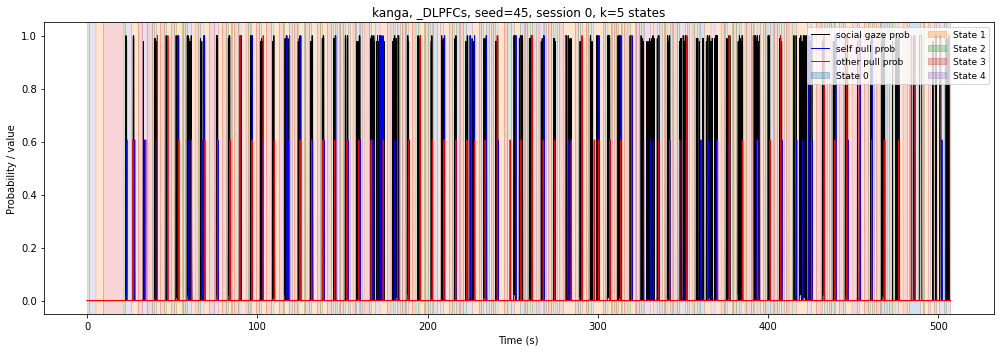

In [46]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pickle
import numpy as np

def plot_example_session_with_states(region, animal, seed, session_idx, k=None,
                                       hmm_results_dir=HMM_RESULTS_SAVE_DIR,
                                       bin_size_seconds=BIN_SIZE_SECONDS):
    """
    Plots gaze_prob, self_pull_prob, other_pull_prob for one example session,
    with the background shaded by decoded HMM state.

    region: e.g. '_OFCs' or '_DLPFCs'
    animal: e.g. 'dodson' or 'kanga'
    seed: which CEBRA seed's HMM results to use
    session_idx: which session (0-indexed) within that region/animal to plot
    k: which number of states to use (defaults to the auto-selected k if None)
    """
    save_path = f'{hmm_results_dir}/{region}_{animal}_seed{seed}_hmmresults.pkl'
    with open(save_path, 'rb') as f:
        saved = pickle.load(f)

    session_lengths = saved['metadata']['session_lengths']
    if k is None:
        k = saved['selected']['selected_k']
    states_full = saved['states_by_k'][k]

    # Get the time slice for this session
    session_bounds = np.cumsum([0] + session_lengths)
    start, end = session_bounds[session_idx], session_bounds[session_idx + 1]
    session_states = states_full[start:end]

    # Get matching behavioral data for this session
    key = (region, animal)
    bhv_session = multisessions_bhv_all[key][session_idx]  # (T, 4) array
    gaze_prob = bhv_session[:, 0]
    selfpull_prob = bhv_session[:, 1]
    otherpull_prob = bhv_session[:, 3]

    time_axis = np.arange(len(session_states)) * bin_size_seconds

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(14, 5))

    cmap = plt.get_cmap('tab10')
    state_colors = {s: cmap(s) for s in np.unique(session_states)}

    prev_state = session_states[0]
    seg_start = 0
    for i in range(1, len(session_states) + 1):
        if i == len(session_states) or session_states[i] != prev_state:
            end_x = time_axis[i-1] if i < len(session_states) else time_axis[-1]
            ax.axvspan(time_axis[seg_start], end_x, color=state_colors[prev_state], alpha=0.2)
            if i < len(session_states):
                seg_start = i
                prev_state = session_states[i]

    ax.plot(time_axis, gaze_prob, label='social gaze prob', color='black', linewidth=1)
    ax.plot(time_axis, selfpull_prob, label='self pull prob', color='blue', linewidth=1)
    ax.plot(time_axis, otherpull_prob, label='other pull prob', color='red', linewidth=1)

    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Probability / value')
    ax.set_title(f'{animal}, {region}, seed={seed}, session {session_idx}, k={k} states')

    handles, labels = ax.get_legend_handles_labels()
    state_patches = [mpatches.Patch(color=state_colors[s], alpha=0.3, label=f'State {s}')
                      for s in sorted(state_colors)]
    ax.legend(handles=handles + state_patches, loc='upper right', ncol=2, fontsize=9)

    plt.tight_layout()
    plt.show()


# Example usage:
plot_example_session_with_states(
    region='_DLPFCs', animal='kanga', seed=45, session_idx=0, k=5,
)


In [ ]:
dddd

In [109]:
# organize to get the summarizing info about the recording sessions
if 1:
    # ── Derived lists ─────────────────────────────────────────────────────────────
    # partner is whichever animal is NOT the recorded one
    partner_animals = [
        a2 if rec == a1 else a1
        for rec, a1, a2 in zip(recordedanimals, animal1_fixedorders, animal2_fixedorders)
    ]

    # Flatten any array elements to scalars
    totalsessiontime_all_dates = [float(np.squeeze(t)) for t in totalsessiontime_all_dates]
    pull1_num_all_dates        = [float(np.squeeze(p)) for p in pull1_num_all_dates]
    pull2_num_all_dates        = [float(np.squeeze(p)) for p in pull2_num_all_dates]

    # Assign pulls to recorded vs partner
    recorded_pull = [p1 if rec == a1 else p2
                     for rec, a1, p1, p2 in zip(recordedanimals, animal1_fixedorders,
                                                 pull1_num_all_dates, pull2_num_all_dates)]
    partner_pull  = [p2 if rec == a1 else p1
                     for rec, a1, p1, p2 in zip(recordedanimals, animal1_fixedorders,
                                                 pull1_num_all_dates, pull2_num_all_dates)]

    # Count neurons per session from bhvevents_aligned_FR_all_dates
    neuron_counts = []
    for date, rec_animal in zip(dates_list, recordedanimals):
        pull_key = f"{rec_animal} pull"
        n_neurons = len(bhvevents_aligned_FR_all_dates[date][pull_key].keys())
        neuron_counts.append(n_neurons)

    # ── Build dataframe ───────────────────────────────────────────────────────────
    df = pd.DataFrame({
        'session_type':    task_conditions,
        'recorded_animal': recordedanimals,
        'partner_animal':  partner_animals,
        'session_time_s':  totalsessiontime_all_dates,
        'recorded_pull':   recorded_pull,
        'partner_pull':    partner_pull,
        'neuron_count':    neuron_counts,
    })

    # ── Aggregate ─────────────────────────────────────────────────────────────────
    def fmt(mean, mn, mx):
        return f"{mean:.1f} ({int(mn)}-{int(mx)})"

    summary = (df.groupby(['recorded_animal', 'partner_animal', 'session_type'])
                 .agg(
                     num_sessions       = ('session_time_s', 'count'),
                     mean_time_s        = ('session_time_s', 'mean'),
                     min_time_s         = ('session_time_s', 'min'),
                     max_time_s         = ('session_time_s', 'max'),
                     mean_recorded_pull = ('recorded_pull',  'mean'),
                     min_recorded_pull  = ('recorded_pull',  'min'),
                     max_recorded_pull  = ('recorded_pull',  'max'),
                     mean_partner_pull  = ('partner_pull',   'mean'),
                     min_partner_pull   = ('partner_pull',   'min'),
                     max_partner_pull   = ('partner_pull',   'max'),
                     mean_neurons       = ('neuron_count',   'mean'),
                     min_neurons        = ('neuron_count',   'min'),
                     max_neurons        = ('neuron_count',   'max'),
                 )
                 .reset_index())

    summary['session_time_summary']  = summary.apply(
        lambda r: fmt(r['mean_time_s'], r['min_time_s'], r['max_time_s']), axis=1)
    summary['recorded_pull_summary'] = summary.apply(
        lambda r: fmt(r['mean_recorded_pull'], r['min_recorded_pull'], r['max_recorded_pull']), axis=1)
    summary['partner_pull_summary']  = summary.apply(
        lambda r: fmt(r['mean_partner_pull'], r['min_partner_pull'], r['max_partner_pull']), axis=1)
    summary['neuron_summary']        = summary.apply(
        lambda r: fmt(r['mean_neurons'], r['min_neurons'], r['max_neurons']), axis=1)

    summary = summary.drop(columns=[
        'mean_time_s',        'min_time_s',        'max_time_s',
        'mean_recorded_pull', 'min_recorded_pull', 'max_recorded_pull',
        'mean_partner_pull',  'min_partner_pull',  'max_partner_pull',
        'mean_neurons',       'min_neurons',       'max_neurons',
    ])

    print(summary.to_string(index=False))

    # save as csv
    data_saved_subfolder = data_saved_folder+'data_saved_singlecam_wholebody'+savefile_sufix+'/'+cameraID+'/'+animal1_fixedorders[0]+animal2_fixedorders[0]+'/'
    if not os.path.exists(data_saved_subfolder):
        os.makedirs(data_saved_subfolder)
    #
    summary.to_csv(data_saved_subfolder + "session_summary_with_neuron_number.csv", index=False)
    print("Saved to:", data_saved_subfolder + "session_summary_with_neuron_number.csv")

    #######
    # dataframe with info for each session
    #######
    df_persession = pd.DataFrame({
        'date':            dates_list,
        'session_type':    task_conditions,
        'recorded_animal': recordedanimals,
        'partner_animal':  partner_animals,
        'session_time_s':  totalsessiontime_all_dates,
        'recorded_pull':   recorded_pull,
        'partner_pull':    partner_pull,
        'neuron_count':    neuron_counts,
    }).sort_values(by=['session_type', 'recorded_animal', 'partner_animal']).reset_index(drop=True)


    # print(df_persession.to_string(index=False))

    # Save
    df_persession.to_csv(data_saved_subfolder + "session_persession_with_neuron_number.csv", index=False)
    print("Saved to:", data_saved_subfolder + "session_persession_with_neuron_number.csv")

recorded_animal partner_animal session_type  num_sessions session_time_summary recorded_pull_summary partner_pull_summary neuron_summary
          kanga         dannon           MC             4      583.2 (534-640)          62.8 (52-83)         43.8 (32-55)   14.5 (14-15)
          kanga         dannon           SR             1      541.0 (541-541)          19.0 (19-19)            2.0 (2-2)   17.0 (17-17)
          kanga         dodson           MC            14      550.3 (445-773)          59.4 (43-74)         56.8 (43-74)    21.2 (8-33)
          kanga         dodson           SR            13      518.1 (388-645)           19.7 (5-41)          28.2 (7-44)   25.8 (10-38)
Saved to: /gpfs/radev/pi/nandy/jadi_gibbs_data/VideoTracker_SocialInter/3d_recontruction_analysis_self_and_coop_task_data_saved/data_saved_singlecam_wholebody_OFCs/camera-2/dodsonkanga/session_summary_with_neuron_number.csv
Saved to: /gpfs/radev/pi/nandy/jadi_gibbs_data/VideoTracker_SocialInter/3d_recontruction_an

### plot
#### plot the summarizing FR PCs aligned at the bhv

In [112]:
if 0:


    bhvevents_aligned_FRPCs_allevents_all_dates_df = pd.DataFrame(columns=['dates','condition','act_animal','bhv_name','clusterID',
                                                           'channelID','FR_allevents'])
    bhvevents_aligned_FRPCs_all_dates_df = pd.DataFrame(columns=['dates','condition','act_animal','bhv_name','clusterID',
                                                           'channelID','FR_average'])

    # reorganize to a dataframes
    for idate in np.arange(0,ndates,1):
        date_tgt = dates_list[idate]
        task_condition = task_conditions[idate]

        bhv_types = list(bhvevents_aligned_FRPCs_allevents_all_dates[date_tgt].keys())

        for ibhv_type in bhv_types:

            clusterIDs = list(bhvevents_aligned_FRPCs_allevents_all_dates[date_tgt][ibhv_type].keys())

            for iclusterID in clusterIDs:

                ichannelID = bhvevents_aligned_FRPCs_allevents_all_dates[date_tgt][ibhv_type][iclusterID]['ch']
                iFR_average = bhvevents_aligned_FRPCs_allevents_all_dates[date_tgt][ibhv_type][iclusterID]['FR_allevents']

                bhvevents_aligned_FRPCs_allevents_all_dates_df = bhvevents_aligned_FRPCs_allevents_all_dates_df.append({'dates': date_tgt, 
                                                                                        'condition':task_condition,
                                                                                        'act_animal':ibhv_type.split()[0],
                                                                                        'bhv_name': ibhv_type.split()[1],
                                                                                        'clusterID':iclusterID,
                                                                                        'channelID':ichannelID,
                                                                                        'FR_allevents':iFR_average,
                                                                                       }, ignore_index=True)

                #
                ichannelID = bhvevents_aligned_FRPCs_all_dates[date_tgt][ibhv_type][iclusterID]['ch']
                iFR_average = bhvevents_aligned_FRPCs_all_dates[date_tgt][ibhv_type][iclusterID]['FR_average']

                bhvevents_aligned_FRPCs_all_dates_df = bhvevents_aligned_FRPCs_all_dates_df.append({'dates': date_tgt, 
                                                                                        'condition':task_condition,
                                                                                        'act_animal':ibhv_type.split()[0],
                                                                                        'bhv_name': ibhv_type.split()[1],
                                                                                        'clusterID':iclusterID,
                                                                                        'channelID':ichannelID,
                                                                                        'FR_average':iFR_average,
                                                                                       }, ignore_index=True)
                
    #
    act_animal_tgt = recordedanimals[0]
    bhv_name_tgt = 'pull'
    condition_tgt = 'MC'
    
    bhvevents_aligned_FRPCs_all_dates_df = bhvevents_aligned_FRPCs_all_dates_df[ \
                                (bhvevents_aligned_FRPCs_all_dates_df['act_animal']==act_animal_tgt) &\
                                (bhvevents_aligned_FRPCs_all_dates_df['bhv_name']==bhv_name_tgt) &\
                                (bhvevents_aligned_FRPCs_all_dates_df['condition']==condition_tgt) ]
    
    
    
    # Create a figure with 3 subplots side-by-side
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

    # The three PCs we want to plot
    pcs = ['pc1', 'pc2', 'pc3']

    for i, pc in enumerate(pcs):
        ax = axes[i]

        # Filter the DataFrame for the current PC
        df_pc = bhvevents_aligned_FRPCs_all_dates_df[bhvevents_aligned_FRPCs_all_dates_df['clusterID'] == pc]

        # Loop through each row in the filtered DataFrame to plot the trace
        for index, row in df_pc.iterrows():
            trace = row['FR_average']

            # --- Safety Check for Data Types ---
            # If you loaded this from a CSV, pandas might have read the lists as strings. 
            # If 'trace' is a string, uncomment the line below to convert it back to a list:
            # if isinstance(trace, str): trace = ast.literal_eval(trace)

            # Plot the trace. alpha=0.7 makes overlapping lines slightly transparent
            ax.plot(trace, alpha=0.7, label=str(row['dates']))

        # Formatting each panel
        ax.set_title(f"Trace for {pc.upper()}", fontsize=14)
        ax.set_xlabel("Time Bins", fontsize=12)

        # Only add the Y-axis label to the first (leftmost) plot
        if i == 0:
            ax.set_ylabel("FR Average (PC Projection)", fontsize=12)

    # Add a legend to the last panel to identify the dates
    # bbox_to_anchor moves it slightly outside the plot area so it doesn't cover data
    axes[-1].legend(title="Dates", bbox_to_anchor=(1.05, 1), loc='upper left')

    # Clean up the layout so things don't overlap
    plt.tight_layout()
                
                
                
                

### plot 
#### plot the PCs

In [ ]:
if 0:
    fig, axs = plt.subplots(12,1)
    fig.set_figheight(20*1)
    fig.set_figwidth(5*3)

    x_lims = [0,totalsess_time_forFR]
    PC1min = np.min(FR_zscore_allch_PCs[:,0])
    PC1max = np.max(FR_zscore_allch_PCs[:,0])
    PC2min = np.min(FR_zscore_allch_PCs[:,1])
    PC2max = np.max(FR_zscore_allch_PCs[:,1])
    PC3min = np.min(FR_zscore_allch_PCs[:,2])
    PC3max = np.max(FR_zscore_allch_PCs[:,2])

    for iplotype in np.arange(0,4,1):

        if iplotype == 0:
            eventplot  = np.array(time_point_pull1)
            eventplotname = 'animal1_pull'
        elif iplotype == 1:
            eventplot  = np.array(time_point_pull2)
            eventplotname = 'animal2_pull'
        elif iplotype == 2:
            eventplot  = np.hstack([oneway_gaze1,mutual_gaze1])
            eventplotname = 'animal1_gaze'
        elif iplotype == 3:
            eventplot  = np.hstack([oneway_gaze2,mutual_gaze2])
            eventplotname = 'animal2_gaze'

        # plot 1
        nevents = np.shape(eventplot)[0]
        for ievent in np.arange(0,nevents,1):
            axs[0+3*iplotype].plot([eventplot[ievent],eventplot[ievent]],[PC1min,PC1max],'k-')
        axs[0+3*iplotype].set_xlim(x_lims[0],x_lims[1])
        axs[0+3*iplotype].set_ylim(PC1min,PC1max)
        #
        axs[0+3*iplotype].plot(FR_timepoint_allch,FR_zscore_allch_PCs[:,0])
        axs[0+3*iplotype].set_xlim(x_lims[0],x_lims[1])
        axs[0+3*iplotype].set_ylabel('PC1\n'+eventplotname)

        # plot 2
        nevents = np.shape(eventplot)[0]
        for ievent in np.arange(0,nevents,1):
            axs[1+3*iplotype].plot([eventplot[ievent],eventplot[ievent]],[PC2min,PC2max],'k-')
        axs[1+3*iplotype].set_xlim(x_lims[0],x_lims[1])
        axs[1+3*iplotype].set_ylim(PC2min,PC2max)
        #
        axs[1+3*iplotype].plot(FR_timepoint_allch,FR_zscore_allch_PCs[:,1])
        axs[1+3*iplotype].set_xlim(x_lims[0],x_lims[1])
        axs[1+3*iplotype].set_ylabel('PC2\n'+eventplotname)

        # plot 3
        nevents = np.shape(eventplot)[0]
        for ievent in np.arange(0,nevents,1):
            axs[2+3*iplotype].plot([eventplot[ievent],eventplot[ievent]],[PC3min,PC3max],'k-')
        axs[2+3*iplotype].set_xlim(x_lims[0],x_lims[1])
        axs[2+3*iplotype].set_ylim(PC3min,PC3max)
        #
        axs[2+3*iplotype].plot(FR_timepoint_allch,FR_zscore_allch_PCs[:,2])
        axs[2+3*iplotype].set_xlim(x_lims[0],x_lims[1])
        axs[2+3*iplotype].set_ylabel('PC3\n'+eventplotname)


#### analyze the bhv aligned firing rate across all dates
#### plot the tsne or PCA clusters

In [ ]:
if 0:
    from sklearn.decomposition import PCA
    from sklearn.manifold import TSNE
    from sklearn.cluster import KMeans
    from sklearn.metrics import silhouette_samples, silhouette_score

    doPCA = 1
    doTSNE = 0

    bhvevents_aligned_FR_all_dates_df = pd.DataFrame(columns=['dates','condition','act_animal','bhv_name','clusterID',
                                                           'channelID','FR_average'])

    # reorganize to a dataframes
    for idate in np.arange(0,ndates,1):
        date_tgt = dates_list[idate]
        task_condition = task_conditions[idate]

        bhv_types = list(bhvevents_aligned_FR_all_dates[date_tgt].keys())

        for ibhv_type in bhv_types:

            clusterIDs = list(bhvevents_aligned_FR_all_dates[date_tgt][ibhv_type].keys())

            for iclusterID in clusterIDs:

                ichannelID = bhvevents_aligned_FR_all_dates[date_tgt][ibhv_type][iclusterID]['ch']
                iFR_average = bhvevents_aligned_FR_all_dates[date_tgt][ibhv_type][iclusterID]['FR_average']

                bhvevents_aligned_FR_all_dates_df = bhvevents_aligned_FR_all_dates_df.append({'dates': date_tgt, 
                                                                                        'condition':task_condition,
                                                                                        'act_animal':ibhv_type.split()[0],
                                                                                        'bhv_name': ibhv_type.split()[1],
                                                                                        'clusterID':iclusterID,
                                                                                        'channelID':ichannelID,
                                                                                        'FR_average':iFR_average,
                                                                                       }, ignore_index=True)

    if 0:
        # normalize FR_average for each unit
        nspikeunits = np.shape(bhvevents_aligned_FR_all_dates_df)[0]
        for ispikeunit in np.arange(0,nspikeunits,1):
            stevent = bhvevents_aligned_FR_all_dates_df['FR_average'][ispikeunit]
            stevent_norm = (stevent-np.nanmin(stevent))/(np.nanmax(stevent)-np.nanmin(stevent))
            bhvevents_aligned_FR_all_dates_df['FR_average'][ispikeunit] = stevent_norm            

    # only focus on the certain act animal and certain bhv_name
    # act_animals_all = ['kanga']
    # bhv_names_all = ['leverpull_prob']
    act_animals_all = np.unique(bhvevents_aligned_FR_all_dates_df['act_animal'])
    bhv_names_all = np.unique(bhvevents_aligned_FR_all_dates_df['bhv_name'])
    #
    nact_animals = np.shape(act_animals_all)[0]
    nbhv_names = np.shape(bhv_names_all)[0]

    # set for plot
    # plot all units
    fig1, axs1 = plt.subplots(nact_animals,nbhv_names)
    fig1.set_figheight(6*nact_animals)
    fig1.set_figwidth(6*nbhv_names)

    # plot all units but separate different days
    fig2, axs2 = plt.subplots(nact_animals,nbhv_names)
    fig2.set_figheight(6*nact_animals)
    fig2.set_figwidth(6*nbhv_names)

    # plot all units but seprate different channels
    fig3, axs3 = plt.subplots(nact_animals,nbhv_names)
    fig3.set_figheight(4*nact_animals)
    fig3.set_figwidth(4*nbhv_names)

    # plot all units but separate different conditions
    fig4, axs4 = plt.subplots(nact_animals,nbhv_names)
    fig4.set_figheight(6*nact_animals)
    fig4.set_figwidth(6*nbhv_names)

    # spike triggered average for different task conditions
    # # to be save, prepare for five conditions
    fig6, axs6 = plt.subplots(nact_animals*5,nbhv_names)
    fig6.set_figheight(6*nact_animals*5)
    fig6.set_figwidth(6*nbhv_names)
    # fig6, axs6 = plt.subplots(nact_animals,nbhv_names)
    # fig6.set_figheight(6*nact_animals)
    # fig6.set_figwidth(6*nbhv_names)

    # plot all units but separate different k-mean cluster
    fig5, axs5 = plt.subplots(nact_animals,nbhv_names)
    fig5.set_figheight(6*nact_animals)
    fig5.set_figwidth(6*nbhv_names)

    # spike triggered average for different k-mean cluster
    # to be save, prepare for 14 clusters
    fig7, axs7 = plt.subplots(nact_animals*14,nbhv_names)
    fig7.set_figheight(6*nact_animals*14)
    fig7.set_figwidth(6*nbhv_names)

    # stacked bar plot to show the cluster distribution of each conditions
    fig8, axs8 = plt.subplots(nact_animals,nbhv_names)
    fig8.set_figheight(6*nact_animals)
    fig8.set_figwidth(6*nbhv_names)

    #
    for ianimal in np.arange(0,nact_animals,1):

        act_animal = act_animals_all[ianimal]

        for ibhvname in np.arange(0,nbhv_names,1):

            bhv_name = bhv_names_all[ibhvname]

            ind = (bhvevents_aligned_FR_all_dates_df['act_animal']==act_animal)&(bhvevents_aligned_FR_all_dates_df['bhv_name']==bhv_name)

            bhvevents_aligned_FR_tgt = np.vstack(list(bhvevents_aligned_FR_all_dates_df[ind]['FR_average']))

            ind_nan = np.isnan(np.sum(bhvevents_aligned_FR_tgt,axis=1)) # exist because of failed pull in SR
            bhvevents_aligned_FR_tgt = bhvevents_aligned_FR_tgt[~ind_nan,:]

            # k means clustering
            # run clustering on the 15 or 2 dimension PC space (for doPCA), or the whole dataset or 2 dimension (for doTSNE)
            pca = PCA(n_components=10)
            bhvevents_aligned_FR_pca = pca.fit_transform(bhvevents_aligned_FR_tgt)
            tsne = TSNE(n_components=2, random_state=0)
            bhvevents_aligned_FR_tsne = tsne.fit_transform(bhvevents_aligned_FR_tgt)
            #
            range_n_clusters = np.arange(2,8,1)
            silhouette_avg_all = np.ones(np.shape(range_n_clusters))*np.nan
            nkmeancls = np.shape(range_n_clusters)[0]
            #
            for ikmeancl in np.arange(0,nkmeancls,1):
                n_clusters = range_n_clusters[ikmeancl]
                #
                clusterer = KMeans(n_clusters=n_clusters, random_state=10)
                # cluster_labels = clusterer.fit_predict(bhvevents_aligned_FR_tgt)
                if doPCA:
                    cluster_labels = clusterer.fit_predict(bhvevents_aligned_FR_pca)
                if doTSNE:
                    cluster_labels = clusterer.fit_predict(bhvevents_aligned_FR_tgt)
                    # cluster_labels = clusterer.fit_predict(bhvevents_aligned_FR_tsne)
                #
                # The silhouette_score gives the average value for all the samples.
                # This gives a perspective into the density and separation of the formed
                # clusters
                # silhouette_avg = silhouette_score(bhvevents_aligned_FR_tgt, cluster_labels)
                if doPCA:
                    silhouette_avg = silhouette_score(bhvevents_aligned_FR_pca, cluster_labels)
                if doTSNE:
                    silhouette_avg = silhouette_score(bhvevents_aligned_FR_tgt, cluster_labels)
                    # silhouette_avg = silhouette_score(bhvevents_aligned_FR_tsne, cluster_labels)
                #
                silhouette_avg_all[ikmeancl] = silhouette_avg
            #
            best_k_num = range_n_clusters[silhouette_avg_all==np.nanmax(silhouette_avg_all)][0]
            #
            clusterer = KMeans(n_clusters=best_k_num, random_state=0)
            # kmean_cluster_labels = clusterer.fit_predict(bhvevents_aligned_FR_tgt)
            if doPCA:
                kmean_cluster_labels = clusterer.fit_predict(bhvevents_aligned_FR_pca)
            if doTSNE:
                kmean_cluster_labels = clusterer.fit_predict(bhvevents_aligned_FR_tgt)
                # kmean_cluster_labels = clusterer.fit_predict(bhvevents_aligned_FR_tsne)


            # run PCA and TSNE     
            pca = PCA(n_components=2)
            tsne = TSNE(n_components=2, random_state=0)
            #
            bhvevents_aligned_FR_pca = pca.fit_transform(bhvevents_aligned_FR_tgt)
            bhvevents_aligned_FR_tsne = tsne.fit_transform(bhvevents_aligned_FR_tgt)

            # plot all units
            # plot the tsne
            if doTSNE:
                axs1[ianimal,ibhvname].plot(bhvevents_aligned_FR_tsne[:,0],bhvevents_aligned_FR_tsne[:,1],'.')
            # plot the pca
            if doPCA:
                axs1[ianimal,ibhvname].plot(bhvevents_aligned_FR_pca[:,0],bhvevents_aligned_FR_pca[:,1],'.')

            axs1[ianimal,ibhvname].set_xticklabels([])
            axs1[ianimal,ibhvname].set_yticklabels([])
            axs1[ianimal,ibhvname].set_title(act_animal+';'+bhv_name)


            # plot all units, but seprate different dates
            dates_forplot = np.unique(bhvevents_aligned_FR_all_dates_df[ind]['dates'])
            for idate_forplot in dates_forplot:
                ind_idate = list(bhvevents_aligned_FR_all_dates_df[ind]['dates']==idate_forplot)
                ind_idate = list(np.array(ind_idate)[~ind_nan])
                #
                # plot the tsne
                if doTSNE:
                    axs2[ianimal,ibhvname].plot(bhvevents_aligned_FR_tsne[ind_idate,0],bhvevents_aligned_FR_tsne[ind_idate,1],
                                            '.',label=idate_forplot)
                # plot the pca
                if doPCA:
                    axs2[ianimal,ibhvname].plot(bhvevents_aligned_FR_pca[ind_idate,0],bhvevents_aligned_FR_pca[ind_idate,1],
                                            '.',label=idate_forplot)
                #
            axs2[ianimal,ibhvname].set_xticklabels([])
            axs2[ianimal,ibhvname].set_yticklabels([])
            axs2[ianimal,ibhvname].set_title(act_animal+';'+bhv_name)
            axs2[ianimal,ibhvname].legend()


            # plot all units, but seprate different channels
            chs_forplot = np.unique(bhvevents_aligned_FR_all_dates_df[ind]['channelID'])
            for ich_forplot in chs_forplot:
                ind_ich = list(bhvevents_aligned_FR_all_dates_df[ind]['channelID']==ich_forplot)
                ind_ich = list(np.array(ind_ich)[~ind_nan])
                #
                # plot the tsne
                if doTSNE:
                    axs3[ianimal,ibhvname].plot(bhvevents_aligned_FR_tsne[ind_ich,0],bhvevents_aligned_FR_tsne[ind_ich,1],
                                            '.',label=str(ich_forplot))
                # plot the pca
                if doPCA:
                    axs3[ianimal,ibhvname].plot(bhvevents_aligned_FR_pca[ind_ich,0],bhvevents_aligned_FR_pca[ind_ich,1],
                                            '.',label=str(ich_forplot))
                #
            axs3[ianimal,ibhvname].set_xticklabels([])
            axs3[ianimal,ibhvname].set_yticklabels([])
            axs3[ianimal,ibhvname].set_title(act_animal+';'+bhv_name)
            axs3[ianimal,ibhvname].legend()


            # plot all units, but seprate different task conditions
            cons_forplot = np.unique(bhvevents_aligned_FR_all_dates_df[ind]['condition'])
            for icon_forplot in cons_forplot:
                ind_icon = list(bhvevents_aligned_FR_all_dates_df[ind]['condition']==icon_forplot)
                ind_icon = list(np.array(ind_icon)[~ind_nan])
                #
                # plot the tsne
                if doTSNE:
                    axs4[ianimal,ibhvname].plot(bhvevents_aligned_FR_tsne[ind_icon,0],bhvevents_aligned_FR_tsne[ind_icon,1],
                                            '.',label=icon_forplot)
                # plot the pca
                if doPCA:
                    axs4[ianimal,ibhvname].plot(bhvevents_aligned_FR_pca[ind_icon,0],bhvevents_aligned_FR_pca[ind_icon,1],
                                            '.',label=icon_forplot)
                #
            axs4[ianimal,ibhvname].set_xticklabels([])
            axs4[ianimal,ibhvname].set_yticklabels([])
            axs4[ianimal,ibhvname].set_title(act_animal+';'+bhv_name)
            axs4[ianimal,ibhvname].legend()

            # plot the mean spike trigger average trace across neurons in each condition
            trig_twins = [-4,4] # the time window to examine the spike triggered average, in the unit of s
            xxx_forplot = np.arange(trig_twins[0]*fps,trig_twins[1]*fps,1)
            #
            cons_forplot = np.unique(bhvevents_aligned_FR_all_dates_df[ind]['condition'])
            icon_ind = 0
            for icon_forplot in cons_forplot:
                ind_icon = list(bhvevents_aligned_FR_all_dates_df[ind]['condition']==icon_forplot)
                ind_icon = list(np.array(ind_icon)[~ind_nan])
                #
                mean_trig_trace_icon = np.nanmean(bhvevents_aligned_FR_tgt[ind_icon,:],axis=0)
                std_trig_trace_icon = np.nanstd(bhvevents_aligned_FR_tgt[ind_icon,:],axis=0)
                sem_trig_trace_icon = np.nanstd(bhvevents_aligned_FR_tgt[ind_icon,:],axis=0)/np.sqrt(np.shape(bhvevents_aligned_FR_tgt[ind_icon,:])[0])
                itv95_trig_trace_icon = 1.96*sem_trig_trace_icon
                #
                if 1:
                # plot each trace in a seperate traces
                    axs6[ianimal*5+icon_ind,ibhvname].errorbar(xxx_forplot,mean_trig_trace_icon,yerr=itv95_trig_trace_icon,
                                                               color='#E0E0E0',ecolor='#EEEEEE',label=icon_forplot)
                    axs6[ianimal*5+icon_ind,ibhvname].plot([0,0],[np.nanmin(mean_trig_trace_icon-itv95_trig_trace_icon),
                                                                  np.nanmax(mean_trig_trace_icon+itv95_trig_trace_icon)],'--k')
                    axs6[ianimal*5+icon_ind,ibhvname].set_xlabel('time (s)')
                    axs6[ianimal*5+icon_ind,ibhvname].set_xticks(np.arange(trig_twins[0]*fps,trig_twins[1]*fps,60))
                    axs6[ianimal*5+icon_ind,ibhvname].set_xticklabels(list(map(str,np.arange(trig_twins[0],trig_twins[1],2))))
                    axs6[ianimal*5+icon_ind,ibhvname].set_title(act_animal+'; '+bhv_name)
                    axs6[ianimal*5+icon_ind,ibhvname].legend()
                if 0:
                    axs6[ianimal,ibhvname].errorbar(xxx_forplot,mean_trig_trace_icon,yerr=itv95_trig_trace_icon,
                                                    label=icon_forplot)
                    # axs6[ianimal,ibhvname].plot([0,0],[np.nanmin(mean_trig_trace_icon-itv95_trig_trace_icon),
                    #                                               np.nanmax(mean_trig_trace_icon+itv95_trig_trace_icon)],'--k')
                    axs6[ianimal,ibhvname].plot([0,0],[0,0.1],'--k') 
                    axs6[ianimal,ibhvname].set_xlabel('time (s)')
                    axs6[ianimal,ibhvname].set_xticks(np.arange(trig_twins[0]*fps,trig_twins[1]*fps,60))
                    axs6[ianimal,ibhvname].set_xticklabels(list(map(str,np.arange(trig_twins[0],trig_twins[1],2))))
                    axs6[ianimal,ibhvname].set_title(act_animal+'; '+bhv_name)
                    axs6[ianimal,ibhvname].legend()
                #
                icon_ind = icon_ind + 1


            # plot all units, but seprate different k-mean clusters
            kms_forplot = np.unique(kmean_cluster_labels)
            for ikm_forplot in kms_forplot:
                ind_ikm = list(kmean_cluster_labels==ikm_forplot)
                #
                # plot the tsne
                if doTSNE:
                    axs5[ianimal,ibhvname].plot(bhvevents_aligned_FR_tsne[ind_ikm,0],bhvevents_aligned_FR_tsne[ind_ikm,1],
                                            '.',label=str(ikm_forplot))
                # plot the pca
                if doPCA:
                    axs5[ianimal,ibhvname].plot(bhvevents_aligned_FR_pca[ind_ikm,0],bhvevents_aligned_FR_pca[ind_ikm,1],
                                            '.',label=str(ikm_forplot))
                #
            axs5[ianimal,ibhvname].set_xticklabels([])
            axs5[ianimal,ibhvname].set_yticklabels([])
            axs5[ianimal,ibhvname].set_title(act_animal+'; '+bhv_name)
            axs5[ianimal,ibhvname].legend()

            # plot the mean spike trigger average trace across neurons in each cluster
            trig_twins = [-4,4] # the time window to examine the spike triggered average, in the unit of s
            xxx_forplot = np.arange(trig_twins[0]*fps,trig_twins[1]*fps,1)
            #
            kms_forplot = np.unique(kmean_cluster_labels)
            for ikm_forplot in kms_forplot:
                ind_ikm = list(kmean_cluster_labels==ikm_forplot)
                #
                mean_trig_trace_ikm = np.nanmean(bhvevents_aligned_FR_tgt[ind_ikm,:],axis=0)
                std_trig_trace_ikm = np.nanstd(bhvevents_aligned_FR_tgt[ind_ikm,:],axis=0)
                sem_trig_trace_ikm = np.nanstd(bhvevents_aligned_FR_tgt[ind_ikm,:],axis=0)/np.sqrt(np.shape(bhvevents_aligned_FR_tgt[ind_ikm,:])[0])
                itv95_trig_trace_ikm = 1.96*sem_trig_trace_ikm
                #
                axs7[ianimal*14+ikm_forplot,ibhvname].errorbar(xxx_forplot,mean_trig_trace_ikm,yerr=itv95_trig_trace_ikm,
                                                              color='#E0E0E0',ecolor='#EEEEEE',label='cluster#'+str(ikm_forplot))
                axs7[ianimal*14+ikm_forplot,ibhvname].plot([0,0],[np.nanmin(mean_trig_trace_ikm-itv95_trig_trace_ikm),
                                                                 np.nanmax(mean_trig_trace_ikm+itv95_trig_trace_ikm)],'--k')
                axs7[ianimal*14+ikm_forplot,ibhvname].set_xlabel('time (s)')
                axs7[ianimal*14+ikm_forplot,ibhvname].set_xticks(np.arange(trig_twins[0]*fps,trig_twins[1]*fps,60))
                axs7[ianimal*14+ikm_forplot,ibhvname].set_xticklabels(list(map(str,np.arange(trig_twins[0],trig_twins[1],2))))
                axs7[ianimal*14+ikm_forplot,ibhvname].set_title(act_animal+'; '+bhv_name)
                axs7[ianimal*14+ikm_forplot,ibhvname].legend()


            # stacked bar plot to show the cluster distribution of each conditions
            df = pd.DataFrame({'cond':np.array(bhvevents_aligned_FR_all_dates_df[ind]['condition'])[~ind_nan],
                               'cluID':kmean_cluster_labels})
            (df.groupby('cond')['cluID'].value_counts(normalize=True)
               .unstack('cluID').plot.bar(stacked=True, ax=axs8[ianimal,ibhvname]))
            axs8[ianimal,ibhvname].set_title(act_animal+';'+bhv_name)




    savefig = 1
    if savefig:
        figsavefolder = data_saved_folder+"fig_for_basic_neural_analysis_allsessions_basicEvents/"+cameraID+"/"+animal1_filenames[0]+"_"+animal2_filenames[0]+"_"+recordedanimal+"Recorded/bhvAlignedFRAver_fig/"

        if not os.path.exists(figsavefolder):
            os.makedirs(figsavefolder)
        if doTSNE:
            fig1.savefig(figsavefolder+'bhv_aligned_FR_tsne_clusters_all_dates'+savefile_sufix+'.pdf')
            fig2.savefig(figsavefolder+'bhv_aligned_FR_tsne_clusters_all_dates_separated_dates'+savefile_sufix+'.pdf')
            fig3.savefig(figsavefolder+'bhv_aligned_FR_tsne_clusters_all_dates_separated_channels'+savefile_sufix+'.pdf')
            fig4.savefig(figsavefolder+'bhv_aligned_FR_tsne_clusters_all_dates_separated_conditions'+savefile_sufix+'.pdf')
            fig5.savefig(figsavefolder+'bhv_aligned_FR_tsne_clusters_all_dates_separated_kmeanclusters'+savefile_sufix+'.pdf')
            fig6.savefig(figsavefolder+'bhv_aligned_FR_tsne_clusters_all_dates_sttraces_for_conditions'+savefile_sufix+'.pdf')        
            fig7.savefig(figsavefolder+'bhv_aligned_FR_tsne_clusters_all_dates_sttraces_for_kmeanclusters'+savefile_sufix+'.pdf')
            fig8.savefig(figsavefolder+'bhv_aligned_FR_tsne_clusters_kmeanclusters_propotion_each_condition'+savefile_sufix+'.pdf')

        if doPCA:
            fig1.savefig(figsavefolder+'bhv_aligned_FR_pca_clusters_all_dates'+savefile_sufix+'.pdf')
            fig2.savefig(figsavefolder+'bhv_aligned_FR_pca_clusters_all_dates_separated_dates'+savefile_sufix+'.pdf')
            fig3.savefig(figsavefolder+'bhv_aligned_FR_pca_clusters_all_dates_separated_channels'+savefile_sufix+'.pdf')
            fig4.savefig(figsavefolder+'bhv_aligned_FR_pca_clusters_all_dates_separated_conditions'+savefile_sufix+'.pdf')
            fig5.savefig(figsavefolder+'bhv_aligned_FR_pca_clusters_all_dates_separated_kmeanclusters'+savefile_sufix+'.pdf')
            fig6.savefig(figsavefolder+'bhv_aligned_FR_pca_clusters_all_dates_sttraces_for_conditions'+savefile_sufix+'.pdf')                           
            fig7.savefig(figsavefolder+'bhv_aligned_FR_pca_clusters_all_dates_sttraces_for_kmeanclusters'+savefile_sufix+'.pdf')
            fig8.savefig(figsavefolder+'bhv_aligned_FR_pca_clusters_kmeanclusters_propotion_each_condition'+savefile_sufix+'.pdf')



#### analyze the spike triggered behavioral variables across all dates
#### plot the tsne or PCA clusters

In [ ]:
if 0:
    from sklearn.decomposition import PCA
    from sklearn.manifold import TSNE
    from sklearn.cluster import KMeans
    from sklearn.metrics import silhouette_samples, silhouette_score

    doPCA = 1
    doTSNE = 0

    spike_trig_events_all_dates_df = pd.DataFrame(columns=['dates','condition','act_animal','bhv_name','clusterID',
                                                           'channelID','st_average'])

    # reorganize to a dataframes
    for idate in np.arange(0,ndates,1):
        date_tgt = dates_list[idate]
        task_condition = task_conditions[idate]

        act_animals = list(spike_trig_events_all_dates[date_tgt].keys())

        for iact_animal in act_animals:

            bhv_types = list(spike_trig_events_all_dates[date_tgt][iact_animal].keys())

            for ibhv_type in bhv_types:

                clusterIDs = list(spike_trig_events_all_dates[date_tgt][iact_animal][ibhv_type].keys())

                for iclusterID in clusterIDs:

                    ichannelID = spike_trig_events_all_dates[date_tgt][iact_animal][ibhv_type][iclusterID]['ch']
                    ist_average = spike_trig_events_all_dates[date_tgt][iact_animal][ibhv_type][iclusterID]['st_average']

                    spike_trig_events_all_dates_df = spike_trig_events_all_dates_df.append({'dates': date_tgt, 
                                                                                            'condition':task_condition,
                                                                                            'act_animal': iact_animal, 
                                                                                            'bhv_name': ibhv_type,
                                                                                            'clusterID':iclusterID,
                                                                                            'channelID':ichannelID,
                                                                                            'st_average':ist_average,
                                                                                           }, ignore_index=True)
    if 0:
        # normalize st_average for each unit
        nspikeunits = np.shape(spike_trig_events_all_dates_df)[0]
        for ispikeunit in np.arange(0,nspikeunits,1):
            stevent = spike_trig_events_all_dates_df['st_average'][ispikeunit]
            stevent_norm = (stevent-np.nanmin(stevent))/(np.nanmax(stevent)-np.nanmin(stevent))
            spike_trig_events_all_dates_df['st_average'][ispikeunit] = stevent_norm            

    # only focus on the certain act animal and certain bhv_name
    # act_animals_all = ['kanga']
    # bhv_names_all = ['leverpull_prob']
    act_animals_all = np.unique(spike_trig_events_all_dates_df['act_animal'])
    bhv_names_all = np.unique(spike_trig_events_all_dates_df['bhv_name'])
    #
    nact_animals = np.shape(act_animals_all)[0]
    nbhv_names = np.shape(bhv_names_all)[0]

    # set for plot
    # plot all units
    fig1, axs1 = plt.subplots(nact_animals,nbhv_names)
    fig1.set_figheight(6*nact_animals)
    fig1.set_figwidth(6*nbhv_names)

    # plot all units but separate different days
    fig2, axs2 = plt.subplots(nact_animals,nbhv_names)
    fig2.set_figheight(6*nact_animals)
    fig2.set_figwidth(6*nbhv_names)

    # plot all units but seprate different channels
    fig3, axs3 = plt.subplots(nact_animals,nbhv_names)
    fig3.set_figheight(4*nact_animals)
    fig3.set_figwidth(4*nbhv_names)

    # plot all units but separate different conditions
    fig4, axs4 = plt.subplots(nact_animals,nbhv_names)
    fig4.set_figheight(6*nact_animals)
    fig4.set_figwidth(6*nbhv_names)

    # spike triggered average for different task conditions
    # # to be save, prepare for five conditions
    fig6, axs6 = plt.subplots(nact_animals*5,nbhv_names)
    fig6.set_figheight(6*nact_animals*5)
    fig6.set_figwidth(6*nbhv_names)
    # fig6, axs6 = plt.subplots(nact_animals,nbhv_names)
    # fig6.set_figheight(6*nact_animals)
    # fig6.set_figwidth(6*nbhv_names)

    # plot all units but separate different k-mean cluster
    fig5, axs5 = plt.subplots(nact_animals,nbhv_names)
    fig5.set_figheight(6*nact_animals)
    fig5.set_figwidth(6*nbhv_names)

    # spike triggered average for different k-mean cluster
    # to be save, prepare for 14 clusters
    fig7, axs7 = plt.subplots(nact_animals*14,nbhv_names)
    fig7.set_figheight(6*nact_animals*14)
    fig7.set_figwidth(6*nbhv_names)

    # stacked bar plot to show the cluster distribution of each conditions
    fig8, axs8 = plt.subplots(nact_animals,nbhv_names)
    fig8.set_figheight(6*nact_animals)
    fig8.set_figwidth(6*nbhv_names)

    #
    for ianimal in np.arange(0,nact_animals,1):

        act_animal = act_animals_all[ianimal]

        for ibhvname in np.arange(0,nbhv_names,1):

            bhv_name = bhv_names_all[ibhvname]

            ind = (spike_trig_events_all_dates_df['act_animal']==act_animal)&(spike_trig_events_all_dates_df['bhv_name']==bhv_name)

            spike_trig_events_tgt = np.vstack(list(spike_trig_events_all_dates_df[ind]['st_average']))

            ind_nan = np.isnan(np.sum(spike_trig_events_tgt,axis=1)) # exist because of failed pull in SR
            spike_trig_events_tgt = spike_trig_events_tgt[~ind_nan,:]

            # k means clustering
            # run clustering on the 15 or 2 dimension PC space (for doPCA), or the whole dataset or 2 dimension (for doTSNE)
            pca = PCA(n_components=10)
            spike_trig_events_pca = pca.fit_transform(spike_trig_events_tgt)
            tsne = TSNE(n_components=2, random_state=0)
            spike_trig_events_tsne = tsne.fit_transform(spike_trig_events_tgt)
            #
            range_n_clusters = np.arange(2,8,1)
            silhouette_avg_all = np.ones(np.shape(range_n_clusters))*np.nan
            nkmeancls = np.shape(range_n_clusters)[0]
            #
            for ikmeancl in np.arange(0,nkmeancls,1):
                n_clusters = range_n_clusters[ikmeancl]
                #
                clusterer = KMeans(n_clusters=n_clusters, random_state=10)
                # cluster_labels = clusterer.fit_predict(spike_trig_events_tgt)
                if doPCA:
                    cluster_labels = clusterer.fit_predict(spike_trig_events_pca)
                if doTSNE:
                    cluster_labels = clusterer.fit_predict(spike_trig_events_tgt)
                    # cluster_labels = clusterer.fit_predict(spike_trig_events_tsne)
                #
                # The silhouette_score gives the average value for all the samples.
                # This gives a perspective into the density and separation of the formed
                # clusters
                # silhouette_avg = silhouette_score(spike_trig_events_tgt, cluster_labels)
                if doPCA:
                    silhouette_avg = silhouette_score(spike_trig_events_pca, cluster_labels)
                if doTSNE:
                    silhouette_avg = silhouette_score(spike_trig_events_tgt, cluster_labels)
                    # silhouette_avg = silhouette_score(spike_trig_events_tsne, cluster_labels)
                #
                silhouette_avg_all[ikmeancl] = silhouette_avg
            #
            best_k_num = range_n_clusters[silhouette_avg_all==np.nanmax(silhouette_avg_all)][0]
            #
            clusterer = KMeans(n_clusters=best_k_num, random_state=0)
            # kmean_cluster_labels = clusterer.fit_predict(spike_trig_events_tgt)
            if doPCA:
                kmean_cluster_labels = clusterer.fit_predict(spike_trig_events_pca)
            if doTSNE:
                kmean_cluster_labels = clusterer.fit_predict(spike_trig_events_tgt)
                # kmean_cluster_labels = clusterer.fit_predict(spike_trig_events_tsne)


            # run PCA and TSNE     
            pca = PCA(n_components=2)
            tsne = TSNE(n_components=2, random_state=0)
            #
            spike_trig_events_pca = pca.fit_transform(spike_trig_events_tgt)
            spike_trig_events_tsne = tsne.fit_transform(spike_trig_events_tgt)

            # plot all units
            # plot the tsne
            if doTSNE:
                axs1[ianimal,ibhvname].plot(spike_trig_events_tsne[:,0],spike_trig_events_tsne[:,1],'.')
            # plot the pca
            if doPCA:
                axs1[ianimal,ibhvname].plot(spike_trig_events_pca[:,0],spike_trig_events_pca[:,1],'.')

            axs1[ianimal,ibhvname].set_xticklabels([])
            axs1[ianimal,ibhvname].set_yticklabels([])
            axs1[ianimal,ibhvname].set_title(act_animal+';'+bhv_name)


            # plot all units, but seprate different dates
            dates_forplot = np.unique(spike_trig_events_all_dates_df[ind]['dates'])
            for idate_forplot in dates_forplot:
                ind_idate = list(spike_trig_events_all_dates_df[ind]['dates']==idate_forplot)
                ind_idate = list(np.array(ind_idate)[~ind_nan])
                #
                # plot the tsne
                if doTSNE:
                    axs2[ianimal,ibhvname].plot(spike_trig_events_tsne[ind_idate,0],spike_trig_events_tsne[ind_idate,1],
                                            '.',label=idate_forplot)
                # plot the pca
                if doPCA:
                    axs2[ianimal,ibhvname].plot(spike_trig_events_pca[ind_idate,0],spike_trig_events_pca[ind_idate,1],
                                            '.',label=idate_forplot)
                #
            axs2[ianimal,ibhvname].set_xticklabels([])
            axs2[ianimal,ibhvname].set_yticklabels([])
            axs2[ianimal,ibhvname].set_title(act_animal+';'+bhv_name)
            axs2[ianimal,ibhvname].legend()


            # plot all units, but seprate different channels
            chs_forplot = np.unique(spike_trig_events_all_dates_df[ind]['channelID'])
            for ich_forplot in chs_forplot:
                ind_ich = list(spike_trig_events_all_dates_df[ind]['channelID']==ich_forplot)
                ind_ich = list(np.array(ind_ich)[~ind_nan])
                #
                # plot the tsne
                if doTSNE:
                    axs3[ianimal,ibhvname].plot(spike_trig_events_tsne[ind_ich,0],spike_trig_events_tsne[ind_ich,1],
                                            '.',label=str(ich_forplot))
                # plot the pca
                if doPCA:
                    axs3[ianimal,ibhvname].plot(spike_trig_events_pca[ind_ich,0],spike_trig_events_pca[ind_ich,1],
                                            '.',label=str(ich_forplot))
                #
            axs3[ianimal,ibhvname].set_xticklabels([])
            axs3[ianimal,ibhvname].set_yticklabels([])
            axs3[ianimal,ibhvname].set_title(act_animal+';'+bhv_name)
            axs3[ianimal,ibhvname].legend()


            # plot all units, but seprate different task conditions
            cons_forplot = np.unique(spike_trig_events_all_dates_df[ind]['condition'])
            for icon_forplot in cons_forplot:
                ind_icon = list(spike_trig_events_all_dates_df[ind]['condition']==icon_forplot)
                ind_icon = list(np.array(ind_icon)[~ind_nan])
                #
                # plot the tsne
                if doTSNE:
                    axs4[ianimal,ibhvname].plot(spike_trig_events_tsne[ind_icon,0],spike_trig_events_tsne[ind_icon,1],
                                            '.',label=icon_forplot)
                # plot the pca
                if doPCA:
                    axs4[ianimal,ibhvname].plot(spike_trig_events_pca[ind_icon,0],spike_trig_events_pca[ind_icon,1],
                                            '.',label=icon_forplot)
                #
            axs4[ianimal,ibhvname].set_xticklabels([])
            axs4[ianimal,ibhvname].set_yticklabels([])
            axs4[ianimal,ibhvname].set_title(act_animal+';'+bhv_name)
            axs4[ianimal,ibhvname].legend()

            # plot the mean spike trigger average trace across neurons in each condition
            trig_twins = [-4,4] # the time window to examine the spike triggered average, in the unit of s
            xxx_forplot = np.arange(trig_twins[0]*fps,trig_twins[1]*fps,1)
            #
            cons_forplot = np.unique(spike_trig_events_all_dates_df[ind]['condition'])
            icon_ind = 0
            for icon_forplot in cons_forplot:
                ind_icon = list(spike_trig_events_all_dates_df[ind]['condition']==icon_forplot)
                ind_icon = list(np.array(ind_icon)[~ind_nan])
                #
                mean_trig_trace_icon = np.nanmean(spike_trig_events_tgt[ind_icon,:],axis=0)
                std_trig_trace_icon = np.nanstd(spike_trig_events_tgt[ind_icon,:],axis=0)
                sem_trig_trace_icon = np.nanstd(spike_trig_events_tgt[ind_icon,:],axis=0)/np.sqrt(np.shape(spike_trig_events_tgt[ind_icon,:])[0])
                itv95_trig_trace_icon = 1.96*sem_trig_trace_icon
                #
                if 1:
                # plot each trace in a seperate traces
                    axs6[ianimal*5+icon_ind,ibhvname].errorbar(xxx_forplot,mean_trig_trace_icon,yerr=itv95_trig_trace_icon,
                                                               color='#E0E0E0',ecolor='#EEEEEE',label=icon_forplot)
                    axs6[ianimal*5+icon_ind,ibhvname].plot([0,0],[np.nanmin(mean_trig_trace_icon-itv95_trig_trace_icon),
                                                                  np.nanmax(mean_trig_trace_icon+itv95_trig_trace_icon)],'--k')
                    axs6[ianimal*5+icon_ind,ibhvname].set_xlabel('time (s)')
                    axs6[ianimal*5+icon_ind,ibhvname].set_xticks(np.arange(trig_twins[0]*fps,trig_twins[1]*fps,60))
                    axs6[ianimal*5+icon_ind,ibhvname].set_xticklabels(list(map(str,np.arange(trig_twins[0],trig_twins[1],2))))
                    axs6[ianimal*5+icon_ind,ibhvname].set_title(act_animal+'; '+bhv_name)
                    axs6[ianimal*5+icon_ind,ibhvname].legend()
                if 0:
                    axs6[ianimal,ibhvname].errorbar(xxx_forplot,mean_trig_trace_icon,yerr=itv95_trig_trace_icon,
                                                    label=icon_forplot)
                    # axs6[ianimal,ibhvname].plot([0,0],[np.nanmin(mean_trig_trace_icon-itv95_trig_trace_icon),
                    #                                               np.nanmax(mean_trig_trace_icon+itv95_trig_trace_icon)],'--k')
                    axs6[ianimal,ibhvname].plot([0,0],[0,0.1],'--k') 
                    axs6[ianimal,ibhvname].set_xlabel('time (s)')
                    axs6[ianimal,ibhvname].set_xticks(np.arange(trig_twins[0]*fps,trig_twins[1]*fps,60))
                    axs6[ianimal,ibhvname].set_xticklabels(list(map(str,np.arange(trig_twins[0],trig_twins[1],2))))
                    axs6[ianimal,ibhvname].set_title(act_animal+'; '+bhv_name)
                    axs6[ianimal,ibhvname].legend()
                #
                icon_ind = icon_ind + 1


            # plot all units, but seprate different k-mean clusters
            kms_forplot = np.unique(kmean_cluster_labels)
            for ikm_forplot in kms_forplot:
                ind_ikm = list(kmean_cluster_labels==ikm_forplot)
                #
                # plot the tsne
                if doTSNE:
                    axs5[ianimal,ibhvname].plot(spike_trig_events_tsne[ind_ikm,0],spike_trig_events_tsne[ind_ikm,1],
                                            '.',label=str(ikm_forplot))
                # plot the pca
                if doPCA:
                    axs5[ianimal,ibhvname].plot(spike_trig_events_pca[ind_ikm,0],spike_trig_events_pca[ind_ikm,1],
                                            '.',label=str(ikm_forplot))
                #
            axs5[ianimal,ibhvname].set_xticklabels([])
            axs5[ianimal,ibhvname].set_yticklabels([])
            axs5[ianimal,ibhvname].set_title(act_animal+'; '+bhv_name)
            axs5[ianimal,ibhvname].legend()

            # plot the mean spike trigger average trace across neurons in each cluster
            trig_twins = [-4,4] # the time window to examine the spike triggered average, in the unit of s
            xxx_forplot = np.arange(trig_twins[0]*fps,trig_twins[1]*fps,1)
            #
            kms_forplot = np.unique(kmean_cluster_labels)
            for ikm_forplot in kms_forplot:
                ind_ikm = list(kmean_cluster_labels==ikm_forplot)
                #
                mean_trig_trace_ikm = np.nanmean(spike_trig_events_tgt[ind_ikm,:],axis=0)
                std_trig_trace_ikm = np.nanstd(spike_trig_events_tgt[ind_ikm,:],axis=0)
                sem_trig_trace_ikm = np.nanstd(spike_trig_events_tgt[ind_ikm,:],axis=0)/np.sqrt(np.shape(spike_trig_events_tgt[ind_ikm,:])[0])
                itv95_trig_trace_ikm = 1.96*sem_trig_trace_ikm
                #
                axs7[ianimal*14+ikm_forplot,ibhvname].errorbar(xxx_forplot,mean_trig_trace_ikm,yerr=itv95_trig_trace_ikm,
                                                              color='#E0E0E0',ecolor='#EEEEEE',label='cluster#'+str(ikm_forplot))
                axs7[ianimal*14+ikm_forplot,ibhvname].plot([0,0],[np.nanmin(mean_trig_trace_ikm-itv95_trig_trace_ikm),
                                                                 np.nanmax(mean_trig_trace_ikm+itv95_trig_trace_ikm)],'--k')
                axs7[ianimal*14+ikm_forplot,ibhvname].set_xlabel('time (s)')
                axs7[ianimal*14+ikm_forplot,ibhvname].set_xticks(np.arange(trig_twins[0]*fps,trig_twins[1]*fps,60))
                axs7[ianimal*14+ikm_forplot,ibhvname].set_xticklabels(list(map(str,np.arange(trig_twins[0],trig_twins[1],2))))
                axs7[ianimal*14+ikm_forplot,ibhvname].set_title(act_animal+'; '+bhv_name)
                axs7[ianimal*14+ikm_forplot,ibhvname].legend()


            # stacked bar plot to show the cluster distribution of each conditions
            df = pd.DataFrame({'cond':np.array(spike_trig_events_all_dates_df[ind]['condition'])[~ind_nan],
                               'cluID':kmean_cluster_labels})
            (df.groupby('cond')['cluID'].value_counts(normalize=True)
               .unstack('cluID').plot.bar(stacked=True, ax=axs8[ianimal,ibhvname]))
            axs8[ianimal,ibhvname].set_title(act_animal+';'+bhv_name)




    savefig = 1
    if savefig:
        figsavefolder = data_saved_folder+"fig_for_basic_neural_analysis_allsessions_basicEvents/"+cameraID+"/"+animal1_filenames[0]+"_"+animal2_filenames[0]+"_"+recordedanimal+"Recorded/spikeTrigAver_fig/"

        if not os.path.exists(figsavefolder):
            os.makedirs(figsavefolder)
        if doTSNE:
            fig1.savefig(figsavefolder+'spike_triggered_bhv_variables_tsne_clusters_all_dates'+savefile_sufix+'.pdf')
            fig2.savefig(figsavefolder+'spike_triggered_bhv_variables_tsne_clusters_all_dates_separated_dates'+savefile_sufix+'.pdf')
            fig3.savefig(figsavefolder+'spike_triggered_bhv_variables_tsne_clusters_all_dates_separated_channels'+savefile_sufix+'.pdf')
            fig4.savefig(figsavefolder+'spike_triggered_bhv_variables_tsne_clusters_all_dates_separated_conditions'+savefile_sufix+'.pdf')
            fig5.savefig(figsavefolder+'spike_triggered_bhv_variables_tsne_clusters_all_dates_separated_kmeanclusters'+savefile_sufix+'.pdf')
            fig6.savefig(figsavefolder+'spike_triggered_bhv_variables_tsne_clusters_all_dates_sttraces_for_conditions'+savefile_sufix+'.pdf')        
            fig7.savefig(figsavefolder+'spike_triggered_bhv_variables_tsne_clusters_all_dates_sttraces_for_kmeanclusters'+savefile_sufix+'.pdf')
            fig8.savefig(figsavefolder+'spike_triggered_bhv_variables_tsne_clusters_kmeanclusters_propotion_each_condition'+savefile_sufix+'.pdf')

        if doPCA:
            fig1.savefig(figsavefolder+'spike_triggered_bhv_variables_pca_clusters_all_dates'+savefile_sufix+'.pdf')
            fig2.savefig(figsavefolder+'spike_triggered_bhv_variables_pca_clusters_all_dates_separated_dates'+savefile_sufix+'.pdf')
            fig3.savefig(figsavefolder+'spike_triggered_bhv_variables_pca_clusters_all_dates_separated_channels'+savefile_sufix+'.pdf')
            fig4.savefig(figsavefolder+'spike_triggered_bhv_variables_pca_clusters_all_dates_separated_conditions'+savefile_sufix+'.pdf')
            fig5.savefig(figsavefolder+'spike_triggered_bhv_variables_pca_clusters_all_dates_separated_kmeanclusters'+savefile_sufix+'.pdf')
            fig6.savefig(figsavefolder+'spike_triggered_bhv_variables_pca_clusters_all_dates_sttraces_for_conditions'+savefile_sufix+'.pdf')                           
            fig7.savefig(figsavefolder+'spike_triggered_bhv_variables_pca_clusters_all_dates_sttraces_for_kmeanclusters'+savefile_sufix+'.pdf')
            fig8.savefig(figsavefolder+'spike_triggered_bhv_variables_pca_clusters_kmeanclusters_propotion_each_condition'+savefile_sufix+'.pdf')



#### analyze the stretagy aligned firing rate across all dates
#### plot the tsne or PCA clusters

In [ ]:
if 0:
    from sklearn.decomposition import PCA
    from sklearn.manifold import TSNE
    from sklearn.cluster import KMeans
    from sklearn.metrics import silhouette_samples, silhouette_score

    doPCA = 1
    doTSNE = 0

    strategy_aligned_FR_all_dates_df = pd.DataFrame(columns=['dates','condition','act_animal','bhv_name','clusterID',
                                                           'channelID','FR_average'])

    # reorganize to a dataframes
    for idate in np.arange(0,ndates,1):
        date_tgt = dates_list[idate]
        task_condition = task_conditions[idate]

        bhv_types = list(strategy_aligned_FR_all_dates[date_tgt].keys())

        for ibhv_type in bhv_types:

            clusterIDs = list(strategy_aligned_FR_all_dates[date_tgt][ibhv_type].keys())

            for iclusterID in clusterIDs:

                ichannelID = strategy_aligned_FR_all_dates[date_tgt][ibhv_type][iclusterID]['ch']
                iFR_average = strategy_aligned_FR_all_dates[date_tgt][ibhv_type][iclusterID]['FR_average']

                strategy_aligned_FR_all_dates_df = strategy_aligned_FR_all_dates_df.append({'dates': date_tgt, 
                                                                                        'condition':task_condition,
                                                                                        'act_animal':ibhv_type.split()[0],
                                                                                        'bhv_name': ibhv_type.split()[1],
                                                                                        'clusterID':iclusterID,
                                                                                        'channelID':ichannelID,
                                                                                        'FR_average':iFR_average,
                                                                                       }, ignore_index=True)

    if 0:
        # normalize FR_average for each unit
        nspikeunits = np.shape(strategy_aligned_FR_all_dates_df)[0]
        for ispikeunit in np.arange(0,nspikeunits,1):
            stevent = strategy_aligned_FR_all_dates_df['FR_average'][ispikeunit]
            stevent_norm = (stevent-np.nanmin(stevent))/(np.nanmax(stevent)-np.nanmin(stevent))
            strategy_aligned_FR_all_dates_df['FR_average'][ispikeunit] = stevent_norm            

    # only focus on the certain act animal and certain bhv_name
    # act_animals_all = ['kanga']
    # bhv_names_all = ['leverpull_prob']
    act_animals_all = np.unique(strategy_aligned_FR_all_dates_df['act_animal'])
    bhv_names_all = np.unique(strategy_aligned_FR_all_dates_df['bhv_name'])
    #
    nact_animals = np.shape(act_animals_all)[0]
    nbhv_names = np.shape(bhv_names_all)[0]

    # set for plot
    # plot all units
    fig1, axs1 = plt.subplots(nact_animals,nbhv_names)
    fig1.set_figheight(6*nact_animals)
    fig1.set_figwidth(6*nbhv_names)

    # plot all units but separate different days
    fig2, axs2 = plt.subplots(nact_animals,nbhv_names)
    fig2.set_figheight(6*nact_animals)
    fig2.set_figwidth(6*nbhv_names)

    # plot all units but seprate different channels
    fig3, axs3 = plt.subplots(nact_animals,nbhv_names)
    fig3.set_figheight(4*nact_animals)
    fig3.set_figwidth(4*nbhv_names)

    # plot all units but separate different conditions
    fig4, axs4 = plt.subplots(nact_animals,nbhv_names)
    fig4.set_figheight(6*nact_animals)
    fig4.set_figwidth(6*nbhv_names)

    # spike triggered average for different task conditions
    # # to be save, prepare for five conditions
    fig6, axs6 = plt.subplots(nact_animals*5,nbhv_names)
    fig6.set_figheight(6*nact_animals*5)
    fig6.set_figwidth(6*nbhv_names)
    # fig6, axs6 = plt.subplots(nact_animals,nbhv_names)
    # fig6.set_figheight(6*nact_animals)
    # fig6.set_figwidth(6*nbhv_names)

    # plot all units but separate different k-mean cluster
    fig5, axs5 = plt.subplots(nact_animals,nbhv_names)
    fig5.set_figheight(6*nact_animals)
    fig5.set_figwidth(6*nbhv_names)

    # spike triggered average for different k-mean cluster
    # to be save, prepare for 14 clusters
    fig7, axs7 = plt.subplots(nact_animals*14,nbhv_names)
    fig7.set_figheight(6*nact_animals*14)
    fig7.set_figwidth(6*nbhv_names)

    # stacked bar plot to show the cluster distribution of each conditions
    fig8, axs8 = plt.subplots(nact_animals,nbhv_names)
    fig8.set_figheight(6*nact_animals)
    fig8.set_figwidth(6*nbhv_names)

    #
    for ianimal in np.arange(0,nact_animals,1):

        act_animal = act_animals_all[ianimal]

        for ibhvname in np.arange(0,nbhv_names,1):

            bhv_name = bhv_names_all[ibhvname]

            ind = (strategy_aligned_FR_all_dates_df['act_animal']==act_animal)&(strategy_aligned_FR_all_dates_df['bhv_name']==bhv_name)

            strategy_aligned_FR_tgt = np.vstack(list(strategy_aligned_FR_all_dates_df[ind]['FR_average']))

            ind_nan = np.isnan(np.sum(strategy_aligned_FR_tgt,axis=1)) # exist because of failed pull in SR
            strategy_aligned_FR_tgt = strategy_aligned_FR_tgt[~ind_nan,:]

            # k means clustering
            # run clustering on the 15 or 2 dimension PC space (for doPCA), or the whole dataset or 2 dimension (for doTSNE)
            pca = PCA(n_components=10)
            strategy_aligned_FR_pca = pca.fit_transform(strategy_aligned_FR_tgt)
            tsne = TSNE(n_components=2, random_state=0)
            strategy_aligned_FR_tsne = tsne.fit_transform(strategy_aligned_FR_tgt)
            #
            range_n_clusters = np.arange(2,15,1)
            silhouette_avg_all = np.ones(np.shape(range_n_clusters))*np.nan
            nkmeancls = np.shape(range_n_clusters)[0]
            #
            for ikmeancl in np.arange(0,nkmeancls,1):
                n_clusters = range_n_clusters[ikmeancl]
                #
                clusterer = KMeans(n_clusters=n_clusters, random_state=10)
                # cluster_labels = clusterer.fit_predict(strategy_aligned_FR_tgt)
                if doPCA:
                    cluster_labels = clusterer.fit_predict(strategy_aligned_FR_pca)
                if doTSNE:
                    cluster_labels = clusterer.fit_predict(strategy_aligned_FR_tgt)
                    # cluster_labels = clusterer.fit_predict(strategy_aligned_FR_tsne)
                #
                # The silhouette_score gives the average value for all the samples.
                # This gives a perspective into the density and separation of the formed
                # clusters
                # silhouette_avg = silhouette_score(strategy_aligned_FR_tgt, cluster_labels)
                if doPCA:
                    silhouette_avg = silhouette_score(strategy_aligned_FR_pca, cluster_labels)
                if doTSNE:
                    silhouette_avg = silhouette_score(strategy_aligned_FR_tgt, cluster_labels)
                    # silhouette_avg = silhouette_score(strategy_aligned_FR_tsne, cluster_labels)
                #
                silhouette_avg_all[ikmeancl] = silhouette_avg
            #
            best_k_num = range_n_clusters[silhouette_avg_all==np.nanmax(silhouette_avg_all)][0]
            #
            clusterer = KMeans(n_clusters=best_k_num, random_state=0)
            # kmean_cluster_labels = clusterer.fit_predict(strategy_aligned_FR_tgt)
            if doPCA:
                kmean_cluster_labels = clusterer.fit_predict(strategy_aligned_FR_pca)
            if doTSNE:
                kmean_cluster_labels = clusterer.fit_predict(strategy_aligned_FR_tgt)
                # kmean_cluster_labels = clusterer.fit_predict(strategy_aligned_FR_tsne)


            # run PCA and TSNE     
            pca = PCA(n_components=2)
            tsne = TSNE(n_components=2, random_state=0)
            #
            strategy_aligned_FR_pca = pca.fit_transform(strategy_aligned_FR_tgt)
            strategy_aligned_FR_tsne = tsne.fit_transform(strategy_aligned_FR_tgt)

            # plot all units
            # plot the tsne
            if doTSNE:
                axs1[ianimal,ibhvname].plot(strategy_aligned_FR_tsne[:,0],strategy_aligned_FR_tsne[:,1],'.')
            # plot the pca
            if doPCA:
                axs1[ianimal,ibhvname].plot(strategy_aligned_FR_pca[:,0],strategy_aligned_FR_pca[:,1],'.')

            axs1[ianimal,ibhvname].set_xticklabels([])
            axs1[ianimal,ibhvname].set_yticklabels([])
            axs1[ianimal,ibhvname].set_title(act_animal+';'+bhv_name)


            # plot all units, but seprate different dates
            dates_forplot = np.unique(strategy_aligned_FR_all_dates_df[ind]['dates'])
            for idate_forplot in dates_forplot:
                ind_idate = list(strategy_aligned_FR_all_dates_df[ind]['dates']==idate_forplot)
                ind_idate = list(np.array(ind_idate)[~ind_nan])
                #
                # plot the tsne
                if doTSNE:
                    axs2[ianimal,ibhvname].plot(strategy_aligned_FR_tsne[ind_idate,0],strategy_aligned_FR_tsne[ind_idate,1],
                                            '.',label=idate_forplot)
                # plot the pca
                if doPCA:
                    axs2[ianimal,ibhvname].plot(strategy_aligned_FR_pca[ind_idate,0],strategy_aligned_FR_pca[ind_idate,1],
                                            '.',label=idate_forplot)
                #
            axs2[ianimal,ibhvname].set_xticklabels([])
            axs2[ianimal,ibhvname].set_yticklabels([])
            axs2[ianimal,ibhvname].set_title(act_animal+';'+bhv_name)
            axs2[ianimal,ibhvname].legend()


            # plot all units, but seprate different channels
            chs_forplot = np.unique(strategy_aligned_FR_all_dates_df[ind]['channelID'])
            for ich_forplot in chs_forplot:
                ind_ich = list(strategy_aligned_FR_all_dates_df[ind]['channelID']==ich_forplot)
                ind_ich = list(np.array(ind_ich)[~ind_nan])
                #
                # plot the tsne
                if doTSNE:
                    axs3[ianimal,ibhvname].plot(strategy_aligned_FR_tsne[ind_ich,0],strategy_aligned_FR_tsne[ind_ich,1],
                                            '.',label=str(ich_forplot))
                # plot the pca
                if doPCA:
                    axs3[ianimal,ibhvname].plot(strategy_aligned_FR_pca[ind_ich,0],strategy_aligned_FR_pca[ind_ich,1],
                                            '.',label=str(ich_forplot))
                #
            axs3[ianimal,ibhvname].set_xticklabels([])
            axs3[ianimal,ibhvname].set_yticklabels([])
            axs3[ianimal,ibhvname].set_title(act_animal+';'+bhv_name)
            axs3[ianimal,ibhvname].legend()


            # plot all units, but seprate different task conditions
            cons_forplot = np.unique(strategy_aligned_FR_all_dates_df[ind]['condition'])
            for icon_forplot in cons_forplot:
                ind_icon = list(strategy_aligned_FR_all_dates_df[ind]['condition']==icon_forplot)
                ind_icon = list(np.array(ind_icon)[~ind_nan])
                #
                # plot the tsne
                if doTSNE:
                    axs4[ianimal,ibhvname].plot(strategy_aligned_FR_tsne[ind_icon,0],strategy_aligned_FR_tsne[ind_icon,1],
                                            '.',label=icon_forplot)
                # plot the pca
                if doPCA:
                    axs4[ianimal,ibhvname].plot(strategy_aligned_FR_pca[ind_icon,0],strategy_aligned_FR_pca[ind_icon,1],
                                            '.',label=icon_forplot)
                #
            axs4[ianimal,ibhvname].set_xticklabels([])
            axs4[ianimal,ibhvname].set_yticklabels([])
            axs4[ianimal,ibhvname].set_title(act_animal+';'+bhv_name)
            axs4[ianimal,ibhvname].legend()

            # plot the mean spike trigger average trace across neurons in each condition
            trig_twins = [-4,4] # the time window to examine the spike triggered average, in the unit of s
            xxx_forplot = np.arange(trig_twins[0]*fps,trig_twins[1]*fps,1)
            #
            cons_forplot = np.unique(strategy_aligned_FR_all_dates_df[ind]['condition'])
            icon_ind = 0
            for icon_forplot in cons_forplot:
                ind_icon = list(strategy_aligned_FR_all_dates_df[ind]['condition']==icon_forplot)
                ind_icon = list(np.array(ind_icon)[~ind_nan])
                #
                mean_trig_trace_icon = np.nanmean(strategy_aligned_FR_tgt[ind_icon,:],axis=0)
                std_trig_trace_icon = np.nanstd(strategy_aligned_FR_tgt[ind_icon,:],axis=0)
                sem_trig_trace_icon = np.nanstd(strategy_aligned_FR_tgt[ind_icon,:],axis=0)/np.sqrt(np.shape(strategy_aligned_FR_tgt[ind_icon,:])[0])
                itv95_trig_trace_icon = 1.96*sem_trig_trace_icon
                #
                if 1:
                # plot each trace in a seperate traces
                    axs6[ianimal*5+icon_ind,ibhvname].errorbar(xxx_forplot,mean_trig_trace_icon,yerr=itv95_trig_trace_icon,
                                                               color='#E0E0E0',ecolor='#EEEEEE',label=icon_forplot)
                    axs6[ianimal*5+icon_ind,ibhvname].plot([0,0],[np.nanmin(mean_trig_trace_icon-itv95_trig_trace_icon),
                                                                  np.nanmax(mean_trig_trace_icon+itv95_trig_trace_icon)],'--k')
                    axs6[ianimal*5+icon_ind,ibhvname].set_xlabel('time (s)')
                    axs6[ianimal*5+icon_ind,ibhvname].set_xticks(np.arange(trig_twins[0]*fps,trig_twins[1]*fps,60))
                    axs6[ianimal*5+icon_ind,ibhvname].set_xticklabels(list(map(str,np.arange(trig_twins[0],trig_twins[1],2))))
                    axs6[ianimal*5+icon_ind,ibhvname].set_title(act_animal+'; '+bhv_name)
                    axs6[ianimal*5+icon_ind,ibhvname].legend()
                if 0:
                    axs6[ianimal,ibhvname].errorbar(xxx_forplot,mean_trig_trace_icon,yerr=itv95_trig_trace_icon,
                                                    label=icon_forplot)
                    # axs6[ianimal,ibhvname].plot([0,0],[np.nanmin(mean_trig_trace_icon-itv95_trig_trace_icon),
                    #                                               np.nanmax(mean_trig_trace_icon+itv95_trig_trace_icon)],'--k')
                    axs6[ianimal,ibhvname].plot([0,0],[0,0.1],'--k') 
                    axs6[ianimal,ibhvname].set_xlabel('time (s)')
                    axs6[ianimal,ibhvname].set_xticks(np.arange(trig_twins[0]*fps,trig_twins[1]*fps,60))
                    axs6[ianimal,ibhvname].set_xticklabels(list(map(str,np.arange(trig_twins[0],trig_twins[1],2))))
                    axs6[ianimal,ibhvname].set_title(act_animal+'; '+bhv_name)
                    axs6[ianimal,ibhvname].legend()
                #
                icon_ind = icon_ind + 1


            # plot all units, but seprate different k-mean clusters
            kms_forplot = np.unique(kmean_cluster_labels)
            for ikm_forplot in kms_forplot:
                ind_ikm = list(kmean_cluster_labels==ikm_forplot)
                #
                # plot the tsne
                if doTSNE:
                    axs5[ianimal,ibhvname].plot(strategy_aligned_FR_tsne[ind_ikm,0],strategy_aligned_FR_tsne[ind_ikm,1],
                                            '.',label=str(ikm_forplot))
                # plot the pca
                if doPCA:
                    axs5[ianimal,ibhvname].plot(strategy_aligned_FR_pca[ind_ikm,0],strategy_aligned_FR_pca[ind_ikm,1],
                                            '.',label=str(ikm_forplot))
                #
            axs5[ianimal,ibhvname].set_xticklabels([])
            axs5[ianimal,ibhvname].set_yticklabels([])
            axs5[ianimal,ibhvname].set_title(act_animal+'; '+bhv_name)
            axs5[ianimal,ibhvname].legend()

            # plot the mean spike trigger average trace across neurons in each cluster
            trig_twins = [-4,4] # the time window to examine the spike triggered average, in the unit of s
            xxx_forplot = np.arange(trig_twins[0]*fps,trig_twins[1]*fps,1)
            #
            kms_forplot = np.unique(kmean_cluster_labels)
            for ikm_forplot in kms_forplot:
                ind_ikm = list(kmean_cluster_labels==ikm_forplot)
                #
                mean_trig_trace_ikm = np.nanmean(strategy_aligned_FR_tgt[ind_ikm,:],axis=0)
                std_trig_trace_ikm = np.nanstd(strategy_aligned_FR_tgt[ind_ikm,:],axis=0)
                sem_trig_trace_ikm = np.nanstd(strategy_aligned_FR_tgt[ind_ikm,:],axis=0)/np.sqrt(np.shape(strategy_aligned_FR_tgt[ind_ikm,:])[0])
                itv95_trig_trace_ikm = 1.96*sem_trig_trace_ikm
                #
                axs7[ianimal*14+ikm_forplot,ibhvname].errorbar(xxx_forplot,mean_trig_trace_ikm,yerr=itv95_trig_trace_ikm,
                                                              color='#E0E0E0',ecolor='#EEEEEE',label='cluster#'+str(ikm_forplot))
                axs7[ianimal*14+ikm_forplot,ibhvname].plot([0,0],[np.nanmin(mean_trig_trace_ikm-itv95_trig_trace_ikm),
                                                                 np.nanmax(mean_trig_trace_ikm+itv95_trig_trace_ikm)],'--k')
                axs7[ianimal*14+ikm_forplot,ibhvname].set_xlabel('time (s)')
                axs7[ianimal*14+ikm_forplot,ibhvname].set_xticks(np.arange(trig_twins[0]*fps,trig_twins[1]*fps,60))
                axs7[ianimal*14+ikm_forplot,ibhvname].set_xticklabels(list(map(str,np.arange(trig_twins[0],trig_twins[1],2))))
                axs7[ianimal*14+ikm_forplot,ibhvname].set_title(act_animal+'; '+bhv_name)
                axs7[ianimal*14+ikm_forplot,ibhvname].legend()


            # stacked bar plot to show the cluster distribution of each conditions
            df = pd.DataFrame({'cond':np.array(strategy_aligned_FR_all_dates_df[ind]['condition'])[~ind_nan],
                               'cluID':kmean_cluster_labels})
            (df.groupby('cond')['cluID'].value_counts(normalize=True)
               .unstack('cluID').plot.bar(stacked=True, ax=axs8[ianimal,ibhvname]))
            axs8[ianimal,ibhvname].set_title(act_animal+';'+bhv_name)




    savefig = 1
    if savefig:
        figsavefolder = data_saved_folder+"fig_for_basic_neural_analysis_allsessions_basicEvents/"+cameraID+"/"+animal1_filenames[0]+"_"+animal2_filenames[0]+"_"+recordedanimal+"Recorded/bhvAlignedFRAver_fig/"

        if not os.path.exists(figsavefolder):
            os.makedirs(figsavefolder)
        if doTSNE:
            fig1.savefig(figsavefolder+'stretagy_aligned_FR_tsne_clusters_all_dates'+savefile_sufix+'.pdf')
            fig2.savefig(figsavefolder+'stretagy_aligned_FR_tsne_clusters_all_dates_separated_dates'+savefile_sufix+'.pdf')
            fig3.savefig(figsavefolder+'stretagy_aligned_FR_tsne_clusters_all_dates_separated_channels'+savefile_sufix+'.pdf')
            fig4.savefig(figsavefolder+'stretagy_aligned_FR_tsne_clusters_all_dates_separated_conditions'+savefile_sufix+'.pdf')
            fig5.savefig(figsavefolder+'stretagy_aligned_FR_tsne_clusters_all_dates_separated_kmeanclusters'+savefile_sufix+'.pdf')
            fig6.savefig(figsavefolder+'stretagy_aligned_FR_tsne_clusters_all_dates_sttraces_for_conditions'+savefile_sufix+'.pdf')        
            fig7.savefig(figsavefolder+'stretagy_aligned_FR_tsne_clusters_all_dates_sttraces_for_kmeanclusters'+savefile_sufix+'.pdf')
            fig8.savefig(figsavefolder+'stretagy_aligned_FR_tsne_clusters_kmeanclusters_propotion_each_condition'+savefile_sufix+'.pdf')

        if doPCA:
            fig1.savefig(figsavefolder+'stretagy_aligned_FR_pca_clusters_all_dates'+savefile_sufix+'.pdf')
            fig2.savefig(figsavefolder+'stretagy_aligned_FR_pca_clusters_all_dates_separated_dates'+savefile_sufix+'.pdf')
            fig3.savefig(figsavefolder+'stretagy_aligned_FR_pca_clusters_all_dates_separated_channels'+savefile_sufix+'.pdf')
            fig4.savefig(figsavefolder+'stretagy_aligned_FR_pca_clusters_all_dates_separated_conditions'+savefile_sufix+'.pdf')
            fig5.savefig(figsavefolder+'stretagy_aligned_FR_pca_clusters_all_dates_separated_kmeanclusters'+savefile_sufix+'.pdf')
            fig6.savefig(figsavefolder+'stretagy_aligned_FR_pca_clusters_all_dates_sttraces_for_conditions'+savefile_sufix+'.pdf')                           
            fig7.savefig(figsavefolder+'stretagy_aligned_FR_pca_clusters_all_dates_sttraces_for_kmeanclusters'+savefile_sufix+'.pdf')
            fig8.savefig(figsavefolder+'stretagy_aligned_FR_pca_clusters_kmeanclusters_propotion_each_condition'+savefile_sufix+'.pdf')



#### run PCA on the neuron space, pool sessions from the same condition together
#### for the activity aligned at the different bhv events

In [ ]:
if 0:
    from sklearn.decomposition import PCA
    from sklearn.manifold import TSNE
    from sklearn.cluster import KMeans
    from sklearn.metrics import silhouette_samples, silhouette_score

    doPCA = 1
    doTSNE = 0

    bhvevents_aligned_FR_allevents_all_dates_df = pd.DataFrame(columns=['dates','condition','act_animal','bhv_name','clusterID',
                                                           'channelID','FR_allevents'])
    bhvevents_aligned_FR_all_dates_df = pd.DataFrame(columns=['dates','condition','act_animal','bhv_name','clusterID',
                                                           'channelID','FR_average'])

    # reorganize to a dataframes
    for idate in np.arange(0,ndates,1):
        date_tgt = dates_list[idate]
        task_condition = task_conditions[idate]

        bhv_types = list(bhvevents_aligned_FR_allevents_all_dates[date_tgt].keys())

        for ibhv_type in bhv_types:

            clusterIDs = list(bhvevents_aligned_FR_allevents_all_dates[date_tgt][ibhv_type].keys())

            for iclusterID in clusterIDs:

                ichannelID = bhvevents_aligned_FR_allevents_all_dates[date_tgt][ibhv_type][iclusterID]['ch']
                iFR_average = bhvevents_aligned_FR_allevents_all_dates[date_tgt][ibhv_type][iclusterID]['FR_allevents']

                bhvevents_aligned_FR_allevents_all_dates_df = bhvevents_aligned_FR_allevents_all_dates_df.append({'dates': date_tgt, 
                                                                                        'condition':task_condition,
                                                                                        'act_animal':ibhv_type.split()[0],
                                                                                        'bhv_name': ibhv_type.split()[1],
                                                                                        'clusterID':iclusterID,
                                                                                        'channelID':ichannelID,
                                                                                        'FR_allevents':iFR_average,
                                                                                       }, ignore_index=True)

                #
                ichannelID = bhvevents_aligned_FR_all_dates[date_tgt][ibhv_type][iclusterID]['ch']
                iFR_average = bhvevents_aligned_FR_all_dates[date_tgt][ibhv_type][iclusterID]['FR_average']

                bhvevents_aligned_FR_all_dates_df = bhvevents_aligned_FR_all_dates_df.append({'dates': date_tgt, 
                                                                                        'condition':task_condition,
                                                                                        'act_animal':ibhv_type.split()[0],
                                                                                        'bhv_name': ibhv_type.split()[1],
                                                                                        'clusterID':iclusterID,
                                                                                        'channelID':ichannelID,
                                                                                        'FR_average':iFR_average,
                                                                                       }, ignore_index=True)

    # act_animals_to_ana = np.unique(bhvevents_aligned_FR_allevents_all_dates_df['act_animal'])
    act_animals_to_ana = ['kanga']
    # act_animals_to_ana = ['dodson']
    nanimal_to_ana = np.shape(act_animals_to_ana)[0]
    #
    # bhv_names_to_ana = np.unique(bhvevents_aligned_FR_allevents_all_dates_df['bhv_name'])
    bhv_names_to_ana = ['pull','gaze']
    nbhvnames_to_ana = np.shape(bhv_names_to_ana)[0]
    bhvname_clrs = ['r','y','g','b','c','m','#458B74','#FFC710','#FF1493','#A9A9A9','#8B4513']
    #
    conditions_to_ana = np.unique(bhvevents_aligned_FR_allevents_all_dates_df['condition'])
    nconds_to_ana = np.shape(conditions_to_ana)[0]

    # figures
    fig1, axs1 = plt.subplots(3,nconds_to_ana)
    fig1.set_figheight(6*3)
    fig1.set_figwidth(6*nconds_to_ana)

    #
    # 3d figure
    fig2 = plt.figure(figsize=(6*nconds_to_ana,6))

    for icond_ana in np.arange(0,nconds_to_ana,1):
        cond_ana = conditions_to_ana[icond_ana]
        # ind_cond = bhvevents_aligned_FR_allevents_all_dates_df['condition']==cond_ana
        ind_cond = bhvevents_aligned_FR_all_dates_df['condition']==cond_ana    

        ax2 = fig2.add_subplot(1,nconds_to_ana,icond_ana+1,projection = '3d')

        for ianimal_ana in np.arange(0,nanimal_to_ana,1):
            act_animal_ana = act_animals_to_ana[ianimal_ana]
            # ind_animal = bhvevents_aligned_FR_allevents_all_dates_df['act_animal']==act_animal_ana
            ind_animal = bhvevents_aligned_FR_all_dates_df['act_animal']==act_animal_ana

            for ibhvname_ana in np.arange(0,nbhvnames_to_ana,1):
                bhvname_ana = bhv_names_to_ana[ibhvname_ana]
                # ind_bhv = bhvevents_aligned_FR_allevents_all_dates_df['bhv_name']==bhvname_ana
                ind_bhv = bhvevents_aligned_FR_all_dates_df['bhv_name']==bhvname_ana

                ind_ana = ind_animal & ind_bhv & ind_cond

                # bhvevents_aligned_FR_allevents_tgt = bhvevents_aligned_FR_allevents_all_dates_df[ind_ana]
                bhvevents_aligned_FR_tgt = bhvevents_aligned_FR_all_dates_df[ind_ana]

                # PCA_dataset = np.hstack(list(bhvevents_aligned_FR_allevents_tgt['FR_allevents']))
                PCA_dataset = np.array(list(bhvevents_aligned_FR_tgt['FR_average']))

                # remove nan raw from the data set
                # ind_nan = np.isnan(np.sum(PCA_dataset,axis=0))
                # PCA_dataset = PCA_dataset_test[:,~ind_nan]
                ind_nan = np.isnan(np.sum(PCA_dataset,axis=1))
                PCA_dataset = PCA_dataset[~ind_nan,:]
                PCA_dataset = np.transpose(PCA_dataset)

                # run PCA
                pca = PCA(n_components=3)
                pca.fit(PCA_dataset)
                PCA_dataset_proj = pca.transform(PCA_dataset)

                trig_twins = [-4,4] # the time window to examine the spike triggered average, in the unit of s
                xxx_forplot = np.arange(trig_twins[0]*fps,trig_twins[1]*fps,1)

                # plot PC1
                axs1[0,icond_ana].plot( xxx_forplot,gaussian_filter1d(PCA_dataset_proj[:,0], 6),
                                       label=act_animal_ana+' '+bhvname_ana,color=bhvname_clrs[ibhvname_ana])
                axs1[1,icond_ana].plot( xxx_forplot,gaussian_filter1d(PCA_dataset_proj[:,1], 6),
                                       label=act_animal_ana+' '+bhvname_ana,color=bhvname_clrs[ibhvname_ana])
                axs1[2,icond_ana].plot( xxx_forplot,gaussian_filter1d(PCA_dataset_proj[:,2], 6),
                                       label=act_animal_ana+' '+bhvname_ana,color=bhvname_clrs[ibhvname_ana])

                # plot the 3d trojactory
                ax2.plot(gaussian_filter1d(PCA_dataset_proj[:,0], 6),
                         gaussian_filter1d(PCA_dataset_proj[:,1], 6),
                         gaussian_filter1d(PCA_dataset_proj[:,2], 6),
                         label=act_animal_ana+' '+bhvname_ana,color=bhvname_clrs[ibhvname_ana])
                # start of time window
                ax2.plot(gaussian_filter1d(PCA_dataset_proj[:,0], 6)[0],
                         gaussian_filter1d(PCA_dataset_proj[:,1], 6)[0],
                         gaussian_filter1d(PCA_dataset_proj[:,2], 6)[0],
                         'o',markersize = 9, color=bhvname_clrs[ibhvname_ana])
                # action time
                ax2.plot(gaussian_filter1d(PCA_dataset_proj[:,0], 6)[np.where(xxx_forplot==0)[0][0]],
                         gaussian_filter1d(PCA_dataset_proj[:,1], 6)[np.where(xxx_forplot==0)[0][0]],
                         gaussian_filter1d(PCA_dataset_proj[:,2], 6)[np.where(xxx_forplot==0)[0][0]],
                         '>',markersize = 9, color=bhvname_clrs[ibhvname_ana])
                # end of time window
                ax2.plot(gaussian_filter1d(PCA_dataset_proj[:,0], 6)[-1],
                         gaussian_filter1d(PCA_dataset_proj[:,1], 6)[-1],
                         gaussian_filter1d(PCA_dataset_proj[:,2], 6)[-1],
                         's',markersize = 9, color=bhvname_clrs[ibhvname_ana])


        axs1[0,icond_ana].set_xlabel('time (s)')
        axs1[0,icond_ana].set_xticks(np.arange(trig_twins[0]*fps,trig_twins[1]*fps,60))
        axs1[0,icond_ana].set_xticklabels(list(map(str,np.arange(trig_twins[0],trig_twins[1],2))))
        axs1[0,icond_ana].set_title('PC1 '+cond_ana)
        axs1[0,icond_ana].legend()      

        axs1[1,icond_ana].set_xlabel('time (s)')
        axs1[1,icond_ana].set_xticks(np.arange(trig_twins[0]*fps,trig_twins[1]*fps,60))
        axs1[1,icond_ana].set_xticklabels(list(map(str,np.arange(trig_twins[0],trig_twins[1],2))))
        axs1[1,icond_ana].set_title('PC2 '+cond_ana)
        axs1[1,icond_ana].legend()    

        axs1[2,icond_ana].set_xlabel('time (s)')
        axs1[2,icond_ana].set_xticks(np.arange(trig_twins[0]*fps,trig_twins[1]*fps,60))
        axs1[2,icond_ana].set_xticklabels(list(map(str,np.arange(trig_twins[0],trig_twins[1],2))))
        axs1[2,icond_ana].set_title('PC3 '+cond_ana)
        axs1[2,icond_ana].legend()    

        ax2.set_xlabel('PC1')
        ax2.set_ylabel('PC2') 
        ax2.set_zlabel('PC3')    
        ax2.set_title(cond_ana)
        ax2.legend()    
        ax2.view_init(elev=30, azim=-30) 

    savefig = 1
    if savefig:
        figsavefolder = data_saved_folder+"fig_for_basic_neural_analysis_allsessions_basicEvents/"+cameraID+"/"+animal1_filenames[0]+"_"+animal2_filenames[0]+"_"+recordedanimal+"Recorded/FRsPCA_fig/"

        if not os.path.exists(figsavefolder):
            os.makedirs(figsavefolder)

        fig1.savefig(figsavefolder+'bhvevent_aligned_PCspace_trajectory_allconditions'+savefile_sufix+'_PC123separate.pdf')
        fig2.savefig(figsavefolder+'bhvevent_aligned_PCspace_trajectory_allconditions'+savefile_sufix+'.pdf')


#### run PCA on the neuron space, pool sessions from the same condition together
#### for the activity aligned at the different bhv events
#### use CCA to align across different conditions (use SR as the base line)

In [ ]:
if 0:   
    from sklearn.decomposition import PCA
    from sklearn.cross_decomposition import CCA
    from sklearn.manifold import TSNE
    from sklearn.cluster import KMeans
    from sklearn.metrics import silhouette_samples, silhouette_score

    doPCA = 1
    doTSNE = 0

    bhvevents_aligned_FR_allevents_all_dates_df = pd.DataFrame(columns=['dates','condition','act_animal','bhv_name','clusterID',
                                                           'channelID','FR_allevents'])
    bhvevents_aligned_FR_all_dates_df = pd.DataFrame(columns=['dates','condition','act_animal','bhv_name','clusterID',
                                                           'channelID','FR_average'])

    # reorganize to a dataframes
    for idate in np.arange(0,ndates,1):
        date_tgt = dates_list[idate]
        task_condition = task_conditions[idate]

        bhv_types = list(bhvevents_aligned_FR_allevents_all_dates[date_tgt].keys())

        for ibhv_type in bhv_types:

            clusterIDs = list(bhvevents_aligned_FR_allevents_all_dates[date_tgt][ibhv_type].keys())

            for iclusterID in clusterIDs:

                ichannelID = bhvevents_aligned_FR_allevents_all_dates[date_tgt][ibhv_type][iclusterID]['ch']
                iFR_average = bhvevents_aligned_FR_allevents_all_dates[date_tgt][ibhv_type][iclusterID]['FR_allevents']

                bhvevents_aligned_FR_allevents_all_dates_df = bhvevents_aligned_FR_allevents_all_dates_df.append({'dates': date_tgt, 
                                                                                        'condition':task_condition,
                                                                                        'act_animal':ibhv_type.split()[0],
                                                                                        'bhv_name': ibhv_type.split()[1],
                                                                                        'clusterID':iclusterID,
                                                                                        'channelID':ichannelID,
                                                                                        'FR_allevents':iFR_average,
                                                                                       }, ignore_index=True)

                #
                ichannelID = bhvevents_aligned_FR_all_dates[date_tgt][ibhv_type][iclusterID]['ch']
                iFR_average = bhvevents_aligned_FR_all_dates[date_tgt][ibhv_type][iclusterID]['FR_average']

                bhvevents_aligned_FR_all_dates_df = bhvevents_aligned_FR_all_dates_df.append({'dates': date_tgt, 
                                                                                        'condition':task_condition,
                                                                                        'act_animal':ibhv_type.split()[0],
                                                                                        'bhv_name': ibhv_type.split()[1],
                                                                                        'clusterID':iclusterID,
                                                                                        'channelID':ichannelID,
                                                                                        'FR_average':iFR_average,
                                                                                       }, ignore_index=True)

    # act_animals_to_ana = np.unique(bhvevents_aligned_FR_allevents_all_dates_df['act_animal'])
    act_animals_to_ana = ['kanga']
    # act_animals_to_ana = ['dodson']
    nanimal_to_ana = np.shape(act_animals_to_ana)[0]
    #
    # bhv_names_to_ana = np.unique(bhvevents_aligned_FR_allevents_all_dates_df['bhv_name'])
    bhv_names_to_ana = ['pull','gaze']
    nbhvnames_to_ana = np.shape(bhv_names_to_ana)[0]
    bhvname_clrs = ['r','y','g','b','c','m','#458B74','#FFC710','#FF1493','#A9A9A9','#8B4513']
    #
    conditions_to_ana = np.unique(bhvevents_aligned_FR_allevents_all_dates_df['condition'])
    nconds_to_ana = np.shape(conditions_to_ana)[0]

    # figures
    fig1, axs1 = plt.subplots(3,nconds_to_ana)
    fig1.set_figheight(6*3)
    fig1.set_figwidth(6*nconds_to_ana)

    #
    # 3d figure
    fig2 = plt.figure(figsize=(6*nconds_to_ana,6))

    # 
    # save the simple PCA data
    FRPCA_all_dates_sum_df = pd.DataFrame(columns=['condition','act_animal','bhv_name','PCs'])


    for icond_ana in np.arange(0,nconds_to_ana,1):
        cond_ana = conditions_to_ana[icond_ana]
        # ind_cond = bhvevents_aligned_FR_allevents_all_dates_df['condition']==cond_ana
        ind_cond = bhvevents_aligned_FR_all_dates_df['condition']==cond_ana    

        for ianimal_ana in np.arange(0,nanimal_to_ana,1):
            act_animal_ana = act_animals_to_ana[ianimal_ana]
            # ind_animal = bhvevents_aligned_FR_allevents_all_dates_df['act_animal']==act_animal_ana

            ind_animal = bhvevents_aligned_FR_all_dates_df['act_animal']==act_animal_ana

            for ibhvname_ana in np.arange(0,nbhvnames_to_ana,1):
                bhvname_ana = bhv_names_to_ana[ibhvname_ana]
                # ind_bhv = bhvevents_aligned_FR_allevents_all_dates_df['bhv_name']==bhvname_ana
                ind_bhv = bhvevents_aligned_FR_all_dates_df['bhv_name']==bhvname_ana

                ind_ana = ind_animal & ind_bhv & ind_cond

                # bhvevents_aligned_FR_allevents_tgt = bhvevents_aligned_FR_allevents_all_dates_df[ind_ana]
                bhvevents_aligned_FR_tgt = bhvevents_aligned_FR_all_dates_df[ind_ana]

                # PCA_dataset = np.hstack(list(bhvevents_aligned_FR_allevents_tgt['FR_allevents']))
                PCA_dataset = np.array(list(bhvevents_aligned_FR_tgt['FR_average']))

                # remove nan raw from the data set
                # ind_nan = np.isnan(np.sum(PCA_dataset,axis=0))
                # PCA_dataset = PCA_dataset_test[:,~ind_nan]
                ind_nan = np.isnan(np.sum(PCA_dataset,axis=1))
                PCA_dataset = PCA_dataset[~ind_nan,:]
                PCA_dataset = np.transpose(PCA_dataset)

                # run PCA
                pca = PCA(n_components=10)
                pca.fit(PCA_dataset)
                PCA_dataset_proj = pca.transform(PCA_dataset)

                trig_twins = [-4,4] # the time window to examine the spike triggered average, in the unit of s
                xxx_forplot = np.arange(trig_twins[0]*fps,trig_twins[1]*fps,1)

                #
                FRPCA_all_dates_sum_df = FRPCA_all_dates_sum_df.append({'condition':cond_ana,
                                                                        'act_animal':act_animal_ana,
                                                                        'bhv_name': bhvname_ana,
                                                                        'PCs':PCA_dataset_proj,
                                                                       }, ignore_index=True)


    cond_base = 'SR'
    ind_condbase = FRPCA_all_dates_sum_df['condition']==cond_base   

    for icond_ana in np.arange(0,nconds_to_ana,1):
        cond_ana = conditions_to_ana[icond_ana]
        ind_cond = FRPCA_all_dates_sum_df['condition']==cond_ana    

        ax2 = fig2.add_subplot(1,nconds_to_ana,icond_ana+1,projection = '3d')

        for ianimal_ana in np.arange(0,nanimal_to_ana,1):
            act_animal_ana = act_animals_to_ana[ianimal_ana]                   
            ind_animal = FRPCA_all_dates_sum_df['act_animal']==act_animal_ana

            for ibhvname_ana in np.arange(0,nbhvnames_to_ana,1):
                bhvname_ana = bhv_names_to_ana[ibhvname_ana]
                ind_bhv = FRPCA_all_dates_sum_df['bhv_name']==bhvname_ana

                ind_base = ind_animal & ind_bhv & ind_condbase
                ind_ana = ind_animal & ind_bhv & ind_cond

                FRPCA_all_dates_base = np.array(FRPCA_all_dates_sum_df[ind_base]['PCs'])[0]
                FRPCA_all_dates_tgt = np.array(FRPCA_all_dates_sum_df[ind_ana]['PCs'])[0]

                # Step 2: Apply CCA
                cca = CCA(n_components=8)  # Match PCA dimensions
                U1, U2 = cca.fit_transform(FRPCA_all_dates_base, FRPCA_all_dates_tgt)

                # Step 3: Select top k aligned dimensions based on correlation
                top_k = 3  # Choose a smaller aligned space
                FRCCA_all_dates_base = U1[:, :top_k]
                FRCCA_all_dates_tgt = U2[:, :top_k]

                trig_twins = [-4,4] # the time window to examine the spike triggered average, in the unit of s
                xxx_forplot = np.arange(trig_twins[0]*fps,trig_twins[1]*fps,1)

                # plot PC1
                axs1[0,icond_ana].plot( xxx_forplot,gaussian_filter1d(FRCCA_all_dates_tgt[:,0], 6),
                                       label=act_animal_ana+' '+bhvname_ana,color=bhvname_clrs[ibhvname_ana])
                axs1[1,icond_ana].plot( xxx_forplot,gaussian_filter1d(FRCCA_all_dates_tgt[:,1], 6),
                                       label=act_animal_ana+' '+bhvname_ana,color=bhvname_clrs[ibhvname_ana])
                axs1[2,icond_ana].plot( xxx_forplot,gaussian_filter1d(FRCCA_all_dates_tgt[:,2], 6),
                                       label=act_animal_ana+' '+bhvname_ana,color=bhvname_clrs[ibhvname_ana])

                # plot the 3d trojactory
                ax2.plot(gaussian_filter1d(FRCCA_all_dates_tgt[:,0], 6),
                         gaussian_filter1d(FRCCA_all_dates_tgt[:,1], 6),
                         gaussian_filter1d(FRCCA_all_dates_tgt[:,2], 6),
                         label=act_animal_ana+' '+bhvname_ana,color=bhvname_clrs[ibhvname_ana])
                # start of time window
                ax2.plot(gaussian_filter1d(FRCCA_all_dates_tgt[:,0], 6)[0],
                         gaussian_filter1d(FRCCA_all_dates_tgt[:,1], 6)[0],
                         gaussian_filter1d(FRCCA_all_dates_tgt[:,2], 6)[0],
                         'o',markersize = 9, color=bhvname_clrs[ibhvname_ana])
                # action time
                ax2.plot(gaussian_filter1d(FRCCA_all_dates_tgt[:,0], 6)[np.where(xxx_forplot==0)[0][0]],
                         gaussian_filter1d(FRCCA_all_dates_tgt[:,1], 6)[np.where(xxx_forplot==0)[0][0]],
                         gaussian_filter1d(FRCCA_all_dates_tgt[:,2], 6)[np.where(xxx_forplot==0)[0][0]],
                         '>',markersize = 9, color=bhvname_clrs[ibhvname_ana])
                # end of time window
                ax2.plot(gaussian_filter1d(FRCCA_all_dates_tgt[:,0], 6)[-1],
                         gaussian_filter1d(FRCCA_all_dates_tgt[:,1], 6)[-1],
                         gaussian_filter1d(FRCCA_all_dates_tgt[:,2], 6)[-1],
                         's',markersize = 9, color=bhvname_clrs[ibhvname_ana])


        axs1[0,icond_ana].set_xlabel('time (s)')
        axs1[0,icond_ana].set_xticks(np.arange(trig_twins[0]*fps,trig_twins[1]*fps,60))
        axs1[0,icond_ana].set_xticklabels(list(map(str,np.arange(trig_twins[0],trig_twins[1],2))))
        axs1[0,icond_ana].set_title('PC1 '+cond_ana)
        axs1[0,icond_ana].legend()      

        axs1[1,icond_ana].set_xlabel('time (s)')
        axs1[1,icond_ana].set_xticks(np.arange(trig_twins[0]*fps,trig_twins[1]*fps,60))
        axs1[1,icond_ana].set_xticklabels(list(map(str,np.arange(trig_twins[0],trig_twins[1],2))))
        axs1[1,icond_ana].set_title('PC2 '+cond_ana)
        axs1[1,icond_ana].legend()    

        axs1[2,icond_ana].set_xlabel('time (s)')
        axs1[2,icond_ana].set_xticks(np.arange(trig_twins[0]*fps,trig_twins[1]*fps,60))
        axs1[2,icond_ana].set_xticklabels(list(map(str,np.arange(trig_twins[0],trig_twins[1],2))))
        axs1[2,icond_ana].set_title('PC3 '+cond_ana)
        axs1[2,icond_ana].legend()    

        ax2.set_xlabel('PC1')
        ax2.set_ylabel('PC2') 
        ax2.set_zlabel('PC3')    
        ax2.set_title(cond_ana)
        ax2.legend()    
        ax2.view_init(elev=30, azim=-30) 


    savefig = 0
    
    if savefig:
        figsavefolder = data_saved_folder+"fig_for_basic_neural_analysis_allsessions_basicEvents/"+cameraID+"/"+animal1_filenames[0]+"_"+animal2_filenames[0]+"_"+recordedanimal+"Recorded/FRsPCA_fig/"

        if not os.path.exists(figsavefolder):
            os.makedirs(figsavefolder)

        fig1.savefig(figsavefolder+'bhvevent_aligned_PCspace_CCAaligned_trajectory_allconditions'+savefile_sufix+'_PC123separate.pdf')
        fig2.savefig(figsavefolder+'bhvevent_aligned_PCspace_CCAaligned_trajectory_allconditions'+savefile_sufix+'.pdf')


#### run PCA on the neuron space, pool sessions from the same condition together
#### for the activity aligned at the different bhv events
#### use CCA to align across different conditions (use each condition as the baseline and then average)

In [ ]:
if 0:
    from sklearn.decomposition import PCA
    from sklearn.cross_decomposition import CCA
    from sklearn.manifold import TSNE
    from sklearn.cluster import KMeans
    from sklearn.metrics import silhouette_samples, silhouette_score

    doPCA = 1
    doTSNE = 0

    bhvevents_aligned_FR_allevents_all_dates_df = pd.DataFrame(columns=['dates','condition','act_animal','bhv_name','clusterID',
                                                           'channelID','FR_allevents'])
    bhvevents_aligned_FR_all_dates_df = pd.DataFrame(columns=['dates','condition','act_animal','bhv_name','clusterID',
                                                           'channelID','FR_average'])

    # reorganize to a dataframes
    for idate in np.arange(0,ndates,1):
        date_tgt = dates_list[idate]
        task_condition = task_conditions[idate]

        bhv_types = list(bhvevents_aligned_FR_allevents_all_dates[date_tgt].keys())

        for ibhv_type in bhv_types:

            clusterIDs = list(bhvevents_aligned_FR_allevents_all_dates[date_tgt][ibhv_type].keys())

            for iclusterID in clusterIDs:

                ichannelID = bhvevents_aligned_FR_allevents_all_dates[date_tgt][ibhv_type][iclusterID]['ch']
                iFR_average = bhvevents_aligned_FR_allevents_all_dates[date_tgt][ibhv_type][iclusterID]['FR_allevents']

                bhvevents_aligned_FR_allevents_all_dates_df = bhvevents_aligned_FR_allevents_all_dates_df.append({'dates': date_tgt, 
                                                                                        'condition':task_condition,
                                                                                        'act_animal':ibhv_type.split()[0],
                                                                                        'bhv_name': ibhv_type.split()[1],
                                                                                        'clusterID':iclusterID,
                                                                                        'channelID':ichannelID,
                                                                                        'FR_allevents':iFR_average,
                                                                                       }, ignore_index=True)

                #
                ichannelID = bhvevents_aligned_FR_all_dates[date_tgt][ibhv_type][iclusterID]['ch']
                iFR_average = bhvevents_aligned_FR_all_dates[date_tgt][ibhv_type][iclusterID]['FR_average']

                bhvevents_aligned_FR_all_dates_df = bhvevents_aligned_FR_all_dates_df.append({'dates': date_tgt, 
                                                                                        'condition':task_condition,
                                                                                        'act_animal':ibhv_type.split()[0],
                                                                                        'bhv_name': ibhv_type.split()[1],
                                                                                        'clusterID':iclusterID,
                                                                                        'channelID':ichannelID,
                                                                                        'FR_average':iFR_average,
                                                                                       }, ignore_index=True)

    # act_animals_to_ana = np.unique(bhvevents_aligned_FR_allevents_all_dates_df['act_animal'])
    act_animals_to_ana = ['kanga']
    # act_animals_to_ana = ['dodson']
    nanimal_to_ana = np.shape(act_animals_to_ana)[0]
    #
    # bhv_names_to_ana = np.unique(bhvevents_aligned_FR_allevents_all_dates_df['bhv_name'])
    bhv_names_to_ana = ['pull','gaze']
    nbhvnames_to_ana = np.shape(bhv_names_to_ana)[0]
    bhvname_clrs = ['r','y','g','b','c','m','#458B74','#FFC710','#FF1493','#A9A9A9','#8B4513']
    #
    conditions_to_ana = np.unique(bhvevents_aligned_FR_allevents_all_dates_df['condition'])
    nconds_to_ana = np.shape(conditions_to_ana)[0]

    # figures
    fig1, axs1 = plt.subplots(3,nconds_to_ana)
    fig1.set_figheight(6*3)
    fig1.set_figwidth(6*nconds_to_ana)

    #
    # 3d figure
    fig2 = plt.figure(figsize=(6*nconds_to_ana,6))

    #
    # figures 
    fig3, axs3 = plt.subplots(nbhvnames_to_ana,nconds_to_ana)
    fig3.set_figheight(6*nbhvnames_to_ana)
    fig3.set_figwidth(6*nconds_to_ana)


    # Step 1 - run PCA separately
    # save the simple PCA data
    FRPCA_all_dates_sum_df = pd.DataFrame(columns=['condition','act_animal','bhv_name','PCs','iteration'])


    for icond_ana in np.arange(0,nconds_to_ana,1):
        cond_ana = conditions_to_ana[icond_ana]
        # ind_cond = bhvevents_aligned_FR_allevents_all_dates_df['condition']==cond_ana
        ind_cond = bhvevents_aligned_FR_all_dates_df['condition']==cond_ana    

        for ianimal_ana in np.arange(0,nanimal_to_ana,1):
            act_animal_ana = act_animals_to_ana[ianimal_ana]
            # ind_animal = bhvevents_aligned_FR_allevents_all_dates_df['act_animal']==act_animal_ana

            ind_animal = bhvevents_aligned_FR_all_dates_df['act_animal']==act_animal_ana

            for ibhvname_ana in np.arange(0,nbhvnames_to_ana,1):
                bhvname_ana = bhv_names_to_ana[ibhvname_ana]
                # ind_bhv = bhvevents_aligned_FR_allevents_all_dates_df['bhv_name']==bhvname_ana
                ind_bhv = bhvevents_aligned_FR_all_dates_df['bhv_name']==bhvname_ana

                ind_ana = ind_animal & ind_bhv & ind_cond

                # bhvevents_aligned_FR_allevents_tgt = bhvevents_aligned_FR_allevents_all_dates_df[ind_ana]
                bhvevents_aligned_FR_tgt = bhvevents_aligned_FR_all_dates_df[ind_ana]

                # PCA_dataset = np.hstack(list(bhvevents_aligned_FR_allevents_tgt['FR_allevents']))
                PCA_dataset = np.array(list(bhvevents_aligned_FR_tgt['FR_average']))

                # remove nan raw from the data set
                # ind_nan = np.isnan(np.sum(PCA_dataset,axis=0))
                # PCA_dataset = PCA_dataset_test[:,~ind_nan]
                ind_nan = np.isnan(np.sum(PCA_dataset,axis=1))
                PCA_dataset = PCA_dataset[~ind_nan,:]
                PCA_dataset = np.transpose(PCA_dataset)


                # run PCA
                # newly added, randomly sample 100 "neuron" units and run PCA for 100 (niters) iterations
                niters = 100
                unitsamplesizes = 50
                #
                nunits = np.shape(PCA_dataset)[1]
                ntimesteps = np.shape(PCA_dataset)[0]
                #
                PCA_dataset_proj_allsamples = np.ones((niters,ntimesteps,3))*np.nan
                #
                for iiter in np.arange(0,niters,1):
                    PCA_dataset_sample = PCA_dataset[:,np.random.choice(range(nunits),niters)]
                    #
                    pca = PCA(n_components=10)
                    pca.fit(PCA_dataset_sample)
                    PCA_dataset_proj_iiter = pca.transform(PCA_dataset_sample)

                    #
                    FRPCA_all_dates_sum_df = FRPCA_all_dates_sum_df.append({'condition':cond_ana,
                                                                            'act_animal':act_animal_ana,
                                                                            'bhv_name': bhvname_ana,
                                                                            'PCs':PCA_dataset_proj_iiter,
                                                                            'iteration':iiter,
                                                                           }, ignore_index=True)


    # step 2: run CCA
    FRCCA_all_dates_sum_df = pd.DataFrame(columns=['condition','act_animal','bhv_name','CCAs',
                                                   'base_condition','iteration'])

    for icond_ana in np.arange(0,nconds_to_ana,1):
        cond_ana = conditions_to_ana[icond_ana]
        ind_cond = FRPCA_all_dates_sum_df['condition']==cond_ana    

        ax2 = fig2.add_subplot(1,nconds_to_ana,icond_ana+1,projection = '3d')


        for ianimal_ana in np.arange(0,nanimal_to_ana,1):
            act_animal_ana = act_animals_to_ana[ianimal_ana]                   
            ind_animal = FRPCA_all_dates_sum_df['act_animal']==act_animal_ana

            for ibhvname_ana in np.arange(0,nbhvnames_to_ana,1):
                bhvname_ana = bhv_names_to_ana[ibhvname_ana]
                ind_bhv = FRPCA_all_dates_sum_df['bhv_name']==bhvname_ana

                for icond_base in np.arange(0,nconds_to_ana,1):
                    cond_base = conditions_to_ana[icond_base]
                    ind_condbase = FRPCA_all_dates_sum_df['condition']==cond_base  

                    ind_base = ind_animal & ind_bhv & ind_condbase
                    ind_ana = ind_animal & ind_bhv & ind_cond

                    for iiter in np.arange(0,niters,1):

                        FRPCA_all_dates_base = np.array(FRPCA_all_dates_sum_df[ind_base]['PCs'])[iiter]
                        FRPCA_all_dates_tgt = np.array(FRPCA_all_dates_sum_df[ind_ana]['PCs'])[iiter]

                        # Step 2: Apply CCA
                        cca = CCA(n_components=10)  # Match PCA dimensions
                        U1_ibase, U2_ibase = cca.fit_transform(FRPCA_all_dates_base, FRPCA_all_dates_tgt)

                        #
                        FRCCA_all_dates_sum_df = FRCCA_all_dates_sum_df.append({'condition':cond_ana,
                                                                                'act_animal':act_animal_ana,
                                                                                'bhv_name': bhvname_ana,
                                                                                'CCAs':U2_ibase,
                                                                                'base_condition':cond_base,
                                                                                'iteration':iiter,
                                                                               }, ignore_index=True)

                        if (icond_base == 0) & (iiter == 0):
                            U1_allbase = U1_ibase
                            U2_allbase = U2_ibase
                        else:
                            U1_allbase = U1_allbase + U1_ibase
                            U2_allbase = U2_allbase + U2_ibase
                        #
                        U1 = U1_allbase / nconds_to_ana * niters
                        U2 = U2_allbase / nconds_to_ana * niters



                # Step 3: Select top k aligned dimensions based on correlation
                top_k = 3  # Choose a smaller aligned space
                FRCCA_all_dates_base = U1[:, :top_k]
                FRCCA_all_dates_tgt = U2[:, :top_k]

                trig_twins = [-4,4] # the time window to examine the spike triggered average, in the unit of s
                xxx_forplot = np.arange(trig_twins[0]*fps,trig_twins[1]*fps,1)

                # plot PC1
                axs1[0,icond_ana].plot( xxx_forplot,gaussian_filter1d(FRCCA_all_dates_tgt[:,0], 6),
                                       label=act_animal_ana+' '+bhvname_ana,color=bhvname_clrs[ibhvname_ana])
                axs1[1,icond_ana].plot( xxx_forplot,gaussian_filter1d(FRCCA_all_dates_tgt[:,1], 6),
                                       label=act_animal_ana+' '+bhvname_ana,color=bhvname_clrs[ibhvname_ana])
                axs1[2,icond_ana].plot( xxx_forplot,gaussian_filter1d(FRCCA_all_dates_tgt[:,2], 6),
                                       label=act_animal_ana+' '+bhvname_ana,color=bhvname_clrs[ibhvname_ana])

                # plot the 3d trojactory
                ax2.plot(gaussian_filter1d(FRCCA_all_dates_tgt[:,0], 6),
                         gaussian_filter1d(FRCCA_all_dates_tgt[:,1], 6),
                         gaussian_filter1d(FRCCA_all_dates_tgt[:,2], 6),
                         label=act_animal_ana+' '+bhvname_ana,color=bhvname_clrs[ibhvname_ana])
                # start of time window
                ax2.plot(gaussian_filter1d(FRCCA_all_dates_tgt[:,0], 6)[0],
                         gaussian_filter1d(FRCCA_all_dates_tgt[:,1], 6)[0],
                         gaussian_filter1d(FRCCA_all_dates_tgt[:,2], 6)[0],
                         'o',markersize = 9, color=bhvname_clrs[ibhvname_ana])
                # action time
                ax2.plot(gaussian_filter1d(FRCCA_all_dates_tgt[:,0], 6)[np.where(xxx_forplot==0)[0][0]],
                         gaussian_filter1d(FRCCA_all_dates_tgt[:,1], 6)[np.where(xxx_forplot==0)[0][0]],
                         gaussian_filter1d(FRCCA_all_dates_tgt[:,2], 6)[np.where(xxx_forplot==0)[0][0]],
                         '>',markersize = 9, color=bhvname_clrs[ibhvname_ana])
                # end of time window
                ax2.plot(gaussian_filter1d(FRCCA_all_dates_tgt[:,0], 6)[-1],
                         gaussian_filter1d(FRCCA_all_dates_tgt[:,1], 6)[-1],
                         gaussian_filter1d(FRCCA_all_dates_tgt[:,2], 6)[-1],
                         's',markersize = 9, color=bhvname_clrs[ibhvname_ana])


        axs1[0,icond_ana].set_xlabel('time (s)')
        axs1[0,icond_ana].set_xticks(np.arange(trig_twins[0]*fps,trig_twins[1]*fps,60))
        axs1[0,icond_ana].set_xticklabels(list(map(str,np.arange(trig_twins[0],trig_twins[1],2))))
        axs1[0,icond_ana].set_title('PC1 '+cond_ana)
        axs1[0,icond_ana].legend()      

        axs1[1,icond_ana].set_xlabel('time (s)')
        axs1[1,icond_ana].set_xticks(np.arange(trig_twins[0]*fps,trig_twins[1]*fps,60))
        axs1[1,icond_ana].set_xticklabels(list(map(str,np.arange(trig_twins[0],trig_twins[1],2))))
        axs1[1,icond_ana].set_title('PC2 '+cond_ana)
        axs1[1,icond_ana].legend()    

        axs1[2,icond_ana].set_xlabel('time (s)')
        axs1[2,icond_ana].set_xticks(np.arange(trig_twins[0]*fps,trig_twins[1]*fps,60))
        axs1[2,icond_ana].set_xticklabels(list(map(str,np.arange(trig_twins[0],trig_twins[1],2))))
        axs1[2,icond_ana].set_title('PC3 '+cond_ana)
        axs1[2,icond_ana].legend()    

        ax2.set_xlabel('PC1')
        ax2.set_ylabel('PC2') 
        ax2.set_zlabel('PC3')    
        ax2.set_title(cond_ana)
        ax2.legend()    
        ax2.view_init(elev=30, azim=-30) 


    # step 3
    FRCCA_value_all_dates_sum_df = pd.DataFrame(columns=['condition','act_animal','bhv_name','CCAs',
                                                         'base_condition','iteration'])

    for icond_ana in np.arange(0,nconds_to_ana,1):
        cond_ana = conditions_to_ana[icond_ana]
        ind_cond = FRCCA_all_dates_sum_df['condition']==cond_ana    

        # ax4 = fig2.add_subplot(1,nconds_to_ana,icond_ana+1,projection = '3d')

        for ianimal_ana in np.arange(0,nanimal_to_ana,1):
            act_animal_ana = act_animals_to_ana[ianimal_ana]                   
            ind_animal = FRCCA_all_dates_sum_df['act_animal']==act_animal_ana

            for ibhvname_ana in np.arange(0,nbhvnames_to_ana,1):
                bhvname_ana = bhv_names_to_ana[ibhvname_ana]
                ind_bhv = FRCCA_all_dates_sum_df['bhv_name']==bhvname_ana

                for icond_base in np.arange(0,nconds_to_ana,1):
                    cond_base = conditions_to_ana[icond_base]
                    ind_condbase = FRCCA_all_dates_sum_df['condition']==cond_base  

                    ind_base = ind_animal & ind_bhv & ind_condbase
                    ind_ana = ind_animal & ind_bhv & ind_cond

                    for iiter in np.arange(0,niters,1):

                        FRCCA_all_dates_base = np.array(FRCCA_all_dates_sum_df[ind_base]['CCAs'])[iiter]
                        FRCCA_all_dates_tgt = np.array(FRCCA_all_dates_sum_df[ind_ana]['CCAs'])[iiter]

                        cca = CCA(n_components=3)  # Match PCA dimensions
                        U1,U2 = cca.fit_transform(FRCCA_all_dates_base, FRCCA_all_dates_tgt)
                        cca_score = np.nanmean([np.corrcoef(U1[:, i], U2[:, i])[0, 1] for i in range(3)])

                        #
                        FRCCA_value_all_dates_sum_df = FRCCA_value_all_dates_sum_df.append({'condition':cond_ana,
                                                                                            'act_animal':act_animal_ana,
                                                                                            'bhv_name': bhvname_ana,
                                                                                            'CCAs':cca_score,
                                                                                            'base_condition':cond_base,
                                                                                            'iteration':iiter,
                                                                                           }, ignore_index=True)

                # for plot
                ind_cond_plot = FRCCA_value_all_dates_sum_df['condition']==cond_ana
                ind_animal_plot = FRCCA_value_all_dates_sum_df['act_animal']==act_animal_ana
                ind_bhv_plot = FRCCA_value_all_dates_sum_df['bhv_name']==bhvname_ana

                ind_ana_plot = ind_animal_plot & ind_bhv_plot & ind_cond_plot

                FRCCA_value_plot = FRCCA_value_all_dates_sum_df[ind_ana_plot]

                seaborn.boxplot(ax=axs3[ibhvname_ana,icond_ana],x="base_condition", y="CCAs",
                                   data=FRCCA_value_plot)

                # Formatting
                axs3[ibhvname_ana,icond_ana].set_xlabel("Compared Condition")
                axs3[ibhvname_ana,icond_ana].set_ylabel("CCA Score")
                axs3[ibhvname_ana,icond_ana].set_title(act_animal_ana+' '+bhvname_ana+' in '+cond_ana)

                # Rotate x-axis labels by 45 degrees
                axs3[ibhvname_ana,icond_ana].set_xticklabels(axs3[ibhvname_ana,icond_ana].get_xticklabels(), 
                                                             rotation=45)

                # Adjust layout to fit everything nicely
                fig3.tight_layout()



    savefig = 1
    if savefig:
        figsavefolder = data_saved_folder+"fig_for_basic_neural_analysis_allsessions_basicEvents/"+cameraID+"/"+animal1_filenames[0]+"_"+animal2_filenames[0]+"_"+recordedanimal+"Recorded/FRsPCA_fig/"

        if not os.path.exists(figsavefolder):
            os.makedirs(figsavefolder)

        fig1.savefig(figsavefolder+'bhvevent_aligned_PCspace_CCAaligned_trajectory_allconditions'+savefile_sufix+'_PC123separate.pdf')
        fig2.savefig(figsavefolder+'bhvevent_aligned_PCspace_CCAaligned_trajectory_allconditions'+savefile_sufix+'.pdf')
        fig3.savefig(figsavefolder+'bhvevent_aligned_PCspace_CCAaligned_trajectory_allconditions'+savefile_sufix+'_CCAscores.pdf')



#### run PCA on the neuron space, pool sessions from the same condition together
#### for the activity aligned at the different bhv events
#### run PCA for all bhv events together combined
#### use CCA to align across different conditions (use each condition as the baseline and then average)

In [ ]:
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import CCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

doPCA = 1
doTSNE = 0

bhvevents_aligned_FR_allevents_all_dates_df = pd.DataFrame(columns=['dates','condition','act_animal','bhv_name','clusterID',
                                                       'channelID','FR_allevents'])
bhvevents_aligned_FR_all_dates_df = pd.DataFrame(columns=['dates','condition','act_animal','bhv_name','clusterID',
                                                       'channelID','FR_average'])

# reorganize to a dataframes
for idate in np.arange(0,ndates,1):
    date_tgt = dates_list[idate]
    task_condition = task_conditions[idate]
       
    bhv_types = list(bhvevents_aligned_FR_allevents_all_dates[date_tgt].keys())

    for ibhv_type in bhv_types:

        clusterIDs = list(bhvevents_aligned_FR_allevents_all_dates[date_tgt][ibhv_type].keys())

        for iclusterID in clusterIDs:

            ichannelID = bhvevents_aligned_FR_allevents_all_dates[date_tgt][ibhv_type][iclusterID]['ch']
            iFR_average = bhvevents_aligned_FR_allevents_all_dates[date_tgt][ibhv_type][iclusterID]['FR_allevents']

            bhvevents_aligned_FR_allevents_all_dates_df = bhvevents_aligned_FR_allevents_all_dates_df.append({'dates': date_tgt, 
                                                                                    'condition':task_condition,
                                                                                    'act_animal':ibhv_type.split()[0],
                                                                                    'bhv_name': ibhv_type.split()[1],
                                                                                    'clusterID':iclusterID,
                                                                                    'channelID':ichannelID,
                                                                                    'FR_allevents':iFR_average,
                                                                                   }, ignore_index=True)
            
            #
            ichannelID = bhvevents_aligned_FR_all_dates[date_tgt][ibhv_type][iclusterID]['ch']
            iFR_average = bhvevents_aligned_FR_all_dates[date_tgt][ibhv_type][iclusterID]['FR_average']

            bhvevents_aligned_FR_all_dates_df = bhvevents_aligned_FR_all_dates_df.append({'dates': date_tgt, 
                                                                                    'condition':task_condition,
                                                                                    'act_animal':ibhv_type.split()[0],
                                                                                    'bhv_name': ibhv_type.split()[1],
                                                                                    'clusterID':iclusterID,
                                                                                    'channelID':ichannelID,
                                                                                    'FR_average':iFR_average,
                                                                                   }, ignore_index=True)
            
# act_animals_to_ana = np.unique(bhvevents_aligned_FR_allevents_all_dates_df['act_animal'])
# act_animals_to_ana = ['kanga']
act_animals_to_ana = ['dodson']
nanimal_to_ana = np.shape(act_animals_to_ana)[0]
#
# bhv_names_to_ana = np.unique(bhvevents_aligned_FR_allevents_all_dates_df['bhv_name'])
# bhv_names_to_ana = ['pull','gaze']
# bhv_names_to_ana = ['pull','gaze','partner pull','partner gaze']
# bhv_names_to_ana = ['succpull','failpull','gaze','partner succpull','partner failpull','partner gaze']
bhv_names_to_ana = ['succpull','failpull','gaze',]
nbhvnames_to_ana = np.shape(bhv_names_to_ana)[0]
bhvname_clrs = ['r','y','g','b','c','m','#458B74','#FFC710','#FF1493','#A9A9A9','#8B4513']
#
conditions_to_ana = np.unique(bhvevents_aligned_FR_allevents_all_dates_df['condition'])
nconds_to_ana = np.shape(conditions_to_ana)[0]

# Step 1 - run PCA separately
# save the simple PCA data
FRPCA_all_dates_sum_df = pd.DataFrame(columns=['condition','act_animal','bhv_name','PCs','iteration'])

for icond_ana in np.arange(0,nconds_to_ana,1):
    cond_ana = conditions_to_ana[icond_ana]
    # ind_cond = bhvevents_aligned_FR_allevents_all_dates_df['condition']==cond_ana
    ind_cond = bhvevents_aligned_FR_all_dates_df['condition']==cond_ana    
         
    for ibhvname_ana in np.arange(0,nbhvnames_to_ana,1):
        
        bhvname_ana = bhv_names_to_ana[ibhvname_ana]

        if ' ' in bhvname_ana:
            bhvname_action = bhvname_ana.split()[1]
            # ind_bhv = bhvevents_aligned_FR_allevents_all_dates_df['bhv_name']==bhvname_action
            ind_bhv = bhvevents_aligned_FR_all_dates_df['bhv_name']==bhvname_action
            #
            # SR does NOT have failed pull, use all pull instead
            if ((cond_ana == 'SR')|(cond_ana == 'SR_withKoala')|(cond_ana == 'SR_withGingerNew')) & (bhvname_action == 'failpull'):
                ind_bhv = bhvevents_aligned_FR_all_dates_df['bhv_name']=='pull'
        
        else:
            # ind_bhv = bhvevents_aligned_FR_allevents_all_dates_df['bhv_name']==bhvname_ana
            ind_bhv = bhvevents_aligned_FR_all_dates_df['bhv_name']==bhvname_ana
            #
            # SR does NOT have failed pull, use all pull instead
            if ((cond_ana == 'SR')|(cond_ana == 'SR_withKoala')|(cond_ana == 'SR_withGingerNew')) & (bhvname_ana == 'failpull'):
                ind_bhv = bhvevents_aligned_FR_all_dates_df['bhv_name']=='pull'
            
        for ianimal_ana in np.arange(0,nanimal_to_ana,1):
            act_animal_ana = act_animals_to_ana[ianimal_ana]        

            if ' ' in bhvname_ana:
                # ind_animal = bhvevents_aligned_FR_allevents_all_dates_df['act_animal']!=act_animal_ana
                ind_animal = bhvevents_aligned_FR_all_dates_df['act_animal']!=act_animal_ana
            else:
                # ind_animal = bhvevents_aligned_FR_allevents_all_dates_df['act_animal']==act_animal_ana
                ind_animal = bhvevents_aligned_FR_all_dates_df['act_animal']==act_animal_ana
       
            ind_ana = ind_animal & ind_bhv & ind_cond
            
            # bhvevents_aligned_FR_allevents_tgt = bhvevents_aligned_FR_allevents_all_dates_df[ind_ana]
            bhvevents_aligned_FR_tgt = bhvevents_aligned_FR_all_dates_df[ind_ana]

            
            # PCA_dataset = np.hstack(list(bhvevents_aligned_FR_allevents_tgt['FR_allevents']))
            PCA_dataset_ibv = np.array(list(bhvevents_aligned_FR_tgt['FR_average']))
            
            # combine all bhv for running PCA in the same neural space
            if ibhvname_ana == 0:
                PCA_dataset = PCA_dataset_ibv
                timepointnums = np.shape(PCA_dataset_ibv)[1]
            else:
                PCA_dataset = np.hstack([PCA_dataset,PCA_dataset_ibv])
                
    # remove nan raw from the data set
    ind_nan = np.isnan(np.sum(PCA_dataset,axis=1))
    PCA_dataset = PCA_dataset[~ind_nan,:]
    PCA_dataset = np.transpose(PCA_dataset)


    # run PCA
    # newly added, randomly sample 100 "neuron" units and run PCA for 100 (niters) iterations
    niters = 50
    unitsamplesizes = 35
    #
    nunits = np.shape(PCA_dataset)[1]
    ntimesteps = np.shape(PCA_dataset)[0]
    #
    PCA_dataset_proj_allsamples = np.ones((niters,ntimesteps,3))*np.nan
    #
    for iiter in np.arange(0,niters,1):
        PCA_dataset_sample = PCA_dataset[:,np.random.choice(range(nunits),unitsamplesizes)]
        #
        pca = PCA(n_components=10)
        pca.fit(PCA_dataset_sample)
        PCA_dataset_proj_iiter = pca.transform(PCA_dataset_sample)

        for ibhvname_ana in np.arange(0,nbhvnames_to_ana,1):
            bhvname_ana = bhv_names_to_ana[ibhvname_ana]
            #
            FRPCA_all_dates_sum_df = FRPCA_all_dates_sum_df.append({'condition':cond_ana,
                                                                    'act_animal':act_animal_ana,
                                                                    'bhv_name': bhvname_ana,
                                                                    # 'PCs':PCA_dataset_proj_iiter[timepointnums*ibhvname_ana:timepointnums*(ibhvname_ana+1),:],
                                                                    'PCs':PCA_dataset_proj_iiter,
                                                                    'iteration':iiter,
                                                                   }, ignore_index=True)


In [ ]:
# CCA comparision across task condition for each behavioral events
if 0:    
    # step 2: run CCA

    # figures
    fig1, axs1 = plt.subplots(3,nconds_to_ana)
    fig1.set_figheight(6*3)
    fig1.set_figwidth(6*nconds_to_ana)

    #
    # 3d figure
    fig2 = plt.figure(figsize=(6*nconds_to_ana,6))

    #
    # figures 
    fig3, axs3 = plt.subplots(nbhvnames_to_ana,nconds_to_ana)
    fig3.set_figheight(6*nbhvnames_to_ana)
    fig3.set_figwidth(6*nconds_to_ana)

    FRCCA_all_dates_sum_df = pd.DataFrame(columns=['condition','act_animal','bhv_name','CCAs',
                                                   'base_condition','iteration'])

    for icond_ana in np.arange(0,nconds_to_ana,1):
        cond_ana = conditions_to_ana[icond_ana]
        ind_cond = FRPCA_all_dates_sum_df['condition']==cond_ana    

        ax2 = fig2.add_subplot(1,nconds_to_ana,icond_ana+1,projection = '3d')


        for ianimal_ana in np.arange(0,nanimal_to_ana,1):
            act_animal_ana = act_animals_to_ana[ianimal_ana]                   
            ind_animal = FRPCA_all_dates_sum_df['act_animal']==act_animal_ana

            for ibhvname_ana in np.arange(0,nbhvnames_to_ana,1):
                bhvname_ana = bhv_names_to_ana[ibhvname_ana]
                ind_bhv = FRPCA_all_dates_sum_df['bhv_name']==bhvname_ana

                for icond_base in np.arange(0,nconds_to_ana,1):
                    cond_base = conditions_to_ana[icond_base]
                    ind_condbase = FRPCA_all_dates_sum_df['condition']==cond_base  

                    ind_base = ind_animal & ind_bhv & ind_condbase
                    ind_ana = ind_animal & ind_bhv & ind_cond

                    for iiter in np.arange(0,niters,1):

                        FRPCA_all_dates_base = np.array(FRPCA_all_dates_sum_df[ind_base]['PCs'])[iiter]
                        FRPCA_all_dates_tgt = np.array(FRPCA_all_dates_sum_df[ind_ana]['PCs'])[iiter]

                        # Step 2: Apply CCA
                        cca = CCA(n_components=10)  # Match PCA dimensions
                        U1_ibase, U2_ibase = cca.fit_transform(FRPCA_all_dates_base, FRPCA_all_dates_tgt)

                        U1_ibase = U1_ibase[timepointnums*ibhvname_ana:timepointnums*(ibhvname_ana+1),:]
                        U2_ibase = U2_ibase[timepointnums*ibhvname_ana:timepointnums*(ibhvname_ana+1),:]

                        #
                        FRCCA_all_dates_sum_df = FRCCA_all_dates_sum_df.append({'condition':cond_ana,
                                                                                'act_animal':act_animal_ana,
                                                                                'bhv_name': bhvname_ana,
                                                                                'CCAs':U2_ibase,
                                                                                'base_condition':cond_base,
                                                                                'iteration':iiter,
                                                                               }, ignore_index=True)

                        if (icond_base == 0) & (iiter == 0):
                            U1_allbase = U1_ibase
                            U2_allbase = U2_ibase
                        else:
                            U1_allbase = U1_allbase + U1_ibase
                            U2_allbase = U2_allbase + U2_ibase
                        #
                        U1 = U1_allbase / nconds_to_ana * niters
                        U2 = U2_allbase / nconds_to_ana * niters



                # Step 3: Select top k aligned dimensions based on correlation
                top_k = 3  # Choose a smaller aligned space
                FRCCA_all_dates_base = U1[:, :top_k]
                FRCCA_all_dates_tgt = U2[:, :top_k]

                trig_twins = [-4,4] # the time window to examine the spike triggered average, in the unit of s
                xxx_forplot = np.arange(trig_twins[0]*fps,trig_twins[1]*fps,1)

                # plot PC1
                axs1[0,icond_ana].plot( xxx_forplot,gaussian_filter1d(FRCCA_all_dates_tgt[:,0], 6),
                                       label=act_animal_ana+' '+bhvname_ana,color=bhvname_clrs[ibhvname_ana])
                axs1[1,icond_ana].plot( xxx_forplot,gaussian_filter1d(FRCCA_all_dates_tgt[:,1], 6),
                                       label=act_animal_ana+' '+bhvname_ana,color=bhvname_clrs[ibhvname_ana])
                axs1[2,icond_ana].plot( xxx_forplot,gaussian_filter1d(FRCCA_all_dates_tgt[:,2], 6),
                                       label=act_animal_ana+' '+bhvname_ana,color=bhvname_clrs[ibhvname_ana])

                # plot the 3d trojactory
                ax2.plot(gaussian_filter1d(FRCCA_all_dates_tgt[:,0], 6),
                         gaussian_filter1d(FRCCA_all_dates_tgt[:,1], 6),
                         gaussian_filter1d(FRCCA_all_dates_tgt[:,2], 6),
                         label=act_animal_ana+' '+bhvname_ana,color=bhvname_clrs[ibhvname_ana])
                # start of time window
                ax2.plot(gaussian_filter1d(FRCCA_all_dates_tgt[:,0], 6)[0],
                         gaussian_filter1d(FRCCA_all_dates_tgt[:,1], 6)[0],
                         gaussian_filter1d(FRCCA_all_dates_tgt[:,2], 6)[0],
                         'o',markersize = 9, color=bhvname_clrs[ibhvname_ana])
                # action time
                ax2.plot(gaussian_filter1d(FRCCA_all_dates_tgt[:,0], 6)[np.where(xxx_forplot==0)[0][0]],
                         gaussian_filter1d(FRCCA_all_dates_tgt[:,1], 6)[np.where(xxx_forplot==0)[0][0]],
                         gaussian_filter1d(FRCCA_all_dates_tgt[:,2], 6)[np.where(xxx_forplot==0)[0][0]],
                         '>',markersize = 9, color=bhvname_clrs[ibhvname_ana])
                # end of time window
                ax2.plot(gaussian_filter1d(FRCCA_all_dates_tgt[:,0], 6)[-1],
                         gaussian_filter1d(FRCCA_all_dates_tgt[:,1], 6)[-1],
                         gaussian_filter1d(FRCCA_all_dates_tgt[:,2], 6)[-1],
                         's',markersize = 9, color=bhvname_clrs[ibhvname_ana])


        axs1[0,icond_ana].set_xlabel('time (s)')
        axs1[0,icond_ana].set_xticks(np.arange(trig_twins[0]*fps,trig_twins[1]*fps,60))
        axs1[0,icond_ana].set_xticklabels(list(map(str,np.arange(trig_twins[0],trig_twins[1],2))))
        axs1[0,icond_ana].set_title('PC1 '+cond_ana)
        axs1[0,icond_ana].legend()      

        axs1[1,icond_ana].set_xlabel('time (s)')
        axs1[1,icond_ana].set_xticks(np.arange(trig_twins[0]*fps,trig_twins[1]*fps,60))
        axs1[1,icond_ana].set_xticklabels(list(map(str,np.arange(trig_twins[0],trig_twins[1],2))))
        axs1[1,icond_ana].set_title('PC2 '+cond_ana)
        axs1[1,icond_ana].legend()    

        axs1[2,icond_ana].set_xlabel('time (s)')
        axs1[2,icond_ana].set_xticks(np.arange(trig_twins[0]*fps,trig_twins[1]*fps,60))
        axs1[2,icond_ana].set_xticklabels(list(map(str,np.arange(trig_twins[0],trig_twins[1],2))))
        axs1[2,icond_ana].set_title('PC3 '+cond_ana)
        axs1[2,icond_ana].legend()    

        ax2.set_xlabel('PC1')
        ax2.set_ylabel('PC2') 
        ax2.set_zlabel('PC3')    
        ax2.set_title(cond_ana)
        ax2.legend()    
        ax2.view_init(elev=30, azim=-30) 


    # step 3
    FRCCA_value_all_dates_sum_df = pd.DataFrame(columns=['condition','act_animal','bhv_name','CCAs',
                                                         'base_condition','iteration'])

    for icond_ana in np.arange(0,nconds_to_ana,1):
        cond_ana = conditions_to_ana[icond_ana]
        ind_cond = FRCCA_all_dates_sum_df['condition']==cond_ana    

        # ax4 = fig2.add_subplot(1,nconds_to_ana,icond_ana+1,projection = '3d')

        for ianimal_ana in np.arange(0,nanimal_to_ana,1):
            act_animal_ana = act_animals_to_ana[ianimal_ana]                   
            ind_animal = FRCCA_all_dates_sum_df['act_animal']==act_animal_ana

            for ibhvname_ana in np.arange(0,nbhvnames_to_ana,1):
                bhvname_ana = bhv_names_to_ana[ibhvname_ana]
                ind_bhv = FRCCA_all_dates_sum_df['bhv_name']==bhvname_ana

                for icond_base in np.arange(0,nconds_to_ana,1):
                    cond_base = conditions_to_ana[icond_base]
                    ind_condbase = FRCCA_all_dates_sum_df['condition']==cond_base  

                    ind_base = ind_animal & ind_bhv & ind_condbase
                    ind_ana = ind_animal & ind_bhv & ind_cond

                    for iiter in np.arange(0,niters,1):

                        FRCCA_all_dates_base = np.array(FRCCA_all_dates_sum_df[ind_base]['CCAs'])[np.random.choice(range(0, niters, 1))]
                        FRCCA_all_dates_tgt = np.array(FRCCA_all_dates_sum_df[ind_ana]['CCAs'])[np.random.choice(range(0, niters, 1))]

                        cca = CCA(n_components=3)  # Match PCA dimensions
                        U1,U2 = cca.fit_transform(FRCCA_all_dates_base, FRCCA_all_dates_tgt)
                        cca_score = np.nanmean([np.corrcoef(U1[:, i], U2[:, i])[0, 1] for i in range(3)])

                        #
                        FRCCA_value_all_dates_sum_df = FRCCA_value_all_dates_sum_df.append({'condition':cond_ana,
                                                                                            'act_animal':act_animal_ana,
                                                                                            'bhv_name': bhvname_ana,
                                                                                            'CCAs':cca_score,
                                                                                            'base_condition':cond_base,
                                                                                            'iteration':iiter,
                                                                                           }, ignore_index=True)

                # for plot
                ind_cond_plot = FRCCA_value_all_dates_sum_df['condition']==cond_ana
                ind_animal_plot = FRCCA_value_all_dates_sum_df['act_animal']==act_animal_ana
                ind_bhv_plot = FRCCA_value_all_dates_sum_df['bhv_name']==bhvname_ana

                ind_ana_plot = ind_animal_plot & ind_bhv_plot & ind_cond_plot

                FRCCA_value_plot = FRCCA_value_all_dates_sum_df[ind_ana_plot]

                seaborn.boxplot(ax=axs3[ibhvname_ana,icond_ana],x="base_condition", y="CCAs",
                                   data=FRCCA_value_plot)

                # Formatting
                axs3[ibhvname_ana,icond_ana].set_xlabel("Compared Condition")
                axs3[ibhvname_ana,icond_ana].set_ylabel("CCA Score")
                axs3[ibhvname_ana,icond_ana].set_title(act_animal_ana+' '+bhvname_ana+' in '+cond_ana)

                # Rotate x-axis labels by 45 degrees
                axs3[ibhvname_ana,icond_ana].set_xticklabels(axs3[ibhvname_ana,icond_ana].get_xticklabels(), 
                                                             rotation=45)

                # Perform ANOVA
                df = FRCCA_value_plot
                anova_pval = st.f_oneway(*[df[df["base_condition"] == cond]["CCAs"] for cond in conditions_to_ana]).pvalue

                # Perform post hoc Tukey's HSD test
                tukey = pairwise_tukeyhsd(df["CCAs"], df["base_condition"], alpha=0.05)

                # Extract raw p-values from Tukey's test
                raw_pvals = np.array([row[3] for row in tukey.summary().data[1:]])

                # Apply Benjamini-Hochberg correction (FDR)
                # _, adj_pvals, _, _ = multipletests(raw_pvals, method='fdr_bh')
                adj_pvals = raw_pvals*nconds_to_ana*(nconds_to_ana-1)/2 # *np.sqrt(niters)

                # Extract significant pairs after FDR correction
                sig_pairs = [(row[0], row[1], adj_p) for row, adj_p in zip(tukey.summary().data[1:], adj_pvals) if adj_p < 0.05]

                # Add asterisks for significant comparisons
                y_max = df["CCAs"].max() + 0.002  # Base y position for annotations
                y_step = 0.002  # Step to avoid overlap

                for i, (g1, g2, pval) in enumerate(sig_pairs):
                    x1, x2 = list(conditions_to_ana).index(g1), list(conditions_to_ana).index(g2)
                    significance = "*" if pval >= 0.01 else "**" if pval >= 0.001 else "***"

                    # Plot the significance line
                    axs3[ibhvname_ana,icond_ana].plot([x1, x1, x2, x2], [y_max, y_max + y_step, y_max + y_step, y_max], color="black")

                    # Add the significance label
                    axs3[ibhvname_ana,icond_ana].text((x1 + x2) / 2, y_max + y_step * 1.2, significance, ha='center', fontsize=14, color="red")

                    y_max += y_step * 2  # Move y position up for next annotation



                # Adjust layout to fit everything nicely
                fig3.tight_layout()



    savefig = 1
    if savefig:
        figsavefolder = data_saved_folder+"fig_for_basic_neural_analysis_allsessions_basicEvents/"+cameraID+"/"+animal1_filenames[0]+"_"+animal2_filenames[0]+"_"+recordedanimal+"Recorded/FRsPCA_fig/"

        if not os.path.exists(figsavefolder):
            os.makedirs(figsavefolder)

        fig1.savefig(figsavefolder+'bhvevent_aligned_PCspace_allbhvTogether_CCAaligned_trajectory_allconditions'+savefile_sufix+'_PC123separate.pdf')
        fig2.savefig(figsavefolder+'bhvevent_aligned_PCspace_allbhvTogether_CCAaligned_trajectory_allconditions'+savefile_sufix+'.pdf')
        fig3.savefig(figsavefolder+'bhvevent_aligned_PCspace_allbhvTogether_CCAaligned_trajectory_allconditions'+savefile_sufix+'_CCAscores.pdf')



In [ ]:
# plot in each condition comparing within itself, but across different bhv
# no need to run CCA to align, because all bhv in the same pc space
if 0:    
    # step 2: run CCA

    # figures
    fig1, axs1 = plt.subplots(3,nconds_to_ana)
    fig1.set_figheight(6*3)
    fig1.set_figwidth(6*nconds_to_ana)

    #
    # 3d figure
    fig2 = plt.figure(figsize=(6*nconds_to_ana,6))

    #
    # figures 
    fig3, axs3 = plt.subplots(nbhvnames_to_ana,nconds_to_ana)
    fig3.set_figheight(6*nbhvnames_to_ana)
    fig3.set_figwidth(6*nconds_to_ana)


    for icond_ana in np.arange(0,nconds_to_ana,1):
        cond_ana = conditions_to_ana[icond_ana]
        ind_cond = FRPCA_all_dates_sum_df['condition']==cond_ana    

        ax2 = fig2.add_subplot(1,nconds_to_ana,icond_ana+1,projection = '3d')


        for ianimal_ana in np.arange(0,nanimal_to_ana,1):
            act_animal_ana = act_animals_to_ana[ianimal_ana]                   
            ind_animal = FRPCA_all_dates_sum_df['act_animal']==act_animal_ana

            for ibhvname_ana in np.arange(0,nbhvnames_to_ana,1):
                bhvname_ana = bhv_names_to_ana[ibhvname_ana]
                ind_bhv = FRPCA_all_dates_sum_df['bhv_name']==bhvname_ana

                ind_ana = ind_animal & ind_bhv & ind_cond

                for iiter in np.arange(0,niters,1):

                    FRPCA_all_dates_tgt = np.array(FRPCA_all_dates_sum_df[ind_ana]['PCs'])[iiter]

                    U1_ibase = FRPCA_all_dates_tgt[timepointnums*ibhvname_ana:timepointnums*(ibhvname_ana+1),:]

                
                    if (iiter == 0):
                        U1_allbase = U1_ibase
                    else:
                        U1_allbase = U1_allbase + U1_ibase
                    #
                    U1 = U1_allbase / niters

                # Step 3: Select top k aligned dimensions based on correlation
                top_k = 3  # Choose a smaller aligned space
                FRPCA_all_dates_plot = U1[:, :top_k]

                trig_twins = [-4,4] # the time window to examine the spike triggered average, in the unit of s
                xxx_forplot = np.arange(trig_twins[0]*fps,trig_twins[1]*fps,1)

                # plot PC1
                axs1[0,icond_ana].plot( xxx_forplot,gaussian_filter1d(FRPCA_all_dates_plot[:,0], 6),
                                       label=act_animal_ana+' '+bhvname_ana,color=bhvname_clrs[ibhvname_ana])
                axs1[1,icond_ana].plot( xxx_forplot,gaussian_filter1d(FRPCA_all_dates_plot[:,1], 6),
                                       label=act_animal_ana+' '+bhvname_ana,color=bhvname_clrs[ibhvname_ana])
                axs1[2,icond_ana].plot( xxx_forplot,gaussian_filter1d(FRPCA_all_dates_plot[:,2], 6),
                                       label=act_animal_ana+' '+bhvname_ana,color=bhvname_clrs[ibhvname_ana])

                # plot the 3d trojactory
                ax2.plot(gaussian_filter1d(FRPCA_all_dates_plot[:,0], 6),
                         gaussian_filter1d(FRPCA_all_dates_plot[:,1], 6),
                         gaussian_filter1d(FRPCA_all_dates_plot[:,2], 6),
                         label=act_animal_ana+' '+bhvname_ana,color=bhvname_clrs[ibhvname_ana])
                # start of time window
                ax2.plot(gaussian_filter1d(FRPCA_all_dates_plot[:,0], 6)[0],
                         gaussian_filter1d(FRPCA_all_dates_plot[:,1], 6)[0],
                         gaussian_filter1d(FRPCA_all_dates_plot[:,2], 6)[0],
                         'o',markersize = 9, color=bhvname_clrs[ibhvname_ana])
                # action time
                ax2.plot(gaussian_filter1d(FRPCA_all_dates_plot[:,0], 6)[np.where(xxx_forplot==0)[0][0]],
                         gaussian_filter1d(FRPCA_all_dates_plot[:,1], 6)[np.where(xxx_forplot==0)[0][0]],
                         gaussian_filter1d(FRPCA_all_dates_plot[:,2], 6)[np.where(xxx_forplot==0)[0][0]],
                         '>',markersize = 9, color=bhvname_clrs[ibhvname_ana])
                # end of time window
                ax2.plot(gaussian_filter1d(FRPCA_all_dates_plot[:,0], 6)[-1],
                         gaussian_filter1d(FRPCA_all_dates_plot[:,1], 6)[-1],
                         gaussian_filter1d(FRPCA_all_dates_plot[:,2], 6)[-1],
                         's',markersize = 9, color=bhvname_clrs[ibhvname_ana])


        axs1[0,icond_ana].set_xlabel('time (s)')
        axs1[0,icond_ana].set_xticks(np.arange(trig_twins[0]*fps,trig_twins[1]*fps,60))
        axs1[0,icond_ana].set_xticklabels(list(map(str,np.arange(trig_twins[0],trig_twins[1],2))))
        axs1[0,icond_ana].set_title('PC1 '+cond_ana)
        axs1[0,icond_ana].legend()      

        axs1[1,icond_ana].set_xlabel('time (s)')
        axs1[1,icond_ana].set_xticks(np.arange(trig_twins[0]*fps,trig_twins[1]*fps,60))
        axs1[1,icond_ana].set_xticklabels(list(map(str,np.arange(trig_twins[0],trig_twins[1],2))))
        axs1[1,icond_ana].set_title('PC2 '+cond_ana)
        axs1[1,icond_ana].legend()    

        axs1[2,icond_ana].set_xlabel('time (s)')
        axs1[2,icond_ana].set_xticks(np.arange(trig_twins[0]*fps,trig_twins[1]*fps,60))
        axs1[2,icond_ana].set_xticklabels(list(map(str,np.arange(trig_twins[0],trig_twins[1],2))))
        axs1[2,icond_ana].set_title('PC3 '+cond_ana)
        axs1[2,icond_ana].legend()    

        ax2.set_xlabel('PC1')
        ax2.set_ylabel('PC2') 
        ax2.set_zlabel('PC3')    
        ax2.set_title(cond_ana)
        ax2.legend()    
        ax2.view_init(elev=30, azim=-30) 


    # step 3
    FRCCA_value_all_dates_sum_df = pd.DataFrame(columns=['condition','act_animal','bhv_name','CCAs',
                                                         'base_bhv','iteration'])

    for icond_ana in np.arange(0,nconds_to_ana,1):
        cond_ana = conditions_to_ana[icond_ana]
        ind_cond = FRPCA_all_dates_sum_df['condition']==cond_ana    

        # ax4 = fig2.add_subplot(1,nconds_to_ana,icond_ana+1,projection = '3d')

        for ianimal_ana in np.arange(0,nanimal_to_ana,1):
            act_animal_ana = act_animals_to_ana[ianimal_ana]                   
            ind_animal = FRPCA_all_dates_sum_df['act_animal']==act_animal_ana

            for ibhvname_ana in np.arange(0,nbhvnames_to_ana,1):
                bhvname_ana = bhv_names_to_ana[ibhvname_ana]
                ind_bhv = FRPCA_all_dates_sum_df['bhv_name']==bhvname_ana

                for ibhv_base in np.arange(0,nbhvnames_to_ana,1):
                    bhv_base = bhv_names_to_ana[ibhv_base]
                    ind_bhvbase = FRPCA_all_dates_sum_df['bhv_name']==bhv_base  

                    ind_base = ind_animal & ind_bhvbase & ind_cond
                    ind_ana = ind_animal & ind_bhv & ind_cond

                    for iiter in np.arange(0,niters,1):

                        FRPCA_all_dates_base = np.array(FRPCA_all_dates_sum_df[ind_base]['PCs'])[np.random.choice(range(0, niters, 1))]
                        FRPCA_all_dates_tgt = np.array(FRPCA_all_dates_sum_df[ind_ana]['PCs'])[np.random.choice(range(0, niters, 1))]

                        FRPCA_all_dates_tgt = FRPCA_all_dates_tgt[timepointnums*ibhvname_ana:timepointnums*(ibhvname_ana+1),:]
                        FRPCA_all_dates_base = FRPCA_all_dates_base[timepointnums*ibhv_base:timepointnums*(ibhv_base+1),:]                       
                        
                        cca = CCA(n_components=3)  # Match PCA dimensions
                        U1,U2 = cca.fit_transform(FRPCA_all_dates_base, FRPCA_all_dates_tgt)
                        cca_score = np.nanmean([np.corrcoef(U1[:, i], U2[:, i])[0, 1] for i in range(3)])

                        #
                        FRCCA_value_all_dates_sum_df = FRCCA_value_all_dates_sum_df.append({'condition':cond_ana,
                                                                                            'act_animal':act_animal_ana,
                                                                                            'bhv_name': bhvname_ana,
                                                                                            'CCAs':cca_score,
                                                                                            'base_bhv':bhv_base,
                                                                                            'iteration':iiter,
                                                                                           }, ignore_index=True)

                # for plot
                ind_cond_plot = FRCCA_value_all_dates_sum_df['condition']==cond_ana
                ind_animal_plot = FRCCA_value_all_dates_sum_df['act_animal']==act_animal_ana
                ind_bhv_plot = FRCCA_value_all_dates_sum_df['bhv_name']==bhvname_ana

                ind_ana_plot = ind_animal_plot & ind_bhv_plot & ind_cond_plot

                FRCCA_value_plot = FRCCA_value_all_dates_sum_df[ind_ana_plot]

                seaborn.boxplot(ax=axs3[ibhvname_ana,icond_ana],x="base_bhv", y="CCAs",
                                   data=FRCCA_value_plot)

                # Formatting
                axs3[ibhvname_ana,icond_ana].set_xlabel("Compared behavior")
                axs3[ibhvname_ana,icond_ana].set_ylabel("CCA Score")
                axs3[ibhvname_ana,icond_ana].set_title(act_animal_ana+' '+bhvname_ana+' in '+cond_ana)

                # Rotate x-axis labels by 45 degrees
                axs3[ibhvname_ana,icond_ana].set_xticklabels(axs3[ibhvname_ana,icond_ana].get_xticklabels(), 
                                                             rotation=45)

                # Perform ANOVA
                df = FRCCA_value_plot
                anova_pval = st.f_oneway(*[df[df["base_bhv"] == bhv]["CCAs"] for bhv in bhv_names_to_ana]).pvalue

                # Perform post hoc Tukey's HSD test
                tukey = pairwise_tukeyhsd(df["CCAs"], df["base_bhv"], alpha=0.05)

                # Extract raw p-values from Tukey's test
                raw_pvals = np.array([row[3] for row in tukey.summary().data[1:]])

                # Apply Benjamini-Hochberg correction (FDR)
                # _, adj_pvals, _, _ = multipletests(raw_pvals, method='fdr_bh')
                adj_pvals = raw_pvals*nbhvnames_to_ana*(nbhvnames_to_ana-1)/2 # *np.sqrt(niters)

                # Extract significant pairs after FDR correction
                sig_pairs = [(row[0], row[1], adj_p) for row, adj_p in zip(tukey.summary().data[1:], adj_pvals) if adj_p < 0.05]

                # Add asterisks for significant comparisons
                y_max = df["CCAs"].max() + 0.002  # Base y position for annotations
                y_step = 0.002  # Step to avoid overlap

                for i, (g1, g2, pval) in enumerate(sig_pairs):
                    x1, x2 = list(bhv_names_to_ana).index(g1), list(bhv_names_to_ana).index(g2)
                    significance = "*" if pval >= 0.01 else "**" if pval >= 0.001 else "***"

                    # Plot the significance line
                    axs3[ibhvname_ana,icond_ana].plot([x1, x1, x2, x2], [y_max, y_max + y_step, y_max + y_step, y_max], color="black")

                    # Add the significance label
                    axs3[ibhvname_ana,icond_ana].text((x1 + x2) / 2, y_max + y_step * 1.2, significance, ha='center', fontsize=14, color="red")

                    y_max += y_step * 2  # Move y position up for next annotation



                # Adjust layout to fit everything nicely
                fig3.tight_layout()



    savefig = 1
    if savefig:
        figsavefolder = data_saved_folder+"fig_for_basic_neural_analysis_allsessions_basicEvents/"+cameraID+"/"+animal1_filenames[0]+"_"+animal2_filenames[0]+"_"+recordedanimal+"Recorded/FRsPCA_fig/"

        if not os.path.exists(figsavefolder):
            os.makedirs(figsavefolder)

        fig1.savefig(figsavefolder+'bhvevent_aligned_PCspace_allbhvTogether_DiffBhvSameCond_trajectory_allconditions'+savefile_sufix+'_PC123separate.pdf')
        fig2.savefig(figsavefolder+'bhvevent_aligned_PCspace_allbhvTogether_DiffBhvSameCond_trajectory_allconditions'+savefile_sufix+'.pdf')
        fig3.savefig(figsavefolder+'bhvevent_aligned_PCspace_allbhvTogether_DiffBhvSameCond_trajectory_allconditions'+savefile_sufix+'_CCAscores.pdf')



In [ ]:
# calculate and plot the PC trajectories' length curvature and tortuosity
# no need to run CCA to align, because all bhv in the same pc space
if 0:    

    plottypes = ['PCtort','PCcurv','PClength']
    nplottypes = np.shape(plottypes)[0]
    
    #
    # figures 
    fig3, axs3 = plt.subplots(nplottypes,nconds_to_ana)
    fig3.set_figheight(6*nplottypes)
    fig3.set_figwidth(6*nconds_to_ana)
    
    
    #
    FRPCAfeatures_all_dates_sum_df = pd.DataFrame(columns=['condition','act_animal',
                                                         'bhv_name','PClength','PCcurv','PCtort',
                                                         'iteration'])
    
    for icond_ana in np.arange(0,nconds_to_ana,1):
        cond_ana = conditions_to_ana[icond_ana]
        ind_cond = FRPCA_all_dates_sum_df['condition']==cond_ana    

        for ianimal_ana in np.arange(0,nanimal_to_ana,1):
            act_animal_ana = act_animals_to_ana[ianimal_ana]                   
            ind_animal = FRPCA_all_dates_sum_df['act_animal']==act_animal_ana

            for ibhvname_ana in np.arange(0,nbhvnames_to_ana,1):
                bhvname_ana = bhv_names_to_ana[ibhvname_ana]
                ind_bhv = FRPCA_all_dates_sum_df['bhv_name']==bhvname_ana

                ind_ana = ind_animal & ind_bhv & ind_cond

                for iiter in np.arange(0,niters,1):

                    FRPCA_all_dates_tgt = np.array(FRPCA_all_dates_sum_df[ind_ana]['PCs'])[iiter]

                    FRPCA_ievent_toana = FRPCA_all_dates_tgt[timepointnums*ibhvname_ana:timepointnums*(ibhvname_ana+1),:]
                    
                    # # only the top 3 pcs
                    # FRPCA_ievent_toana = FRPCA_ievent_toana[:,0:3]
                    
                    # smooth the pc trajectory
                    FRPCA_ievent_toana = np.apply_along_axis(gaussian_filter1d, axis=0, 
                                                             arr=FRPCA_ievent_toana, sigma=6)

                    # calculate the length, curvature and tortuosity
                    PC_traj = FRPCA_ievent_toana  # Shape (240, 3)

                    # Compute differences between consecutive points
                    diffs = np.diff(PC_traj, axis=0)

                    # Compute segment lengths
                    segment_lengths = np.linalg.norm(diffs, axis=1)
                    total_length = np.sum(segment_lengths)  # Arc length of trajectory

                    # Compute curvature
                    # First derivatives
                    dX_dt = np.gradient(PC_traj[:, 0])
                    dY_dt = np.gradient(PC_traj[:, 1])
                    dZ_dt = np.gradient(PC_traj[:, 2])
                    dV = np.vstack((dX_dt, dY_dt, dZ_dt)).T

                    # Second derivatives
                    d2X_dt2 = np.gradient(dX_dt)
                    d2Y_dt2 = np.gradient(dY_dt)
                    d2Z_dt2 = np.gradient(dZ_dt)
                    d2V = np.vstack((d2X_dt2, d2Y_dt2, d2Z_dt2)).T

                    # Curvature formula: ||dV x d2V|| / ||dV||^3
                    cross_prod = np.cross(dV[:-1], d2V[:-1])  # Compute cross product
                    curvature = np.linalg.norm(cross_prod, axis=1) / (np.linalg.norm(dV[:-1], axis=1) ** 3 + 1e-10)

                    # Compute tortuosity: Total length / Euclidean distance between start and end
                    euclidean_distance = np.linalg.norm(PC_traj[-1] - PC_traj[0])
                    tortuosity = total_length / euclidean_distance if euclidean_distance > 0 else np.nan
                    
                    #
                    FRPCAfeatures_all_dates_sum_df = FRPCAfeatures_all_dates_sum_df.append({'condition':cond_ana,
                                                                            'act_animal':act_animal_ana,
                                                                            'bhv_name': bhvname_ana,
                                                                            'iteration':iiter,
                                                                            'PClength':total_length,
                                                                            'PCcurv':np.nanmean(curvature),
                                                                            'PCtort':tortuosity,
                                                                           }, ignore_index=True)

        # plot
        for iplottype in np.arange(0,nplottypes,1):
            
            plottype = plottypes[iplottype]
            
            seaborn.violinplot(ax=axs3[iplottype,icond_ana],data=FRPCAfeatures_all_dates_sum_df,
                               x = 'bhv_name',y=plottype)
            
            axs3[iplottype,icond_ana].set_title(act_animal_ana+' in '+cond_ana)
            
            # Perform ANOVA
            df = FRPCAfeatures_all_dates_sum_df
            anova_pval = st.f_oneway(*[df[df["bhv_name"] == bhv][plottype] for bhv in bhv_names_to_ana]).pvalue

            # Perform post hoc Tukey's HSD test
            tukey = pairwise_tukeyhsd(df[plottype], df["bhv_name"], alpha=0.05)

            # Extract raw p-values from Tukey's test
            raw_pvals = np.array([row[3] for row in tukey.summary().data[1:]])

            # Apply Benjamini-Hochberg correction (FDR)
            # _, adj_pvals, _, _ = multipletests(raw_pvals, method='fdr_bh')
            adj_pvals = raw_pvals*nbhvnames_to_ana*(nbhvnames_to_ana-1)/2 # *np.sqrt(niters)

            # Extract significant pairs after FDR correction
            sig_pairs = [(row[0], row[1], adj_p) for row, adj_p in zip(tukey.summary().data[1:], adj_pvals) if adj_p < 0.05]

            # Add asterisks for significant comparisons
            y_max = df[plottype].max() + 0.002  # Base y position for annotations
            y_step = 1  # Step to avoid overlap

            for i, (g1, g2, pval) in enumerate(sig_pairs):
                x1, x2 = list(bhv_names_to_ana).index(g1), list(bhv_names_to_ana).index(g2)
                significance = "*" if pval >= 0.01 else "**" if pval >= 0.001 else "***"

                # Plot the significance line
                axs3[iplottype,icond_ana].plot([x1, x1, x2, x2], [y_max, y_max + y_step, y_max + y_step, y_max], color="black")

                # Add the significance label
                axs3[iplottype,icond_ana].text((x1 + x2) / 2, y_max + y_step * 1.2, significance, ha='center', fontsize=14, color="red")

                y_max += y_step * 2  # Move y position up for next annotation

        # Adjust layout to fit everything nicely
        fig3.tight_layout()

    savefig = 1
    if savefig:
        figsavefolder = data_saved_folder+"fig_for_basic_neural_analysis_allsessions_basicEvents/"+cameraID+"/"+animal1_filenames[0]+"_"+animal2_filenames[0]+"_"+recordedanimal+"Recorded/FRsPCA_fig/"

        if not os.path.exists(figsavefolder):
            os.makedirs(figsavefolder)

        fig3.savefig(figsavefolder+'bhvevents_aligned_PCspace_allbhvTogether_DiffBhvSameCond_trajectory_allconditions'+savefile_sufix+'_trajectoryFeatures.pdf')


#### run PCA on the neuron space, run different days separately each condition
#### for the activity aligned at the different bhv events

In [ ]:
if 0:    
    from sklearn.decomposition import PCA
    from sklearn.manifold import TSNE
    from sklearn.cluster import KMeans
    from sklearn.metrics import silhouette_samples, silhouette_score



    bhvevents_aligned_FR_allevents_all_dates_df = pd.DataFrame(columns=['dates','condition','act_animal','bhv_name','clusterID',
                                                           'channelID','FR_allevents'])
    bhvevents_aligned_FR_all_dates_df = pd.DataFrame(columns=['dates','condition','act_animal','bhv_name','clusterID',
                                                           'channelID','FR_average'])

    # reorganize to a dataframes
    for idate in np.arange(0,ndates,1):
        date_tgt = dates_list[idate]
        task_condition = task_conditions[idate]

        bhv_types = list(bhvevents_aligned_FR_allevents_all_dates[date_tgt].keys())

        for ibhv_type in bhv_types:

            clusterIDs = list(bhvevents_aligned_FR_allevents_all_dates[date_tgt][ibhv_type].keys())

            for iclusterID in clusterIDs:

                ichannelID = bhvevents_aligned_FR_allevents_all_dates[date_tgt][ibhv_type][iclusterID]['ch']
                iFR_average = bhvevents_aligned_FR_allevents_all_dates[date_tgt][ibhv_type][iclusterID]['FR_allevents']

                bhvevents_aligned_FR_allevents_all_dates_df = bhvevents_aligned_FR_allevents_all_dates_df.append({'dates': date_tgt, 
                                                                                        'condition':task_condition,
                                                                                        'act_animal':ibhv_type.split()[0],
                                                                                        'bhv_name': ibhv_type.split()[1],
                                                                                        'clusterID':iclusterID,
                                                                                        'channelID':ichannelID,
                                                                                        'FR_allevents':iFR_average,
                                                                                       }, ignore_index=True)

                #
                ichannelID = bhvevents_aligned_FR_all_dates[date_tgt][ibhv_type][iclusterID]['ch']
                iFR_average = bhvevents_aligned_FR_all_dates[date_tgt][ibhv_type][iclusterID]['FR_average']

                bhvevents_aligned_FR_all_dates_df = bhvevents_aligned_FR_all_dates_df.append({'dates': date_tgt, 
                                                                                        'condition':task_condition,
                                                                                        'act_animal':ibhv_type.split()[0],
                                                                                        'bhv_name': ibhv_type.split()[1],
                                                                                        'clusterID':iclusterID,
                                                                                        'channelID':ichannelID,
                                                                                        'FR_average':iFR_average,
                                                                                       }, ignore_index=True)

    # act_animals_to_ana = np.unique(bhvevents_aligned_FR_allevents_all_dates_df['act_animal'])
    act_animals_to_ana = ['kanga']
    # act_animals_to_ana = ['dodson']
    nanimal_to_ana = np.shape(act_animals_to_ana)[0]
    #
    # bhv_names_to_ana = np.unique(bhvevents_aligned_FR_allevents_all_dates_df['bhv_name'])
    bhv_names_to_ana = ['pull','gaze']
    nbhvnames_to_ana = np.shape(bhv_names_to_ana)[0]
    bhvname_clrs = ['r','y','g','b','c','m','#458B74','#FFC710','#FF1493','#A9A9A9','#8B4513']
    #
    conditions_to_ana = np.unique(bhvevents_aligned_FR_allevents_all_dates_df['condition'])
    nconds_to_ana = np.shape(conditions_to_ana)[0]
    # 

    # figures
    fig1, axs1 = plt.subplots(3,nconds_to_ana)
    fig1.set_figheight(6*3)
    fig1.set_figwidth(6*nconds_to_ana)

    for icond_ana in np.arange(0,nconds_to_ana,1):
        cond_ana = conditions_to_ana[icond_ana]
        ind_cond_allevents = bhvevents_aligned_FR_allevents_all_dates_df['condition']==cond_ana
        ind_cond = bhvevents_aligned_FR_all_dates_df['condition']==cond_ana    

        for ianimal_ana in np.arange(0,nanimal_to_ana,1):
            act_animal_ana = act_animals_to_ana[ianimal_ana]
            ind_animal_allevents = bhvevents_aligned_FR_allevents_all_dates_df['act_animal']==act_animal_ana
            ind_animal = bhvevents_aligned_FR_all_dates_df['act_animal']==act_animal_ana

            for ibhvname_ana in np.arange(0,nbhvnames_to_ana,1):
                bhvname_ana = bhv_names_to_ana[ibhvname_ana]
                ind_bhv_allevents = bhvevents_aligned_FR_allevents_all_dates_df['bhv_name']==bhvname_ana
                ind_bhv = bhvevents_aligned_FR_all_dates_df['bhv_name']==bhvname_ana

                ind_ana_allevents = ind_animal_allevents & ind_bhv_allevents & ind_cond_allevents
                ind_ana = ind_animal & ind_bhv & ind_cond

                bhvevents_aligned_FR_allevents_tgt = bhvevents_aligned_FR_allevents_all_dates_df[ind_ana_allevents]
                bhvevents_aligned_FR_tgt = bhvevents_aligned_FR_all_dates_df[ind_ana]

                # separate for each dates
                dates_to_ana = np.unique(bhvevents_aligned_FR_tgt['dates'])
                ndates_ana = np.shape(dates_to_ana)[0]

                for idate_ana in np.arange(0,ndates_ana,1):
                    date_ana = dates_to_ana[idate_ana]
                    ind_date_allevents = bhvevents_aligned_FR_allevents_tgt['dates']==date_ana
                    ind_date = bhvevents_aligned_FR_tgt['dates']==date_ana

                    # get the PCA training data set
                    PCA_dataset = np.hstack(list(bhvevents_aligned_FR_allevents_tgt[ind_date_allevents]['FR_allevents']))
                    #
                    ncells = np.shape(bhvevents_aligned_FR_allevents_tgt[ind_date_allevents])[0]
                    PCA_dataset_train_pre_df = pd.DataFrame(columns=['clusterID','channelID','FR_pooled'])
                    PCA_dataset_train_pre_df['clusterID'] = bhvevents_aligned_FR_allevents_tgt[ind_date_allevents]['clusterID']
                    PCA_dataset_train_pre_df['channelID'] = bhvevents_aligned_FR_allevents_tgt[ind_date_allevents]['channelID']
                    for icell in np.arange(0,ncells,1):
                        FR_ravel = np.ravel(bhvevents_aligned_FR_allevents_tgt[ind_date_allevents]['FR_allevents'].iloc[icell])
                        PCA_dataset_train_pre_df['FR_pooled'].iloc[icell] = FR_ravel
                    PCA_dataset_train = np.array(list(PCA_dataset_train_pre_df['FR_pooled']))
                    # remove nan raw from the data set
                    ind_nan = np.isnan(np.sum(PCA_dataset_train,axis=0))
                    PCA_dataset_train = PCA_dataset_train[:,~ind_nan]

                    # get the PCA test dataset
                    PCA_dataset_test = np.array(list(bhvevents_aligned_FR_tgt[ind_date]['FR_average']))
                    # remove nan raw from the data set
                    ind_nan = np.isnan(np.sum(PCA_dataset_test,axis=0))
                    PCA_dataset_test = PCA_dataset_test[:,~ind_nan]

                    # run PCA
                    pca = PCA(n_components=3)
                    pca.fit(PCA_dataset_train.transpose())
                    PCA_dataset_train_proj = pca.transform(PCA_dataset_train.transpose())
                    PCA_dataset_proj = pca.transform(PCA_dataset_test.transpose())

                    trig_twins = [-4,4] # the time window to examine the spike triggered average, in the unit of s
                    xxx_forplot = np.arange(trig_twins[0]*fps,trig_twins[1]*fps,1)

                    # plot PC1
                    axs1[0,icond_ana].plot( xxx_forplot,PCA_dataset_proj[:,0],label=act_animal_ana+' '+bhvname_ana,color=bhvname_clrs[ibhvname_ana])
                    axs1[1,icond_ana].plot( xxx_forplot,PCA_dataset_proj[:,1],label=act_animal_ana+' '+bhvname_ana,color=bhvname_clrs[ibhvname_ana])
                    axs1[2,icond_ana].plot( xxx_forplot,PCA_dataset_proj[:,2],label=act_animal_ana+' '+bhvname_ana,color=bhvname_clrs[ibhvname_ana])

        axs1[0,icond_ana].set_xlabel('time (s)')
        axs1[0,icond_ana].set_xticks(np.arange(trig_twins[0]*fps,trig_twins[1]*fps,60))
        axs1[0,icond_ana].set_xticklabels(list(map(str,np.arange(trig_twins[0],trig_twins[1],2))))
        axs1[0,icond_ana].set_title('PC1 '+cond_ana)
        axs1[0,icond_ana].legend()      

        axs1[1,icond_ana].set_xlabel('time (s)')
        axs1[1,icond_ana].set_xticks(np.arange(trig_twins[0]*fps,trig_twins[1]*fps,60))
        axs1[1,icond_ana].set_xticklabels(list(map(str,np.arange(trig_twins[0],trig_twins[1],2))))
        axs1[1,icond_ana].set_title('PC2 '+cond_ana)
        axs1[1,icond_ana].legend()    

        axs1[2,icond_ana].set_xlabel('time (s)')
        axs1[2,icond_ana].set_xticks(np.arange(trig_twins[0]*fps,trig_twins[1]*fps,60))
        axs1[2,icond_ana].set_xticklabels(list(map(str,np.arange(trig_twins[0],trig_twins[1],2))))
        axs1[2,icond_ana].set_title('PC3 '+cond_ana)
        axs1[2,icond_ana].legend()    


#### run PCA on the neuron space, pool sessions from the same condition together
#### for the activity aligned at the different strategies

In [ ]:
if 0:
    from sklearn.decomposition import PCA
    from sklearn.manifold import TSNE
    from sklearn.cluster import KMeans
    from sklearn.metrics import silhouette_samples, silhouette_score


    strategy_aligned_FR_all_dates_df = pd.DataFrame(columns=['dates','condition','act_animal','bhv_name','clusterID',
                                                           'channelID','FR_average'])

    # reorganize to a dataframes
    for idate in np.arange(0,ndates,1):
        date_tgt = dates_list[idate]
        task_condition = task_conditions[idate]

        bhv_types = list(strategy_aligned_FR_allevents_all_dates[date_tgt].keys())

        for ibhv_type in bhv_types:

            clusterIDs = list(strategy_aligned_FR_allevents_all_dates[date_tgt][ibhv_type].keys())

            ibhv_type_split = ibhv_type.split()
            if np.shape(ibhv_type_split)[0]==3:
                ibhv_type_split[1] = ibhv_type_split[1]+'_'+ibhv_type_split[2]

            for iclusterID in clusterIDs:

                #
                ichannelID = strategy_aligned_FR_all_dates[date_tgt][ibhv_type][iclusterID]['ch']
                iFR_average = strategy_aligned_FR_all_dates[date_tgt][ibhv_type][iclusterID]['FR_average']

                strategy_aligned_FR_all_dates_df = strategy_aligned_FR_all_dates_df.append({'dates': date_tgt, 
                                                                                        'condition':task_condition,
                                                                                        'act_animal':ibhv_type_split[0],
                                                                                        'bhv_name': ibhv_type_split[1],
                                                                                        'clusterID':iclusterID,
                                                                                        'channelID':ichannelID,
                                                                                        'FR_average':iFR_average,
                                                                                       }, ignore_index=True)

    # act_animals_to_ana = np.unique(strategy_aligned_FR_all_dates_df['act_animal'])
    act_animals_to_ana = ['kanga']
    # act_animals_to_ana = ['dodson']
    nanimal_to_ana = np.shape(act_animals_to_ana)[0]
    #
    # bhv_names_to_ana = np.unique(strategy_aligned_FR_all_dates_df['bhv_name'])
    bhv_names_to_ana = ['gaze_lead_pull', 'synced_pull','social_attention', 'not_social_attention']
    nbhvnames_to_ana = np.shape(bhv_names_to_ana)[0]
    bhvname_clrs = ['r','y','g','b','c','m','#458B74','#FFC710','#FF1493','#A9A9A9','#8B4513']
    #
    conditions_to_ana = np.unique(strategy_aligned_FR_all_dates_df['condition'])
    nconds_to_ana = np.shape(conditions_to_ana)[0]

    # figures
    fig1, axs1 = plt.subplots(3,nconds_to_ana)
    fig1.set_figheight(6*3)
    fig1.set_figwidth(6*nconds_to_ana)
    #
    # 3d figure
    fig2 = plt.figure(figsize=(6*nconds_to_ana,6))


    for icond_ana in np.arange(0,nconds_to_ana,1):
        cond_ana = conditions_to_ana[icond_ana]
        # ind_cond = strategy_aligned_FR_allevents_all_dates_df['condition']==cond_ana
        ind_cond = strategy_aligned_FR_all_dates_df['condition']==cond_ana    

        ax2 = fig2.add_subplot(1,nconds_to_ana,icond_ana+1,projection = '3d')

        for ianimal_ana in np.arange(0,nanimal_to_ana,1):
            act_animal_ana = act_animals_to_ana[ianimal_ana]
            # ind_animal = strategy_aligned_FR_allevents_all_dates_df['act_animal']==act_animal_ana
            ind_animal = strategy_aligned_FR_all_dates_df['act_animal']==act_animal_ana

            for ibhvname_ana in np.arange(0,nbhvnames_to_ana,1):
                bhvname_ana = bhv_names_to_ana[ibhvname_ana]
                # ind_bhv = strategy_aligned_FR_allevents_all_dates_df['bhv_name']==bhvname_ana
                ind_bhv = strategy_aligned_FR_all_dates_df['bhv_name']==bhvname_ana

                ind_ana = ind_animal & ind_bhv & ind_cond

                # strategy_aligned_FR_allevents_tgt = strategy_aligned_FR_allevents_all_dates_df[ind_ana]
                strategy_aligned_FR_tgt = strategy_aligned_FR_all_dates_df[ind_ana]

                # PCA_dataset = np.hstack(list(strategy_aligned_FR_allevents_tgt['FR_allevents']))
                PCA_dataset = np.array(list(strategy_aligned_FR_tgt['FR_average']))

                # remove nan raw from the data set
                # ind_nan = np.isnan(np.sum(PCA_dataset,axis=0))
                # PCA_dataset = PCA_dataset_test[:,~ind_nan]
                ind_nan = np.isnan(np.sum(PCA_dataset,axis=1))
                PCA_dataset = PCA_dataset[~ind_nan,:]
                PCA_dataset = np.transpose(PCA_dataset)

                # run PCA
                # newly added, randomly sample 100 "neuron" units and run PCA for 100 (niters) iterations
                niters = 100
                unitsamplesizes = 100
                #
                nunits = np.shape(PCA_dataset)[1]
                ntimesteps = np.shape(PCA_dataset)[0]
                #
                PCA_dataset_proj_allsamples = np.ones((niters,ntimesteps,3))*np.nan
                #
                for iiter in np.arange(0,niters,1):
                    PCA_dataset_sample = PCA_dataset[:,np.random.choice(range(nunits),niters)]
                    #
                    pca = PCA(n_components=3)
                    pca.fit(PCA_dataset_sample)
                    PCA_dataset_proj_allsamples[iiter,:,:] = pca.transform(PCA_dataset_sample)
                #
                PCA_dataset_proj = np.nanmean(PCA_dataset_proj_allsamples,axis=0)


                trig_twins = [-4,4] # the time window to examine the spike triggered average, in the unit of s
                xxx_forplot = np.arange(trig_twins[0]*fps,trig_twins[1]*fps,1)

                # plot PC1
                axs1[0,icond_ana].plot(xxx_forplot,gaussian_filter1d(PCA_dataset_proj[:,0], 6),
                                       label=act_animal_ana+' '+bhvname_ana,color=bhvname_clrs[ibhvname_ana])
                axs1[1,icond_ana].plot(xxx_forplot,gaussian_filter1d(PCA_dataset_proj[:,1], 6),
                                       label=act_animal_ana+' '+bhvname_ana,color=bhvname_clrs[ibhvname_ana])
                axs1[2,icond_ana].plot(xxx_forplot,gaussian_filter1d(PCA_dataset_proj[:,2], 6),
                                       label=act_animal_ana+' '+bhvname_ana,color=bhvname_clrs[ibhvname_ana])

                # plot the 3d trojactory
                ax2.plot(gaussian_filter1d(PCA_dataset_proj[:,0], 6),
                         gaussian_filter1d(PCA_dataset_proj[:,1], 6),
                         gaussian_filter1d(PCA_dataset_proj[:,2], 6),
                         label=act_animal_ana+' '+bhvname_ana,color=bhvname_clrs[ibhvname_ana])
                # start of time window
                ax2.plot(gaussian_filter1d(PCA_dataset_proj[:,0], 6)[0],
                         gaussian_filter1d(PCA_dataset_proj[:,1], 6)[0],
                         gaussian_filter1d(PCA_dataset_proj[:,2], 6)[0],
                         'o',markersize = 9, color=bhvname_clrs[ibhvname_ana])
                # action time
                ax2.plot(gaussian_filter1d(PCA_dataset_proj[:,0], 6)[np.where(xxx_forplot==0)[0][0]],
                         gaussian_filter1d(PCA_dataset_proj[:,1], 6)[np.where(xxx_forplot==0)[0][0]],
                         gaussian_filter1d(PCA_dataset_proj[:,2], 6)[np.where(xxx_forplot==0)[0][0]],
                         '>',markersize = 9, color=bhvname_clrs[ibhvname_ana])
                # end of time window
                ax2.plot(gaussian_filter1d(PCA_dataset_proj[:,0], 6)[-1],
                         gaussian_filter1d(PCA_dataset_proj[:,1], 6)[-1],
                         gaussian_filter1d(PCA_dataset_proj[:,2], 6)[-1],
                         's',markersize = 9, color=bhvname_clrs[ibhvname_ana])


        axs1[0,icond_ana].set_xlabel('time (s)')
        axs1[0,icond_ana].set_xticks(np.arange(trig_twins[0]*fps,trig_twins[1]*fps,60))
        axs1[0,icond_ana].set_xticklabels(list(map(str,np.arange(trig_twins[0],trig_twins[1],2))))
        axs1[0,icond_ana].set_title('PC1 '+cond_ana)
        axs1[0,icond_ana].legend()      

        axs1[1,icond_ana].set_xlabel('time (s)')
        axs1[1,icond_ana].set_xticks(np.arange(trig_twins[0]*fps,trig_twins[1]*fps,60))
        axs1[1,icond_ana].set_xticklabels(list(map(str,np.arange(trig_twins[0],trig_twins[1],2))))
        axs1[1,icond_ana].set_title('PC2 '+cond_ana)
        axs1[1,icond_ana].legend()    

        axs1[2,icond_ana].set_xlabel('time (s)')
        axs1[2,icond_ana].set_xticks(np.arange(trig_twins[0]*fps,trig_twins[1]*fps,60))
        axs1[2,icond_ana].set_xticklabels(list(map(str,np.arange(trig_twins[0],trig_twins[1],2))))
        axs1[2,icond_ana].set_title('PC3 '+cond_ana)
        axs1[2,icond_ana].legend()    

        ax2.set_xlabel('PC1')
        ax2.set_ylabel('PC2') 
        ax2.set_zlabel('PC3')    
        ax2.set_title(cond_ana)
        ax2.legend()    
        ax2.view_init(elev=30, azim=-30) 


    savefig = 1
    if savefig:
        figsavefolder = data_saved_folder+"fig_for_basic_neural_analysis_allsessions_basicEvents/"+cameraID+"/"+animal1_filenames[0]+"_"+animal2_filenames[0]+"_"+recordedanimal+"Recorded/FRsPCA_fig/"

        if not os.path.exists(figsavefolder):
            os.makedirs(figsavefolder)

        fig1.savefig(figsavefolder+'stretagy_aligned_PCspace_trajectory_allconditions'+savefile_sufix+'_PC123separate.pdf')
        fig2.savefig(figsavefolder+'stretagy_aligned_PCspace_trajectory_allconditions'+savefile_sufix+'.pdf')



#### run PCA on the neuron space, pool sessions from the same condition together
#### for the activity aligned at the different bhv events
#### use CCA to align across different conditions (use each condition as the baseline and then average)

In [ ]:
if 0:    
    from sklearn.decomposition import PCA
    from sklearn.cross_decomposition import CCA
    from sklearn.manifold import TSNE
    from sklearn.cluster import KMeans
    from sklearn.metrics import silhouette_samples, silhouette_score

    doPCA = 1
    doTSNE = 0
    strategy_aligned_FR_all_dates_df = pd.DataFrame(columns=['dates','condition','act_animal','bhv_name','clusterID',
                                                           'channelID','FR_average'])

    # reorganize to a dataframes
    for idate in np.arange(0,ndates,1):
        date_tgt = dates_list[idate]
        task_condition = task_conditions[idate]

        bhv_types = list(strategy_aligned_FR_allevents_all_dates[date_tgt].keys())

        for ibhv_type in bhv_types:

            clusterIDs = list(strategy_aligned_FR_allevents_all_dates[date_tgt][ibhv_type].keys())

            ibhv_type_split = ibhv_type.split()
            if np.shape(ibhv_type_split)[0]==3:
                ibhv_type_split[1] = ibhv_type_split[1]+'_'+ibhv_type_split[2]

            for iclusterID in clusterIDs:

                #
                ichannelID = strategy_aligned_FR_all_dates[date_tgt][ibhv_type][iclusterID]['ch']
                iFR_average = strategy_aligned_FR_all_dates[date_tgt][ibhv_type][iclusterID]['FR_average']

                strategy_aligned_FR_all_dates_df = strategy_aligned_FR_all_dates_df.append({'dates': date_tgt, 
                                                                                        'condition':task_condition,
                                                                                        'act_animal':ibhv_type_split[0],
                                                                                        'bhv_name': ibhv_type_split[1],
                                                                                        'clusterID':iclusterID,
                                                                                        'channelID':ichannelID,
                                                                                        'FR_average':iFR_average,
                                                                                       }, ignore_index=True)

    # act_animals_to_ana = np.unique(strategy_aligned_FR_all_dates_df['act_animal'])
    act_animals_to_ana = ['kanga']
    # act_animals_to_ana = ['dodson']
    nanimal_to_ana = np.shape(act_animals_to_ana)[0]
    #
    # bhv_names_to_ana = np.unique(strategy_aligned_FR_all_dates_df['bhv_name'])
    bhv_names_to_ana = ['gaze_lead_pull', 'synced_pull','social_attention', 'not_social_attention']
    nbhvnames_to_ana = np.shape(bhv_names_to_ana)[0]
    bhvname_clrs = ['r','y','g','b','c','m','#458B74','#FFC710','#FF1493','#A9A9A9','#8B4513']
    #
    conditions_to_ana = np.unique(strategy_aligned_FR_all_dates_df['condition'])
    nconds_to_ana = np.shape(conditions_to_ana)[0]


    # figures
    fig1, axs1 = plt.subplots(3,nconds_to_ana)
    fig1.set_figheight(6*3)
    fig1.set_figwidth(6*nconds_to_ana)

    #
    # 3d figure
    fig2 = plt.figure(figsize=(6*nconds_to_ana,6))

    #
    # figures 
    fig3, axs3 = plt.subplots(nbhvnames_to_ana,nconds_to_ana)
    fig3.set_figheight(6*nbhvnames_to_ana)
    fig3.set_figwidth(6*nconds_to_ana)


    # Step 1 - run PCA separately
    # save the simple PCA data
    FRPCA_all_dates_sum_df = pd.DataFrame(columns=['condition','act_animal','bhv_name','PCs','iteration'])


    for icond_ana in np.arange(0,nconds_to_ana,1):
        cond_ana = conditions_to_ana[icond_ana]
        # ind_cond = strategy_aligned_FR_allevents_all_dates_df['condition']==cond_ana
        ind_cond = strategy_aligned_FR_all_dates_df['condition']==cond_ana    

        for ianimal_ana in np.arange(0,nanimal_to_ana,1):
            act_animal_ana = act_animals_to_ana[ianimal_ana]
            # ind_animal = strategy_aligned_FR_allevents_all_dates_df['act_animal']==act_animal_ana

            ind_animal = strategy_aligned_FR_all_dates_df['act_animal']==act_animal_ana

            for ibhvname_ana in np.arange(0,nbhvnames_to_ana,1):
                bhvname_ana = bhv_names_to_ana[ibhvname_ana]
                # ind_bhv = strategy_aligned_FR_allevents_all_dates_df['bhv_name']==bhvname_ana
                ind_bhv = strategy_aligned_FR_all_dates_df['bhv_name']==bhvname_ana

                ind_ana = ind_animal & ind_bhv & ind_cond

                # strategy_aligned_FR_allevents_tgt = strategy_aligned_FR_allevents_all_dates_df[ind_ana]
                strategy_aligned_FR_tgt = strategy_aligned_FR_all_dates_df[ind_ana]

                # PCA_dataset = np.hstack(list(strategy_aligned_FR_allevents_tgt['FR_allevents']))
                PCA_dataset = np.array(list(strategy_aligned_FR_tgt['FR_average']))

                # remove nan raw from the data set
                # ind_nan = np.isnan(np.sum(PCA_dataset,axis=0))
                # PCA_dataset = PCA_dataset_test[:,~ind_nan]
                ind_nan = np.isnan(np.sum(PCA_dataset,axis=1))
                PCA_dataset = PCA_dataset[~ind_nan,:]
                PCA_dataset = np.transpose(PCA_dataset)


                # run PCA
                # newly added, randomly sample 100 "neuron" units and run PCA for 100 (niters) iterations
                niters = 100
                unitsamplesizes = 50
                #
                nunits = np.shape(PCA_dataset)[1]
                ntimesteps = np.shape(PCA_dataset)[0]
                #
                PCA_dataset_proj_allsamples = np.ones((niters,ntimesteps,3))*np.nan
                #
                for iiter in np.arange(0,niters,1):
                    PCA_dataset_sample = PCA_dataset[:,np.random.choice(range(nunits),niters)]
                    #
                    pca = PCA(n_components=10)
                    pca.fit(PCA_dataset_sample)
                    PCA_dataset_proj_iiter = pca.transform(PCA_dataset_sample)

                    #
                    FRPCA_all_dates_sum_df = FRPCA_all_dates_sum_df.append({'condition':cond_ana,
                                                                            'act_animal':act_animal_ana,
                                                                            'bhv_name': bhvname_ana,
                                                                            'PCs':PCA_dataset_proj_iiter,
                                                                            'iteration':iiter,
                                                                           }, ignore_index=True)


    # step 2: run CCA
    FRCCA_all_dates_sum_df = pd.DataFrame(columns=['condition','act_animal','bhv_name','CCAs',
                                                   'base_condition','iteration'])

    for icond_ana in np.arange(0,nconds_to_ana,1):
        cond_ana = conditions_to_ana[icond_ana]
        ind_cond = FRPCA_all_dates_sum_df['condition']==cond_ana    

        ax2 = fig2.add_subplot(1,nconds_to_ana,icond_ana+1,projection = '3d')


        for ianimal_ana in np.arange(0,nanimal_to_ana,1):
            act_animal_ana = act_animals_to_ana[ianimal_ana]                   
            ind_animal = FRPCA_all_dates_sum_df['act_animal']==act_animal_ana

            for ibhvname_ana in np.arange(0,nbhvnames_to_ana,1):
                bhvname_ana = bhv_names_to_ana[ibhvname_ana]
                ind_bhv = FRPCA_all_dates_sum_df['bhv_name']==bhvname_ana

                for icond_base in np.arange(0,nconds_to_ana,1):
                    cond_base = conditions_to_ana[icond_base]
                    ind_condbase = FRPCA_all_dates_sum_df['condition']==cond_base  

                    ind_base = ind_animal & ind_bhv & ind_condbase
                    ind_ana = ind_animal & ind_bhv & ind_cond

                    for iiter in np.arange(0,niters,1):

                        FRPCA_all_dates_base = np.array(FRPCA_all_dates_sum_df[ind_base]['PCs'])[iiter]
                        FRPCA_all_dates_tgt = np.array(FRPCA_all_dates_sum_df[ind_ana]['PCs'])[iiter]

                        # Step 2: Apply CCA
                        cca = CCA(n_components=10)  # Match PCA dimensions
                        U1_ibase, U2_ibase = cca.fit_transform(FRPCA_all_dates_base, FRPCA_all_dates_tgt)

                        #
                        FRCCA_all_dates_sum_df = FRCCA_all_dates_sum_df.append({'condition':cond_ana,
                                                                                'act_animal':act_animal_ana,
                                                                                'bhv_name': bhvname_ana,
                                                                                'CCAs':U2_ibase,
                                                                                'base_condition':cond_base,
                                                                                'iteration':iiter,
                                                                               }, ignore_index=True)

                        if (icond_base == 0) & (iiter == 0):
                            U1_allbase = U1_ibase
                            U2_allbase = U2_ibase
                        else:
                            U1_allbase = U1_allbase + U1_ibase
                            U2_allbase = U2_allbase + U2_ibase
                        #
                        U1 = U1_allbase / nconds_to_ana * niters
                        U2 = U2_allbase / nconds_to_ana * niters



                # Step 3: Select top k aligned dimensions based on correlation
                top_k = 3  # Choose a smaller aligned space
                FRCCA_all_dates_base = U1[:, :top_k]
                FRCCA_all_dates_tgt = U2[:, :top_k]

                trig_twins = [-4,4] # the time window to examine the spike triggered average, in the unit of s
                xxx_forplot = np.arange(trig_twins[0]*fps,trig_twins[1]*fps,1)

                # plot PC1
                axs1[0,icond_ana].plot( xxx_forplot,gaussian_filter1d(FRCCA_all_dates_tgt[:,0], 6),
                                       label=act_animal_ana+' '+bhvname_ana,color=bhvname_clrs[ibhvname_ana])
                axs1[1,icond_ana].plot( xxx_forplot,gaussian_filter1d(FRCCA_all_dates_tgt[:,1], 6),
                                       label=act_animal_ana+' '+bhvname_ana,color=bhvname_clrs[ibhvname_ana])
                axs1[2,icond_ana].plot( xxx_forplot,gaussian_filter1d(FRCCA_all_dates_tgt[:,2], 6),
                                       label=act_animal_ana+' '+bhvname_ana,color=bhvname_clrs[ibhvname_ana])

                # plot the 3d trojactory
                ax2.plot(gaussian_filter1d(FRCCA_all_dates_tgt[:,0], 6),
                         gaussian_filter1d(FRCCA_all_dates_tgt[:,1], 6),
                         gaussian_filter1d(FRCCA_all_dates_tgt[:,2], 6),
                         label=act_animal_ana+' '+bhvname_ana,color=bhvname_clrs[ibhvname_ana])
                # start of time window
                ax2.plot(gaussian_filter1d(FRCCA_all_dates_tgt[:,0], 6)[0],
                         gaussian_filter1d(FRCCA_all_dates_tgt[:,1], 6)[0],
                         gaussian_filter1d(FRCCA_all_dates_tgt[:,2], 6)[0],
                         'o',markersize = 9, color=bhvname_clrs[ibhvname_ana])
                # action time
                ax2.plot(gaussian_filter1d(FRCCA_all_dates_tgt[:,0], 6)[np.where(xxx_forplot==0)[0][0]],
                         gaussian_filter1d(FRCCA_all_dates_tgt[:,1], 6)[np.where(xxx_forplot==0)[0][0]],
                         gaussian_filter1d(FRCCA_all_dates_tgt[:,2], 6)[np.where(xxx_forplot==0)[0][0]],
                         '>',markersize = 9, color=bhvname_clrs[ibhvname_ana])
                # end of time window
                ax2.plot(gaussian_filter1d(FRCCA_all_dates_tgt[:,0], 6)[-1],
                         gaussian_filter1d(FRCCA_all_dates_tgt[:,1], 6)[-1],
                         gaussian_filter1d(FRCCA_all_dates_tgt[:,2], 6)[-1],
                         's',markersize = 9, color=bhvname_clrs[ibhvname_ana])


        axs1[0,icond_ana].set_xlabel('time (s)')
        axs1[0,icond_ana].set_xticks(np.arange(trig_twins[0]*fps,trig_twins[1]*fps,60))
        axs1[0,icond_ana].set_xticklabels(list(map(str,np.arange(trig_twins[0],trig_twins[1],2))))
        axs1[0,icond_ana].set_title('PC1 '+cond_ana)
        axs1[0,icond_ana].legend()      

        axs1[1,icond_ana].set_xlabel('time (s)')
        axs1[1,icond_ana].set_xticks(np.arange(trig_twins[0]*fps,trig_twins[1]*fps,60))
        axs1[1,icond_ana].set_xticklabels(list(map(str,np.arange(trig_twins[0],trig_twins[1],2))))
        axs1[1,icond_ana].set_title('PC2 '+cond_ana)
        axs1[1,icond_ana].legend()    

        axs1[2,icond_ana].set_xlabel('time (s)')
        axs1[2,icond_ana].set_xticks(np.arange(trig_twins[0]*fps,trig_twins[1]*fps,60))
        axs1[2,icond_ana].set_xticklabels(list(map(str,np.arange(trig_twins[0],trig_twins[1],2))))
        axs1[2,icond_ana].set_title('PC3 '+cond_ana)
        axs1[2,icond_ana].legend()    

        ax2.set_xlabel('PC1')
        ax2.set_ylabel('PC2') 
        ax2.set_zlabel('PC3')    
        ax2.set_title(cond_ana)
        ax2.legend()    
        ax2.view_init(elev=30, azim=-30) 


    # step 3
    FRCCA_value_all_dates_sum_df = pd.DataFrame(columns=['condition','act_animal','bhv_name','CCAs',
                                                         'base_condition','iteration'])

    for icond_ana in np.arange(0,nconds_to_ana,1):
        cond_ana = conditions_to_ana[icond_ana]
        ind_cond = FRCCA_all_dates_sum_df['condition']==cond_ana    

        # ax4 = fig2.add_subplot(1,nconds_to_ana,icond_ana+1,projection = '3d')

        for ianimal_ana in np.arange(0,nanimal_to_ana,1):
            act_animal_ana = act_animals_to_ana[ianimal_ana]                   
            ind_animal = FRCCA_all_dates_sum_df['act_animal']==act_animal_ana

            for ibhvname_ana in np.arange(0,nbhvnames_to_ana,1):
                bhvname_ana = bhv_names_to_ana[ibhvname_ana]
                ind_bhv = FRCCA_all_dates_sum_df['bhv_name']==bhvname_ana

                for icond_base in np.arange(0,nconds_to_ana,1):
                    cond_base = conditions_to_ana[icond_base]
                    ind_condbase = FRCCA_all_dates_sum_df['condition']==cond_base  

                    ind_base = ind_animal & ind_bhv & ind_condbase
                    ind_ana = ind_animal & ind_bhv & ind_cond

                    for iiter in np.arange(0,niters,1):

                        FRCCA_all_dates_base = np.array(FRCCA_all_dates_sum_df[ind_base]['CCAs'])[iiter]
                        FRCCA_all_dates_tgt = np.array(FRCCA_all_dates_sum_df[ind_ana]['CCAs'])[iiter]

                        cca = CCA(n_components=3)  # Match PCA dimensions
                        U1,U2 = cca.fit_transform(FRCCA_all_dates_base, FRCCA_all_dates_tgt)
                        cca_score = np.nanmean([np.corrcoef(U1[:, i], U2[:, i])[0, 1] for i in range(3)])

                        #
                        FRCCA_value_all_dates_sum_df = FRCCA_value_all_dates_sum_df.append({'condition':cond_ana,
                                                                                            'act_animal':act_animal_ana,
                                                                                            'bhv_name': bhvname_ana,
                                                                                            'CCAs':cca_score,
                                                                                            'base_condition':cond_base,
                                                                                            'iteration':iiter,
                                                                                           }, ignore_index=True)

                # for plot
                ind_cond_plot = FRCCA_value_all_dates_sum_df['condition']==cond_ana
                ind_animal_plot = FRCCA_value_all_dates_sum_df['act_animal']==act_animal_ana
                ind_bhv_plot = FRCCA_value_all_dates_sum_df['bhv_name']==bhvname_ana

                ind_ana_plot = ind_animal_plot & ind_bhv_plot & ind_cond_plot

                FRCCA_value_plot = FRCCA_value_all_dates_sum_df[ind_ana_plot]

                seaborn.boxplot(ax=axs3[ibhvname_ana,icond_ana],x="base_condition", y="CCAs",
                                   data=FRCCA_value_plot)

                # Formatting
                axs3[ibhvname_ana,icond_ana].set_xlabel("Compared Condition")
                axs3[ibhvname_ana,icond_ana].set_ylabel("CCA Score")
                axs3[ibhvname_ana,icond_ana].set_title(act_animal_ana+' '+bhvname_ana+' in '+cond_ana)

                # Rotate x-axis labels by 45 degrees
                axs3[ibhvname_ana,icond_ana].set_xticklabels(axs3[ibhvname_ana,icond_ana].get_xticklabels(), 
                                                             rotation=45)

                # Adjust layout to fit everything nicely
                fig3.tight_layout()



    savefig = 1
    if savefig:
        figsavefolder = data_saved_folder+"fig_for_basic_neural_analysis_allsessions_basicEvents/"+cameraID+"/"+animal1_filenames[0]+"_"+animal2_filenames[0]+"_"+recordedanimal+"Recorded/FRsPCA_fig/"

        if not os.path.exists(figsavefolder):
            os.makedirs(figsavefolder)

        fig1.savefig(figsavefolder+'strategy_aligned_PCspace_CCAaligned_trajectory_allconditions'+savefile_sufix+'_PC123separate.pdf')
        fig2.savefig(figsavefolder+'strategy_aligned_PCspace_CCAaligned_trajectory_allconditions'+savefile_sufix+'.pdf')
        fig3.savefig(figsavefolder+'strategy_aligned_PCspace_CCAaligned_trajectory_allconditions'+savefile_sufix+'_CCAscores.pdf')



#### run PCA on the neuron space, pool sessions from the same condition together
#### for the activity aligned at the different strategies
#### run PCA for all strategies together combined
#### use CCA to align across different conditions (use each condition as the baseline and then average)

In [ ]:

from sklearn.decomposition import PCA
from sklearn.cross_decomposition import CCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

doPCA = 1
doTSNE = 0
strategy_aligned_FR_all_dates_df = pd.DataFrame(columns=['dates','condition','act_animal','bhv_name','clusterID',
                                                       'channelID','FR_average'])

# reorganize to a dataframes
for idate in np.arange(0,ndates,1):
    date_tgt = dates_list[idate]
    task_condition = task_conditions[idate]

    bhv_types = list(strategy_aligned_FR_allevents_all_dates[date_tgt].keys())

    for ibhv_type in bhv_types:

        clusterIDs = list(strategy_aligned_FR_allevents_all_dates[date_tgt][ibhv_type].keys())

        ibhv_type_split = ibhv_type.split()
        if np.shape(ibhv_type_split)[0]==3:
            ibhv_type_split[1] = ibhv_type_split[1]+'_'+ibhv_type_split[2]

        for iclusterID in clusterIDs:

            #
            ichannelID = strategy_aligned_FR_all_dates[date_tgt][ibhv_type][iclusterID]['ch']
            iFR_average = strategy_aligned_FR_all_dates[date_tgt][ibhv_type][iclusterID]['FR_average']

            strategy_aligned_FR_all_dates_df = strategy_aligned_FR_all_dates_df.append({'dates': date_tgt, 
                                                                                    'condition':task_condition,
                                                                                    'act_animal':ibhv_type_split[0],
                                                                                    'bhv_name': ibhv_type_split[1],
                                                                                    'clusterID':iclusterID,
                                                                                    'channelID':ichannelID,
                                                                                    'FR_average':iFR_average,
                                                                                   }, ignore_index=True)

# act_animals_to_ana = np.unique(strategy_aligned_FR_all_dates_df['act_animal'])
act_animals_to_ana = ['kanga']
# act_animals_to_ana = ['dodson']
nanimal_to_ana = np.shape(act_animals_to_ana)[0]
#
# bhv_names_to_ana = np.unique(strategy_aligned_FR_all_dates_df['bhv_name'])
# bhv_names_to_ana = ['gaze_lead_pull', 'synced_pull','social_attention', 'not_social_attention']
bhv_names_to_ana = ['gaze_lead_pull', 'not_gaze_lead_pull','social_attention', 'not_social_attention']
nbhvnames_to_ana = np.shape(bhv_names_to_ana)[0]
bhvname_clrs = ['r','y','g','b','c','m','#458B74','#FFC710','#FF1493','#A9A9A9','#8B4513']
#
conditions_to_ana = np.unique(strategy_aligned_FR_all_dates_df['condition'])
nconds_to_ana = np.shape(conditions_to_ana)[0]

# Step 1 - run PCA separately
# save the simple PCA data
FRPCA_all_dates_sum_df = pd.DataFrame(columns=['condition','act_animal','bhv_name','PCs','iteration'])


for icond_ana in np.arange(0,nconds_to_ana,1):
    cond_ana = conditions_to_ana[icond_ana]
    # ind_cond = strategy_aligned_FR_allevents_all_dates_df['condition']==cond_ana
    ind_cond = strategy_aligned_FR_all_dates_df['condition']==cond_ana    

    for ianimal_ana in np.arange(0,nanimal_to_ana,1):
        act_animal_ana = act_animals_to_ana[ianimal_ana]
        # ind_animal = strategy_aligned_FR_allevents_all_dates_df['act_animal']==act_animal_ana

        ind_animal = strategy_aligned_FR_all_dates_df['act_animal']==act_animal_ana

        for ibhvname_ana in np.arange(0,nbhvnames_to_ana,1):
            bhvname_ana = bhv_names_to_ana[ibhvname_ana]
            # ind_bhv = strategy_aligned_FR_allevents_all_dates_df['bhv_name']==bhvname_ana
            ind_bhv = strategy_aligned_FR_all_dates_df['bhv_name']==bhvname_ana

            ind_ana = ind_animal & ind_bhv & ind_cond

            # strategy_aligned_FR_allevents_tgt = strategy_aligned_FR_allevents_all_dates_df[ind_ana]
            strategy_aligned_FR_tgt = strategy_aligned_FR_all_dates_df[ind_ana]

            # PCA_dataset = np.hstack(list(strategy_aligned_FR_allevents_tgt['FR_allevents']))
            PCA_dataset_ibv = np.array(list(strategy_aligned_FR_tgt['FR_average']))

            # combine all bhv for running PCA in the same neural space
            if ibhvname_ana == 0:
                PCA_dataset = PCA_dataset_ibv
                timepointnums = np.shape(PCA_dataset_ibv)[1]
            else:
                PCA_dataset = np.hstack([PCA_dataset,PCA_dataset_ibv])
            
        # remove nan raw from the data set
        # ind_nan = np.isnan(np.sum(PCA_dataset,axis=0))
        # PCA_dataset = PCA_dataset_test[:,~ind_nan]
        ind_nan = np.isnan(np.sum(PCA_dataset,axis=1))
        PCA_dataset = PCA_dataset[~ind_nan,:]
        PCA_dataset = np.transpose(PCA_dataset)


        # run PCA
        # newly added, randomly sample 100 "neuron" units and run PCA for 100 (niters) iterations
        niters = 50
        unitsamplesizes = 35
        #
        nunits = np.shape(PCA_dataset)[1]
        ntimesteps = np.shape(PCA_dataset)[0]
        #
        PCA_dataset_proj_allsamples = np.ones((niters,ntimesteps,3))*np.nan
        #
        for iiter in np.arange(0,niters,1):
            PCA_dataset_sample = PCA_dataset[:,np.random.choice(range(nunits),unitsamplesizes)]
            #
            pca = PCA(n_components=10)
            pca.fit(PCA_dataset_sample)
            PCA_dataset_proj_iiter = pca.transform(PCA_dataset_sample)

            for ibhvname_ana in np.arange(0,nbhvnames_to_ana,1):
                bhvname_ana = bhv_names_to_ana[ibhvname_ana]
                #
                FRPCA_all_dates_sum_df = FRPCA_all_dates_sum_df.append({'condition':cond_ana,
                                                                        'act_animal':act_animal_ana,
                                                                        'bhv_name': bhvname_ana,
                                                                         # 'PCs':PCA_dataset_proj_iiter[timepointnums*ibhvname_ana:timepointnums*(ibhvname_ana+1),:],
                                                                        'PCs':PCA_dataset_proj_iiter,
                                                                        'iteration':iiter,
                                                                       }, ignore_index=True)





In [ ]:
# CCA comparision across task condition for each behavioral events
if 0:    
    # figures
    fig1, axs1 = plt.subplots(3,nconds_to_ana)
    fig1.set_figheight(6*3)
    fig1.set_figwidth(6*nconds_to_ana)

    #
    # 3d figure
    fig2 = plt.figure(figsize=(6*nconds_to_ana,6))

    #
    # figures 
    fig3, axs3 = plt.subplots(nbhvnames_to_ana,nconds_to_ana)
    fig3.set_figheight(6*nbhvnames_to_ana)
    fig3.set_figwidth(6*nconds_to_ana)

    # step 2: run CCA
    FRCCA_all_dates_sum_df = pd.DataFrame(columns=['condition','act_animal','bhv_name','CCAs',
                                                   'base_condition','iteration'])

    for icond_ana in np.arange(0,nconds_to_ana,1):
        cond_ana = conditions_to_ana[icond_ana]
        ind_cond = FRPCA_all_dates_sum_df['condition']==cond_ana    

        ax2 = fig2.add_subplot(1,nconds_to_ana,icond_ana+1,projection = '3d')


        for ianimal_ana in np.arange(0,nanimal_to_ana,1):
            act_animal_ana = act_animals_to_ana[ianimal_ana]                   
            ind_animal = FRPCA_all_dates_sum_df['act_animal']==act_animal_ana

            for ibhvname_ana in np.arange(0,nbhvnames_to_ana,1):
                bhvname_ana = bhv_names_to_ana[ibhvname_ana]
                ind_bhv = FRPCA_all_dates_sum_df['bhv_name']==bhvname_ana

                for icond_base in np.arange(0,nconds_to_ana,1):
                    cond_base = conditions_to_ana[icond_base]
                    ind_condbase = FRPCA_all_dates_sum_df['condition']==cond_base  

                    ind_base = ind_animal & ind_bhv & ind_condbase
                    ind_ana = ind_animal & ind_bhv & ind_cond

                    for iiter in np.arange(0,niters,1):

                        FRPCA_all_dates_base = np.array(FRPCA_all_dates_sum_df[ind_base]['PCs'])[iiter]
                        FRPCA_all_dates_tgt = np.array(FRPCA_all_dates_sum_df[ind_ana]['PCs'])[iiter]

                        # Step 2: Apply CCA
                        cca = CCA(n_components=10)  # Match PCA dimensions
                        U1_ibase, U2_ibase = cca.fit_transform(FRPCA_all_dates_base, FRPCA_all_dates_tgt)

                        # keep this if do CCA on the concatanated PCA data
                        U1_ibase = U1_ibase[timepointnums*ibhvname_ana:timepointnums*(ibhvname_ana+1),:]
                        U2_ibase = U2_ibase[timepointnums*ibhvname_ana:timepointnums*(ibhvname_ana+1),:]

                        #
                        FRCCA_all_dates_sum_df = FRCCA_all_dates_sum_df.append({'condition':cond_ana,
                                                                                'act_animal':act_animal_ana,
                                                                                'bhv_name': bhvname_ana,
                                                                                'CCAs':U2_ibase,
                                                                                'base_condition':cond_base,
                                                                                'iteration':iiter,
                                                                               }, ignore_index=True)

                        if (icond_base == 0) & (iiter == 0):
                            U1_allbase = U1_ibase
                            U2_allbase = U2_ibase
                        else:
                            U1_allbase = U1_allbase + U1_ibase
                            U2_allbase = U2_allbase + U2_ibase
                        #
                        U1 = U1_allbase / nconds_to_ana * niters
                        U2 = U2_allbase / nconds_to_ana * niters



                # Step 3: Select top k aligned dimensions based on correlation
                top_k = 3  # Choose a smaller aligned space
                FRCCA_all_dates_base = U1[:, :top_k]
                FRCCA_all_dates_tgt = U2[:, :top_k]

                trig_twins = [-4,4] # the time window to examine the spike triggered average, in the unit of s
                xxx_forplot = np.arange(trig_twins[0]*fps,trig_twins[1]*fps,1)

                # plot PC1
                axs1[0,icond_ana].plot( xxx_forplot,gaussian_filter1d(FRCCA_all_dates_tgt[:,0], 6),
                                       label=act_animal_ana+' '+bhvname_ana,color=bhvname_clrs[ibhvname_ana])
                axs1[1,icond_ana].plot( xxx_forplot,gaussian_filter1d(FRCCA_all_dates_tgt[:,1], 6),
                                       label=act_animal_ana+' '+bhvname_ana,color=bhvname_clrs[ibhvname_ana])
                axs1[2,icond_ana].plot( xxx_forplot,gaussian_filter1d(FRCCA_all_dates_tgt[:,2], 6),
                                       label=act_animal_ana+' '+bhvname_ana,color=bhvname_clrs[ibhvname_ana])

                # plot the 3d trojactory
                ax2.plot(gaussian_filter1d(FRCCA_all_dates_tgt[:,0], 6),
                         gaussian_filter1d(FRCCA_all_dates_tgt[:,1], 6),
                         gaussian_filter1d(FRCCA_all_dates_tgt[:,2], 6),
                         label=act_animal_ana+' '+bhvname_ana,color=bhvname_clrs[ibhvname_ana])
                # start of time window
                ax2.plot(gaussian_filter1d(FRCCA_all_dates_tgt[:,0], 6)[0],
                         gaussian_filter1d(FRCCA_all_dates_tgt[:,1], 6)[0],
                         gaussian_filter1d(FRCCA_all_dates_tgt[:,2], 6)[0],
                         'o',markersize = 9, color=bhvname_clrs[ibhvname_ana])
                # action time
                ax2.plot(gaussian_filter1d(FRCCA_all_dates_tgt[:,0], 6)[np.where(xxx_forplot==0)[0][0]],
                         gaussian_filter1d(FRCCA_all_dates_tgt[:,1], 6)[np.where(xxx_forplot==0)[0][0]],
                         gaussian_filter1d(FRCCA_all_dates_tgt[:,2], 6)[np.where(xxx_forplot==0)[0][0]],
                         '>',markersize = 9, color=bhvname_clrs[ibhvname_ana])
                # end of time window
                ax2.plot(gaussian_filter1d(FRCCA_all_dates_tgt[:,0], 6)[-1],
                         gaussian_filter1d(FRCCA_all_dates_tgt[:,1], 6)[-1],
                         gaussian_filter1d(FRCCA_all_dates_tgt[:,2], 6)[-1],
                         's',markersize = 9, color=bhvname_clrs[ibhvname_ana])


        axs1[0,icond_ana].set_xlabel('time (s)')
        axs1[0,icond_ana].set_xticks(np.arange(trig_twins[0]*fps,trig_twins[1]*fps,60))
        axs1[0,icond_ana].set_xticklabels(list(map(str,np.arange(trig_twins[0],trig_twins[1],2))))
        axs1[0,icond_ana].set_title('PC1 '+cond_ana)
        axs1[0,icond_ana].legend()      

        axs1[1,icond_ana].set_xlabel('time (s)')
        axs1[1,icond_ana].set_xticks(np.arange(trig_twins[0]*fps,trig_twins[1]*fps,60))
        axs1[1,icond_ana].set_xticklabels(list(map(str,np.arange(trig_twins[0],trig_twins[1],2))))
        axs1[1,icond_ana].set_title('PC2 '+cond_ana)
        axs1[1,icond_ana].legend()    

        axs1[2,icond_ana].set_xlabel('time (s)')
        axs1[2,icond_ana].set_xticks(np.arange(trig_twins[0]*fps,trig_twins[1]*fps,60))
        axs1[2,icond_ana].set_xticklabels(list(map(str,np.arange(trig_twins[0],trig_twins[1],2))))
        axs1[2,icond_ana].set_title('PC3 '+cond_ana)
        axs1[2,icond_ana].legend()    

        ax2.set_xlabel('PC1')
        ax2.set_ylabel('PC2') 
        ax2.set_zlabel('PC3')    
        ax2.set_title(cond_ana)
        ax2.legend()    
        ax2.view_init(elev=30, azim=-30) 


    # step 3
    FRCCA_value_all_dates_sum_df = pd.DataFrame(columns=['condition','act_animal','bhv_name','CCAs',
                                                         'base_condition','iteration'])

    for icond_ana in np.arange(0,nconds_to_ana,1):
        cond_ana = conditions_to_ana[icond_ana]
        ind_cond = FRCCA_all_dates_sum_df['condition']==cond_ana    

        # ax4 = fig2.add_subplot(1,nconds_to_ana,icond_ana+1,projection = '3d')

        for ianimal_ana in np.arange(0,nanimal_to_ana,1):
            act_animal_ana = act_animals_to_ana[ianimal_ana]                   
            ind_animal = FRCCA_all_dates_sum_df['act_animal']==act_animal_ana

            for ibhvname_ana in np.arange(0,nbhvnames_to_ana,1):
                bhvname_ana = bhv_names_to_ana[ibhvname_ana]
                ind_bhv = FRCCA_all_dates_sum_df['bhv_name']==bhvname_ana

                for icond_base in np.arange(0,nconds_to_ana,1):
                    cond_base = conditions_to_ana[icond_base]
                    ind_condbase = FRCCA_all_dates_sum_df['condition']==cond_base  

                    ind_base = ind_animal & ind_bhv & ind_condbase
                    ind_ana = ind_animal & ind_bhv & ind_cond

                    for iiter in np.arange(0,niters,1):

                        FRCCA_all_dates_base = np.array(FRCCA_all_dates_sum_df[ind_base]['CCAs'])[np.random.choice(range(0, niters, 1))]
                        FRCCA_all_dates_tgt = np.array(FRCCA_all_dates_sum_df[ind_ana]['CCAs'])[np.random.choice(range(0, niters, 1))]

                        cca = CCA(n_components=3)  # Match PCA dimensions
                        U1,U2 = cca.fit_transform(FRCCA_all_dates_base, FRCCA_all_dates_tgt)
                        cca_score = np.nanmean([np.corrcoef(U1[:, i], U2[:, i])[0, 1] for i in range(3)])

                        #
                        FRCCA_value_all_dates_sum_df = FRCCA_value_all_dates_sum_df.append({'condition':cond_ana,
                                                                                            'act_animal':act_animal_ana,
                                                                                            'bhv_name': bhvname_ana,
                                                                                            'CCAs':cca_score,
                                                                                            'base_condition':cond_base,
                                                                                            'iteration':iiter,
                                                                                           }, ignore_index=True)

                # for plot
                ind_cond_plot = FRCCA_value_all_dates_sum_df['condition']==cond_ana
                ind_animal_plot = FRCCA_value_all_dates_sum_df['act_animal']==act_animal_ana
                ind_bhv_plot = FRCCA_value_all_dates_sum_df['bhv_name']==bhvname_ana

                ind_ana_plot = ind_animal_plot & ind_bhv_plot & ind_cond_plot

                FRCCA_value_plot = FRCCA_value_all_dates_sum_df[ind_ana_plot]

                seaborn.boxplot(ax=axs3[ibhvname_ana,icond_ana],x="base_condition", y="CCAs",
                                   data=FRCCA_value_plot)

                # Formatting
                axs3[ibhvname_ana,icond_ana].set_xlabel("Compared Condition")
                axs3[ibhvname_ana,icond_ana].set_ylabel("CCA Score")
                axs3[ibhvname_ana,icond_ana].set_title(act_animal_ana+' '+bhvname_ana+' in '+cond_ana)

                # Rotate x-axis labels by 45 degrees
                axs3[ibhvname_ana,icond_ana].set_xticklabels(axs3[ibhvname_ana,icond_ana].get_xticklabels(), 
                                                             rotation=45)

                # Perform ANOVA
                df = FRCCA_value_plot
                anova_pval = st.f_oneway(*[df[df["base_condition"] == cond]["CCAs"] for cond in conditions_to_ana]).pvalue

                # Perform post hoc Tukey's HSD test
                tukey = pairwise_tukeyhsd(df["CCAs"], df["base_condition"], alpha=0.05)

                # Extract raw p-values from Tukey's test
                raw_pvals = np.array([row[3] for row in tukey.summary().data[1:]])

                # Apply Benjamini-Hochberg correction (FDR)
                # _, adj_pvals, _, _ = multipletests(raw_pvals, method='fdr_bh')
                adj_pvals = raw_pvals*nconds_to_ana*(nconds_to_ana-1)/2 # *niters

                # Extract significant pairs after FDR correction
                sig_pairs = [(row[0], row[1], adj_p) for row, adj_p in zip(tukey.summary().data[1:], adj_pvals) if adj_p < 0.05]

                # Add asterisks for significant comparisons
                y_max = df["CCAs"].max() + 0.002  # Base y position for annotations
                y_step = 0.002  # Step to avoid overlap

                for i, (g1, g2, pval) in enumerate(sig_pairs):
                    x1, x2 = list(conditions_to_ana).index(g1), list(conditions_to_ana).index(g2)
                    significance = "*" if pval >= 0.01 else "**" if pval >= 0.001 else "***"

                    # Plot the significance line
                    axs3[ibhvname_ana,icond_ana].plot([x1, x1, x2, x2], [y_max, y_max + y_step, y_max + y_step, y_max], color="black")

                    # Add the significance label
                    axs3[ibhvname_ana,icond_ana].text((x1 + x2) / 2, y_max + y_step * 1.2, significance, ha='center', fontsize=14, color="red")

                    y_max += y_step * 2  # Move y position up for next annotation

                # Adjust layout to fit everything nicely
                fig3.tight_layout()           


    savefig = 1
    if savefig:
        figsavefolder = data_saved_folder+"fig_for_basic_neural_analysis_allsessions_basicEvents/"+cameraID+"/"+animal1_filenames[0]+"_"+animal2_filenames[0]+"_"+recordedanimal+"Recorded/FRsPCA_fig/"

        if not os.path.exists(figsavefolder):
            os.makedirs(figsavefolder)

        fig1.savefig(figsavefolder+'strategy_aligned_PCspace_allStrTogether_CCAaligned_trajectory_allconditions'+savefile_sufix+'_PC123separate.pdf')
        fig2.savefig(figsavefolder+'strategy_aligned_PCspace_allStrTogether_CCAaligned_trajectory_allconditions'+savefile_sufix+'.pdf')
        fig3.savefig(figsavefolder+'strategy_aligned_PCspace_allStrTogether_CCAaligned_trajectory_allconditions'+savefile_sufix+'_CCAscores.pdf')



In [ ]:
# plot in each condition comparing within itself, but across different bhv
# no need to run CCA to align, because all bhv in the same pc space
if 1:    
    # step 2: run CCA

    # figures
    fig1, axs1 = plt.subplots(3,nconds_to_ana)
    fig1.set_figheight(6*3)
    fig1.set_figwidth(6*nconds_to_ana)

    #
    # 3d figure
    fig2 = plt.figure(figsize=(6*nconds_to_ana,6))

    #
    # figures 
    fig3, axs3 = plt.subplots(nbhvnames_to_ana,nconds_to_ana)
    fig3.set_figheight(6*nbhvnames_to_ana)
    fig3.set_figwidth(6*nconds_to_ana)
    

    for icond_ana in np.arange(0,nconds_to_ana,1):
        cond_ana = conditions_to_ana[icond_ana]
        ind_cond = FRPCA_all_dates_sum_df['condition']==cond_ana    

        ax2 = fig2.add_subplot(1,nconds_to_ana,icond_ana+1,projection = '3d')


        for ianimal_ana in np.arange(0,nanimal_to_ana,1):
            act_animal_ana = act_animals_to_ana[ianimal_ana]                   
            ind_animal = FRPCA_all_dates_sum_df['act_animal']==act_animal_ana

            for ibhvname_ana in np.arange(0,nbhvnames_to_ana,1):
                bhvname_ana = bhv_names_to_ana[ibhvname_ana]
                ind_bhv = FRPCA_all_dates_sum_df['bhv_name']==bhvname_ana

                ind_ana = ind_animal & ind_bhv & ind_cond

                for iiter in np.arange(0,niters,1):

                    FRPCA_all_dates_tgt = np.array(FRPCA_all_dates_sum_df[ind_ana]['PCs'])[iiter]

                    U1_ibase = FRPCA_all_dates_tgt[timepointnums*ibhvname_ana:timepointnums*(ibhvname_ana+1),:]

                
                    if (iiter == 0):
                        U1_allbase = U1_ibase
                    else:
                        U1_allbase = U1_allbase + U1_ibase
                    #
                    U1 = U1_allbase / niters

                # Step 3: Select top k aligned dimensions based on correlation
                top_k = 3  # Choose a smaller aligned space
                FRPCA_all_dates_plot = U1[:, :top_k]

                trig_twins = [-4,4] # the time window to examine the spike triggered average, in the unit of s
                xxx_forplot = np.arange(trig_twins[0]*fps,trig_twins[1]*fps,1)

                # plot PC1
                axs1[0,icond_ana].plot( xxx_forplot,gaussian_filter1d(FRPCA_all_dates_plot[:,0], 6),
                                       label=act_animal_ana+' '+bhvname_ana,color=bhvname_clrs[ibhvname_ana])
                axs1[1,icond_ana].plot( xxx_forplot,gaussian_filter1d(FRPCA_all_dates_plot[:,1], 6),
                                       label=act_animal_ana+' '+bhvname_ana,color=bhvname_clrs[ibhvname_ana])
                axs1[2,icond_ana].plot( xxx_forplot,gaussian_filter1d(FRPCA_all_dates_plot[:,2], 6),
                                       label=act_animal_ana+' '+bhvname_ana,color=bhvname_clrs[ibhvname_ana])

                # plot the 3d trojactory
                ax2.plot(gaussian_filter1d(FRPCA_all_dates_plot[:,0], 6),
                         gaussian_filter1d(FRPCA_all_dates_plot[:,1], 6),
                         gaussian_filter1d(FRPCA_all_dates_plot[:,2], 6),
                         label=act_animal_ana+' '+bhvname_ana,color=bhvname_clrs[ibhvname_ana])
                # start of time window
                ax2.plot(gaussian_filter1d(FRPCA_all_dates_plot[:,0], 6)[0],
                         gaussian_filter1d(FRPCA_all_dates_plot[:,1], 6)[0],
                         gaussian_filter1d(FRPCA_all_dates_plot[:,2], 6)[0],
                         'o',markersize = 9, color=bhvname_clrs[ibhvname_ana])
                # action time
                ax2.plot(gaussian_filter1d(FRPCA_all_dates_plot[:,0], 6)[np.where(xxx_forplot==0)[0][0]],
                         gaussian_filter1d(FRPCA_all_dates_plot[:,1], 6)[np.where(xxx_forplot==0)[0][0]],
                         gaussian_filter1d(FRPCA_all_dates_plot[:,2], 6)[np.where(xxx_forplot==0)[0][0]],
                         '>',markersize = 9, color=bhvname_clrs[ibhvname_ana])
                # end of time window
                ax2.plot(gaussian_filter1d(FRPCA_all_dates_plot[:,0], 6)[-1],
                         gaussian_filter1d(FRPCA_all_dates_plot[:,1], 6)[-1],
                         gaussian_filter1d(FRPCA_all_dates_plot[:,2], 6)[-1],
                         's',markersize = 9, color=bhvname_clrs[ibhvname_ana])


        axs1[0,icond_ana].set_xlabel('time (s)')
        axs1[0,icond_ana].set_xticks(np.arange(trig_twins[0]*fps,trig_twins[1]*fps,60))
        axs1[0,icond_ana].set_xticklabels(list(map(str,np.arange(trig_twins[0],trig_twins[1],2))))
        axs1[0,icond_ana].set_title('PC1 '+cond_ana)
        axs1[0,icond_ana].legend()      

        axs1[1,icond_ana].set_xlabel('time (s)')
        axs1[1,icond_ana].set_xticks(np.arange(trig_twins[0]*fps,trig_twins[1]*fps,60))
        axs1[1,icond_ana].set_xticklabels(list(map(str,np.arange(trig_twins[0],trig_twins[1],2))))
        axs1[1,icond_ana].set_title('PC2 '+cond_ana)
        axs1[1,icond_ana].legend()    

        axs1[2,icond_ana].set_xlabel('time (s)')
        axs1[2,icond_ana].set_xticks(np.arange(trig_twins[0]*fps,trig_twins[1]*fps,60))
        axs1[2,icond_ana].set_xticklabels(list(map(str,np.arange(trig_twins[0],trig_twins[1],2))))
        axs1[2,icond_ana].set_title('PC3 '+cond_ana)
        axs1[2,icond_ana].legend()    

        ax2.set_xlabel('PC1')
        ax2.set_ylabel('PC2') 
        ax2.set_zlabel('PC3')    
        ax2.set_title(cond_ana)
        ax2.legend()    
        ax2.view_init(elev=30, azim=-30) 


    # step 3
    FRCCA_value_all_dates_sum_df = pd.DataFrame(columns=['condition','act_animal',
                                                         'action_name','comparison_type',
                                                         'bhv_name','CCAs',
                                                         'base_bhv','iteration'])

    for icond_ana in np.arange(0,nconds_to_ana,1):
        cond_ana = conditions_to_ana[icond_ana]
        ind_cond = FRPCA_all_dates_sum_df['condition']==cond_ana    

        # ax4 = fig2.add_subplot(1,nconds_to_ana,icond_ana+1,projection = '3d')

        for ianimal_ana in np.arange(0,nanimal_to_ana,1):
            act_animal_ana = act_animals_to_ana[ianimal_ana]                   
            ind_animal = FRPCA_all_dates_sum_df['act_animal']==act_animal_ana

            for ibhvname_ana in np.arange(0,nbhvnames_to_ana,1):
                bhvname_ana = bhv_names_to_ana[ibhvname_ana]
                ind_bhv = FRPCA_all_dates_sum_df['bhv_name']==bhvname_ana

                for ibhv_base in np.arange(0,nbhvnames_to_ana,1):
                    bhv_base = bhv_names_to_ana[ibhv_base]
                    ind_bhvbase = FRPCA_all_dates_sum_df['bhv_name']==bhv_base  

                    ind_base = ind_animal & ind_bhvbase & ind_cond
                    ind_ana = ind_animal & ind_bhv & ind_cond

                    for iiter in np.arange(0,niters,1):

                        FRPCA_all_dates_base = np.array(FRPCA_all_dates_sum_df[ind_base]['PCs'])[np.random.choice(range(0, niters, 1))]
                        FRPCA_all_dates_tgt = np.array(FRPCA_all_dates_sum_df[ind_ana]['PCs'])[np.random.choice(range(0, niters, 1))]

                        FRPCA_all_dates_tgt = FRPCA_all_dates_tgt[timepointnums*ibhvname_ana:timepointnums*(ibhvname_ana+1),:]
                        FRPCA_all_dates_base = FRPCA_all_dates_base[timepointnums*ibhv_base:timepointnums*(ibhv_base+1),:]                       
                        
                        cca = CCA(n_components=3)  # Match PCA dimensions
                        U1,U2 = cca.fit_transform(FRPCA_all_dates_base, FRPCA_all_dates_tgt)
                        cca_score = np.nanmean([np.corrcoef(U1[:, i], U2[:, i])[0, 1] for i in range(3)])

                        if 'pull' in bhvname_ana:
                            action_name = 'pull'
                            if bhvname_ana == bhv_base:
                                comp_type = 'within_strategy'
                            elif 'pull' in bhv_base:
                                comp_type = 'across_strategy'
                            else:
                                comp_type = 'across_action'
                            
                        else:
                            action_name = 'gaze'
                            if bhvname_ana == bhv_base:
                                comp_type = 'within_strategy'
                            elif 'pull' not in bhv_base:
                                comp_type = 'across_strategy'
                            else:
                                comp_type = 'across_action'
                        
                        #
                        FRCCA_value_all_dates_sum_df = FRCCA_value_all_dates_sum_df.append({'condition':cond_ana,
                                                                                            'act_animal':act_animal_ana,
                                                                                            'action_name':action_name,
                                                                                            'comparison_type':comp_type,
                                                                                            'bhv_name': bhvname_ana,
                                                                                            'CCAs':cca_score,
                                                                                            'base_bhv':bhv_base,
                                                                                            'iteration':iiter,
                                                                                           }, ignore_index=True)

                # for plot
                ind_cond_plot = FRCCA_value_all_dates_sum_df['condition']==cond_ana
                ind_animal_plot = FRCCA_value_all_dates_sum_df['act_animal']==act_animal_ana
                ind_bhv_plot = FRCCA_value_all_dates_sum_df['bhv_name']==bhvname_ana

                ind_ana_plot = ind_animal_plot & ind_bhv_plot & ind_cond_plot

                FRCCA_value_plot = FRCCA_value_all_dates_sum_df[ind_ana_plot]

                # seaborn.boxplot(ax=axs3[ibhvname_ana,icond_ana],x="base_bhv", y="CCAs",
                #                    data=FRCCA_value_plot)
                seaborn.violinplot(ax=axs3[ibhvname_ana,icond_ana],x="base_bhv", y="CCAs",
                                   data=FRCCA_value_plot)

                
                # Formatting
                axs3[ibhvname_ana,icond_ana].set_xlabel("Compared behavior")
                axs3[ibhvname_ana,icond_ana].set_ylabel("CCA Score")
                axs3[ibhvname_ana,icond_ana].set_title(act_animal_ana+' '+bhvname_ana+' in '+cond_ana)

                # Rotate x-axis labels by 45 degrees
                axs3[ibhvname_ana,icond_ana].set_xticklabels(axs3[ibhvname_ana,icond_ana].get_xticklabels(), 
                                                             rotation=45)

                # Perform ANOVA
                df = FRCCA_value_plot
                anova_pval = st.f_oneway(*[df[df["base_bhv"] == bhv]["CCAs"] for bhv in bhv_names_to_ana]).pvalue

                # Perform post hoc Tukey's HSD test
                tukey = pairwise_tukeyhsd(df["CCAs"], df["base_bhv"], alpha=0.05)

                # Extract raw p-values from Tukey's test
                raw_pvals = np.array([row[3] for row in tukey.summary().data[1:]])

                # Apply Benjamini-Hochberg correction (FDR)
                # _, adj_pvals, _, _ = multipletests(raw_pvals, method='fdr_bh')
                adj_pvals = raw_pvals*nbhvnames_to_ana*(nbhvnames_to_ana-1)/2 # *np.sqrt(niters)

                # Extract significant pairs after FDR correction
                sig_pairs = [(row[0], row[1], adj_p) for row, adj_p in zip(tukey.summary().data[1:], adj_pvals) if adj_p < 0.05]

                # Add asterisks for significant comparisons
                y_max = df["CCAs"].max() + 0.002  # Base y position for annotations
                y_step = 0.002  # Step to avoid overlap

                for i, (g1, g2, pval) in enumerate(sig_pairs):
                    x1, x2 = list(bhv_names_to_ana).index(g1), list(bhv_names_to_ana).index(g2)
                    significance = "*" if pval >= 0.01 else "**" if pval >= 0.001 else "***"

                    # Plot the significance line
                    axs3[ibhvname_ana,icond_ana].plot([x1, x1, x2, x2], [y_max, y_max + y_step, y_max + y_step, y_max], color="black")

                    # Add the significance label
                    axs3[ibhvname_ana,icond_ana].text((x1 + x2) / 2, y_max + y_step * 1.2, significance, ha='center', fontsize=14, color="red")

                    y_max += y_step * 2  # Move y position up for next annotation



                # Adjust layout to fit everything nicely
                fig3.tight_layout()

    
    # step 4; plot with combining conditions, to show the CCA of the same action within or across stretagies
    #
    # figures; pool across conditions; looking at the distance within and across strategies of the same action
    actions_ana = ['pull','gaze']
    nactions_ana = np.shape(actions_ana)[0]
    fig4, axs4 = plt.subplots(nactions_ana,nconds_to_ana)
    fig4.set_figheight(6*nactions_ana)
    fig4.set_figwidth(6*nconds_to_ana)

    for icond_ana in np.arange(0,nconds_to_ana,1):
        cond_ana = conditions_to_ana[icond_ana]
        ind_cond_plot = FRCCA_value_all_dates_sum_df['condition']==cond_ana    

        for ianimal_ana in np.arange(0,nanimal_to_ana,1):
            act_animal_ana = act_animals_to_ana[ianimal_ana]                   
            ind_animal_plot = FRCCA_value_all_dates_sum_df['act_animal']==act_animal_ana

            for iaction_ana in np.arange(0,nactions_ana,1):
                action_ana = actions_ana[iaction_ana]
                ind_act_plot = FRCCA_value_all_dates_sum_df['action_name']==action_ana
                
                ind_ana_plot = ind_animal_plot & ind_act_plot & ind_cond_plot

                FRCCA_value_plot = FRCCA_value_all_dates_sum_df[ind_ana_plot]

                seaborn.violinplot(ax=axs4[iaction_ana,icond_ana],x="comparison_type", y="CCAs",
                                   data=FRCCA_value_plot)
                
                # Formatting
                axs4[iaction_ana,icond_ana].set_xlabel("Compared behavior")
                axs4[iaction_ana,icond_ana].set_ylabel("CCA Score")
                axs4[iaction_ana,icond_ana].set_title(act_animal_ana+' '+action_ana+' in '+cond_ana)

                # Rotate x-axis labels by 45 degrees
                axs4[iaction_ana,icond_ana].set_xticklabels(axs4[iaction_ana,icond_ana].get_xticklabels(), 
                                                             rotation=45)

    # Adjust layout to fit everything nicely
    fig4.tight_layout()    


    savefig = 1
    if savefig:
        figsavefolder = data_saved_folder+"fig_for_basic_neural_analysis_allsessions_basicEvents/"+cameraID+"/"+animal1_filenames[0]+"_"+animal2_filenames[0]+"_"+recordedanimal+"Recorded/FRsPCA_fig/"

        if not os.path.exists(figsavefolder):
            os.makedirs(figsavefolder)

        fig1.savefig(figsavefolder+'strategy_aligned_PCspace_allbhvTogether_DiffBhvSameCond_trajectory_allconditions'+savefile_sufix+'_PC123separate.pdf')
        fig2.savefig(figsavefolder+'strategy_aligned_PCspace_allbhvTogether_DiffBhvSameCond_trajectory_allconditions'+savefile_sufix+'.pdf')
        fig3.savefig(figsavefolder+'strategy_aligned_PCspace_allbhvTogether_DiffBhvSameCond_trajectory_allconditions'+savefile_sufix+'_CCAscores.pdf')
        fig4.savefig(figsavefolder+'strategy_aligned_PCspace_allbhvTogether_DiffBhvSameCond_trajectory_allconditions'+savefile_sufix+'_CCAscores_pooledAction.pdf')



In [ ]:
# calculate and plot the PC trajectories' length curvature and tortuosity
# no need to run CCA to align, because all bhv in the same pc space
if 1:    

    plottypes = ['PCtort','PCcurv','PClength','PCsmoothness']
    nplottypes = np.shape(plottypes)[0]
    #
    # figures 
    fig3, axs3 = plt.subplots(nplottypes,nconds_to_ana)
    fig3.set_figheight(6*nplottypes)
    fig3.set_figwidth(6*nconds_to_ana)
    
    plottracetypes = ['PCspeed_trace','PCcurv_trace']
    nplotracetypes = np.shape(plottracetypes)[0]
    #
    # figures
    fig4, axs4 = plt.subplots(nplotracetypes,nconds_to_ana)
    fig4.set_figheight(3*nplottypes)
    fig4.set_figwidth(6*nconds_to_ana)
    
    #
    FRPCAfeatures_all_dates_sum_df = pd.DataFrame(columns=['condition','act_animal',
                                                         'bhv_name','PClength','PCcurv','PCtort',
                                                         'iteration'])
    
    for icond_ana in np.arange(0,nconds_to_ana,1):
        cond_ana = conditions_to_ana[icond_ana]
        ind_cond = FRPCA_all_dates_sum_df['condition']==cond_ana    

        for ianimal_ana in np.arange(0,nanimal_to_ana,1):
            act_animal_ana = act_animals_to_ana[ianimal_ana]                   
            ind_animal = FRPCA_all_dates_sum_df['act_animal']==act_animal_ana

            for ibhvname_ana in np.arange(0,nbhvnames_to_ana,1):
                bhvname_ana = bhv_names_to_ana[ibhvname_ana]
                ind_bhv = FRPCA_all_dates_sum_df['bhv_name']==bhvname_ana

                ind_ana = ind_animal & ind_bhv & ind_cond

                for iiter in np.arange(0,niters,1):

                    FRPCA_all_dates_tgt = np.array(FRPCA_all_dates_sum_df[ind_ana]['PCs'])[iiter]

                    FRPCA_ievent_toana = FRPCA_all_dates_tgt[timepointnums*ibhvname_ana:timepointnums*(ibhvname_ana+1),:]
                    
                    # # only the top 3 pcs
                    # FRPCA_ievent_toana = FRPCA_ievent_toana[:,0:3]
                    
                    # smooth the pc trajectory
                    FRPCA_ievent_toana = np.apply_along_axis(gaussian_filter1d, axis=0, 
                                                             arr=FRPCA_ievent_toana, sigma=6)

                    # calculate the length, curvature and tortuosity
                    PC_traj = FRPCA_ievent_toana  # Shape (240, 3)

                    # Compute differences between consecutive points
                    diffs = np.diff(PC_traj, axis=0)

                    # Compute segment lengths
                    segment_lengths = np.linalg.norm(diffs, axis=1)
                    total_length = np.sum(segment_lengths)  # Arc length of trajectory

                    # Compute curvature
                    # First derivatives
                    dX_dt = np.gradient(PC_traj[:, 0])
                    dY_dt = np.gradient(PC_traj[:, 1])
                    dZ_dt = np.gradient(PC_traj[:, 2])
                    dV = np.vstack((dX_dt, dY_dt, dZ_dt)).T

                    # Second derivatives
                    d2X_dt2 = np.gradient(dX_dt)
                    d2Y_dt2 = np.gradient(dY_dt)
                    d2Z_dt2 = np.gradient(dZ_dt)
                    d2V = np.vstack((d2X_dt2, d2Y_dt2, d2Z_dt2)).T

                    # Curvature formula: ||dV x d2V|| / ||dV||^3
                    cross_prod = np.cross(dV[:-1], d2V[:-1])  # Compute cross product
                    curvature = np.linalg.norm(cross_prod, axis=1) / (np.linalg.norm(dV[:-1], axis=1) ** 3 + 1e-10)

                    # Compute tortuosity: Total length / Euclidean distance between start and end
                    euclidean_distance = np.linalg.norm(PC_traj[-1] - PC_traj[0])
                    tortuosity = total_length / euclidean_distance if euclidean_distance > 0 else np.nan
                    
                    # Compute speed 
                    dt = 1.0 / fps  # Time between frames
                    # Velocity: first derivative of position
                    velocity = np.gradient(PC_traj, axis=0) / dt
                    # Speed: magnitude of velocity
                    speed = np.linalg.norm(velocity, axis=1)
                    
                    # Compute Smoothness - A simple way to compute trajectory smoothness is to look at the jerk 
                    # — the third derivative of position (how quickly acceleration changes), 
                    # which reflects sudden directional/velocity shifts
                    # Acceleration: second derivative
                    acceleration = np.gradient(velocity, axis=0) / dt
                    # Jerk: third derivative
                    jerk = np.gradient(acceleration, axis=0) / dt
                    # Smoothness metric: integrated squared jerk over time
                    squared_jerk = np.linalg.norm(jerk, axis=1) ** 2
                    smoothness = np.sum(squared_jerk) * dt

                    #
                    FRPCAfeatures_all_dates_sum_df = FRPCAfeatures_all_dates_sum_df.append({'condition':cond_ana,
                                                                            'act_animal':act_animal_ana,
                                                                            'bhv_name': bhvname_ana,
                                                                            'iteration':iiter,
                                                                            'PClength':total_length,
                                                                            'PCcurv':np.nanmean(curvature),
                                                                            'PCtort':tortuosity,
                                                                            'PCcurv_trace':curvature,
                                                                            'PCsmoothness':smoothness,
                                                                            'PCspeed_trace':speed,                
                                                                           }, ignore_index=True)

        # plot
        for iplottype in np.arange(0,nplottypes,1):
            
            plottype = plottypes[iplottype]
            
            seaborn.violinplot(ax=axs3[iplottype,icond_ana],data=FRPCAfeatures_all_dates_sum_df,
                               x = 'bhv_name',y=plottype)
            
            axs3[iplottype,icond_ana].set_title(act_animal_ana+' in '+cond_ana)
            
            # Perform ANOVA
            df = FRPCAfeatures_all_dates_sum_df
            anova_pval = st.f_oneway(*[df[df["bhv_name"] == bhv][plottype] for bhv in bhv_names_to_ana]).pvalue

            # Perform post hoc Tukey's HSD test
            tukey = pairwise_tukeyhsd(df[plottype], df["bhv_name"], alpha=0.05)

            # Extract raw p-values from Tukey's test
            raw_pvals = np.array([row[3] for row in tukey.summary().data[1:]])

            # Apply Benjamini-Hochberg correction (FDR)
            # _, adj_pvals, _, _ = multipletests(raw_pvals, method='fdr_bh')
            adj_pvals = raw_pvals*nbhvnames_to_ana*(nbhvnames_to_ana-1)/2 # *np.sqrt(niters)

            # Extract significant pairs after FDR correction
            sig_pairs = [(row[0], row[1], adj_p) for row, adj_p in zip(tukey.summary().data[1:], adj_pvals) if adj_p < 0.05]

            # Add asterisks for significant comparisons
            y_max = df[plottype].max() + 0.002  # Base y position for annotations
            y_step = 1  # Step to avoid overlap

            for i, (g1, g2, pval) in enumerate(sig_pairs):
                x1, x2 = list(bhv_names_to_ana).index(g1), list(bhv_names_to_ana).index(g2)
                significance = "*" if pval >= 0.01 else "**" if pval >= 0.001 else "***"

                # Plot the significance line
                axs3[iplottype,icond_ana].plot([x1, x1, x2, x2], [y_max, y_max + y_step, y_max + y_step, y_max], color="black")

                # Add the significance label
                axs3[iplottype,icond_ana].text((x1 + x2) / 2, y_max + y_step * 1.2, significance, ha='center', fontsize=14, color="red")

                y_max += y_step * 2  # Move y position up for next annotation

        # Adjust layout to fit everything nicely
        fig3.tight_layout()

    
    # plot the speed and curvature trace
    # Convert string-lists to real lists if necessary
    for col in plottracetypes:
        if isinstance(FRPCAfeatures_all_dates_sum_df[col].iloc[0], str):
            FRPCAfeatures_all_dates_sum_df[col] = FRPCAfeatures_all_dates_sum_df[col].apply(eval)

    # Get unique conditions and behavior types
    conditions = FRPCAfeatures_all_dates_sum_df['condition'].unique()
    nconds_to_ana = len(conditions)
    bhv_names = FRPCAfeatures_all_dates_sum_df['bhv_name'].unique()

    # Loop through trace types (rows) and conditions (columns)
    for i, trace_type in enumerate(plottracetypes):
        max_len = max(FRPCAfeatures_all_dates_sum_df[trace_type].apply(len))  # For consistent x-axis

        for j, cond in enumerate(conditions):
            ax = axs4[i, j]
            df_cond = FRPCAfeatures_all_dates_sum_df[FRPCAfeatures_all_dates_sum_df['condition'] == cond]

            for bhv in bhv_names:
                df_bhv = df_cond[df_cond['bhv_name'] == bhv]

                if df_bhv.empty:
                    continue  # Skip if no data for this bhv_name under this condition

                # Smooth each trace first, then pad
                smoothed_traces = []
                for trace in df_bhv[trace_type]:
                    trace = np.array(trace)
                    smoothed = gaussian_filter1d(trace, sigma=6)
                    padded = np.pad(smoothed, (0, max_len - len(smoothed)), constant_values=np.nan)
                    smoothed_traces.append(padded)
                #
                traces = np.array(smoothed_traces)

                # Compute mean and SEM
                mean_trace = np.nanmean(traces, axis=0)
                sem_trace = np.nanstd(traces, axis=0) / np.sqrt(np.sum(~np.isnan(traces), axis=0))

                # x = np.arange(len(mean_trace))
                try:
                    x = np.arange(-4,4,1/30)
                    ax.plot(x, mean_trace, label=bhv)
                    ax.fill_between(x, mean_trace - sem_trace, mean_trace + sem_trace, alpha=0.3)
                except:
                    x = np.arange(-4+1/30,4,1/30)
                    ax.plot(x, mean_trace, label=bhv)
                    ax.fill_between(x, mean_trace - sem_trace, mean_trace + sem_trace, alpha=0.3)

            # Axis titles and labels
            ax.set_title(f'{trace_type} — {cond}', fontsize=10)
            ax.set_xlabel('Time (s)')
            ax.set_ylabel(trace_type)
            ax.legend()
            #if i == 0 and j == nconds_to_ana - 1:
            #     ax.legend(title='Behavior', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.suptitle('Average Traces with SEM by Condition and Behavior', fontsize=16, y=1.02)
    plt.show()
        
        
    savefig = 1
    if savefig:
        figsavefolder = data_saved_folder+"fig_for_basic_neural_analysis_allsessions_basicEvents/"+cameraID+"/"+animal1_filenames[0]+"_"+animal2_filenames[0]+"_"+recordedanimal+"Recorded/FRsPCA_fig/"

        if not os.path.exists(figsavefolder):
            os.makedirs(figsavefolder)

        fig3.savefig(figsavefolder+'strategy_aligned_PCspace_allbhvTogether_DiffBhvSameCond_trajectory_allconditions'+savefile_sufix+'_trajectoryFeatures.pdf')
        fig4.savefig(figsavefolder+'strategy_aligned_PCspace_allbhvTogether_DiffBhvSameCond_trajectory_allconditions'+savefile_sufix+'_trajectoryFeatureTraces.pdf')


#### run PCA on the neuron space, run different days separately for each condition
#### for the activity aligned at the different strategies
#### this is for summarizing the firing and do some basic plotting to get a general sense

In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score



strategy_aligned_FR_allevents_all_dates_df = pd.DataFrame(columns=['dates','condition','act_animal','bhv_name','clusterID',
                                                       'channelID','FR_allevents'])
strategy_aligned_FR_all_dates_df = pd.DataFrame(columns=['dates','condition','act_animal','bhv_name','clusterID',
                                                       'channelID','FR_average'])

for idate in np.arange(0,ndates,1):
    date_tgt = dates_list[idate]
    task_condition = task_conditions[idate]

    bhv_types = list(strategy_aligned_FR_allevents_all_dates[date_tgt].keys())

    for ibhv_type in bhv_types:

        clusterIDs = list(strategy_aligned_FR_allevents_all_dates[date_tgt][ibhv_type].keys())

        ibhv_type_split = ibhv_type.split()
        if np.shape(ibhv_type_split)[0]==3:
            ibhv_type_split[1] = ibhv_type_split[1]+'_'+ibhv_type_split[2]

        for iclusterID in clusterIDs:
            

            ichannelID = strategy_aligned_FR_allevents_all_dates[date_tgt][ibhv_type][iclusterID]['ch']
            iFR_average = strategy_aligned_FR_allevents_all_dates[date_tgt][ibhv_type][iclusterID]['FR_allevents']

            strategy_aligned_FR_allevents_all_dates_df = strategy_aligned_FR_allevents_all_dates_df.append({'dates': date_tgt, 
                                                                                    'condition':task_condition,
                                                                                    'act_animal':ibhv_type_split[0],
                                                                                    'bhv_name': ibhv_type_split[1],
                                                                                    'clusterID':iclusterID,
                                                                                    'channelID':ichannelID,
                                                                                    'FR_allevents':iFR_average,
                                                                                   }, ignore_index=True)

            #
            ichannelID = strategy_aligned_FR_all_dates[date_tgt][ibhv_type][iclusterID]['ch']
            iFR_average = strategy_aligned_FR_all_dates[date_tgt][ibhv_type][iclusterID]['FR_average']

            strategy_aligned_FR_all_dates_df = strategy_aligned_FR_all_dates_df.append({'dates': date_tgt, 
                                                                                    'condition':task_condition,
                                                                                    'act_animal':ibhv_type_split[0],
                                                                                    'bhv_name': ibhv_type_split[1],
                                                                                    'clusterID':iclusterID,
                                                                                    'channelID':ichannelID,
                                                                                    'FR_average':iFR_average,
                                                                                   }, ignore_index=True)
                

In [ ]:
# act_animals_to_ana = np.unique(strategy_aligned_FR_allevents_all_dates_df['act_animal'])
# act_animals_to_ana = ['kanga']
act_animals_to_ana = ['dodson']
nanimal_to_ana = np.shape(act_animals_to_ana)[0]
#
# bhv_names_to_ana = np.unique(strategy_aligned_FR_allevents_all_dates_df['bhv_name'])
# bhv_names_to_ana = ['gaze_lead_pull', 'synced_pull','social_attention', 'not_social_attention']
bhv_names_to_ana = ['gaze_lead_pull', 'not_gaze_lead_pull','social_attention', 'not_social_attention']
nbhvnames_to_ana = np.shape(bhv_names_to_ana)[0]
bhvname_clrs = ['r','y','g','b','c','m','#458B74','#FFC710','#FF1493','#A9A9A9','#8B4513']
#
# conditions_to_ana = np.unique(strategy_aligned_FR_allevents_all_dates_df['condition'])
conditions_to_ana = ['MC']
nconds_to_ana = np.shape(conditions_to_ana)[0]


# load the data 
for icond_ana in np.arange(0,nconds_to_ana,1):
    cond_ana = conditions_to_ana[icond_ana]
    ind_cond = strategy_aligned_FR_allevents_all_dates_df['condition']==cond_ana

    for ianimal_ana in np.arange(0,nanimal_to_ana,1):
        act_animal_ana = act_animals_to_ana[ianimal_ana]
        ind_animal = strategy_aligned_FR_allevents_all_dates_df['act_animal']==act_animal_ana
        
        # get the dates
        dates_ana = np.unique(strategy_aligned_FR_allevents_all_dates_df[ind_animal & ind_cond]['dates'])
        ndates_ana = np.shape(dates_ana)[0]
        
        for idate_ana in np.arange(0,ndates_ana,1):
            date_ana = dates_ana[idate_ana]
            ind_date = strategy_aligned_FR_allevents_all_dates_df['dates']==date_ana
           
            # get the neurons 
            neurons_ana = np.unique(strategy_aligned_FR_allevents_all_dates_df[ind_animal & ind_cond & ind_date]['clusterID'])
            nneurons = np.shape(neurons_ana)[0]
            
            # Determine subplot grid (5 columns, dynamic rows)
            ncols = 5
            nrows = int(np.ceil(nneurons / ncols))
        
            fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6, nrows * 6), constrained_layout=True)
            axes = np.ravel(axes)  # Flatten for easy indexing
        
            for ineuron in np.arange(0,nneurons,1):
                clusterID_ineuron = neurons_ana[ineuron]
                ind_neuron = strategy_aligned_FR_allevents_all_dates_df['clusterID']==clusterID_ineuron
                
                ax = axes[ineuron]  # Get the subplot for this neuron
                    
                for ibhvname_ana in np.arange(0,nbhvnames_to_ana,1):
                    bhvname_ana = bhv_names_to_ana[ibhvname_ana]
                    ind_bhv = strategy_aligned_FR_allevents_all_dates_df['bhv_name']==bhvname_ana

                    ind_ana = ind_animal & ind_bhv & ind_cond & ind_neuron & ind_date 

                    strategy_aligned_FR_allevents_tgt = strategy_aligned_FR_allevents_all_dates_df[ind_ana]
            
                    
                    FRs_allevents_ineuron = np.array(strategy_aligned_FR_allevents_tgt['FR_allevents'])[0]
                    
                    nevents = np.shape(FRs_allevents_ineuron)[1]
                    
                    FRsmoothed_allevents_ineuron = gaussian_filter1d(FRs_allevents_ineuron, sigma=6, axis=0)
                    
                    # Compute mean and SEM while ignoring NaNs
                    mean_trace = np.nanmean(FRsmoothed_allevents_ineuron, axis=1)
                    std_trace = np.nanstd(FRsmoothed_allevents_ineuron, axis=1)
                    sem_trace = std_trace / np.sqrt(nevents)  # Standard error of the mean

                    # Plot the results
                    time = np.arange(-4,4,1/30)  # Assuming time is just indices

                    # Plot each behavior as a separate trace
                    ax.plot(time, mean_trace, label=bhvname_ana+'(n='+str(nevents)+')', 
                            color=bhvname_clrs[ibhvname_ana])
                    ax.fill_between(time, mean_trace - sem_trace, mean_trace + sem_trace, 
                                    color=bhvname_clrs[ibhvname_ana], alpha=0.3)

                ax.set_title(f"Neuron {clusterID_ineuron}")
                ax.set_xlabel("Time (s)")
                ax.set_ylabel("Firing Rate (a.u.)")
                # ax.set_title(act_animal_ana+' '+cond_ana+' '+date_ana+' cell#'+clusterID_ineuron)
                ax.legend()
               
            # Hide empty subplots if nneurons < total grid size
            for i in range(nneurons, len(axes)):
                fig.delaxes(axes[i])

            # Figure title
            fig.suptitle(f"{act_animal_ana} {cond_ana} {date_ana}", fontsize=14)

            plt.show()
                   
            savefig = 1
            if savefig:
                figsavefolder = data_saved_folder+"fig_for_basic_neural_analysis_allsessions_basicEvents/"+cameraID+"/"+animal1_filenames[0]+"_"+animal2_filenames[0]+"_"+recordedanimal+"Recorded/StrategyAlignedFRs_allcells/"
                figsavefolder = figsavefolder+act_animal_ana+"/"+cond_ana+"/"+date_ana+"/"

                if not os.path.exists(figsavefolder):
                    os.makedirs(figsavefolder)

                fig.savefig(figsavefolder+'strategy_aligned_FRs_trace_allcells_summary.pdf')
        
        
        

#### run PCA on the neuron space, run different days separately for each condition
#### for the activity aligned at the different strategies
#### run PCA for all strategies together combined

In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score



strategy_aligned_FR_allevents_all_dates_df = pd.DataFrame(columns=['dates','condition','act_animal','bhv_name','clusterID',
                                                       'channelID','FR_allevents'])
strategy_aligned_FR_all_dates_df = pd.DataFrame(columns=['dates','condition','act_animal','bhv_name','clusterID',
                                                       'channelID','FR_average'])

for idate in np.arange(0,ndates,1):
    date_tgt = dates_list[idate]
    task_condition = task_conditions[idate]

    bhv_types = list(strategy_aligned_FR_allevents_all_dates[date_tgt].keys())

    for ibhv_type in bhv_types:

        clusterIDs = list(strategy_aligned_FR_allevents_all_dates[date_tgt][ibhv_type].keys())

        ibhv_type_split = ibhv_type.split()
        if np.shape(ibhv_type_split)[0]==3:
            ibhv_type_split[1] = ibhv_type_split[1]+'_'+ibhv_type_split[2]

        for iclusterID in clusterIDs:
            

            ichannelID = strategy_aligned_FR_allevents_all_dates[date_tgt][ibhv_type][iclusterID]['ch']
            iFR_average = strategy_aligned_FR_allevents_all_dates[date_tgt][ibhv_type][iclusterID]['FR_allevents']

            strategy_aligned_FR_allevents_all_dates_df = strategy_aligned_FR_allevents_all_dates_df.append({'dates': date_tgt, 
                                                                                    'condition':task_condition,
                                                                                    'act_animal':ibhv_type_split[0],
                                                                                    'bhv_name': ibhv_type_split[1],
                                                                                    'clusterID':iclusterID,
                                                                                    'channelID':ichannelID,
                                                                                    'FR_allevents':iFR_average,
                                                                                   }, ignore_index=True)

            #
            ichannelID = strategy_aligned_FR_all_dates[date_tgt][ibhv_type][iclusterID]['ch']
            iFR_average = strategy_aligned_FR_all_dates[date_tgt][ibhv_type][iclusterID]['FR_average']

            strategy_aligned_FR_all_dates_df = strategy_aligned_FR_all_dates_df.append({'dates': date_tgt, 
                                                                                    'condition':task_condition,
                                                                                    'act_animal':ibhv_type_split[0],
                                                                                    'bhv_name': ibhv_type_split[1],
                                                                                    'clusterID':iclusterID,
                                                                                    'channelID':ichannelID,
                                                                                    'FR_average':iFR_average,
                                                                                   }, ignore_index=True)
            
# act_animals_to_ana = np.unique(strategy_aligned_FR_allevents_all_dates_df['act_animal'])
# act_animals_to_ana = ['kanga']
act_animals_to_ana = ['dodson']
nanimal_to_ana = np.shape(act_animals_to_ana)[0]
#
# bhv_names_to_ana = np.unique(strategy_aligned_FR_allevents_all_dates_df['bhv_name'])
# bhv_names_to_ana = ['gaze_lead_pull', 'synced_pull','social_attention', 'not_social_attention']
bhv_names_to_ana = ['gaze_lead_pull', 'not_gaze_lead_pull','social_attention', 'not_social_attention']
nbhvnames_to_ana = np.shape(bhv_names_to_ana)[0]
bhvname_clrs = ['r','y','g','b','c','m','#458B74','#FFC710','#FF1493','#A9A9A9','#8B4513']
#
# conditions_to_ana = np.unique(strategy_aligned_FR_allevents_all_dates_df['condition'])
conditions_to_ana = ['MC']
nconds_to_ana = np.shape(conditions_to_ana)[0]

# Step 1 - run PCA separately
# save the simple PCA data
FRPCA_all_sessions_allevents_sum_df = pd.DataFrame(columns=['condition','session','act_animal',
                                                            'bhv_name','bhv_id','PCs',])


for icond_ana in np.arange(0,nconds_to_ana,1):
    cond_ana = conditions_to_ana[icond_ana]
    ind_cond = strategy_aligned_FR_allevents_all_dates_df['condition']==cond_ana

    for ianimal_ana in np.arange(0,nanimal_to_ana,1):
        act_animal_ana = act_animals_to_ana[ianimal_ana]
        ind_animal = strategy_aligned_FR_allevents_all_dates_df['act_animal']==act_animal_ana
        
        # get the dates
        dates_ana = np.unique(strategy_aligned_FR_allevents_all_dates_df[ind_animal & ind_cond]['dates'])
        ndates_ana = np.shape(dates_ana)[0]
        
        for idate_ana in np.arange(0,ndates_ana,1):
            date_ana = dates_ana[idate_ana]
            ind_date = strategy_aligned_FR_allevents_all_dates_df['dates']==date_ana
            
            for ibhvname_ana in np.arange(0,nbhvnames_to_ana,1):
                bhvname_ana = bhv_names_to_ana[ibhvname_ana]
                ind_bhv = strategy_aligned_FR_allevents_all_dates_df['bhv_name']==bhvname_ana

                ind_ana = ind_animal & ind_bhv & ind_cond & ind_date

                strategy_aligned_FR_allevents_tgt = strategy_aligned_FR_allevents_all_dates_df[ind_ana]

                # to better combine different bhv events, choose the same amount
                nbhv_topick = 50
                
                # Convert list of arrays into a single NumPy array 
                data_array = np.array(list(strategy_aligned_FR_allevents_tgt['FR_allevents']))  # Shape (n neuron, t time stamp, m bhv events)

                valid_bhvs = ~np.any(np.isnan(data_array), axis=(0, 1))  # Shape (144,)
                data_array = data_array[:, :, valid_bhvs]
                
                nneurons = np.shape(data_array)[0]
                timepointnums = np.shape(data_array)[1]
                mbhv_total = np.shape(data_array)[2]
                
                # Randomly select bhv events with replacement, once for all neurons
                selected_bhvs = np.random.choice(mbhv_total, nbhv_topick, replace=True)
                sampled_data = data_array[:, :, selected_bhvs]

                # Reshape to (4, 4800) by flattening the last two dimensions
                final_array = sampled_data.reshape(nneurons, -1)
                
                PCA_dataset_ibv = final_array
                
                # combine all bhv for running PCA in the same neural space
                if ibhvname_ana == 0:
                    PCA_dataset = PCA_dataset_ibv
                else:
                    PCA_dataset = np.hstack([PCA_dataset,PCA_dataset_ibv])

            # remove nan raw from the data set
            # ind_nan = np.isnan(np.sum(PCA_dataset,axis=0))
            # PCA_dataset = PCA_dataset_test[:,~ind_nan]
            ind_nan = np.isnan(np.sum(PCA_dataset,axis=1))
            PCA_dataset = PCA_dataset[~ind_nan,:]
            PCA_dataset = np.transpose(PCA_dataset)

            # Run PCA on this concatenated data 
            pca = PCA(n_components=3)
            pca.fit(PCA_dataset)
            
            totalneuronNum = np.shape(PCA_dataset)[1]
                
            # project on the individual events
            for ibhvname_ana in np.arange(0,nbhvnames_to_ana,1):
                bhvname_ana = bhv_names_to_ana[ibhvname_ana]
                ind_bhv = strategy_aligned_FR_allevents_all_dates_df['bhv_name']==bhvname_ana

                ind_ana = ind_animal & ind_bhv & ind_cond & ind_date

                strategy_aligned_FR_allevents_tgt = strategy_aligned_FR_allevents_all_dates_df[ind_ana]
                
                # Convert list of arrays into a single NumPy array 
                data_array = np.array(list(strategy_aligned_FR_allevents_tgt['FR_allevents']))  # Shape (n neuron, t time stamp, m bhv events)

                mbhv_total = np.shape(data_array)[2]

                for ibhv in np.arange(0,mbhv_total,1):
                    
                    data_ibhv = data_array[:,:,ibhv]
                    
                    try:
                        PCA_proj_ibhv = pca.transform(np.transpose(data_ibhv))
                    except:
                        PCA_proj_ibhv = np.full((timepointnums, 3), np.nan)
                
                    FRPCA_all_sessions_allevents_sum_df = FRPCA_all_sessions_allevents_sum_df.append({'condition':cond_ana,
                                                                            'act_animal':act_animal_ana,
                                                                            'bhv_name': bhvname_ana,
                                                                            'session':date_ana,
                                                                            'bhv_id':ibhv,
                                                                            'PCs':PCA_proj_ibhv,
                                                                            'neuronNumBeforePCA':totalneuronNum,
                                                                           }, ignore_index=True)


In [ ]:
# do some plotting
# only plot a few trace
if 1:
    fig2 = plt.figure(figsize=(6,6))
    ax2 = fig2.add_subplot(1,1,1,projection = '3d')

    condition_toplot = 'MC'
    ind_cond_toplot = FRPCA_all_sessions_allevents_sum_df['condition']==condition_toplot

    sessions_toplot = np.unique(FRPCA_all_sessions_allevents_sum_df['session'])
    session_toplot = sessions_toplot[3]
    ind_sess_toplot = FRPCA_all_sessions_allevents_sum_df['session']==session_toplot

    animals_toplot = np.unique(FRPCA_all_sessions_allevents_sum_df['act_animal'])
    animal_toplot = 'dodson'
    # animal_toplot = 'kanga'
    ind_animal_toplot = FRPCA_all_sessions_allevents_sum_df['act_animal']==animal_toplot

    # bhvs_toplot = np.unique(FRPCA_all_sessions_allevents_sum_df['bhv_name'])
    # bhvs_toplot = ['gaze_lead_pull','synced_pull']
    bhvs_toplot = ['gaze_lead_pull','not_gaze_lead_pull']
    bhvs_trace_colors = ['#2e62c5','#00adee']
    nbhvs_toplot = np.shape(bhvs_toplot)[0]

    for ibhv_toplot in np.arange(0,nbhvs_toplot,1):

        bhv_toplot = bhvs_toplot[ibhv_toplot]
        ind_bhv_toplot = FRPCA_all_sessions_allevents_sum_df['bhv_name']==bhv_toplot

        ind_toplot = ind_cond_toplot & ind_sess_toplot & ind_bhv_toplot & ind_animal_toplot
        FRPCA_allevents_toplot = FRPCA_all_sessions_allevents_sum_df[ind_toplot]

        nevents_toplot = 10
        events_id_toplot = np.random.choice(FRPCA_allevents_toplot['bhv_id'], size=nevents_toplot, replace=False)

        for ievent_toplot in np.arange(0,nevents_toplot,1):

            ind_event_toplot = FRPCA_allevents_toplot['bhv_id'] == events_id_toplot[ievent_toplot]
            FRPCA_ievent_toplot = FRPCA_allevents_toplot[ind_event_toplot]['PCs']
            FRPCA_ievent_toplot = np.array(FRPCA_ievent_toplot)[0]

            # plot 3d PC1,2,3 trace
            if ievent_toplot == 0:
                ax2.plot(gaussian_filter1d(FRPCA_ievent_toplot[:,0], 6),
                         gaussian_filter1d(FRPCA_ievent_toplot[:,1], 6),
                         gaussian_filter1d(FRPCA_ievent_toplot[:,2], 6),
                         color = bhvs_trace_colors[ibhv_toplot],label = bhv_toplot,
                        )
            else:
                ax2.plot(gaussian_filter1d(FRPCA_ievent_toplot[:,0], 6),
                         gaussian_filter1d(FRPCA_ievent_toplot[:,1], 6),
                         gaussian_filter1d(FRPCA_ievent_toplot[:,2], 6),
                         color = bhvs_trace_colors[ibhv_toplot],
                        )

    ax2.legend()



In [ ]:
# for each PCA trace, calculate the length, curvature, and/or tortusity for comparison later
if 1:
    
    import statsmodels.formula.api as smf
    import statsmodels.api as sm

    FRPCAfeatures_all_sessions_allevents_sum_df = pd.DataFrame(columns=['condition','session','act_animal',
                                                                        'bhv_name','bhv_id',
                                                                        'PClength','PCcurv','PCtort'])
    
    condition_toana = 'MC'
    ind_cond_toana = FRPCA_all_sessions_allevents_sum_df['condition']==condition_toana

    sessions_toana = np.unique(FRPCA_all_sessions_allevents_sum_df['session'])
    nsessions_toana = np.shape(sessions_toana)[0]
    # session_toana = sessions_toana[3]
    # ind_sess_toana = FRPCA_all_sessions_allevents_sum_df['session']==session_toana

    animals_toana = np.unique(FRPCA_all_sessions_allevents_sum_df['act_animal'])
    animal_toana = 'dodson'
    # animal_toana = 'kanga'
    ind_animal_toana = FRPCA_all_sessions_allevents_sum_df['act_animal']==animal_toana

    # bhvs_toana = np.unique(FRPCA_all_sessions_allevents_sum_df['bhv_name'])
    bhvs_toana = ['gaze_lead_pull','not_gaze_lead_pull']
    # bhvs_toana = ['social_attention','not_social_attention']
    nbhvs_toana = np.shape(bhvs_toana)[0]
    
    # figures 
    fig5, axs5 = plt.subplots(3,nsessions_toana)
    fig5.set_figheight(6*3)
    fig5.set_figwidth(6*nsessions_toana)
    
    # figures 
    fig7, axs7 = plt.subplots(1,3)
    fig7.set_figheight(6)
    fig7.set_figwidth(6*3)
    
    for ibhv_toana in np.arange(0,nbhvs_toana,1):

        bhv_toana = bhvs_toana[ibhv_toana]
        ind_bhv_toana = FRPCA_all_sessions_allevents_sum_df['bhv_name']==bhv_toana

        
        for isession_toana in np.arange(0,nsessions_toana,1):
            session_toana = sessions_toana[isession_toana]
            ind_sess_toana = FRPCA_all_sessions_allevents_sum_df['session']==session_toana     
        
            ind_toana = ind_cond_toana & ind_sess_toana & ind_bhv_toana & ind_animal_toana
            FRPCA_allevents_toana = FRPCA_all_sessions_allevents_sum_df[ind_toana]

            bhv_ids = np.array(FRPCA_allevents_toana['bhv_id'])
            nbhvevents = np.shape(bhv_ids)[0]
            
            for ibhv_id in np.arange(0,nbhvevents,1):
                
                bhv_id = bhv_ids[ibhv_id]
                ind_bhvid = FRPCA_allevents_toana['bhv_id'] == bhv_id
                
                FRPCA_ievent_toana = np.array(FRPCA_allevents_toana[ind_bhvid]['PCs'])[0]
                
                # smooth the pc trajectory
                FRPCA_ievent_toana = np.apply_along_axis(gaussian_filter1d, axis=0, 
                                                         arr=FRPCA_ievent_toana, sigma=6)
                
                # calculate the length, curvature and tortuosity
                PC_traj = FRPCA_ievent_toana  # Shape (240, 3)

                # Compute differences between consecutive points
                diffs = np.diff(PC_traj, axis=0)

                # Compute segment lengths
                segment_lengths = np.linalg.norm(diffs, axis=1)
                total_length = np.sum(segment_lengths)  # Arc length of trajectory

                # Compute curvature
                # First derivatives
                dX_dt = np.gradient(PC_traj[:, 0])
                dY_dt = np.gradient(PC_traj[:, 1])
                dZ_dt = np.gradient(PC_traj[:, 2])
                dV = np.vstack((dX_dt, dY_dt, dZ_dt)).T

                # Second derivatives
                d2X_dt2 = np.gradient(dX_dt)
                d2Y_dt2 = np.gradient(dY_dt)
                d2Z_dt2 = np.gradient(dZ_dt)
                d2V = np.vstack((d2X_dt2, d2Y_dt2, d2Z_dt2)).T

                # Curvature formula: ||dV x d2V|| / ||dV||^3
                cross_prod = np.cross(dV[:-1], d2V[:-1])  # Compute cross product
                curvature = np.linalg.norm(cross_prod, axis=1) / (np.linalg.norm(dV[:-1], axis=1) ** 3 + 1e-10)

                # Compute tortuosity: Total length / Euclidean distance between start and end
                euclidean_distance = np.linalg.norm(PC_traj[-1] - PC_traj[0])
                tortuosity = total_length / euclidean_distance if euclidean_distance > 0 else np.nan

                FRPCAfeatures_all_sessions_allevents_sum_df = FRPCAfeatures_all_sessions_allevents_sum_df.append({'condition':cond_ana,
                                                                            'act_animal':animal_toana,
                                                                            'bhv_name': bhv_toana,
                                                                            'session':session_toana,
                                                                            'bhv_id':ibhv_id,
                                                                            'PClength':total_length,
                                                                            'PCcurv':np.nanmean(curvature),
                                                                            'PCtort':tortuosity,
                                                                           }, ignore_index=True)
                
    # plot
    plottypes = ['PCtort','PCcurv','PClength']
    nplottypes = np.shape(plottypes)[0]
        
    # plot each session separately
    for isession_toplot in np.arange(0,nsessions_toana,1):
        session_toplot = sessions_toana[isession_toplot]
        ind_sess_toplot = FRPCAfeatures_all_sessions_allevents_sum_df['session']==session_toplot
        
        FRPCAfeatures_isession_toplot = FRPCAfeatures_all_sessions_allevents_sum_df[ind_sess_toplot]
 
        for iplottype in np.arange(0,nplottypes,1):
        
            plottype = plottypes[iplottype]
            
            # plot 
            seaborn.violinplot(ax=axs5[iplottype,isession_toplot],data=FRPCAfeatures_isession_toplot,
                           x='bhv_name',y=plottype)        
            # Drop NaN values 
            df_anova = FRPCAfeatures_isession_toplot.dropna(subset=[plottype])
            # Run ANOVA
            model = smf.ols(plottype+' ~ C(bhv_name)', data=df_anova).fit()
            anova_table = sm.stats.anova_lm(model, typ=2)
            # Extract and print p-value
            p_value = anova_table["PR(>F)"][0]
            p_value_text = "anova "+f"p = {p_value:.4f}"
            #
            # Add text annotation to the plot
            axs5[iplottype, isession_toplot].text(0.5, 0.9, p_value_text, 
                                  transform=axs5[iplottype, isession_toplot].transAxes,
                                  ha="center", fontsize=12, color="red", fontweight="bold")


    # plot pooled sesison
    for iplottype in np.arange(0,nplottypes,1):
        
        plottype = plottypes[iplottype]

        # plot 
        seaborn.violinplot(ax=axs7[iplottype],data=FRPCAfeatures_all_sessions_allevents_sum_df,
                       x='bhv_name',y=plottype)        
        # Drop NaN values 
        df_anova = FRPCAfeatures_isession_toplot.dropna(subset=[plottype])
        # Run ANOVA
        model = smf.ols(plottype+' ~ C(bhv_name)', data=df_anova).fit()
        anova_table = sm.stats.anova_lm(model, typ=2)
        # Extract and print p-value
        p_value = anova_table["PR(>F)"][0]
        p_value_text = "anova "+f"p = {p_value:.4f}"
        #
        # Add text annotation to the plot
        axs7[iplottype].text(0.5, 0.9, p_value_text, 
                              transform=axs7[iplottype].transAxes,
                              ha="center", fontsize=12, color="red", fontweight="bold")
        
    
        


#### run PCA on the neuron space, run different days separately each condition
#### for the activity aligned at the different strategies

In [ ]:
if 0:
    from sklearn.decomposition import PCA
    from sklearn.manifold import TSNE
    from sklearn.cluster import KMeans
    from sklearn.metrics import silhouette_samples, silhouette_score



    strategy_aligned_FR_allevents_all_dates_df = pd.DataFrame(columns=['dates','condition','act_animal','bhv_name','clusterID',
                                                           'channelID','FR_allevents'])
    strategy_aligned_FR_all_dates_df = pd.DataFrame(columns=['dates','condition','act_animal','bhv_name','clusterID',
                                                           'channelID','FR_average'])

    # reorganize to a dataframes
    for idate in np.arange(0,ndates,1):
        date_tgt = dates_list[idate]
        task_condition = task_conditions[idate]

        bhv_types = list(strategy_aligned_FR_allevents_all_dates[date_tgt].keys())

        for ibhv_type in bhv_types:

            clusterIDs = list(strategy_aligned_FR_allevents_all_dates[date_tgt][ibhv_type].keys())

            for iclusterID in clusterIDs:

                ichannelID = strategy_aligned_FR_allevents_all_dates[date_tgt][ibhv_type][iclusterID]['ch']
                iFR_average = strategy_aligned_FR_allevents_all_dates[date_tgt][ibhv_type][iclusterID]['FR_allevents']

                strategy_aligned_FR_allevents_all_dates_df = strategy_aligned_FR_allevents_all_dates_df.append({'dates': date_tgt, 
                                                                                        'condition':task_condition,
                                                                                        'act_animal':ibhv_type.split()[0],
                                                                                        'bhv_name': ibhv_type.split()[1],
                                                                                        'clusterID':iclusterID,
                                                                                        'channelID':ichannelID,
                                                                                        'FR_allevents':iFR_average,
                                                                                       }, ignore_index=True)

                #
                ichannelID = strategy_aligned_FR_all_dates[date_tgt][ibhv_type][iclusterID]['ch']
                iFR_average = strategy_aligned_FR_all_dates[date_tgt][ibhv_type][iclusterID]['FR_average']

                strategy_aligned_FR_all_dates_df = strategy_aligned_FR_all_dates_df.append({'dates': date_tgt, 
                                                                                        'condition':task_condition,
                                                                                        'act_animal':ibhv_type.split()[0],
                                                                                        'bhv_name': ibhv_type.split()[1],
                                                                                        'clusterID':iclusterID,
                                                                                        'channelID':ichannelID,
                                                                                        'FR_average':iFR_average,
                                                                                       }, ignore_index=True)

    # act_animals_to_ana = np.unique(strategy_aligned_FR_allevents_all_dates_df['act_animal'])
    # act_animals_to_ana = ['kanga']
    act_animals_to_ana = ['dodson']
    nanimal_to_ana = np.shape(act_animals_to_ana)[0]
    #
    # bhv_names_to_ana = np.unique(strategy_aligned_FR_allevents_all_dates_df['bhv_name'])
    bhv_names_to_ana = ['gaze_lead_pull', 'synced_pull','social_attention', ]
    # bhv_names_to_ana = ['gaze_lead_pull', 'synced_pull',]
    nbhvnames_to_ana = np.shape(bhv_names_to_ana)[0]
    bhvname_clrs = ['r','y','g','b','c','m','#458B74','#FFC710','#FF1493','#A9A9A9','#8B4513']
    #
    conditions_to_ana = np.unique(strategy_aligned_FR_allevents_all_dates_df['condition'])
    nconds_to_ana = np.shape(conditions_to_ana)[0]
    # 

    # figures
    fig1, axs1 = plt.subplots(3,nconds_to_ana)
    fig1.set_figheight(6*3)
    fig1.set_figwidth(6*nconds_to_ana)
    #
    # 3d figure trace
    fig2 = plt.figure(figsize=(6*nconds_to_ana,6))
    #
    # 3d figure around the action, for the averaged in one session
    fig3 = plt.figure(figsize=(6*nconds_to_ana,6))
    #
    # 3d figure around the action, for each action
    fig4 = plt.figure(figsize=(6*nconds_to_ana,6))

    for icond_ana in np.arange(0,nconds_to_ana,1):
        cond_ana = conditions_to_ana[icond_ana]
        ind_cond_allevents = strategy_aligned_FR_allevents_all_dates_df['condition']==cond_ana
        ind_cond = strategy_aligned_FR_all_dates_df['condition']==cond_ana    

        ax2 = fig2.add_subplot(1,nconds_to_ana,icond_ana+1,projection = '3d')
        ax3 = fig3.add_subplot(1,nconds_to_ana,icond_ana+1,projection = '3d')
        ax4 = fig4.add_subplot(1,nconds_to_ana,icond_ana+1,projection = '3d')

        for ianimal_ana in np.arange(0,nanimal_to_ana,1):
            act_animal_ana = act_animals_to_ana[ianimal_ana]
            ind_animal_allevents = strategy_aligned_FR_allevents_all_dates_df['act_animal']==act_animal_ana
            ind_animal = strategy_aligned_FR_all_dates_df['act_animal']==act_animal_ana

            for ibhvname_ana in np.arange(0,nbhvnames_to_ana,1):
                bhvname_ana = bhv_names_to_ana[ibhvname_ana]
                ind_bhv_allevents = strategy_aligned_FR_allevents_all_dates_df['bhv_name']==bhvname_ana
                ind_bhv = strategy_aligned_FR_all_dates_df['bhv_name']==bhvname_ana

                ind_ana_allevents = ind_animal_allevents & ind_bhv_allevents & ind_cond_allevents
                ind_ana = ind_animal & ind_bhv & ind_cond

                strategy_aligned_FR_allevents_tgt = strategy_aligned_FR_allevents_all_dates_df[ind_ana_allevents]
                strategy_aligned_FR_tgt = strategy_aligned_FR_all_dates_df[ind_ana]

                # separate for each dates
                dates_to_ana = np.unique(strategy_aligned_FR_tgt['dates'])
                ndates_ana = np.shape(dates_to_ana)[0]

                for idate_ana in np.arange(0,ndates_ana,1):
                    date_ana = dates_to_ana[idate_ana]
                    ind_date_allevents = strategy_aligned_FR_allevents_tgt['dates']==date_ana
                    ind_date = strategy_aligned_FR_tgt['dates']==date_ana

                    try:
                        # get the PCA training data set
                        #
                        ncells = np.shape(strategy_aligned_FR_allevents_tgt[ind_date_allevents])[0]
                        PCA_dataset_train_pre_df = pd.DataFrame(columns=['clusterID','channelID','FR_pooled','FR_allevents'])
                        PCA_dataset_train_pre_df['clusterID'] = strategy_aligned_FR_allevents_tgt[ind_date_allevents]['clusterID']
                        PCA_dataset_train_pre_df['channelID'] = strategy_aligned_FR_allevents_tgt[ind_date_allevents]['channelID']
                        PCA_dataset_train_pre_df['FR_allevents'] = strategy_aligned_FR_allevents_tgt[ind_date_allevents]['FR_allevents']
                        #
                        for icell in np.arange(0,ncells,1):
                            FR_ravel = np.ravel(strategy_aligned_FR_allevents_tgt[ind_date_allevents]['FR_allevents'].iloc[icell])
                            PCA_dataset_train_pre_df['FR_pooled'].iloc[icell] = FR_ravel
                        PCA_dataset_train = np.array(list(PCA_dataset_train_pre_df['FR_pooled']))
                        # remove nan raw from the data set
                        ind_nan = np.isnan(np.sum(PCA_dataset_train,axis=0))
                        PCA_dataset_train = PCA_dataset_train[:,~ind_nan]

                        # get the PCA test dataset
                        PCA_dataset_test = np.array(list(strategy_aligned_FR_tgt[ind_date]['FR_average']))
                        # remove nan raw from the data set
                        ind_nan = np.isnan(np.sum(PCA_dataset_test,axis=0))
                        PCA_dataset_test = PCA_dataset_test[:,~ind_nan]

                        # run PCA
                        pca = PCA(n_components=3)
                        pca.fit(PCA_dataset_train.transpose())
                        PCA_dataset_train_proj = pca.transform(PCA_dataset_train.transpose())
                        PCA_dataset_proj = pca.transform(PCA_dataset_test.transpose())

                        trig_twins = [-4,4] # the time window to examine the spike triggered average, in the unit of s
                        xxx_forplot = np.arange(trig_twins[0]*fps,trig_twins[1]*fps,1)

                        # plot PC1
                        axs1[0,icond_ana].plot(xxx_forplot,gaussian_filter1d(PCA_dataset_proj[:,0], 6),
                                               label=act_animal_ana+' '+bhvname_ana,color=bhvname_clrs[ibhvname_ana])
                        axs1[1,icond_ana].plot(xxx_forplot,gaussian_filter1d(PCA_dataset_proj[:,1], 6),
                                               label=act_animal_ana+' '+bhvname_ana,color=bhvname_clrs[ibhvname_ana])
                        axs1[2,icond_ana].plot(xxx_forplot,gaussian_filter1d(PCA_dataset_proj[:,2], 6),
                                               label=act_animal_ana+' '+bhvname_ana,color=bhvname_clrs[ibhvname_ana])

                        # plot 3d PC1,2,3 trace
                        ax2.plot(gaussian_filter1d(PCA_dataset_proj[:,0], 6),
                                 gaussian_filter1d(PCA_dataset_proj[:,1], 6),
                                 gaussian_filter1d(PCA_dataset_proj[:,2], 6),
                                 label=act_animal_ana+' '+bhvname_ana,
                                 color=bhvname_clrs[ibhvname_ana])

                        # plot 3d PC1,2,3 datapoint around action
                        ind_twin = (xxx_forplot<=0.05*fps)&(xxx_forplot>=-0.2*fps)
                        xpoint = np.nanmean(PCA_dataset_proj[ind_twin,0])
                        ypoint = np.nanmean(PCA_dataset_proj[ind_twin,1])
                        zpoint = np.nanmean(PCA_dataset_proj[ind_twin,2])
                        ax3.plot(xpoint,ypoint,zpoint,'o',
                                 label=act_animal_ana+' '+bhvname_ana,
                                 color=bhvname_clrs[ibhvname_ana])


                        # run PCA on the individual action in each session
                        if date_ana == '20240509':
                            PCA_indivacts_df = np.array(PCA_dataset_train_pre_df['FR_allevents'])
                            ncells = np.shape(PCA_indivacts_df)[0]
                            ntsteps = np.shape(PCA_indivacts_df[0])[0]
                            nacts = np.shape(PCA_indivacts_df[0])[1]
                            PCA_indivacts = np.empty((ncells,ntsteps,nacts))
                            for icell in np.arange(0,ncells,1):
                                PCA_indivacts[icell,:,:] = PCA_indivacts_df[icell]
                            #
                            for iact in np.arange(0,nacts,6):
                                PCA_dataset_test_iact = PCA_indivacts[:,:,iact]

                                if ~np.isnan(np.sum(PCA_dataset_test_iact)):
                                    PCA_dataset_proj_iact = pca.transform(PCA_dataset_test_iact.transpose())
                                    ind_twin = (xxx_forplot<=0.05*fps)&(xxx_forplot>=-0.2*fps)
                                    xpoint = np.nanmean(PCA_dataset_proj_iact[ind_twin,0])
                                    ypoint = np.nanmean(PCA_dataset_proj_iact[ind_twin,1])
                                    zpoint = np.nanmean(PCA_dataset_proj_iact[ind_twin,2])
                                    if iact == 0:
                                        ax4.plot(xpoint,ypoint,zpoint,'o',
                                                 label=act_animal_ana+' '+bhvname_ana,
                                                 color=bhvname_clrs[ibhvname_ana])
                                    else:
                                        ax4.plot(xpoint,ypoint,zpoint,'o',
                                                 color=bhvname_clrs[ibhvname_ana])


                    except:
                        continue


        axs1[0,icond_ana].set_xlabel('time (s)')
        axs1[0,icond_ana].set_xticks(np.arange(trig_twins[0]*fps,trig_twins[1]*fps,60))
        axs1[0,icond_ana].set_xticklabels(list(map(str,np.arange(trig_twins[0],trig_twins[1],2))))
        axs1[0,icond_ana].set_title('PC1 '+cond_ana)
        axs1[0,icond_ana].legend()      

        axs1[1,icond_ana].set_xlabel('time (s)')
        axs1[1,icond_ana].set_xticks(np.arange(trig_twins[0]*fps,trig_twins[1]*fps,60))
        axs1[1,icond_ana].set_xticklabels(list(map(str,np.arange(trig_twins[0],trig_twins[1],2))))
        axs1[1,icond_ana].set_title('PC2 '+cond_ana)
        axs1[1,icond_ana].legend()    

        axs1[2,icond_ana].set_xlabel('time (s)')
        axs1[2,icond_ana].set_xticks(np.arange(trig_twins[0]*fps,trig_twins[1]*fps,60))
        axs1[2,icond_ana].set_xticklabels(list(map(str,np.arange(trig_twins[0],trig_twins[1],2))))
        axs1[2,icond_ana].set_title('PC3 '+cond_ana)
        axs1[2,icond_ana].legend()    

        ax2.set_xlabel('PC1')
        ax2.set_ylabel('PC2') 
        ax2.set_zlabel('PC3')   
        ax2.view_init(elev=30, azim=-30) 
        # ax2.legend() 

        ax3.set_xlabel('PC1')
        ax3.set_ylabel('PC2') 
        ax3.set_zlabel('PC3')    
        ax3.view_init(elev=30, azim=-30) 
        # ax3.view_init(elev=90, azim=-90) # PC1 and PC2
        # ax3.view_init(elev= 0, azim=-90) # PC1 and PC3
        # ax3.view_init(elev= 0, azim=  0) # PC2 and PC3
        # ax3.legend() 

        ax4.set_xlabel('PC1')
        ax4.set_ylabel('PC2') 
        ax4.set_zlabel('PC3')    
        ax4.view_init(elev=30, azim=-30) 
        # ax4.view_init(elev=90, azim=-90) # PC1 and PC2
        # ax4.view_init(elev= 0, azim=-90) # PC1 and PC3
        # ax4.view_init(elev= 0, azim=  0) # PC2 and PC3
        # ax4.legend() 


    savefig = 1
    if savefig:
        figsavefolder = data_saved_folder+"fig_for_basic_neural_analysis_allsessions_basicEvents/"+cameraID+"/"+animal1_filenames[0]+"_"+animal2_filenames[0]+"_"+recordedanimal+"Recorded/FRsPCA_fig/"

        if not os.path.exists(figsavefolder):
            os.makedirs(figsavefolder)

        fig1.savefig(figsavefolder+'stretagy_aligned_PCspace_trajectory_eachsession'+savefile_sufix+'_PC123separate.pdf')
        fig2.savefig(figsavefolder+'stretagy_aligned_PCspace_trajectory_eachsession'+savefile_sufix+'.pdf')
        fig4.savefig(figsavefolder+'stretagy_aligned_PCspace_eventtimestamp_examplesession'+savefile_sufix+'.pdf')





#### run PCA on the neuron space, run different days separately each condition
#### for the activity aligned at the different strategies
#### to make all conditions in the "same" neural space, use psedo population with the "same" number of neurons and concantanate neural activity across all conditions

In [ ]:
if 0:
    from sklearn.decomposition import PCA
    from sklearn.manifold import TSNE
    from sklearn.cluster import KMeans
    from sklearn.metrics import silhouette_samples, silhouette_score



    strategy_aligned_FR_allevents_all_dates_df = pd.DataFrame(columns=['dates','condition','act_animal','bhv_name','clusterID',
                                                           'channelID','FR_allevents'])
    strategy_aligned_FR_all_dates_df = pd.DataFrame(columns=['dates','condition','act_animal','bhv_name','clusterID',
                                                           'channelID','FR_average'])
    # strategy_aligned_FR_allevents_all_dates_sepevents_df = pd.DataFrame(columns=['dates','condition','act_animal','bhv_name','clusterID',
    #                                                        'channelID','eventID','FR_ievent'])

    # reorganize to a dataframes
    for idate in np.arange(0,ndates,1):
        date_tgt = dates_list[idate]
        task_condition = task_conditions[idate]

        bhv_types = list(strategy_aligned_FR_allevents_all_dates[date_tgt].keys())

        for ibhv_type in bhv_types:

            clusterIDs = list(strategy_aligned_FR_allevents_all_dates[date_tgt][ibhv_type].keys())

            for iclusterID in clusterIDs:

                # averaged FR across events
                ichannelID = strategy_aligned_FR_all_dates[date_tgt][ibhv_type][iclusterID]['ch']
                iFR_average = strategy_aligned_FR_all_dates[date_tgt][ibhv_type][iclusterID]['FR_average']

                strategy_aligned_FR_all_dates_df = strategy_aligned_FR_all_dates_df.append({'dates': date_tgt, 
                                                                                        'condition':task_condition,
                                                                                        'act_animal':ibhv_type.split()[0],
                                                                                        'bhv_name': ibhv_type.split()[1],
                                                                                        'clusterID':iclusterID,
                                                                                        'channelID':ichannelID,
                                                                                        'FR_average':iFR_average,
                                                                                       }, ignore_index=True)

                # FR for individual events
                ichannelID = strategy_aligned_FR_allevents_all_dates[date_tgt][ibhv_type][iclusterID]['ch']
                iFR_average = strategy_aligned_FR_allevents_all_dates[date_tgt][ibhv_type][iclusterID]['FR_allevents']

                strategy_aligned_FR_allevents_all_dates_df = strategy_aligned_FR_allevents_all_dates_df.append({'dates': date_tgt, 
                                                                                        'condition':task_condition,
                                                                                        'act_animal':ibhv_type.split()[0],
                                                                                        'bhv_name': ibhv_type.split()[1],
                                                                                        'clusterID':iclusterID,
                                                                                        'channelID':ichannelID,
                                                                                        'FR_allevents':iFR_average,
                                                                                       }, ignore_index=True)

                # nevents = np.shape(iFR_average)[1]
                # 
                # for ievent in np.arange(0,nevents,1):
                #     strategy_aligned_FR_allevents_all_dates_sepevents_df = strategy_aligned_FR_allevents_all_dates_sepevents_df.append({'dates': date_tgt, 
                #                                                                         'condition':task_condition,
                #                                                                         'act_animal':ibhv_type.split()[0],
                #                                                                         'bhv_name': ibhv_type.split()[1],
                #                                                                         'clusterID':iclusterID,
                #                                                                         'channelID':ichannelID,
                #                                                                         'eventID':ievent,                
                #                                                                         'FR_ievent':iFR_average[:,ievent],
                #                                                                        }, ignore_index=True)



    # act_animals_to_ana = np.unique(strategy_aligned_FR_allevents_all_dates_df['act_animal'])
    # act_animals_to_ana = ['kanga']
    act_animals_to_ana = ['dodson']
    nanimal_to_ana = np.shape(act_animals_to_ana)[0]
    #
    # bhv_names_to_ana = np.unique(strategy_aligned_FR_allevents_all_dates_df['bhv_name'])
    bhv_names_to_ana = ['gaze_lead_pull', 'synced_pull','social_attention', ]
    # bhv_names_to_ana = ['gaze_lead_pull', 'synced_pull',]
    nbhvnames_to_ana = np.shape(bhv_names_to_ana)[0]
    bhvname_clrs = ['r','y','g','b','c','m','#458B74','#FFC710','#FF1493','#A9A9A9','#8B4513']
    #
    conditions_to_ana = np.unique(strategy_aligned_FR_allevents_all_dates_df['condition'])
    nconds_to_ana = np.shape(conditions_to_ana)[0]
    # 



    # concatanate firing rate for individal events
    # random sampling 500 time to create a new pseudo neural population
    nsamples = 300
    strategy_aligned_FR_sepevents_tgt = pd.DataFrame(columns=['dates','condition','act_animal','bhv_name','clusterID',
                                                           'channelID','eventID','FR_ievent'])

    for icond_ana in np.arange(0,nconds_to_ana,1):
        cond_ana = conditions_to_ana[icond_ana]
        ind_cond_allevents = strategy_aligned_FR_allevents_all_dates_df['condition']==cond_ana



        for ianimal_ana in np.arange(0,nanimal_to_ana,1):
            act_animal_ana = act_animals_to_ana[ianimal_ana]
            ind_animal_allevents = strategy_aligned_FR_allevents_all_dates_df['act_animal']==act_animal_ana

            for ibhvname_ana in np.arange(0,nbhvnames_to_ana,1):
                bhvname_ana = bhv_names_to_ana[ibhvname_ana]
                ind_bhv_allevents = strategy_aligned_FR_allevents_all_dates_df['bhv_name']==bhvname_ana

                ind_ana_allevents = ind_animal_allevents & ind_bhv_allevents & ind_cond_allevents
                ind_ana = ind_animal & ind_bhv & ind_cond

                strategy_aligned_FR_allevents_tgt = strategy_aligned_FR_allevents_all_dates_df[ind_ana_allevents]

                nentries = np.shape(strategy_aligned_FR_allevents_tgt)[0]

                isample = 0

                # randomly sample
                while isample < nsamples:

                    try:
                        # randomly pick the entry
                        ientry = random.randint(0, nentries-1)

                        strategy_aligned_FR_ientry = strategy_aligned_FR_allevents_tgt.iloc[ientry]

                        nevents = np.shape(strategy_aligned_FR_ientry['FR_allevents'])[1]

                        # randomly pick the event
                        ievent = random.randint(0, nevents-1)

                        if ~np.isnan(np.sum(strategy_aligned_FR_ientry['FR_allevents'][:,ievent])):
                            strategy_aligned_FR_sepevents_tgt = strategy_aligned_FR_sepevents_tgt.append({'dates': strategy_aligned_FR_ientry['dates'], 
                                                                                                    'condition':strategy_aligned_FR_ientry['condition'],
                                                                                                    'act_animal':strategy_aligned_FR_ientry['act_animal'],
                                                                                                    'bhv_name': strategy_aligned_FR_ientry['bhv_name'],
                                                                                                    'clusterID':strategy_aligned_FR_ientry['clusterID'],
                                                                                                    'channelID':strategy_aligned_FR_ientry['channelID'],
                                                                                                    'eventID':ievent,                
                                                                                                    'FR_ievent':strategy_aligned_FR_ientry['FR_allevents'][:,ievent],
                                                                                                    }, ignore_index=True)
                            isample = isample + 1

                    except:
                        continue




    # work on the sampled new data
    strategy_aligned_PC123_cond_concat = pd.DataFrame(columns=['condition','act_animal','bhv_name',
                                                                       'trainOrtest','PC123'])
    for ianimal_ana in np.arange(0,nanimal_to_ana,1):
        act_animal_ana = act_animals_to_ana[ianimal_ana]
        ind_animal_allevents = strategy_aligned_FR_sepevents_tgt['act_animal']==act_animal_ana

        for ibhvname_ana in np.arange(0,nbhvnames_to_ana,1):
            bhvname_ana = bhv_names_to_ana[ibhvname_ana]
            ind_bhv_allevents = strategy_aligned_FR_sepevents_tgt['bhv_name']==bhvname_ana

            ind_ana_allevents = ind_animal_allevents & ind_bhv_allevents

            strategy_aligned_FR_sepevents_forPCA = strategy_aligned_FR_sepevents_tgt[ind_ana_allevents]

            # Concatenate across conditions
            for icond_ana in np.arange(0,nconds_to_ana,1):
                cond_ana = conditions_to_ana[icond_ana]
                ind_cond_allevents = strategy_aligned_FR_sepevents_forPCA['condition']==cond_ana

                if icond_ana == 0:
                    strategy_aligned_FR_conct = np.vstack(strategy_aligned_FR_sepevents_forPCA[ind_cond_allevents]['FR_ievent'])
                else:
                    strategy_aligned_FR_conct_new = np.vstack(strategy_aligned_FR_sepevents_forPCA[ind_cond_allevents]['FR_ievent'])
                    strategy_aligned_FR_conct = np.hstack([strategy_aligned_FR_conct, strategy_aligned_FR_conct_new])

            # run PCA 
            pca = PCA(n_components=3)
            pca.fit(strategy_aligned_FR_conct.transpose())
            PCA_dataset_train_proj = pca.transform(strategy_aligned_FR_conct.transpose())
            PCA_dataset_proj = pca.transform(strategy_aligned_FR_conct.transpose())

            # seperate the result for each condition
            twinlength = int(np.shape(PCA_dataset_proj)[0]/nconds_to_ana)
            for icond_ana in np.arange(0,nconds_to_ana,1):
                cond_ana = conditions_to_ana[icond_ana]

                PCA_dataset_train_proj_icond = PCA_dataset_train_proj[icond_ana*twinlength:(icond_ana+1)*twinlength,:]
                PCA_dataset_proj_icond = PCA_dataset_proj[icond_ana*twinlength:(icond_ana+1)*twinlength,:]

                strategy_aligned_PC123_cond_concat = strategy_aligned_PC123_cond_concat.append({'condition':cond_ana,
                                                                                       'act_animal':act_animal_ana,
                                                                                       'bhv_name': bhvname_ana,
                                                                                       'trainOrtest':'training',
                                                                                       'PC123':PCA_dataset_train_proj_icond,
                                                                                        }, ignore_index=True)

                strategy_aligned_PC123_cond_concat = strategy_aligned_PC123_cond_concat.append({'condition':cond_ana,
                                                                                       'act_animal':act_animal_ana,
                                                                                       'bhv_name': bhvname_ana,
                                                                                       'trainOrtest':'testing',
                                                                                       'PC123':PCA_dataset_proj_icond,
                                                                                        }, ignore_index=True)


    # figures
    # animal_toplot = 'kanga'
    animal_toplot = 'dodson'
    trainortest_toplot = 'testing'

    fig1, axs1 = plt.subplots(3,nconds_to_ana)
    fig1.set_figheight(6*3)
    fig1.set_figwidth(6*nconds_to_ana)
    #
    # 3d figure trace
    fig2 = plt.figure(figsize=(6*nconds_to_ana,6))

    for icond_ana in np.arange(0,nconds_to_ana,1):

        ax2 = fig2.add_subplot(1,nconds_to_ana,icond_ana+1,projection = '3d')

        cond_ana = conditions_to_ana[icond_ana]
        ind_cond_toplot = strategy_aligned_PC123_cond_concat['condition']==cond_ana

        ind_animal_toplot = strategy_aligned_PC123_cond_concat['act_animal']==animal_toplot
        ind_traintest_toplot = strategy_aligned_PC123_cond_concat['trainOrtest']==trainortest_toplot

        ind_toplot = ind_cond_toplot & ind_animal_toplot & ind_traintest_toplot

        strategy_aligned_PC123_toplot = strategy_aligned_PC123_cond_concat[ind_toplot]

        for ibhvname_ana in np.arange(0,nbhvnames_to_ana,1):
            bhvname_ana = bhv_names_to_ana[ibhvname_ana]
            ind_bhv_toplot = strategy_aligned_PC123_toplot['bhv_name']==bhvname_ana

            PCA_toplot = strategy_aligned_PC123_toplot[ind_bhv_toplot]['PC123']
            PCA_toplot = np.array(PCA_toplot)[0]

            trig_twins = [-4,4] # the time window to examine the spike triggered average, in the unit of s
            xxx_forplot = np.arange(trig_twins[0]*fps,trig_twins[1]*fps,1)

            # plot PC1
            axs1[0,icond_ana].plot(xxx_forplot,PCA_toplot[:,0],label=animal_toplot+' '+bhvname_ana,color=bhvname_clrs[ibhvname_ana])
            axs1[1,icond_ana].plot(xxx_forplot,PCA_toplot[:,1],label=animal_toplot+' '+bhvname_ana,color=bhvname_clrs[ibhvname_ana])
            axs1[2,icond_ana].plot(xxx_forplot,PCA_toplot[:,2],label=animal_toplot+' '+bhvname_ana,color=bhvname_clrs[ibhvname_ana])

            # plot 3d PC1,2,3 trace
            ax2.plot(gaussian_filter1d(PCA_toplot[:,0], 6),
                     gaussian_filter1d(PCA_toplot[:,1], 6),
                     gaussian_filter1d(PCA_toplot[:,2], 6),
                     label=animal_toplot+' '+bhvname_ana,
                     color=bhvname_clrs[ibhvname_ana])

        axs1[0,icond_ana].set_xlabel('time (s)')
        axs1[0,icond_ana].set_xticks(np.arange(trig_twins[0]*fps,trig_twins[1]*fps,60))
        axs1[0,icond_ana].set_xticklabels(list(map(str,np.arange(trig_twins[0],trig_twins[1],2))))
        axs1[0,icond_ana].set_title('PC1 '+cond_ana)
        axs1[0,icond_ana].legend()      

        axs1[1,icond_ana].set_xlabel('time (s)')
        axs1[1,icond_ana].set_xticks(np.arange(trig_twins[0]*fps,trig_twins[1]*fps,60))
        axs1[1,icond_ana].set_xticklabels(list(map(str,np.arange(trig_twins[0],trig_twins[1],2))))
        axs1[1,icond_ana].set_title('PC2 '+cond_ana)
        axs1[1,icond_ana].legend()    

        axs1[2,icond_ana].set_xlabel('time (s)')
        axs1[2,icond_ana].set_xticks(np.arange(trig_twins[0]*fps,trig_twins[1]*fps,60))
        axs1[2,icond_ana].set_xticklabels(list(map(str,np.arange(trig_twins[0],trig_twins[1],2))))
        axs1[2,icond_ana].set_title('PC3 '+cond_ana)
        axs1[2,icond_ana].legend()    

        ax2.set_xlabel('PC1')
        ax2.set_ylabel('PC2') 
        ax2.set_zlabel('PC3')   
        ax2.view_init(elev=30, azim=-30) 
        ax2.set_title(cond_ana)


    savefig = 1
    if savefig:
        figsavefolder = data_saved_folder+"fig_for_basic_neural_analysis_allsessions_basicEvents/"+cameraID+"/"+animal1_filenames[0]+"_"+animal2_filenames[0]+"_"+recordedanimal+"Recorded/FRsPCA_fig/"

        if not os.path.exists(figsavefolder):
            os.makedirs(figsavefolder)

        fig1.savefig(figsavefolder+'stretagy_aligned_PCspace_trajectory_samplingForCommonSpaceAcrossConditions_'+savefile_sufix+'_PC123separate.pdf')
        fig2.savefig(figsavefolder+'stretagy_aligned_PCspace_trajectory_samplingForCommonSpaceAcrossConditions_'+savefile_sufix+'.pdf')

